## Exploratory Data Analysis

#### Configuration

In [1]:
# _____________________________________________________
from dotenv import load_dotenv
import os
import glob

load_dotenv()  # reads .env file
# _____________________________________________________

import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import pearsonr, spearmanr, chi2_contingency, boxcox
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pathlib import Path

import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

from IPython.display import display, HTML, Image as IPyImage
from datetime import datetime
from urllib.parse import urlsplit

#### Functions

In [2]:
# Chi-square estimation

def chi_square_with_target(df, target_col):
    """
    Perform chi-square test of independence between a target categorical column
    and all other columns in the DataFrame.
    """
    results = []

    # Ensure target column is categorical or object type
    if df[target_col].dtype not in ["object", "category", "int"]:
        raise ValueError("Target column must be categorical or integer.")

    for col in df.columns:
        if col == target_col:
            continue

        # Skip non-categorical columns (continuous numeric data is not suitable for chi-square)
        if df[col].dtype not in ["object", "category", "int"]:
            continue

        # Drop rows with NaN in either column
        valid_mask = df[[target_col, col]].notna().all(axis=1)
        sub_df = df.loc[valid_mask, [target_col, col]]

        # Create contingency table
        contingency_table = pd.crosstab(sub_df[target_col], sub_df[col])

        # Perform chi-square test
        chi2, p, dof, expected = chi2_contingency(contingency_table)

        results.append(
            {
                "target_column": target_col,
                "compared_column": col,
                "chi2_statistic": round(chi2, 2),
                "p_value": p,
                "degrees_of_freedom": dof,
            }
        )

    return pd.DataFrame(results)

In [3]:
#Statistical reporting Block
sns.set_theme(style="whitegrid")

# --------------------------------------------------
# Paths
# Notebook expected in ~/Scripts/
# Results required in ~/Results/
# --------------------------------------------------
SCRIPTS_DIR = Path("~/Scripts").expanduser()
RESULTS_DIR = Path("~/Results").expanduser()
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------
# Helpers
# --------------------------------------------------
def get_notebook_dir():
    """
    Devuelve el directorio que contiene el cuaderno de Jupyter o el script de Python actual.

    En las sesiones de Jupyter de VS Code, utiliza la ruta del cuaderno; en caso contrario, 
    recurre al directorio del script o al directorio de trabajo actual.

    Devuelve
    -------
    Path
        Ruta del directorio como un objeto ``pathlib.Path``.
    """
    try:
        # Specific variable available in VS Code Jupyter environment
        return Path(__vsc_ipynb_file__).parent
    except NameError:
        # Fallback for standard .py scripts or other environments
        return Path(__file__).parent if "__file__" in globals() else Path.cwd()

def classify_series_type(s: pd.Series, ordinal_threshold: int = 10) -> str:
    """
    Clasifica el tipo de una serie pandas (numeric, ordinal, categorical, datetime)
    para seleccionar la prueba de correlación adecuada.

    Tipos devueltos:
        - 'numeric': numérico continuo.
        - 'ordinal': entero-like o numérico de baja cardinalidad (≤ 'threshold').
        - 'categorical': objeto, categoría o booleano.
        - 'datetime': tipo fecha/hora.

    Parámetros
    ----------
    s : pd.Series
        Serie a clasificar.
    ordinal_threshold : int, default=10
        Umbral de cardinalidad máxima para considerar una serie numérica como ordinal.

    Retorna
    -------
    str
        Tipo clasificado: 'numeric', 'ordinal', 'categorical' o 'datetime'.
    """
    if pd.api.types.is_datetime64_any_dtype(s):
        return "datetime"

    if pd.api.types.is_bool_dtype(s):
        return "categorical"

    if pd.api.types.is_numeric_dtype(s):
        non_null = s.dropna()
        nunique = non_null.nunique()
        if pd.api.types.is_integer_dtype(s) and nunique <= ordinal_threshold:
            return "ordinal"
        return "numeric"

    return "categorical"


def skew_interpretation(skew_value: float) -> str:
    """
    Interpreta el grado de asimetría de una distribución según su valor de skewness.

    Parámetros
    ----------
    skew_value : float
        Valor de coeficiente de asimetría (skewness).

    Retorna
    -------
    str
        Descripción del grado de asimetría:
        - "Approximately symmetric." si |skew| < 0.5
        - "Moderately skewed." si 0.5 ≤ |skew| < 1.0
        - "Highly skewed." si |skew| ≥ 1.0
    """
    a = abs(skew_value)
    if a < 0.5:
        return "Approximately symmetric."
    elif a < 1.0:
        return "Moderately skewed."
    else:
        return "Highly skewed."


def normality_improvement_text(original_skew: float, transformed_skew: float) -> str:
    """
    Devuelve una descripción breve del cambio en la asimetría tras una transformación.

    Parámetros
    ----------
    original_skew : float
        Coeficiente de asimetría original.
    transformed_skew : float
        Coeficiente de asimetría tras la transformación.

    Retorna
    -------
    str
        Mensaje que indica si:
        - la normalidad mejoró ("Improved strongly; distribution is closer to symmetric." 
        o "Improved strongly; distribution is closer to symmetric."),
        - cambió poco ("Little change in skewness.") o 
        - empeoró ("Did not improve normality; skewness increased.").
    """
    orig_abs = abs(original_skew)
    trans_abs = abs(transformed_skew)

    if np.isnan(trans_abs):
        return "Transformation not available."

    if trans_abs < orig_abs - 0.1:
        if trans_abs < 0.5:
            return "Improved strongly; distribution is closer to symmetric."
        return "Improved; skewness decreased."
    elif abs(trans_abs - orig_abs) <= 0.1:
        return "Little change in skewness."
    else:
        return "Did not improve normality; skewness increased."


def prepare_numeric_series(df: pd.DataFrame, target_col: str) -> pd.Series:
    """
    Convierte una columna del DataFrame en una Serie numérica limpia.

    Convierte la columna especificada a numérico, elimina valores no válidos (NaN)
    y asegura el tipo float. Lanza ValueError si no quedan valores numéricos usable.

    Parámetros
    ----------
    df : pd.DataFrame
        DataFrame con los datos.
    target_col : str
        Nombre de la columna a convertir.

    Retorna
    -------
    pd.Series
        Serie numérica (float) sin valores nulos.

    Lanza
    -----
    ValueError
        Si la columna no contiene valores numéricos utilizables tras la conversión.
    """
    s = pd.to_numeric(df[target_col], errors="coerce")
    s = s.dropna().astype(float)
    if s.empty:
        raise ValueError(f"Column '{target_col}' has no usable numeric values after coercion.")
    return s


def summarize_distribution(s: pd.Series) -> dict:
    """
    Calcula un resumen estadístico de la distribución de una serie numérica.

    Parámetros
    ----------
    s : pd.Series
        Serie de Pandas con valores numéricos.

    Retorna
    -------
    dict
        Diccionario con las siguientes métricas:
        - n: número de observaciones.
        - mean: media aritmética.
        - median: mediana.
        - std: desviación estándar (muestra, ddof=1).
        - se: error estándar de la media.
        - ci95_low, ci95_high: límites del intervalo de confianza al 95% de la media.
        - q1, q3: cuartiles 1 y 3.
        - iqr: rango intercuartílico (Q3 - Q1).
        - lower_fence, upper_fence: cercas inferiores y superiores para detectar valores atípicos (método 1.5×IQR).
        - outlier_count: número de valores atípicos detectados.
        - skewness: coeficiente de asimetría.
        - skewness_interpretación: interpretación cualitativa de la asimetría (negativa, simétrica o positiva).
        - outliers: serie con los valores atípicos detectados.
    """
    n = len(s)
    mean_val = s.mean()
    median_val = s.median()
    std_val = s.std(ddof=1)
    se = std_val / np.sqrt(n) if n > 1 else np.nan
    ci95 = stats.t.ppf(0.975, df=n-1) * se if n > 1 else np.nan

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    skew_val = s.skew()

    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr
    outliers = s[(s < lower_fence) | (s > upper_fence)]

    return {
        "n": int(n),
        "mean": float(mean_val),
        "median": float(median_val),
        "std": float(std_val),
        "se": float(se) if pd.notna(se) else np.nan,
        "ci95_low": float(mean_val - ci95) if pd.notna(ci95) else np.nan,
        "ci95_high": float(mean_val + ci95) if pd.notna(ci95) else np.nan,
        "q1": float(q1),
        "q3": float(q3),
        "iqr": float(iqr),
        "lower_fence": float(lower_fence),
        "upper_fence": float(upper_fence),
        "outlier_count": int(len(outliers)),
        "skewness": float(skew_val),
        "skewness_interpretation": skew_interpretation(skew_val),
        "outliers": outliers.copy()
    }


def create_value_counts_table(series: pd.Series, column_name: str) -> pd.DataFrame:
    """
    Crea una tabla con recuentos y frecuencias de valores de una serie.

    Parámetros
    ----------
    series : pd.Series
    Serie de pandas a analizar.
    column_name : str
    Nombre del columna para incluir en la tabla.

    Retorna
    -------
    pd.DataFrame
    Tabla con columnas: 'column', 'value', 'count', 'frequency_non_null'.
    Los atributos del DataFrame incluyen 'number_non_null' y 'number_unique'.
    """
    non_null = series.dropna()
    counts = non_null.value_counts(dropna=False, sort=False)

    try:
        counts = counts.sort_index()
    except Exception:
        counts = counts.sort_index(key=lambda idx: idx.astype(str))

    freq = counts / non_null.shape[0] if non_null.shape[0] > 0 else np.nan

    tbl = pd.DataFrame({
        "column": column_name,
        "value": counts.index.astype(str),
        "count": counts.values,
        "frequency_non_null": np.round(freq.values, 6)
    })

    tbl.attrs["number_non_null"] = int(non_null.shape[0])
    tbl.attrs["number_unique"] = int(non_null.nunique(dropna=True))
    return tbl


def create_transformation_skewness_table(s: pd.Series) -> pd.DataFrame:
    """
    Crea una tabla de comparación de transformaciones para reducir la asimetría (skewness) de una serie numérica.

    Evalúa la asimetría original y tras aplicar transformaciones logarítmica, raíz cuadrada y Box-Cox,
    registrando el nuevo coeficiente de asimetría, su interpretación y la mejora respecto a la normalidad.

    Parámetros

    s : pd.Series
    Serie de datos numéricos a analizar.

    Devuelve

    pd.DataFrame
    Tabla con columnas:
    - method: nombre del método (Original, Log, Raíz Cuadrada, Box-Cox).
    - skewness: coeficiente de asimetría resultante.
    - interpretation: interpretación cualitativa de la asimetría.
    - normality_improvement: descripción del cambio en la normalidad.
    """
    rows = []
    original_skew = s.skew()

    rows.append({
        "method": "Original",
        "skewness": original_skew,
        "interpretation": skew_interpretation(original_skew),
        "normality_improvement": "Baseline."
    })

    # Log transformation
    if (s > 0).all():
        log_s = np.log(s)
        log_skew = pd.Series(log_s).skew()
    else:
        shift = 1 - s.min() if s.min() <= 0 else 0
        log_s = np.log(s + shift)
        log_skew = pd.Series(log_s).skew()

    rows.append({
        "method": "Log Transformation",
        "skewness": log_skew,
        "interpretation": skew_interpretation(log_skew),
        "normality_improvement": normality_improvement_text(original_skew, log_skew)
    })

    # Square root transformation
    if (s >= 0).all():
        sqrt_s = np.sqrt(s)
        sqrt_skew = pd.Series(sqrt_s).skew()
    else:
        shift = -s.min()
        sqrt_s = np.sqrt(s + shift)
        sqrt_skew = pd.Series(sqrt_s).skew()

    rows.append({
        "method": "Square Root Transformation",
        "skewness": sqrt_skew,
        "interpretation": skew_interpretation(sqrt_skew),
        "normality_improvement": normality_improvement_text(original_skew, sqrt_skew)
    })

    # Box-Cox transformation
    try:
        if (s > 0).all():
            bc_input = s.copy()
        else:
            shift = 1 - s.min()
            bc_input = s + shift

        bc_values, bc_lambda = boxcox(bc_input)
        bc_skew = pd.Series(bc_values).skew()
        bc_note = f"Improved using lambda={bc_lambda:.4f}." if abs(bc_skew) < abs(original_skew) else f"Lambda={bc_lambda:.4f} did not improve enough."
    except Exception:
        bc_skew = np.nan
        bc_note = "Box-Cox could not be computed."

    rows.append({
        "method": "Box-Cox Transformation",
        "skewness": bc_skew,
        "interpretation": skew_interpretation(bc_skew) if pd.notna(bc_skew) else "Not available.",
        "normality_improvement": normality_improvement_text(original_skew, bc_skew) + f" {bc_note}"
    })

    return pd.DataFrame(rows)


def correlation_table(
    df: pd.DataFrame,
    target_col: str,
    ordinal_threshold: int = 10,
    max_categories: int = 50,
    alpha: float = 0.05
) -> pd.DataFrame:
    """
    Genera una tabla de asociación estadística entre una variable objetivo y el resto de columnas del DataFrame.

    Selecciona automáticamente la prueba según los tipos de variable (numérica, ordinal o categórica):
    Pearson para numérico-numérico, Spearman para ordinal-numérico/ordinal-ordinal, y Chi-cuadrado para
    comparaciones con variables categóricas (binando por cuantiles si es necesario).

    Parámetros
    ----------
    df : pd.DataFrame
    DataFrame con las variables a analizar.
    target_col : str
    Nombre de la columna objetivo (target).
    ordinal_threshold : int, default=10
    Umbral de categorías únicas para considerar una variable como ordinal en lugar de categórica.
    max_categories : int, default=50
    Límite máximo de categorías permitidas para calcular la tabla de contingencia (Chi-cuadrado).
    alpha : float, default=0.05
    Nivel de significancia estadística para interpretar el p-valor.

    Retorna
    -------
    pd.DataFrame
    Tabla con columns: target_column, target_type, other_column, other_type, test,
    statistic, p_value, significance, significance_interpretation, note.

    """
    target_raw = df[target_col]
    target_type = classify_series_type(target_raw, ordinal_threshold=ordinal_threshold)

    results = []

    for col in df.columns:
        if col == target_col:
            continue

        other = df[col]
        other_type = classify_series_type(other, ordinal_threshold=ordinal_threshold)

        test_name = None
        stat = np.nan
        pval = np.nan
        note = ""

        # Numeric target
        if target_type == "numeric":
            target_num = pd.to_numeric(target_raw, errors="coerce")

            if other_type == "numeric":
                other_num = pd.to_numeric(other, errors="coerce")
                tmp = pd.DataFrame({"x": target_num, "y": other_num}).dropna()
                if len(tmp) >= 3:
                    stat, pval = pearsonr(tmp["x"], tmp["y"])
                    test_name = "Pearson"
                else:
                    note = "Not enough paired non-null values."

            elif other_type == "ordinal":
                other_num = pd.to_numeric(other, errors="coerce")
                tmp = pd.DataFrame({"x": target_num, "y": other_num}).dropna()
                if len(tmp) >= 3:
                    stat, pval = spearmanr(tmp["x"], tmp["y"])
                    test_name = "Spearman"
                else:
                    note = "Not enough paired non-null values."

            elif other_type == "categorical":
                tmp = pd.DataFrame({"target": target_num, "group": other}).dropna()
                if tmp["group"].nunique() > 1:
                    try:
                        tmp["target_bin"] = pd.qcut(
                            tmp["target"],
                            q=min(5, tmp["target"].nunique()),
                            duplicates="drop"
                        )
                        if tmp["group"].nunique() <= max_categories and tmp["target_bin"].nunique() > 1:
                            ct = pd.crosstab(tmp["target_bin"], tmp["group"])
                            chi2, pval, _, _ = chi2_contingency(ct)
                            stat = chi2
                            test_name = "Chi-square"
                        else:
                            note = "Too many categories or insufficient bins."
                    except Exception:
                        note = "Could not bin target for chi-square."
                else:
                    note = "Not enough category variation."

            else:
                note = "Unsupported comparison type."

        # Ordinal target
        elif target_type == "ordinal":
            target_ord = pd.to_numeric(target_raw, errors="coerce")

            if other_type in ["numeric", "ordinal"]:
                other_num = pd.to_numeric(other, errors="coerce")
                tmp = pd.DataFrame({"x": target_ord, "y": other_num}).dropna()
                if len(tmp) >= 3:
                    stat, pval = spearmanr(tmp["x"], tmp["y"])
                    test_name = "Spearman"
                else:
                    note = "Not enough paired non-null values."

            elif other_type == "categorical":
                tmp = pd.DataFrame({"target": target_ord, "group": other}).dropna()
                try:
                    tmp["target_bin"] = pd.qcut(
                        tmp["target"],
                        q=min(5, tmp["target"].nunique()),
                        duplicates="drop"
                    )
                    if tmp["group"].nunique() <= max_categories and tmp["target_bin"].nunique() > 1:
                        ct = pd.crosstab(tmp["target_bin"], tmp["group"])
                        chi2, pval, _, _ = chi2_contingency(ct)
                        stat = chi2
                        test_name = "Chi-square"
                    else:
                        note = "Too many categories or insufficient bins."
                except Exception:
                    note = "Could not bin ordinal target for chi-square."

            else:
                note = "Unsupported comparison type."

        # Categorical target
        elif target_type == "categorical":
            if other_type == "categorical":
                tmp = pd.DataFrame({"x": target_raw, "y": other}).dropna()
                if tmp["x"].nunique() <= max_categories and tmp["y"].nunique() <= max_categories:
                    ct = pd.crosstab(tmp["x"], tmp["y"])
                    if ct.shape[0] > 1 and ct.shape[1] > 1:
                        chi2, pval, _, _ = chi2_contingency(ct)
                        stat = chi2
                        test_name = "Chi-square"
                    else:
                        note = "Contingency table too small."
                else:
                    note = "Too many categories."

            elif other_type in ["numeric", "ordinal"]:
                tmp = pd.DataFrame({
                    "target": target_raw,
                    "x": pd.to_numeric(other, errors="coerce")
                }).dropna()
                try:
                    tmp["x_bin"] = pd.qcut(
                        tmp["x"],
                        q=min(5, tmp["x"].nunique()),
                        duplicates="drop"
                    )
                    if tmp["target"].nunique() <= max_categories and tmp["x_bin"].nunique() > 1:
                        ct = pd.crosstab(tmp["target"], tmp["x_bin"])
                        chi2, pval, _, _ = chi2_contingency(ct)
                        stat = chi2
                        test_name = "Chi-square"
                    else:
                        note = "Too many categories or insufficient bins."
                except Exception:
                    note = "Could not bin numeric comparison variable."

            else:
                note = "Unsupported comparison type."

        else:
            note = "Datetime target not handled for this table."

        # Significance interpretation
        if pd.notna(pval):
            if pval < alpha:
                significance = "Significant"
                significance_interpretation = f"Statistically significant at p < {alpha}."
            else:
                significance = "Not significant"
                significance_interpretation = f"Not statistically significant at p < {alpha}."
        else:
            significance = "Not available"
            significance_interpretation = "P-value not available."

        results.append({
            "target_column": target_col,
            "target_type": target_type,
            "other_column": col,
            "other_type": other_type,
            "test": test_name,
            "statistic": stat,
            "p_value": pval,
            "significance": significance,
            "significance_interpretation": significance_interpretation,
            "note": note
        })

    return pd.DataFrame(results)


def plot_violin_and_histogram(df: pd.DataFrame, target_col: str, results_dir: Path = RESULTS_DIR, show_in_notebook: bool = True):
    """
    Genera un diagrama de violín y un histograma para distribuir una variable numérica,
    con estadísticas resumidas y marcaje de mediana, cuartiles, desviación estándar e intervalos de confianza.

    Parámetros
    ----------
    df : pd.DataFrame
        DataFrame de entrada.
    target_col : str
        Nombre de la columna numérica a analizar.
    results_dir : Path, opcional
        Directorio donde se guardarán las imágenes (por defecto RESULTS_DIR).
    show_in_notebook : bool, opcional
        Si True, muestra las imágenes en el notebook (por defecto True).

    Retorna
    -------
    dict
        Diccionario con:
            - "violin_path": ruta al PNG del diagrama de violín.
            - "hist_path": ruta al PNG del histograma.
            - "summary_stats": diccionario con estadísticas (mediana, media, SD, Q1, Q3, IQR, outliers, CI 95%).
    """
    s = prepare_numeric_series(df, target_col)
    stats_dict = summarize_distribution(s)

    median_val = stats_dict["median"]
    mean_val = stats_dict["mean"]
    std_val = stats_dict["std"]
    q1 = stats_dict["q1"]
    q3 = stats_dict["q3"]
    iqr = stats_dict["iqr"]
    outliers = stats_dict["outliers"]
    ci95_low = stats_dict["ci95_low"]
    ci95_high = stats_dict["ci95_high"]

    df_plot = pd.DataFrame({
        "category": ["All"] * len(s),
        "value": s.values
    })

    ordered = ["All"]

    violin_path = results_dir / f"violin_{target_col}.png"
    hist_path = results_dir / f"histogram_{target_col}.png"

    # Violin plot
    fig, ax = plt.subplots(figsize=(6, 6))

    sns.violinplot(
        x="category",
        y="value",
        data=df_plot,
        cut=0,
        density_norm="width",
        inner=None,
        linewidth=1,
        color="#DDDDDD",
        saturation=1,
        order=ordered,
        bw_method=0.2,
        ax=ax
    )

    sns.stripplot(
        x="category",
        y="value",
        data=df_plot.sample(min(len(df_plot), 1500), random_state=42) if len(df_plot) > 1500 else df_plot,
        jitter=True,
        linewidth=0.5,
        order=ordered,
        color="gray",
        alpha=0.30,
        size=3,
        ax=ax
    )

    marker_df = pd.DataFrame({
        "category": ["All", "All", "All"],
        "value": [median_val, q1, q3],
        "label": ["Median", "Q1", "Q3"]
    })

    sns.scatterplot(
        data=marker_df[marker_df["label"] == "Median"],
        x="category", y="value",
        color="blue", edgecolor="black", s=120, ax=ax, legend=False
    )

    sns.scatterplot(
        data=marker_df[marker_df["label"].isin(["Q1", "Q3"])],
        x="category", y="value",
        color="green", edgecolor="black", s=100, ax=ax, legend=False
    )

    if len(outliers) > 0:
        out_df = pd.DataFrame({"category": ["All"] * len(outliers), "value": outliers.values})
        sns.scatterplot(
            data=out_df,
            x="category", y="value",
            color="red", edgecolor="black", linewidth=0.4, s=35, alpha=0.8, ax=ax, legend=False
        )

    ax.set_title(
        f"Violin plot of {target_col}\nBlue=Median | Green=Q1,Q3 | Red=Outliers | IQR={iqr:.2f}",
        fontsize=13, fontweight="bold"
    )
    ax.set_xlabel("")
    ax.set_ylabel(target_col)
    sns.despine(left=True, ax=ax)
    plt.tight_layout()
    fig.savefig(violin_path, dpi=300, bbox_inches="tight")
    plt.close(fig)

    # Histogram
    fig2, ax2 = plt.subplots(figsize=(6, 6))

    ax2.hist(s, bins=40, color="#DDDDDD", edgecolor="black", linewidth=1, alpha=0.9)
    ax2.axvline(mean_val, color="black", linestyle="-", linewidth=2, label=f"Mean = {mean_val:.2f}")
    ax2.axvline(median_val, color="blue", linestyle="-", linewidth=2, label=f"Median = {median_val:.2f}")
    ax2.axvline(mean_val - std_val, color="gray", linestyle="--", linewidth=1.5, label=f"Mean - SD = {mean_val - std_val:.2f}")
    ax2.axvline(mean_val + std_val, color="gray", linestyle="--", linewidth=1.5, label=f"Mean + SD = {mean_val + std_val:.2f}")
    ax2.axvline(ci95_low, color="green", linestyle="--", linewidth=1.5, label=f"95% CI low = {ci95_low:.2f}")
    ax2.axvline(ci95_high, color="green", linestyle="--", linewidth=1.5, label=f"95% CI high = {ci95_high:.2f}")

    ax2.set_title(
        f"Histogram of {target_col}\nBlack=Mean | Blue=Median | Gray=±1 SD | Green=95% CI",
        fontsize=13, fontweight="bold"
    )
    ax2.set_xlabel(target_col)
    ax2.set_ylabel("Frequency")
    ax2.legend(loc="upper right", fontsize=9)
    plt.tight_layout()
    fig2.savefig(hist_path, dpi=300, bbox_inches="tight")
    plt.close(fig2)

    if show_in_notebook:
        display(IPyImage(filename=str(violin_path)))
        display(IPyImage(filename=str(hist_path)))

    return {
        "violin_path": violin_path,
        "hist_path": hist_path,
        "summary_stats": stats_dict
    }


def analyze_single_field(df: pd.DataFrame, target_col: str, results_dir: Path = RESULTS_DIR, show_in_notebook: bool = True):
    """
    Flujo de trabajo completo para un campo:
    1) gráficos
    2) tabla de estadísticas resumidas
    3) tabla de valores únicos
    4) tabla de correlaciones con todos los demás campos
    5) tabla de asimetría de la transformación
    6) guarda los resultados en formato CSV
    """
    result = plot_violin_and_histogram(df, target_col, results_dir=results_dir, show_in_notebook=show_in_notebook)

    s_num = prepare_numeric_series(df, target_col)
    dist = summarize_distribution(s_num)

    summary_table = pd.DataFrame([{
        "column": target_col,
        "n_non_null_numeric": dist["n"],
        "mean": dist["mean"],
        "median": dist["median"],
        "std": dist["std"],
        "ci95_low": dist["ci95_low"],
        "ci95_high": dist["ci95_high"],
        "q1": dist["q1"],
        "q3": dist["q3"],
        "iqr": dist["iqr"],
        "lower_fence": dist["lower_fence"],
        "upper_fence": dist["upper_fence"],
        "outlier_count": dist["outlier_count"],
        "skewness": dist["skewness"],
        "skewness_interpretation": dist["skewness_interpretation"]
    }])

    unique_table = create_value_counts_table(df[target_col], target_col)
    corr_tbl = correlation_table(df, target_col)
    transform_tbl = create_transformation_skewness_table(s_num)

    summary_path = results_dir / f"summary_{target_col}.csv"
    unique_path = results_dir / f"unique_values_{target_col}.csv"
    corr_path = results_dir / f"correlations_{target_col}.csv"
    trans_path = results_dir / f"transformations_skewness_{target_col}.csv"

    summary_table.to_csv(summary_path, index=False)
    unique_table.to_csv(unique_path, index=False)
    corr_tbl.to_csv(corr_path, index=False)
    transform_tbl.to_csv(trans_path, index=False)

    print(f"All files saved locally")

    print("\nSummary statistics")
    display(summary_table)

    print("\nUnique values table")
    print(f"Number of non-nulls: {unique_table.attrs.get('number_non_null')}")
    print(f"Number of unique values: {unique_table.attrs.get('number_unique')}")
    display(unique_table)

    print("\nCorrelation table")
    display(corr_tbl)

    print("\nTransformation skewness table")
    display(transform_tbl)

    return {
        "plots": result,
        "summary_table": summary_table,
        "unique_table": unique_table,
        "correlation_table": corr_tbl,
        "transformation_table": transform_tbl,
        "saved_files": {
            "summary_csv": summary_path,
            "unique_csv": unique_path,
            "correlations_csv": corr_path,
            "transformations_csv": trans_path,
            "violin_png": result["violin_path"],
            "histogram_png": result["hist_path"]
        }
    }

##############
### EXTRACTION & LOAD
#############

#### Connection to the file with data

In [5]:
# 1. Get the directory where the notebook is located (Equip_29/Scripts)
notebook_dir = get_notebook_dir()

# 2. Navigate to the 'Data' folder
# Structure: ../Data/
raw_dir = notebook_dir.parent / "Data"

# 3. Find the _bruto.parquet file in that directory
parquet_files = list(raw_dir.glob("2026_06_08_pisos_turisticos_bruto.parquet"))

if not parquet_files:
    raise FileNotFoundError(f"No _bruto.csv files found in: {raw_dir}")

# If you expect only one .parquet file, use the first (and only) one
parquet_path = parquet_files[0]

# 4. Load the data
alojamentos_df = pd.read_parquet(parquet_path)

print(f"Successfully loaded data")

Successfully loaded data


### **REPORT**

In [120]:
alojamentos_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 0 to 9999
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   apartment_id                 10000 non-null  int64         
 1   name                         9997 non-null   object        
 2   description                  9862 non-null   object        
 3   host_id                      10000 non-null  int64         
 4   neighbourhood_name           10000 non-null  object        
 5   neighbourhood_district       6079 non-null   object        
 6   room_type                    10000 non-null  object        
 7   accommodates                 10000 non-null  int64         
 8   bathrooms                    9926 non-null   float64       
 9   bedrooms                     9930 non-null   float64       
 10  beds                         9955 non-null   float64       
 11  amenities_list               9983 non-null   ob

In [121]:
alojamentos_df['bathrooms'] = pd.to_numeric(alojamentos_df['bathrooms'])
alojamentos_df['bedrooms'] = pd.to_numeric(alojamentos_df['bedrooms'])
alojamentos_df['first_review_date'] = pd.to_datetime(alojamentos_df['first_review_date'], errors='coerce', dayfirst=True)
alojamentos_df['last_review_date'] = pd.to_datetime(alojamentos_df['last_review_date'], errors='coerce', dayfirst=True)
alojamentos_df['insert_date'] = pd.to_datetime(alojamentos_df['insert_date'], errors='coerce', dayfirst=True)

In [122]:
df = alojamentos_df[
    [
        "neighbourhood_name",
        "neighbourhood_district",
        "city",
        "room_type",
        "accommodates",
        "bathrooms",
        "bedrooms",
        "beds",
        "price",
        "minimum_nights",
        "maximum_nights",
        "insert_date",
        "availability_30",
        "availability_60",
        "availability_90",
        "availability_365",
        "number_of_reviews",
        "first_review_date",
        "last_review_date",
        "review_scores_rating",
        "review_scores_accuracy",
        "review_scores_cleanliness",
        "review_scores_checkin",
        "review_scores_communication",
        "review_scores_location",
        "review_scores_value",
        "reviews_per_month",
        'has_availability',
        "is_instant_bookable",
    ]
].copy()

#### **Numeric fields**

##### Accommodates

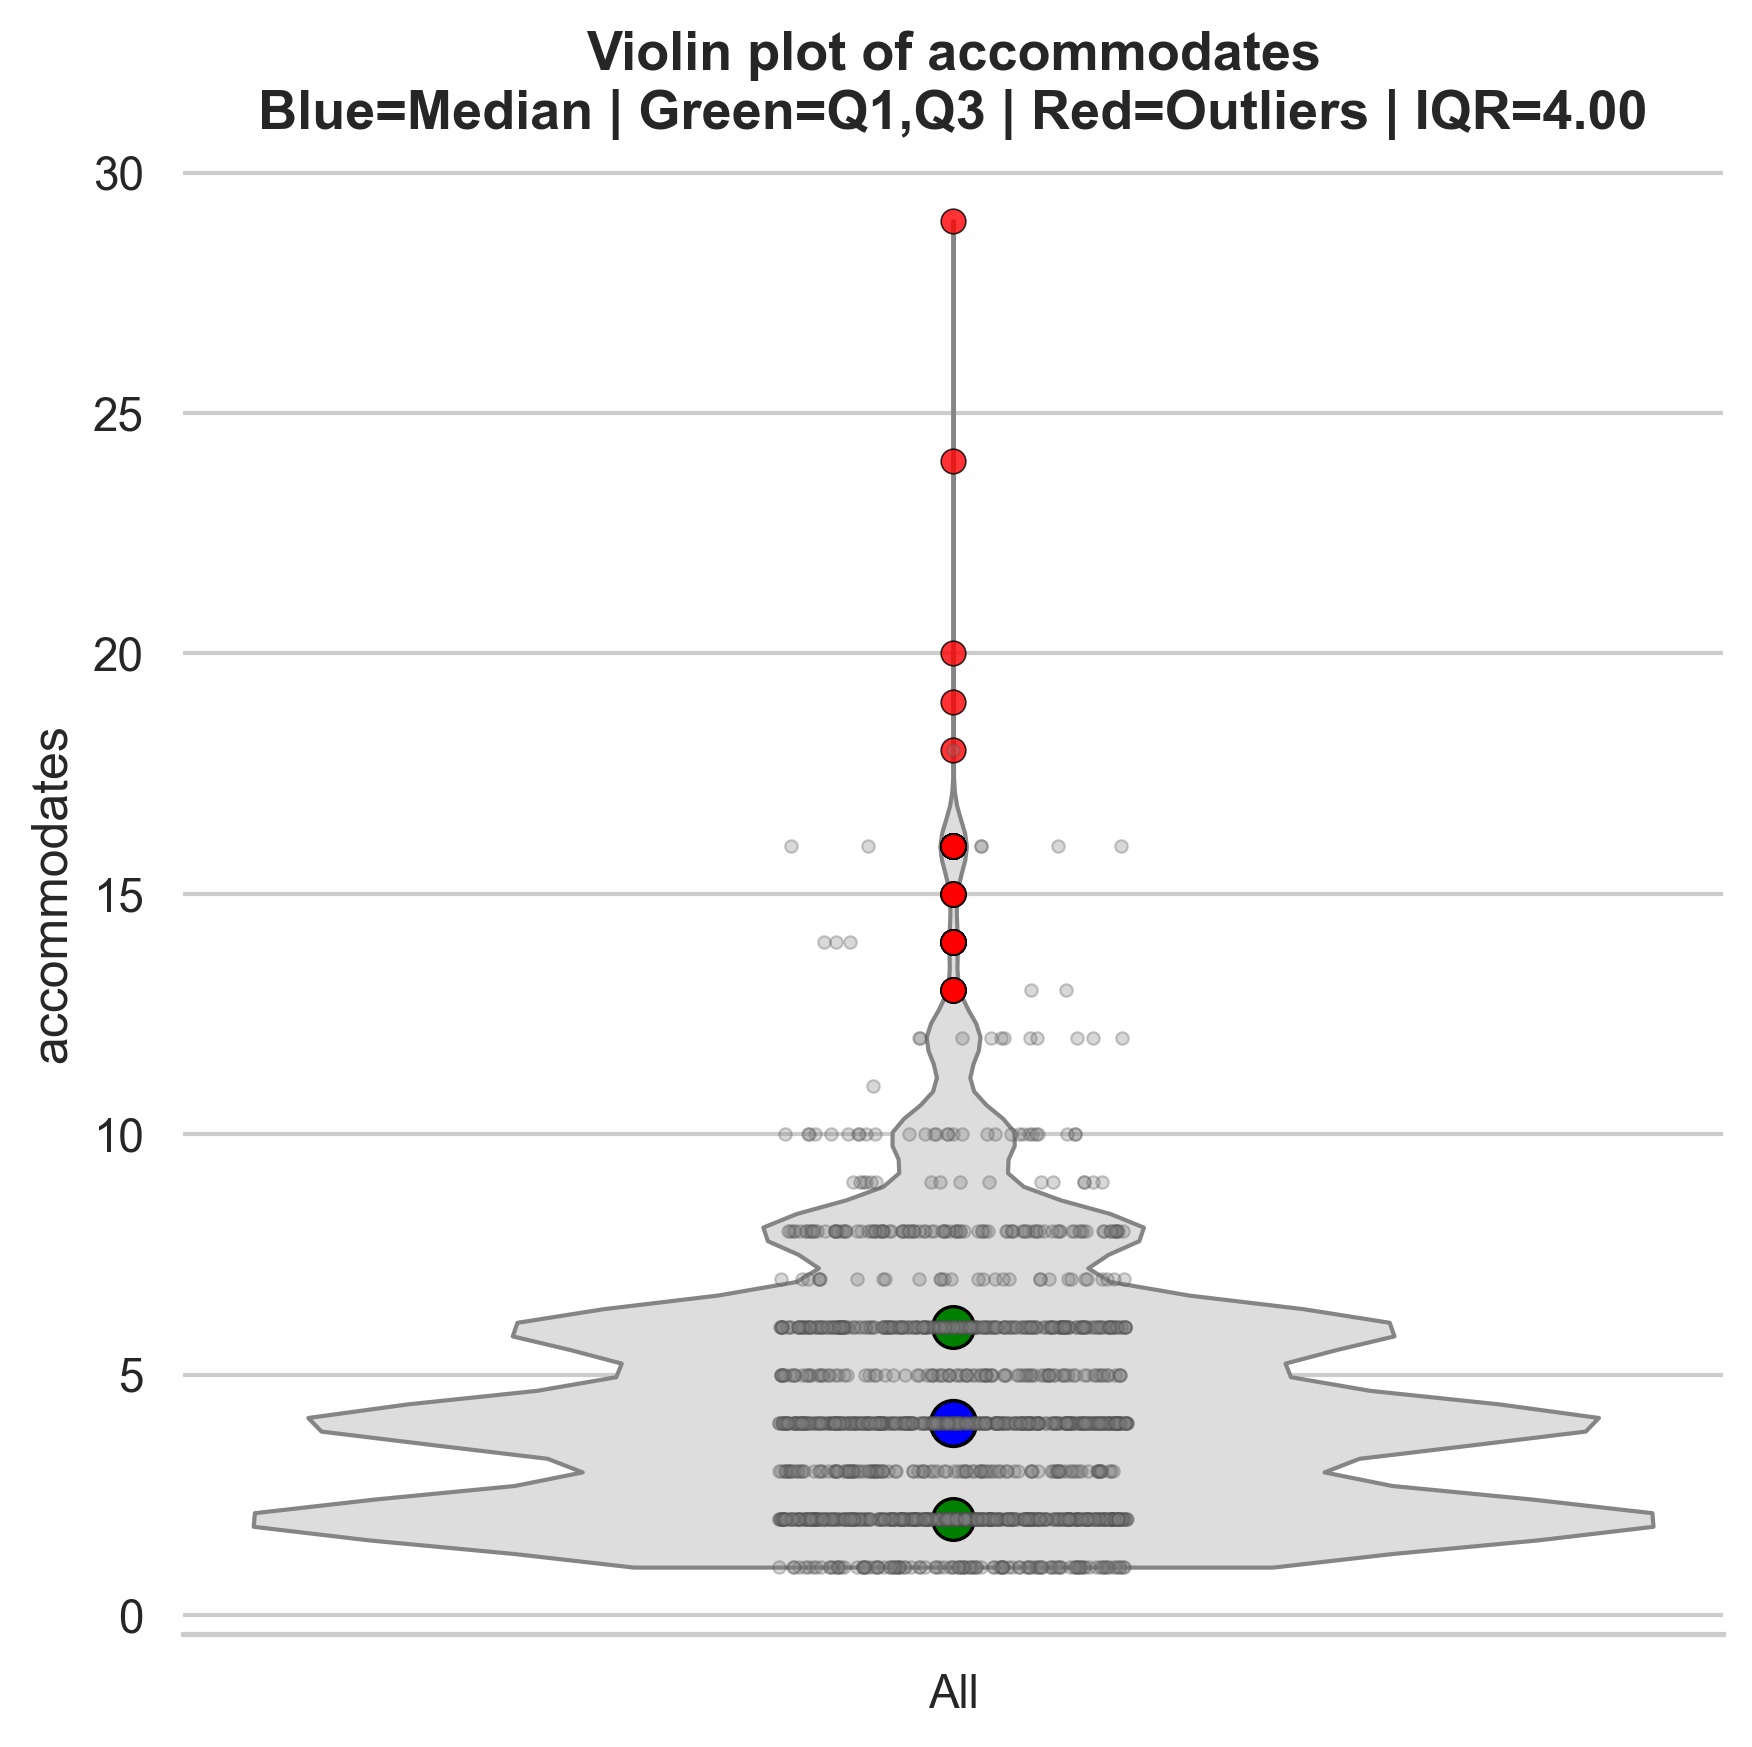

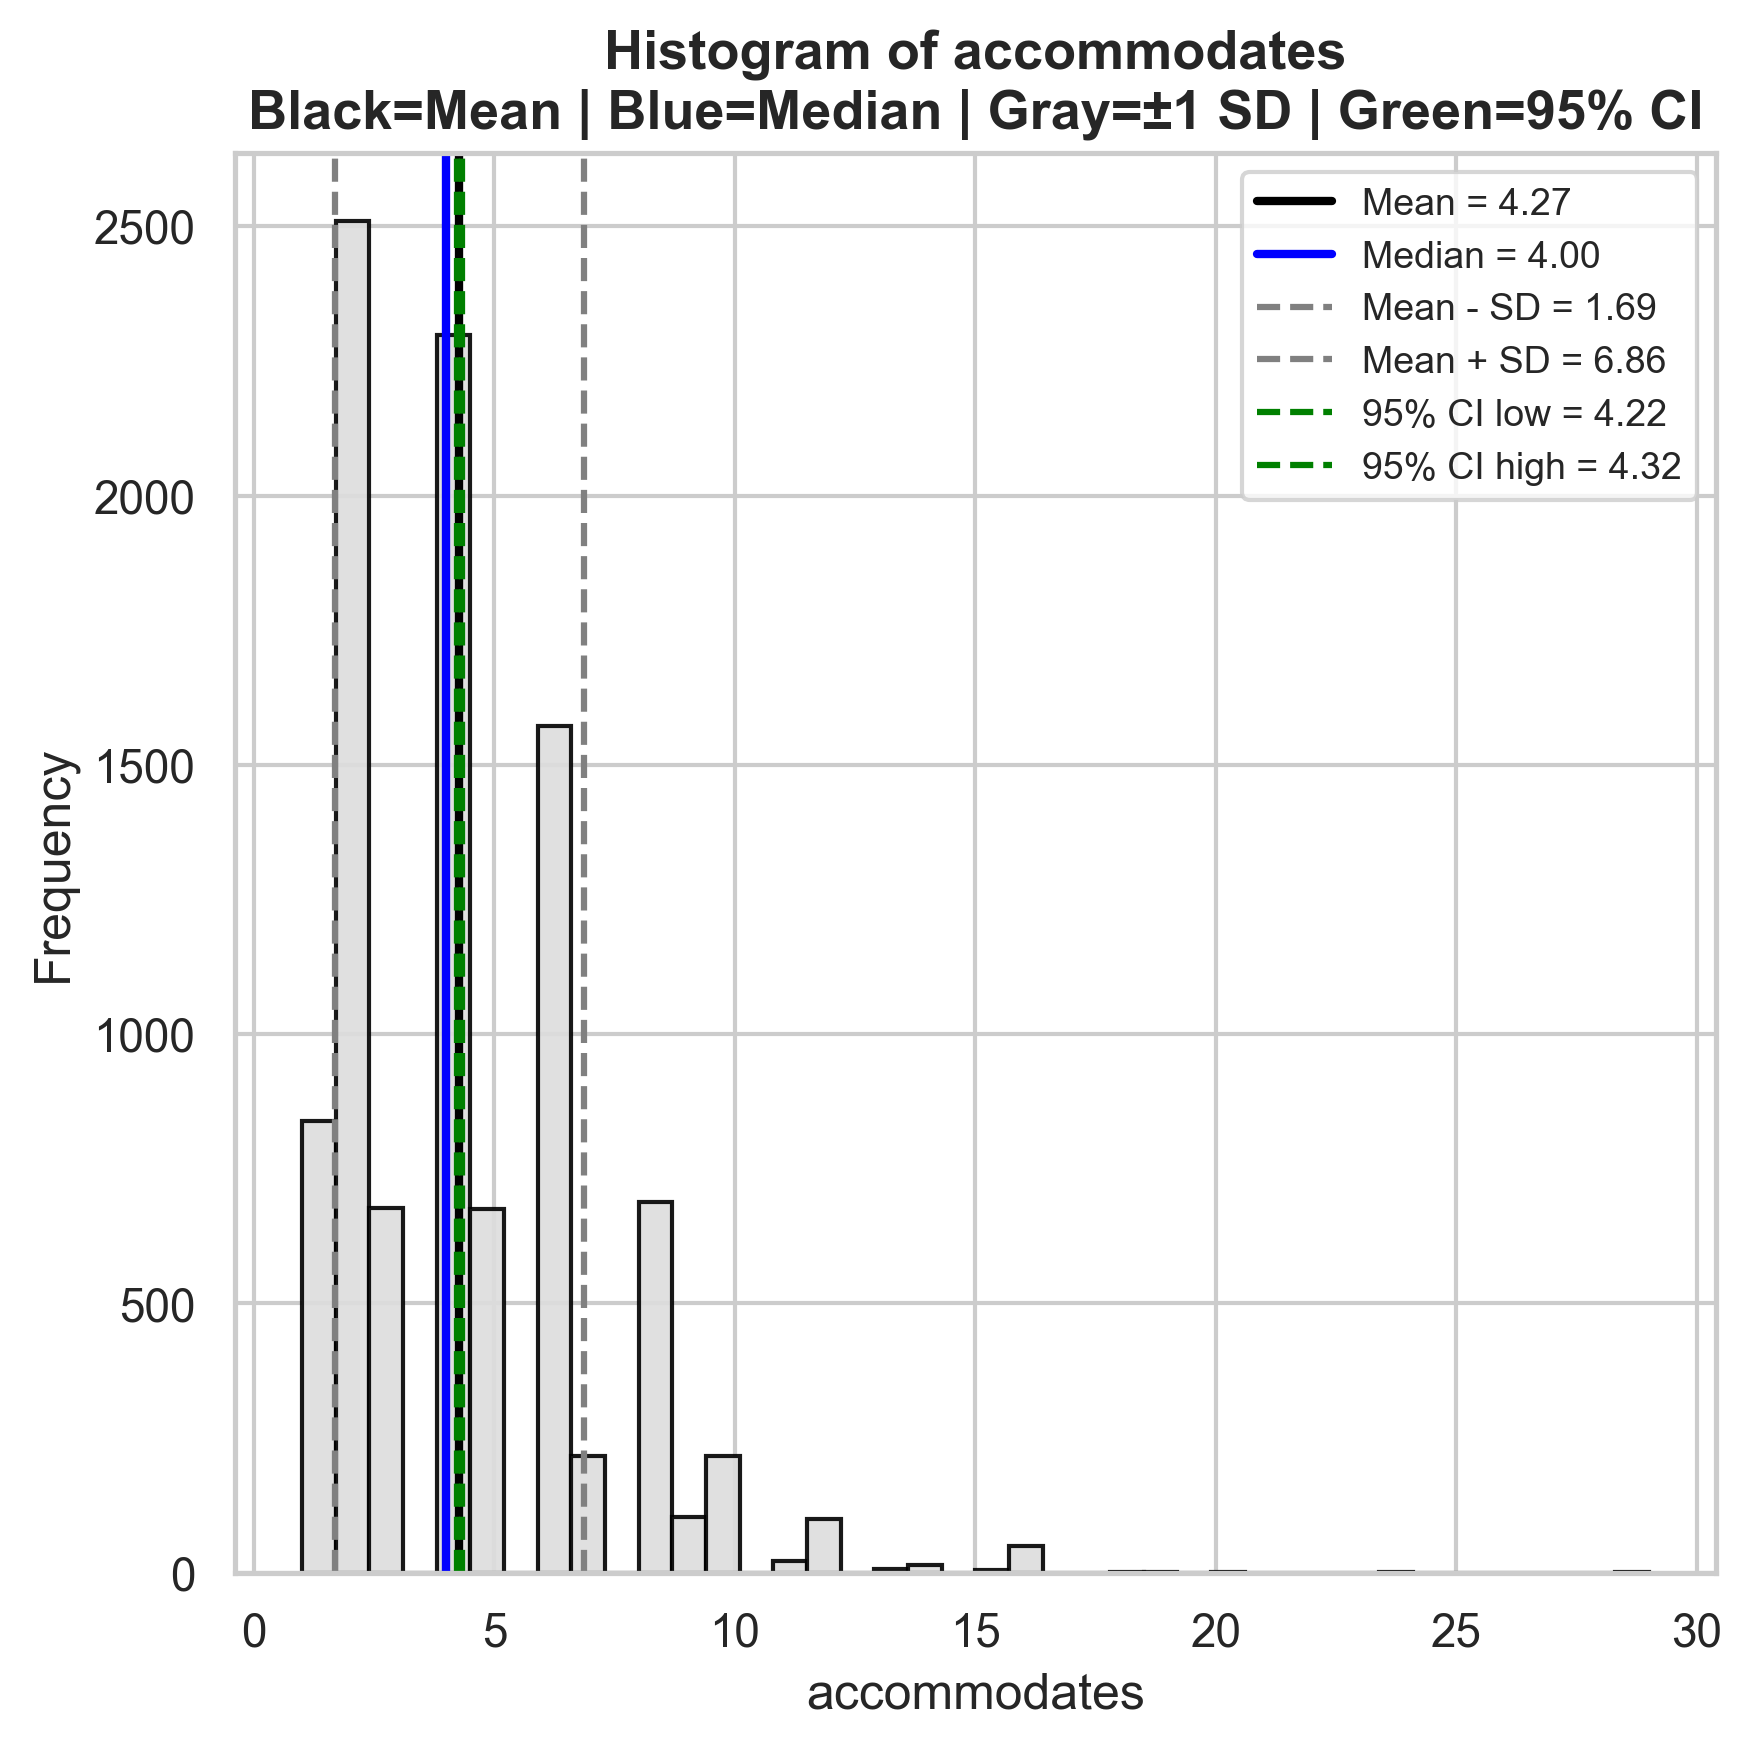

All files saved locally

Summary statistics


,column,n_non_null_numeric,mean,median,std,ci95_low,ci95_high,q1,q3,iqr,lower_fence,upper_fence,outlier_count,skewness,skewness_interpretation
0,accommodates,10000,4.2723,4.0,2.582716,4.221674,4.322926,2.0,6.0,4.0,-4.0,12.0,81,1.328728,Highly skewed.



Unique values table
Number of non-nulls: 10000
Number of unique values: 21


,column,value,count,frequency_non_null
0,accommodates,1,838,0.0838
1,accommodates,2,2510,0.2510
2,accommodates,3,677,0.0677
3,accommodates,4,2299,0.2299
4,accommodates,5,676,0.0676
5,accommodates,6,1573,0.1573
6,accommodates,7,217,0.0217
7,accommodates,8,688,0.0688
8,accommodates,9,104,0.0104
9,accommodates,10,217,0.0217



Correlation table


,target_column,target_type,other_column,other_type,test,statistic,p_value,significance,significance_interpretation,note
0,accommodates,numeric,neighbourhood_name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
1,accommodates,numeric,neighbourhood_district,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
2,accommodates,numeric,city,categorical,Chi-square,2483.732120,0.000000e+00,Significant,Statistically significant at p < 0.05.,
3,accommodates,numeric,room_type,categorical,Chi-square,5612.990130,0.000000e+00,Significant,Statistically significant at p < 0.05.,
4,accommodates,numeric,bathrooms,numeric,Pearson,0.623246,0.000000e+00,Significant,Statistically significant at p < 0.05.,
5,accommodates,numeric,bedrooms,numeric,Pearson,0.799799,0.000000e+00,Significant,Statistically significant at p < 0.05.,
6,accommodates,numeric,beds,numeric,Pearson,0.865593,0.000000e+00,Significant,Statistically significant at p < 0.05.,
7,accommodates,numeric,price,numeric,Pearson,0.533369,0.000000e+00,Significant,Statistically significant at p < 0.05.,
8,accommodates,numeric,minimum_nights,numeric,Pearson,-0.033023,9.574041e-04,Significant,Statistically significant at p < 0.05.,
9,accommodates,numeric,maximum_nights,numeric,Pearson,0.091526,4.697081e-20,Significant,Statistically significant at p < 0.05.,



Transformation skewness table


,method,skewness,interpretation,normality_improvement
0,Original,1.328728,Highly skewed.,Baseline.
1,Log Transformation,-0.277857,Approximately symmetric.,Improved strongly; distribution is closer to s...
2,Square Root Transformation,0.428229,Approximately symmetric.,Improved strongly; distribution is closer to s...
3,Box-Cox Transformation,-0.022051,Approximately symmetric.,Improved strongly; distribution is closer to s...


In [123]:
analysis = analyze_single_field(
    df, target_col="accommodates", results_dir=RESULTS_DIR, show_in_notebook=True
)

*Recommendations for Accommodates*:
- mediana: 4.0
- IQR=4.0 [2.0; 6.0]
- 81 outliers determined
- apply Box-Cox Transformation to obtain normal distribution of the data
- consider:
    * strongly and significantly associated with: city, room_type, is_instant_bookable
    * strongly and significantly correlated with: bedrooms (r=0.8), beds (r=0.87)
    * medium and significantly correlated with: bathrooms (r=0.6), price (r=0.53)
    * weakly and significantly correlated with: availability_365 (r=0.13), reviews_per_month (r= - 0.14)
    * absence of correlation with: minimum_nights, maximum_nights, availability_30, availability_60, availability_90, number_of_reviews, review_scores_rating, review_scores_accuracy, review_scores_cleanliness, review_scores_checkin, review_scores_communication, review_scores_location, review_scores_value
- Spearman correlation with other numeric variables must be used

##### Number of beds

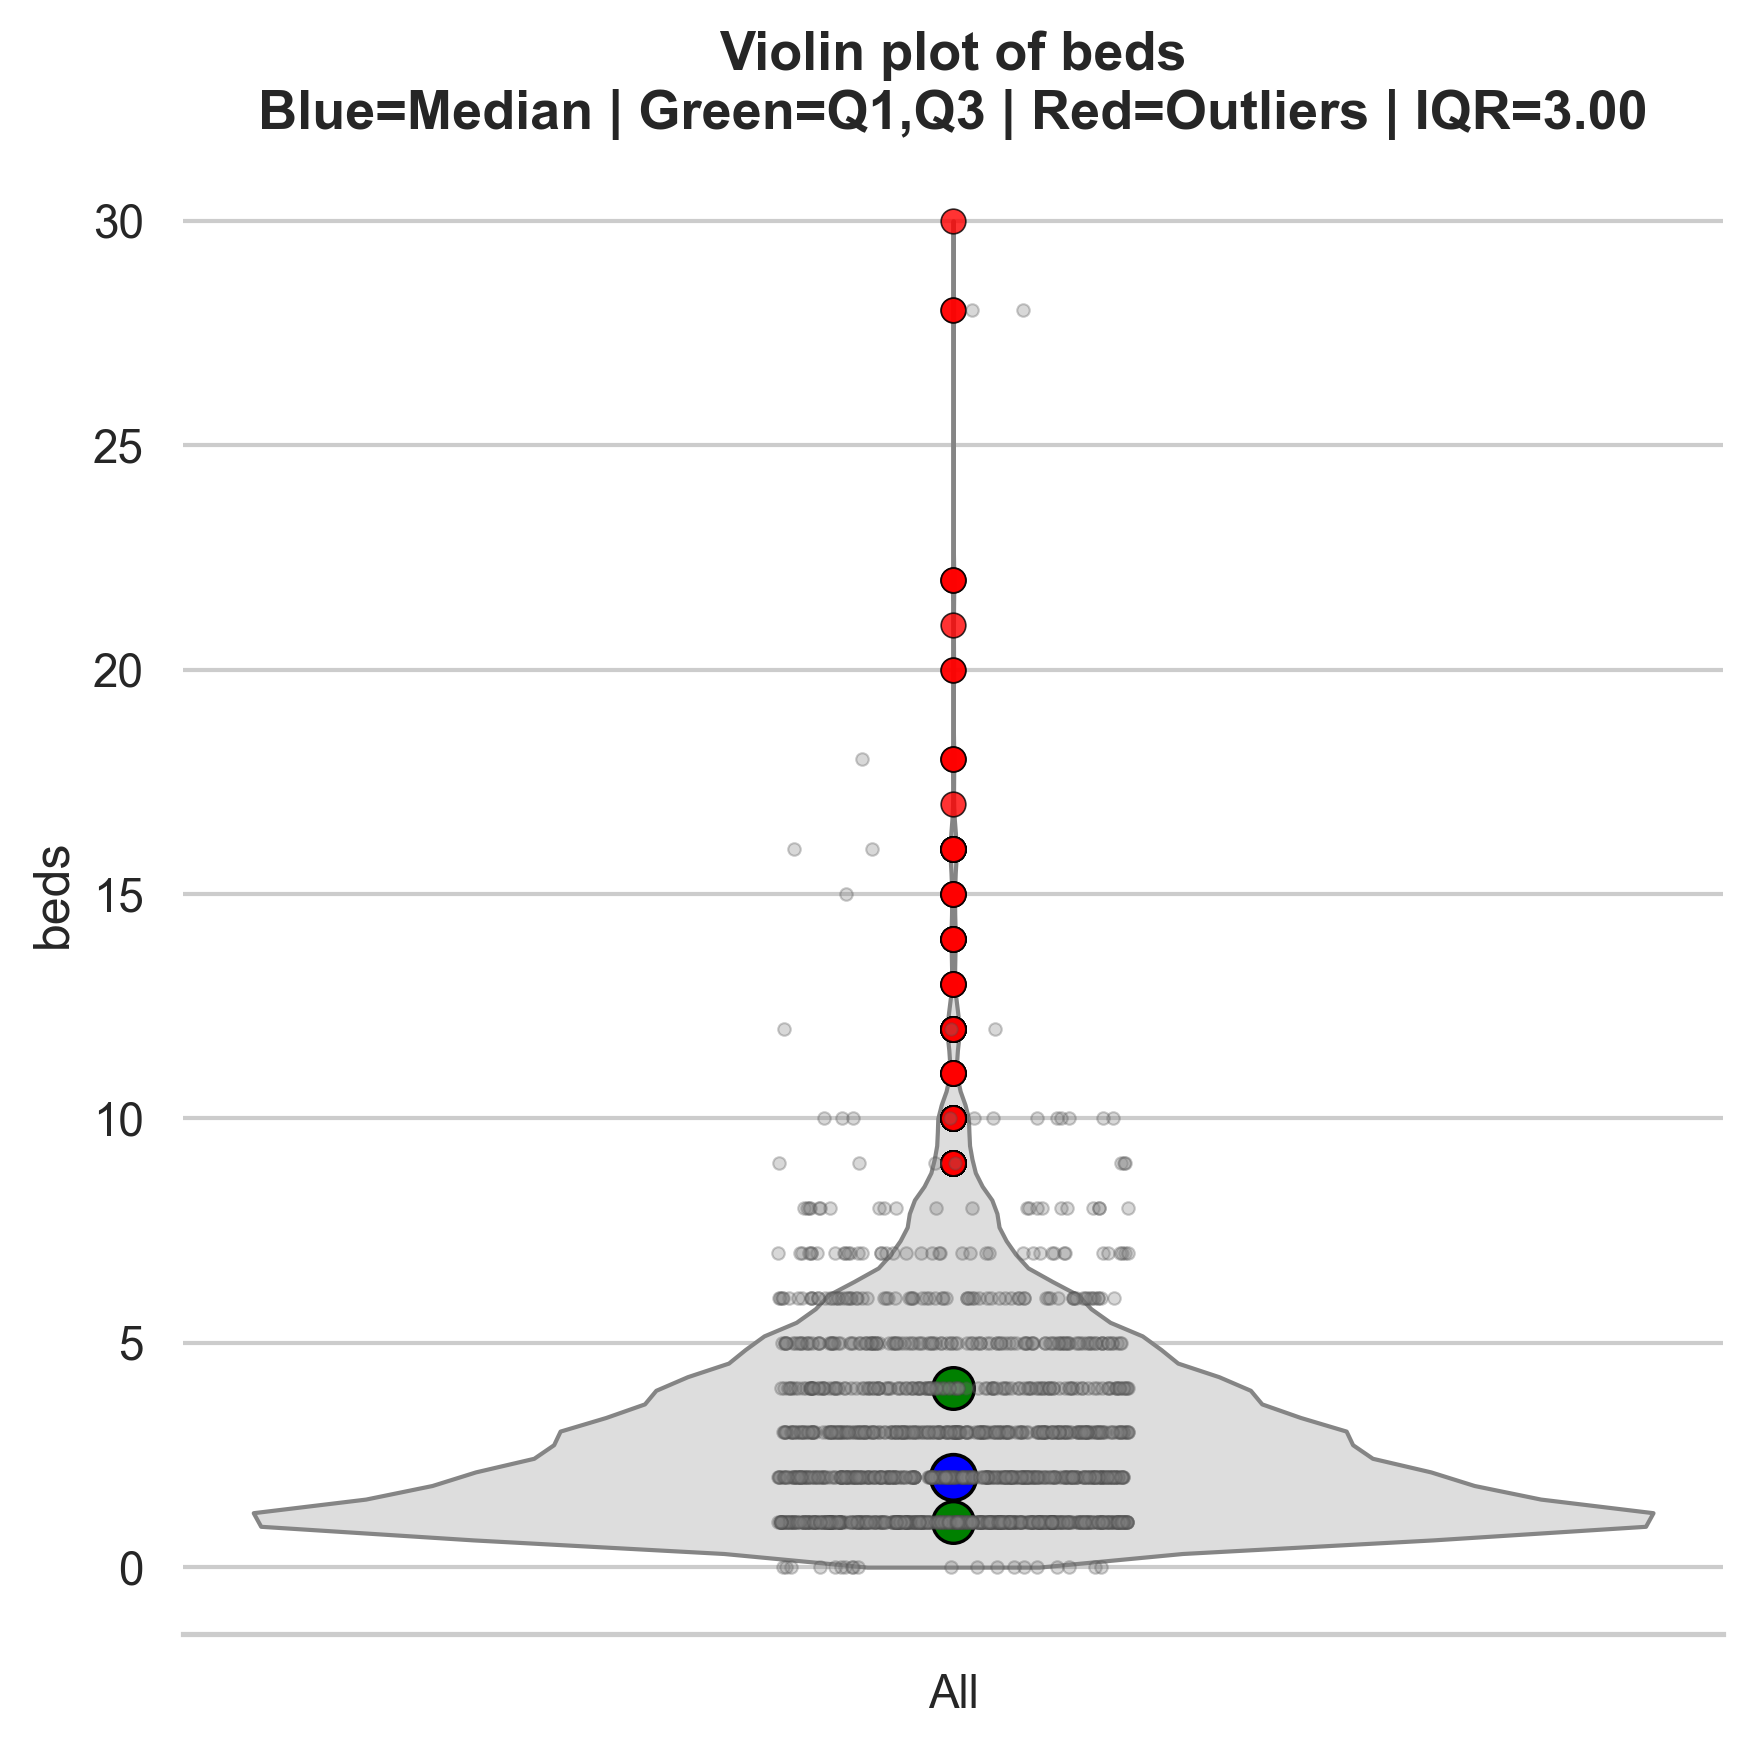

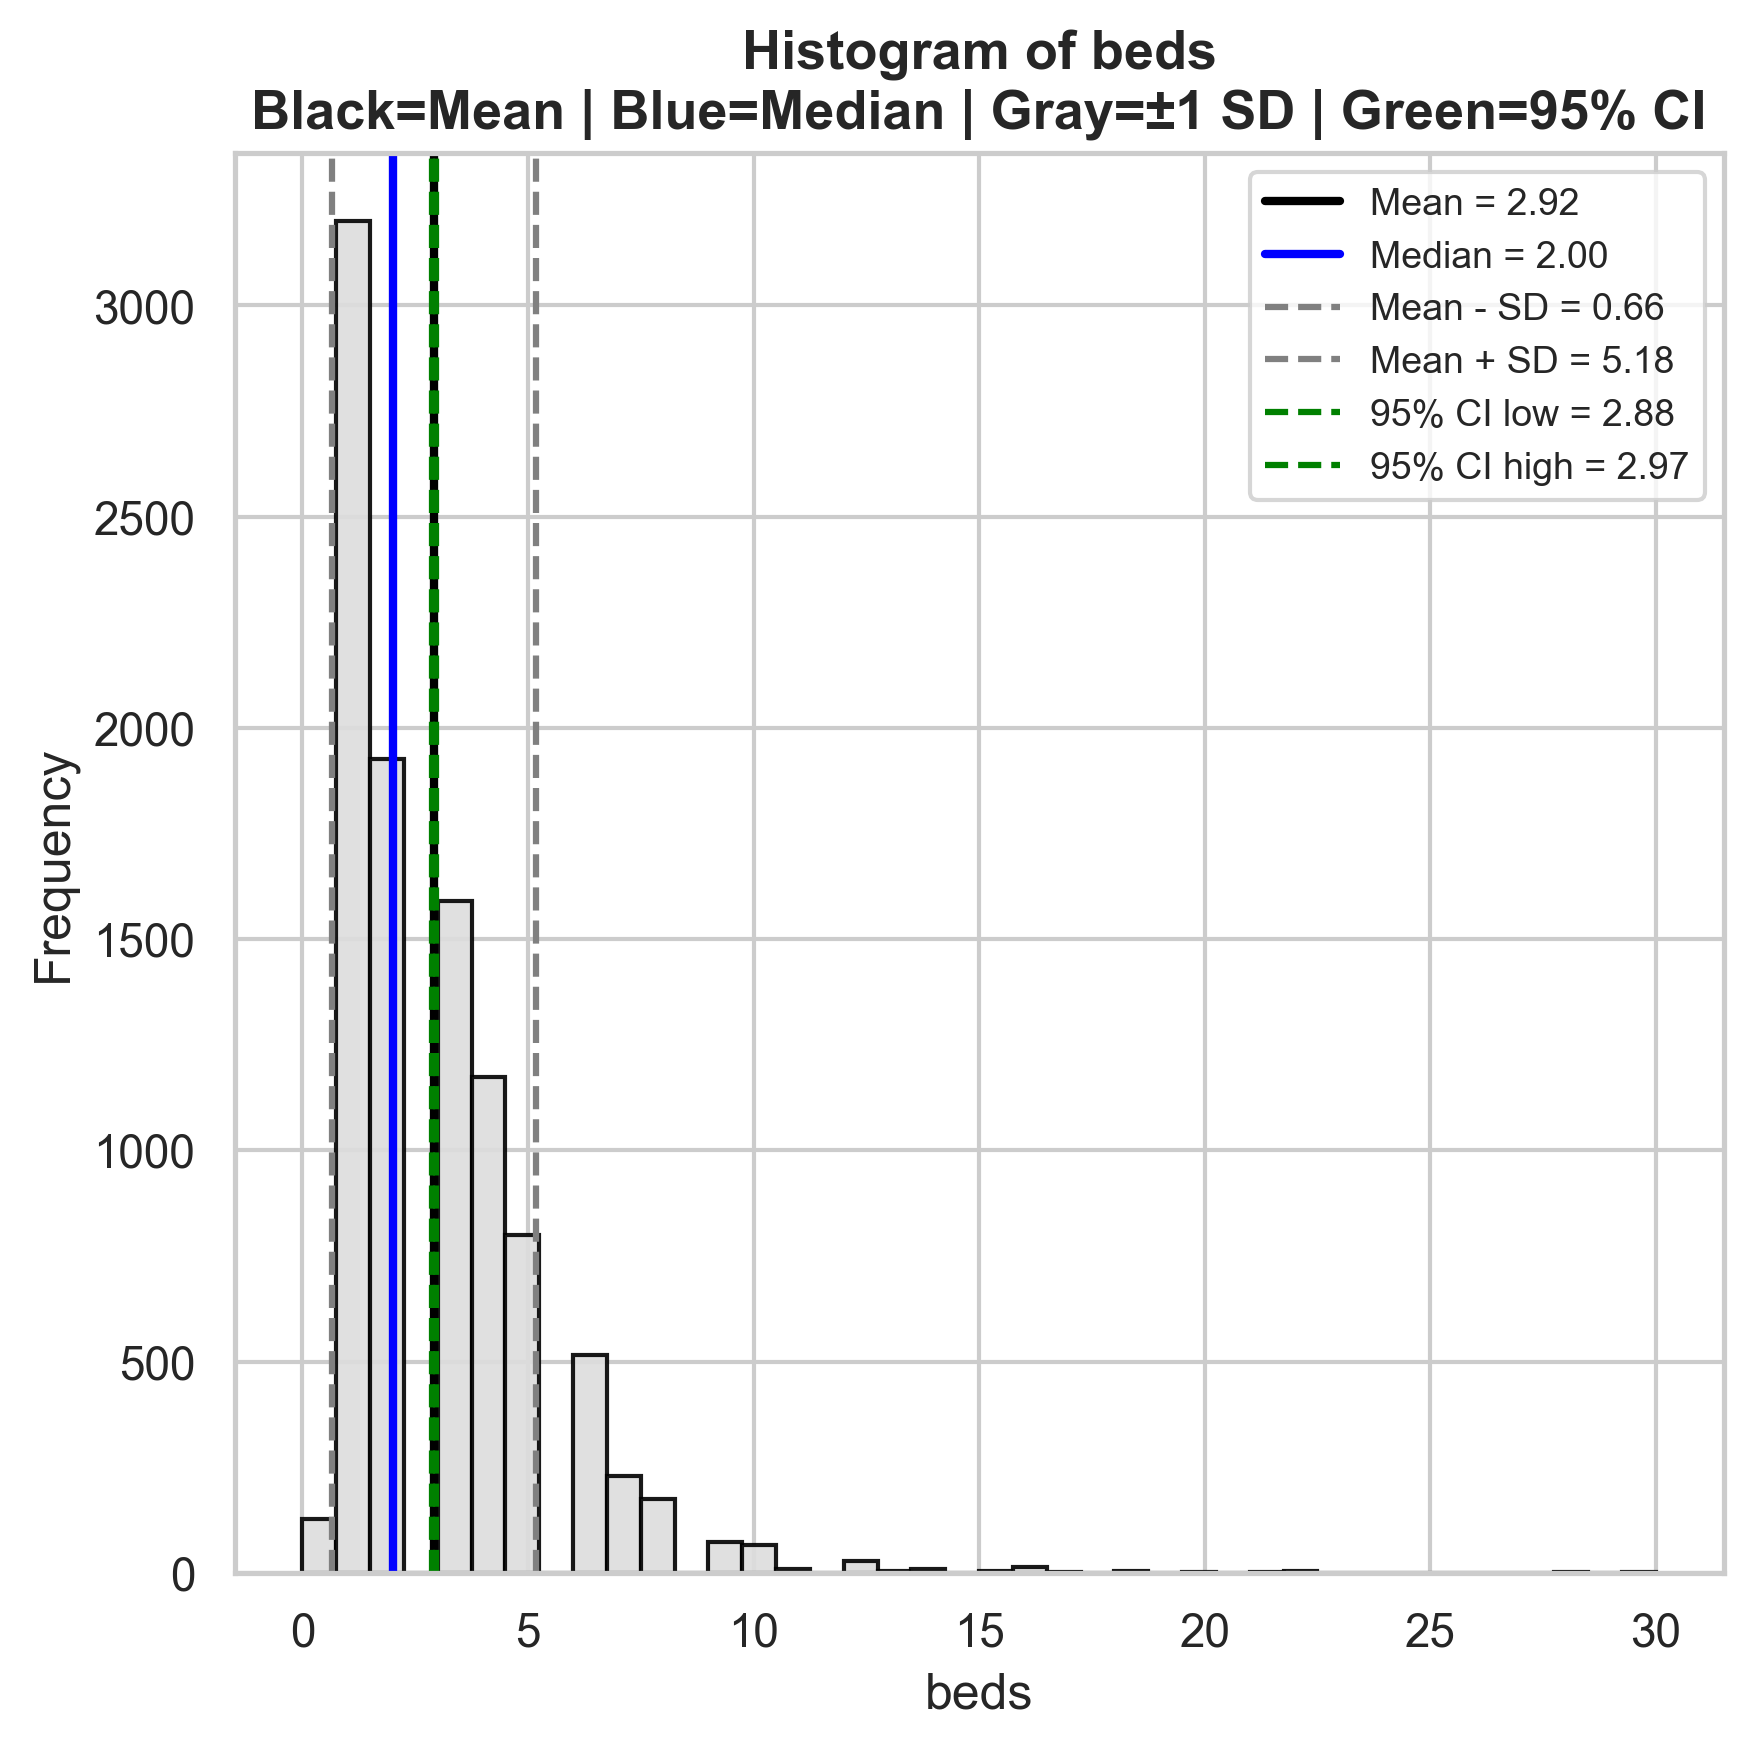

All files saved locally

Summary statistics


,column,n_non_null_numeric,mean,median,std,ci95_low,ci95_high,q1,q3,iqr,lower_fence,upper_fence,outlier_count,skewness,skewness_interpretation
0,beds,9955,2.923456,2.0,2.261214,2.879031,2.96788,1.0,4.0,3.0,-3.5,8.5,219,2.235559,Highly skewed.



Unique values table
Number of non-nulls: 9955
Number of unique values: 24


,column,value,count,frequency_non_null
0,beds,0.0,127,0.012757
1,beds,1.0,3200,0.321447
2,beds,2.0,1926,0.193471
3,beds,3.0,1591,0.159819
4,beds,4.0,1174,0.117931
5,beds,5.0,799,0.080261
6,beds,6.0,515,0.051733
7,beds,7.0,230,0.023104
8,beds,8.0,174,0.017479
9,beds,9.0,72,0.007233



Correlation table


,target_column,target_type,other_column,other_type,test,statistic,p_value,significance,significance_interpretation,note
0,beds,numeric,neighbourhood_name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
1,beds,numeric,neighbourhood_district,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
2,beds,numeric,city,categorical,Chi-square,2710.381987,0.000000e+00,Significant,Statistically significant at p < 0.05.,
3,beds,numeric,room_type,categorical,Chi-square,3797.228231,0.000000e+00,Significant,Statistically significant at p < 0.05.,
4,beds,numeric,accommodates,numeric,Pearson,0.865593,0.000000e+00,Significant,Statistically significant at p < 0.05.,
5,beds,numeric,bathrooms,numeric,Pearson,0.634919,0.000000e+00,Significant,Statistically significant at p < 0.05.,
6,beds,numeric,bedrooms,numeric,Pearson,0.779142,0.000000e+00,Significant,Statistically significant at p < 0.05.,
7,beds,numeric,price,numeric,Pearson,0.492849,0.000000e+00,Significant,Statistically significant at p < 0.05.,
8,beds,numeric,minimum_nights,numeric,Pearson,-0.026544,8.083560e-03,Significant,Statistically significant at p < 0.05.,
9,beds,numeric,maximum_nights,numeric,Pearson,0.068756,6.539015e-12,Significant,Statistically significant at p < 0.05.,



Transformation skewness table


,method,skewness,interpretation,normality_improvement
0,Original,2.235559,Highly skewed.,Baseline.
1,Log Transformation,0.329943,Approximately symmetric.,Improved strongly; distribution is closer to s...
2,Square Root Transformation,0.636120,Moderately skewed.,Improved; skewness decreased.
3,Box-Cox Transformation,0.023638,Approximately symmetric.,Improved strongly; distribution is closer to s...


In [124]:
analysis = analyze_single_field(
    df, target_col="beds", results_dir=RESULTS_DIR, show_in_notebook=True
)

*Recommendations for Beds*:
- mediana: 2.0
- IQR=3.0 [1.0; 4.0]
- 219 outliers determined
- apply Box-Cox Transformation to obtain normal distribution of the data
- consider:
    * strongly and significantly associated with: city, room_type, is_instant_bookable
    * strongly and significantly correlated with: bedrooms (r=0.78), accomodates (r=0.87)
    * medium and significantly correlated with: bathrooms (r=0.63), price (r=0.49)
    * weakly and significantly correlated with: availability_365 (r=0.12), number_of_reviews (r= -0.12), reviews_per_month (r= - 0.198
    * absence of correlation with: minimum_nights, maximum_nights, availability_30, availability_60, availability_90, review_scores_rating, review_scores_accuracy, review_scores_cleanliness, review_scores_checkin, review_scores_communication, review_scores_location, review_scores_value
- Spearman correlation with other numeric variables must be used

##### Price

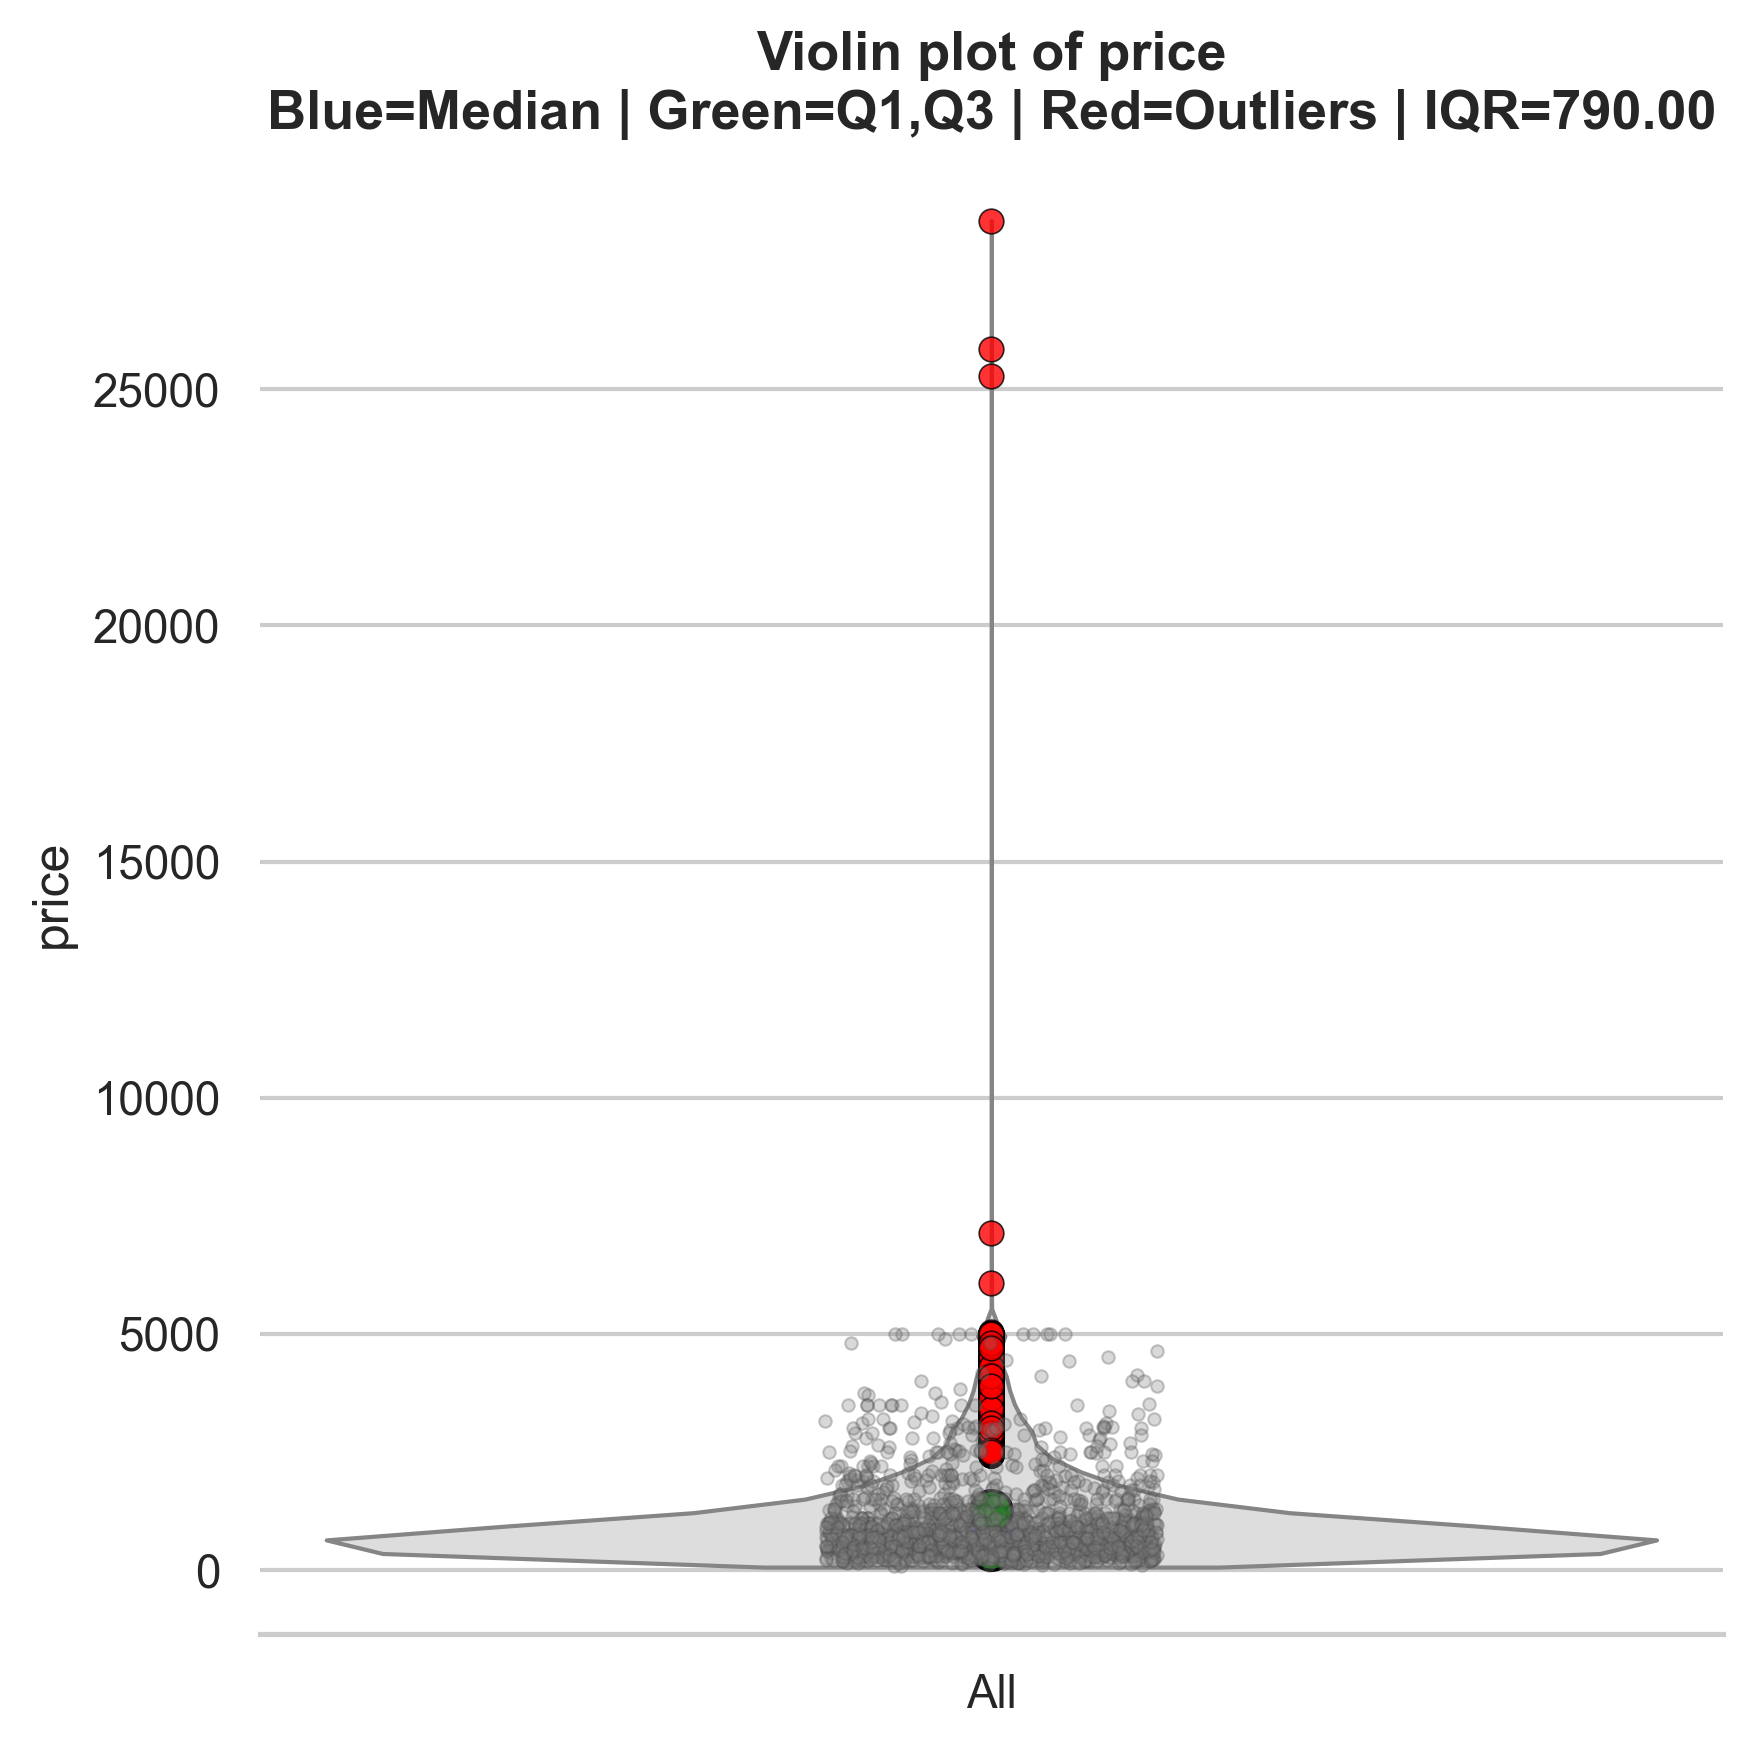

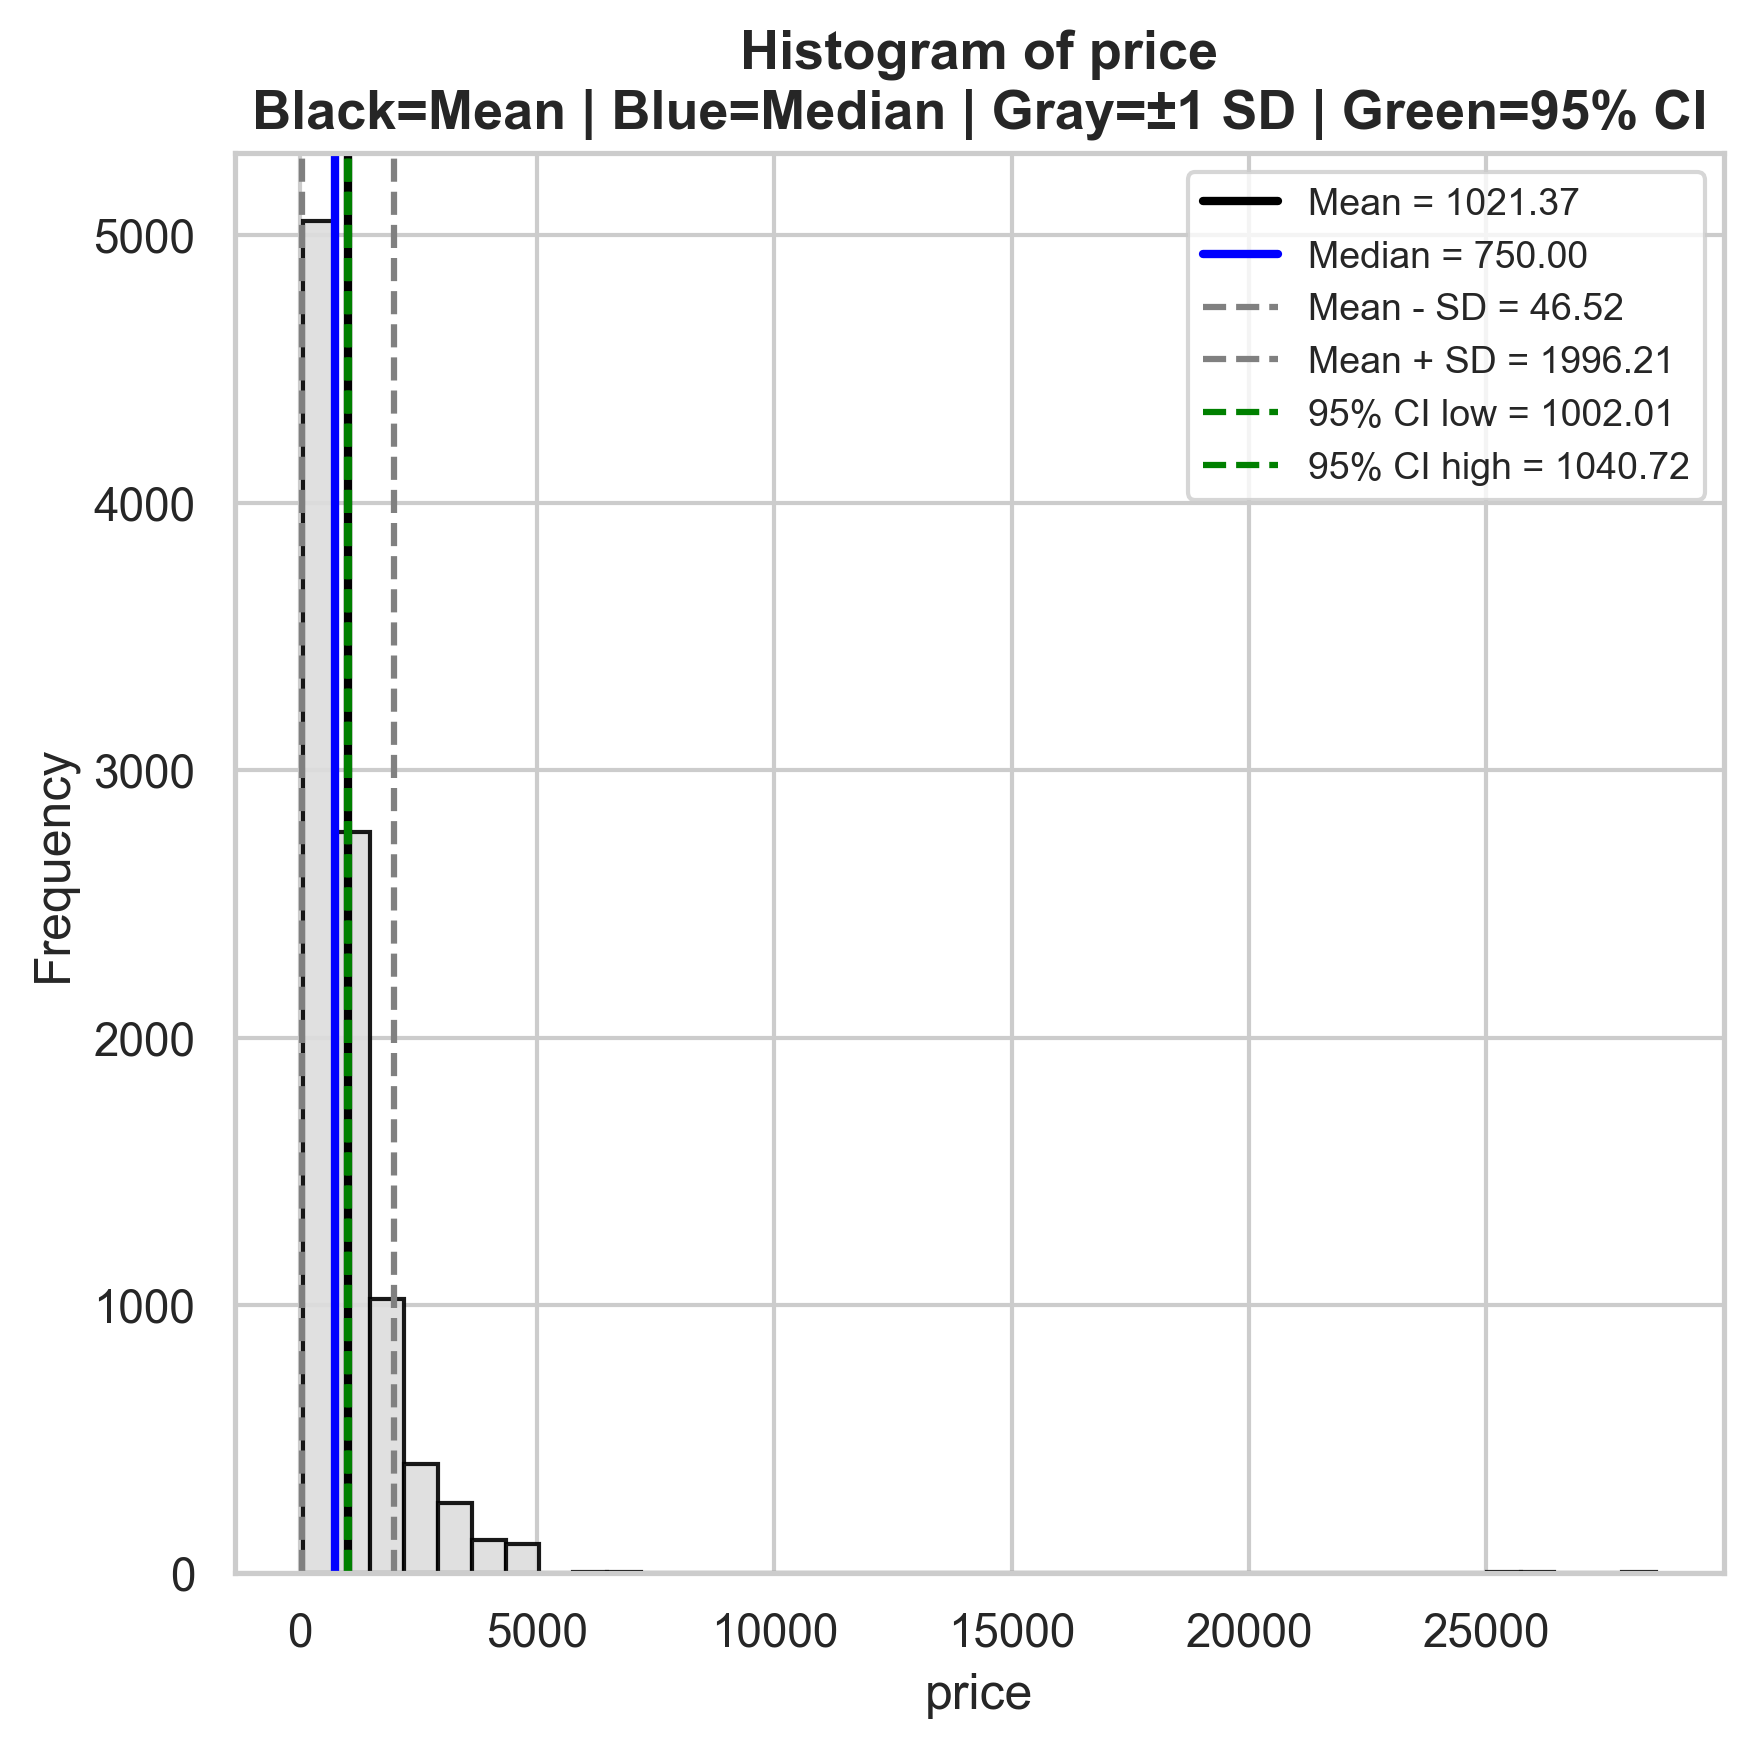

All files saved locally

Summary statistics


,column,n_non_null_numeric,mean,median,std,ci95_low,ci95_high,q1,q3,iqr,lower_fence,upper_fence,outlier_count,skewness,skewness_interpretation
0,price,9746,1021.366509,750.0,974.84598,1002.010098,1040.72292,450.0,1240.0,790.0,-735.0,2425.0,748,7.039678,Highly skewed.



Unique values table
Number of non-nulls: 9746
Number of unique values: 419


,column,value,count,frequency_non_null
0,price,60.0,1,0.000103
1,price,80.0,5,0.000513
2,price,90.0,5,0.000513
3,price,100.0,22,0.002257
4,price,110.0,10,0.001026
...,...,...,...,...
414,price,6071.0,1,0.000103
415,price,7143.0,1,0.000103
416,price,25286.0,1,0.000103
417,price,25857.0,1,0.000103



Correlation table


,target_column,target_type,other_column,other_type,test,statistic,p_value,significance,significance_interpretation,note
0,price,numeric,neighbourhood_name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
1,price,numeric,neighbourhood_district,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
2,price,numeric,city,categorical,Chi-square,1996.080386,0.000000e+00,Significant,Statistically significant at p < 0.05.,
3,price,numeric,room_type,categorical,Chi-square,4327.649028,0.000000e+00,Significant,Statistically significant at p < 0.05.,
4,price,numeric,accommodates,numeric,Pearson,0.533369,0.000000e+00,Significant,Statistically significant at p < 0.05.,
5,price,numeric,bathrooms,numeric,Pearson,0.450245,0.000000e+00,Significant,Statistically significant at p < 0.05.,
6,price,numeric,bedrooms,numeric,Pearson,0.491423,0.000000e+00,Significant,Statistically significant at p < 0.05.,
7,price,numeric,beds,numeric,Pearson,0.492849,0.000000e+00,Significant,Statistically significant at p < 0.05.,
8,price,numeric,minimum_nights,numeric,Pearson,-0.025009,1.355006e-02,Significant,Statistically significant at p < 0.05.,
9,price,numeric,maximum_nights,numeric,Pearson,0.048612,1.576582e-06,Significant,Statistically significant at p < 0.05.,



Transformation skewness table


,method,skewness,interpretation,normality_improvement
0,Original,7.039678,Highly skewed.,Baseline.
1,Log Transformation,0.103845,Approximately symmetric.,Improved strongly; distribution is closer to s...
2,Square Root Transformation,1.428187,Highly skewed.,Improved; skewness decreased.
3,Box-Cox Transformation,0.002164,Approximately symmetric.,Improved strongly; distribution is closer to s...


In [125]:
analysis = analyze_single_field(
    df, target_col="price", results_dir=RESULTS_DIR, show_in_notebook=True
)

*Recommendations for Price*:
- mediana: 750.0
- IQR=790.0 [450.0; 1240.0]
- 748 outliers determined
- apply Box-Cox Transformation to obtain normal distribution of the data
- consider:
    * strongly and significantly associated with: city, room_type, is_instant_bookable
    * strongly and significantly correlated with: none found
    * medium and significantly correlated with: accommodates (r=0.53), bathrooms (r=0.45), bedrooms (r=0.49), beds (r=0.49)
    * weakly and significantly correlated with: availability_365 (r=0.12), number_of_reviews (r= -0.12), reviews_per_month (r= - 0.16)
    * absence of correlation with: minimum_nights, maximum_nights, availability_30, availability_60, availability_90, review_scores_rating, review_scores_accuracy, review_scores_cleanliness, review_scores_checkin, review_scores_communication, review_scores_location, review_scores_value
- Spearman correlation with other numeric variables must be used

<Axes: xlabel='room_type', ylabel='city'>

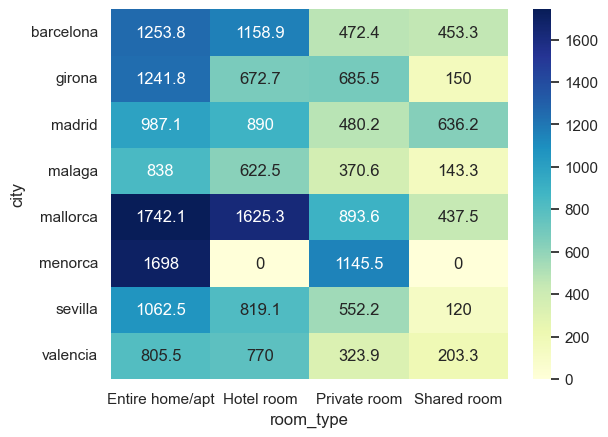

In [126]:
sns.heatmap(
    df.groupby(["city", "room_type"])["price"].mean().round(1).unstack(fill_value=0),
    annot=True,
    cmap="YlGnBu",
    fmt="g",
)

##### Minimal number of nights

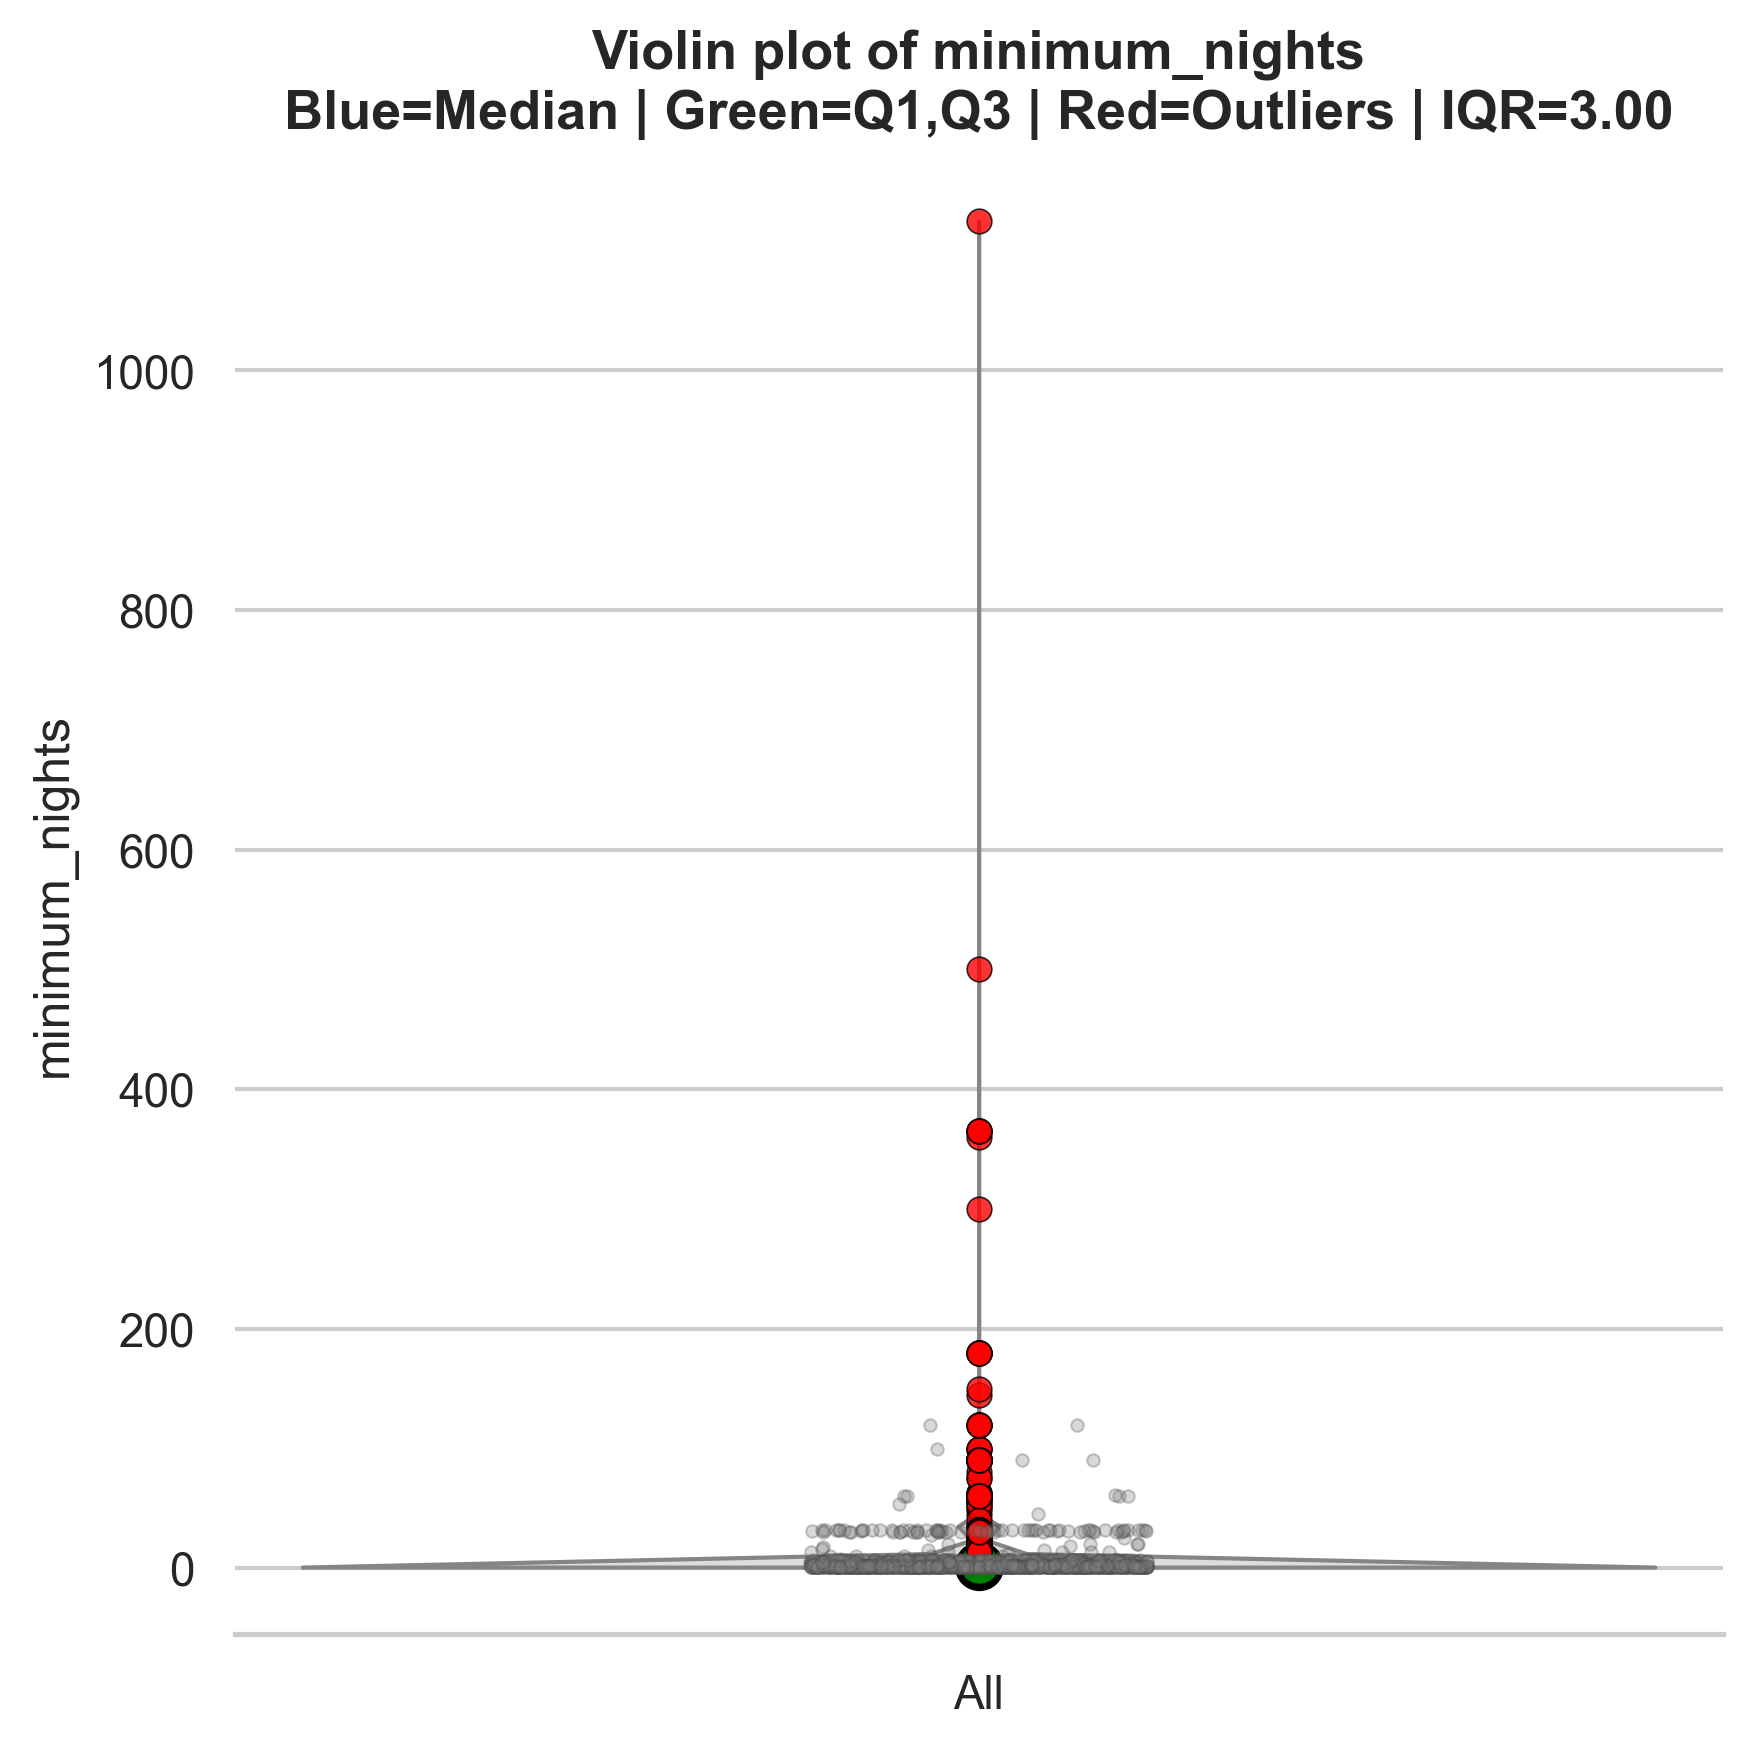

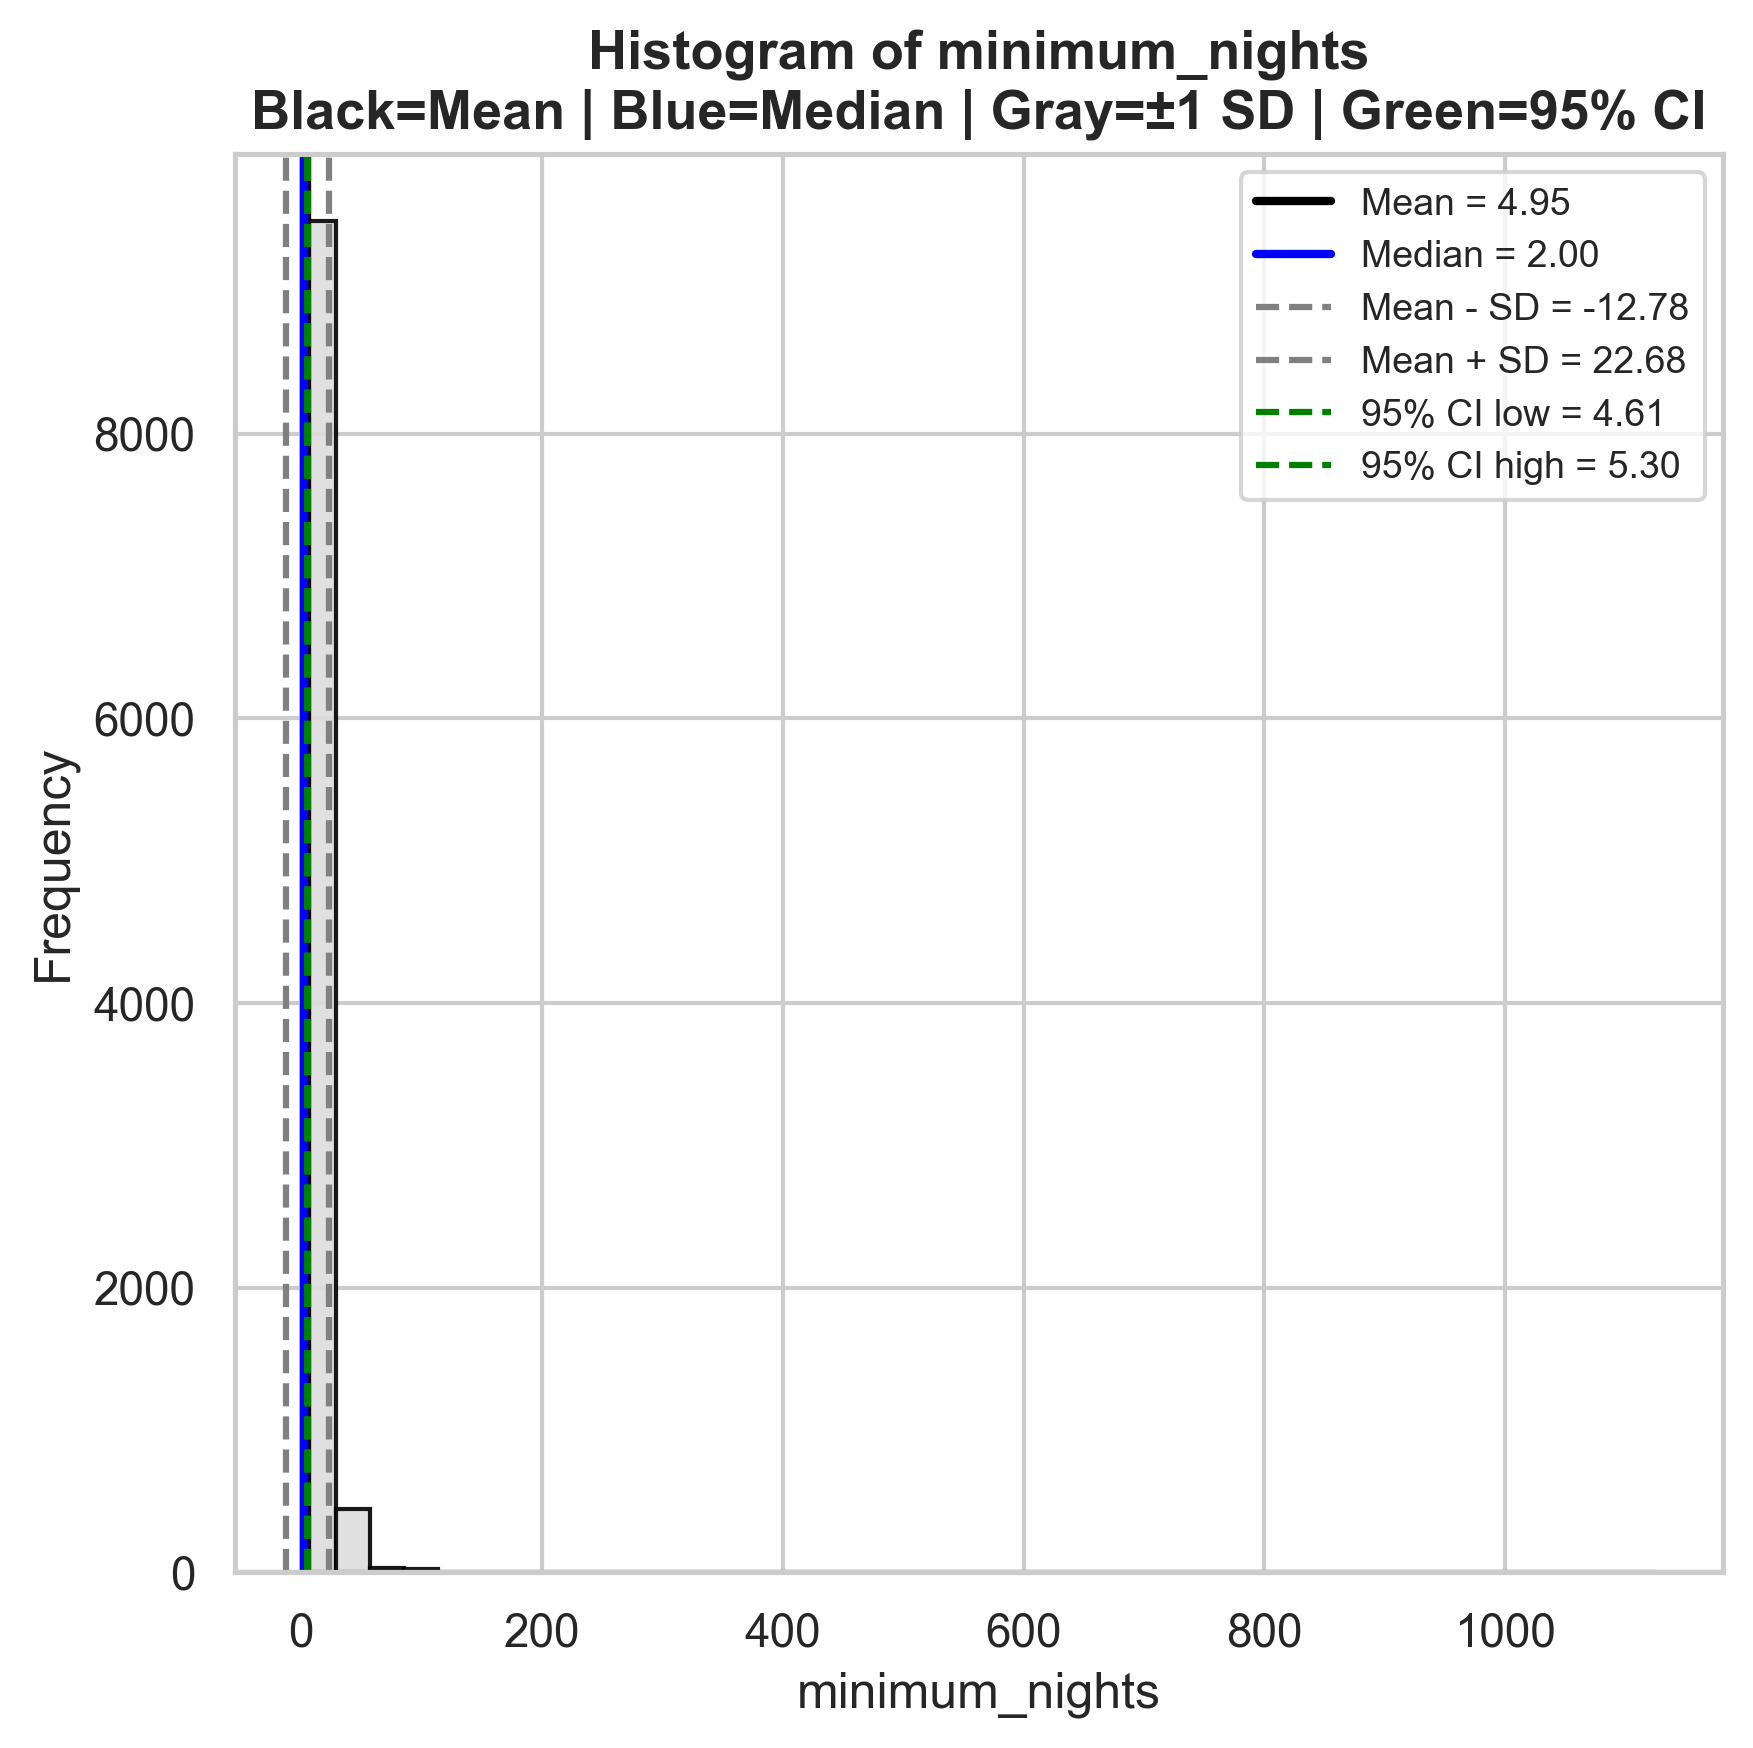

All files saved locally

Summary statistics


,column,n_non_null_numeric,mean,median,std,ci95_low,ci95_high,q1,q3,iqr,lower_fence,upper_fence,outlier_count,skewness,skewness_interpretation
0,minimum_nights,10000,4.953,2.0,17.728763,4.605481,5.300519,1.0,4.0,3.0,-3.5,8.5,642,33.201027,Highly skewed.



Unique values table
Number of non-nulls: 10000
Number of unique values: 49


,column,value,count,frequency_non_null
0,minimum_nights,1,3198,0.3198
1,minimum_nights,2,2610,0.2610
2,minimum_nights,3,1487,0.1487
3,minimum_nights,4,576,0.0576
4,minimum_nights,5,551,0.0551
5,minimum_nights,6,152,0.0152
6,minimum_nights,7,775,0.0775
7,minimum_nights,8,9,0.0009
8,minimum_nights,10,25,0.0025
9,minimum_nights,11,2,0.0002



Correlation table


,target_column,target_type,other_column,other_type,test,statistic,p_value,significance,significance_interpretation,note
0,minimum_nights,numeric,neighbourhood_name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
1,minimum_nights,numeric,neighbourhood_district,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
2,minimum_nights,numeric,city,categorical,Chi-square,1304.614768,2.487850e-263,Significant,Statistically significant at p < 0.05.,
3,minimum_nights,numeric,room_type,categorical,Chi-square,406.659109,5.195855e-82,Significant,Statistically significant at p < 0.05.,
4,minimum_nights,numeric,accommodates,numeric,Pearson,-0.033023,9.574041e-04,Significant,Statistically significant at p < 0.05.,
5,minimum_nights,numeric,bathrooms,numeric,Pearson,-0.011413,2.555353e-01,Not significant,Not statistically significant at p < 0.05.,
6,minimum_nights,numeric,bedrooms,numeric,Pearson,-0.012334,2.190693e-01,Not significant,Not statistically significant at p < 0.05.,
7,minimum_nights,numeric,beds,numeric,Pearson,-0.026544,8.083560e-03,Significant,Statistically significant at p < 0.05.,
8,minimum_nights,numeric,price,numeric,Pearson,-0.025009,1.355006e-02,Significant,Statistically significant at p < 0.05.,
9,minimum_nights,numeric,maximum_nights,numeric,Pearson,-0.005413,5.883756e-01,Not significant,Not statistically significant at p < 0.05.,



Transformation skewness table


,method,skewness,interpretation,normality_improvement
0,Original,33.201027,Highly skewed.,Baseline.
1,Log Transformation,1.370357,Highly skewed.,Improved; skewness decreased.
2,Square Root Transformation,5.606862,Highly skewed.,Improved; skewness decreased.
3,Box-Cox Transformation,0.156212,Approximately symmetric.,Improved strongly; distribution is closer to s...


In [127]:
analysis = analyze_single_field(
    df, target_col="minimum_nights", results_dir=RESULTS_DIR, show_in_notebook=True
)

*Recommendations for Minimum number of nights*:
- mediana: 2.0
- IQR=3.0 [1.0; 4.0]
- 642 outliers determined
- apply Box-Cox Transformation to obtain normal distribution of the data
- consider:
    * strongly and significantly associated with: city, room_type, is_instant_bookable
    * strongly and significantly correlated with: none found
    * medium and significantly correlated with: none found
    * weakly and significantly correlated with: none found
    * absence of correlation with: all other variables

##### Maximal numbert of nights

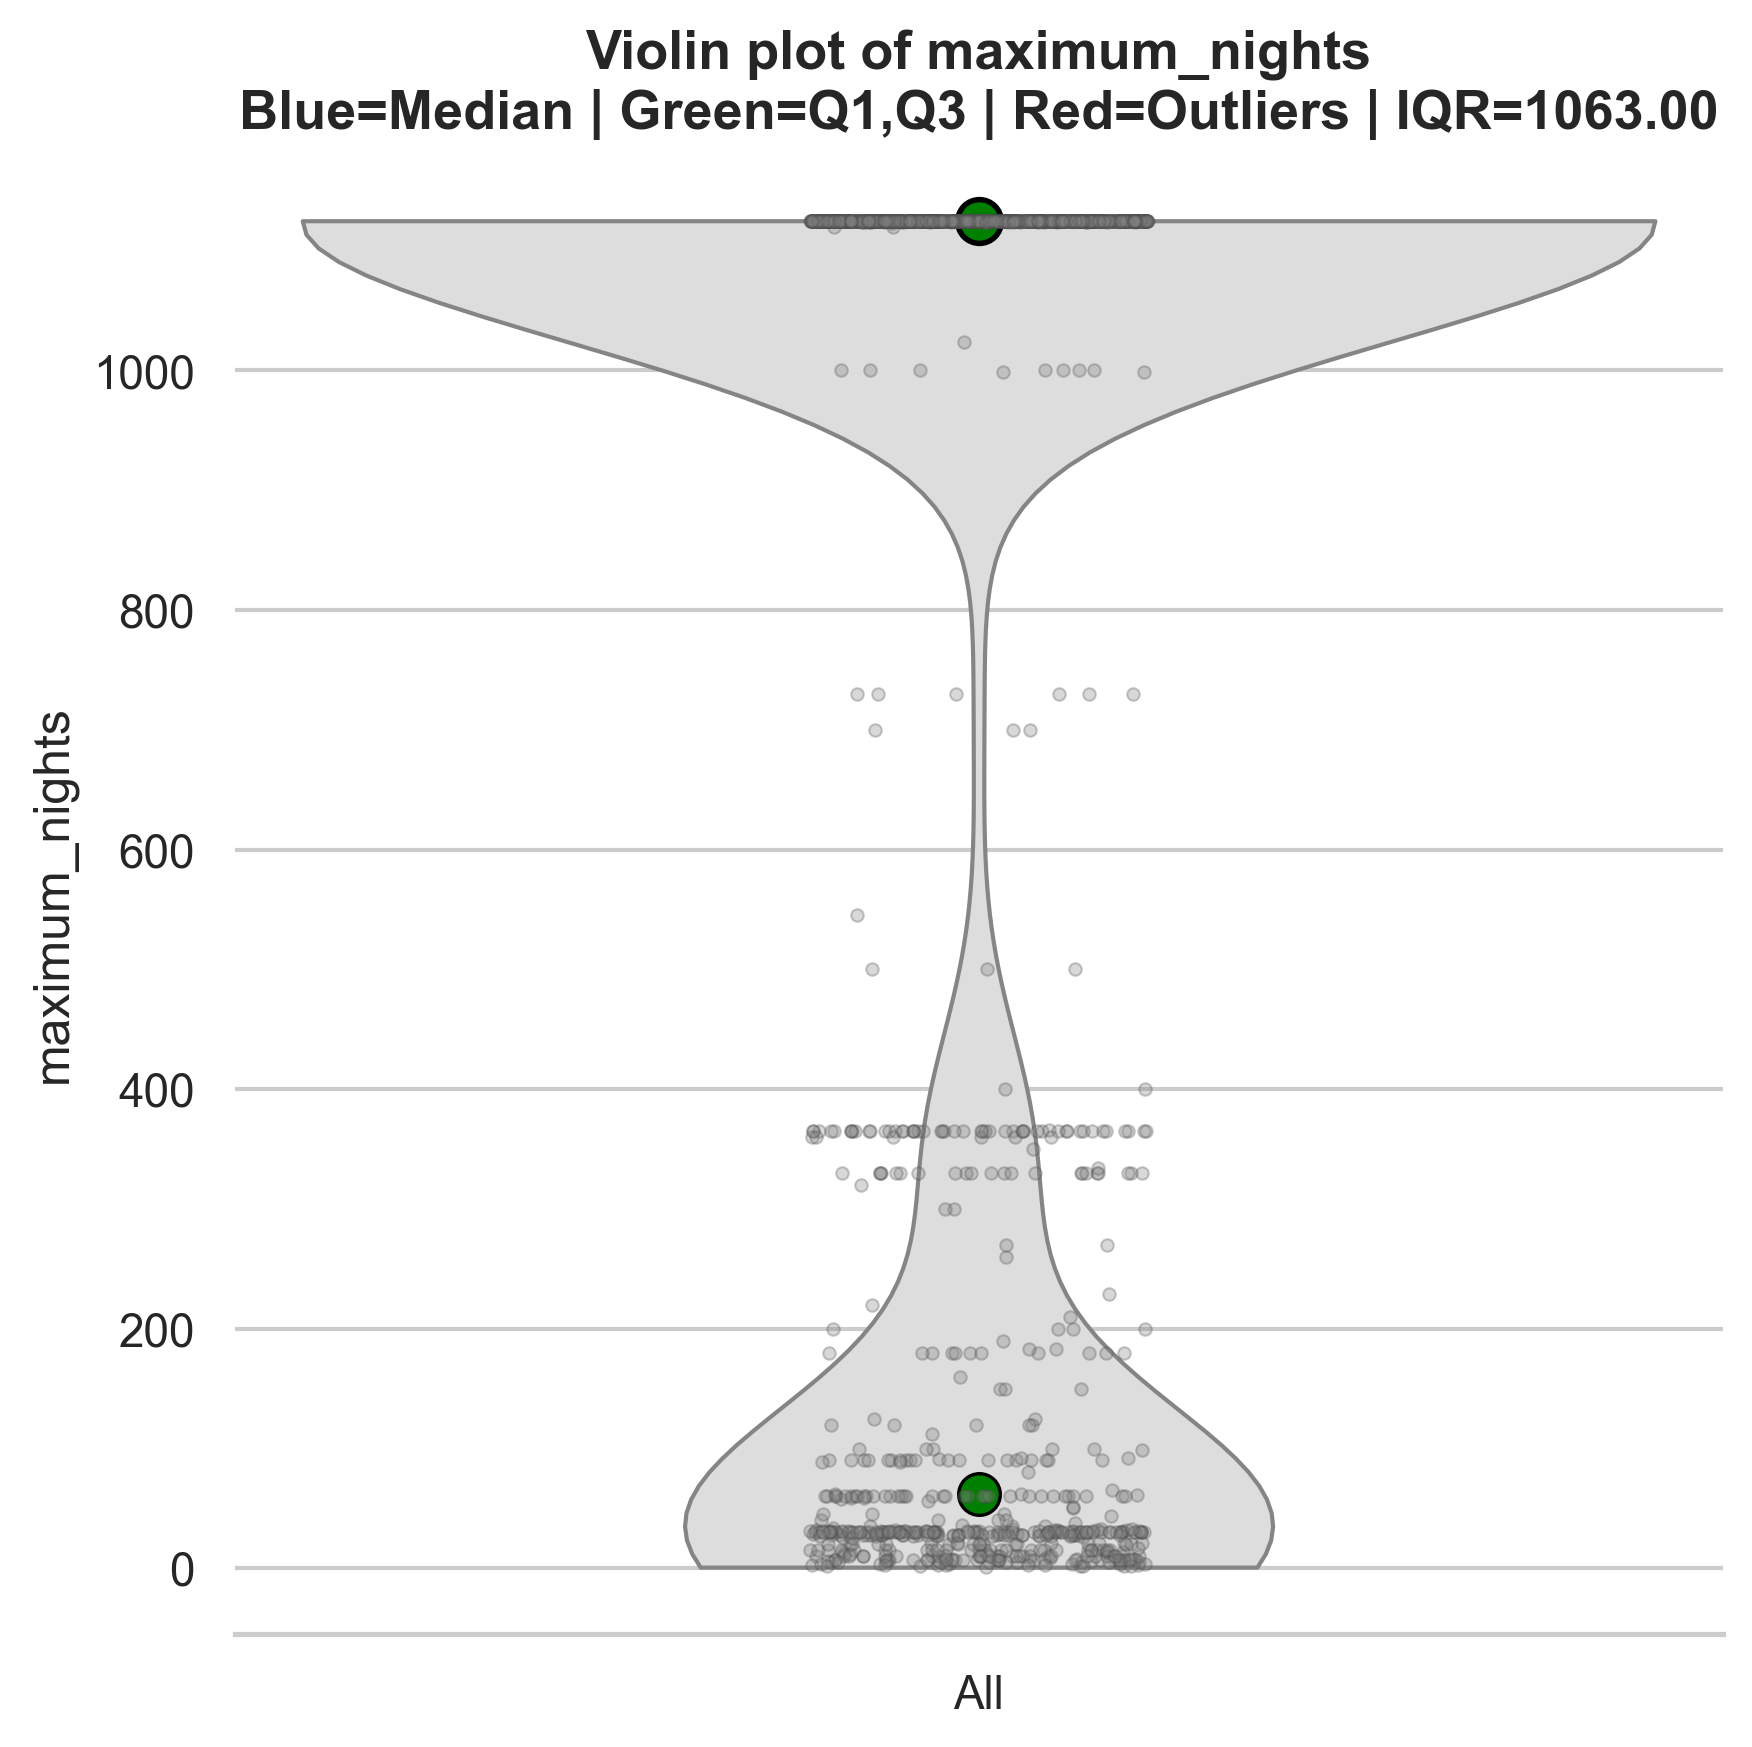

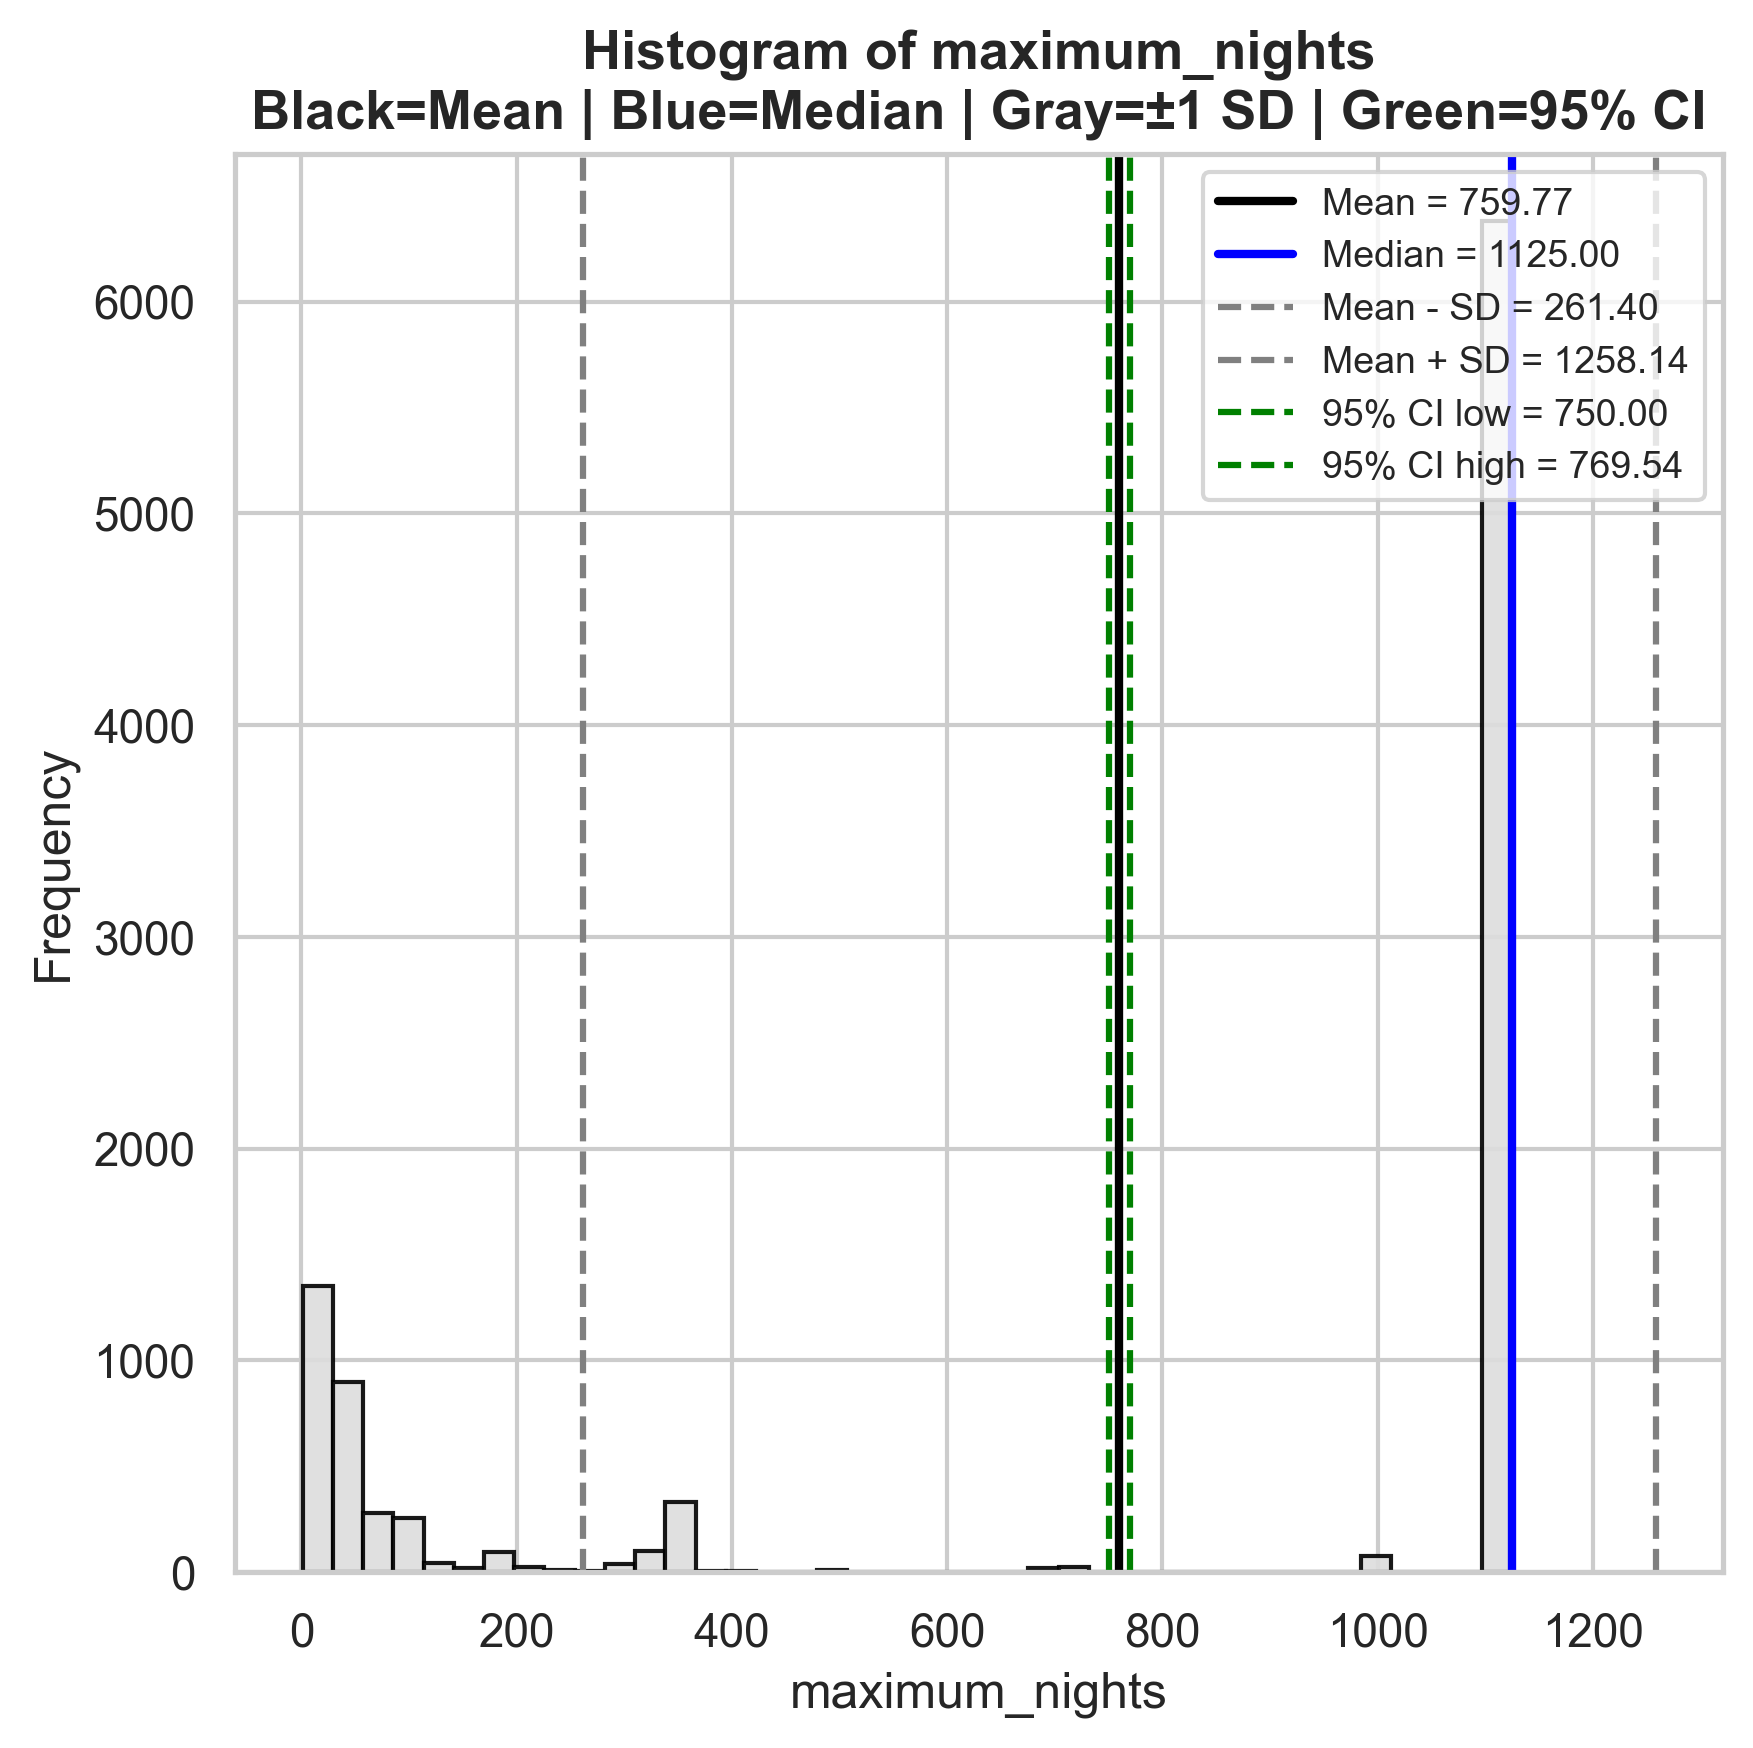

All files saved locally

Summary statistics


,column,n_non_null_numeric,mean,median,std,ci95_low,ci95_high,q1,q3,iqr,lower_fence,upper_fence,outlier_count,skewness,skewness_interpretation
0,maximum_nights,10000,759.7719,1125.0,498.367763,750.002889,769.540911,62.0,1125.0,1063.0,-1532.5,2719.5,0,-0.678152,Moderately skewed.



Unique values table
Number of non-nulls: 10000
Number of unique values: 147


,column,value,count,frequency_non_null
0,maximum_nights,1,11,0.0011
1,maximum_nights,2,24,0.0024
2,maximum_nights,3,48,0.0048
3,maximum_nights,4,39,0.0039
4,maximum_nights,5,83,0.0083
...,...,...,...,...
142,maximum_nights,1121,1,0.0001
143,maximum_nights,1122,3,0.0003
144,maximum_nights,1123,12,0.0012
145,maximum_nights,1124,206,0.0206



Correlation table


,target_column,target_type,other_column,other_type,test,statistic,p_value,significance,significance_interpretation,note
0,maximum_nights,numeric,neighbourhood_name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
1,maximum_nights,numeric,neighbourhood_district,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
2,maximum_nights,numeric,city,categorical,Chi-square,75.353467,1.215625e-13,Significant,Statistically significant at p < 0.05.,
3,maximum_nights,numeric,room_type,categorical,Chi-square,261.149370,2.536139e-56,Significant,Statistically significant at p < 0.05.,
4,maximum_nights,numeric,accommodates,numeric,Pearson,0.091526,4.697081e-20,Significant,Statistically significant at p < 0.05.,
5,maximum_nights,numeric,bathrooms,numeric,Pearson,0.056268,2.027289e-08,Significant,Statistically significant at p < 0.05.,
6,maximum_nights,numeric,bedrooms,numeric,Pearson,0.059979,2.210998e-09,Significant,Statistically significant at p < 0.05.,
7,maximum_nights,numeric,beds,numeric,Pearson,0.068756,6.539015e-12,Significant,Statistically significant at p < 0.05.,
8,maximum_nights,numeric,price,numeric,Pearson,0.048612,1.576582e-06,Significant,Statistically significant at p < 0.05.,
9,maximum_nights,numeric,minimum_nights,numeric,Pearson,-0.005413,5.883756e-01,Not significant,Not statistically significant at p < 0.05.,



Transformation skewness table


,method,skewness,interpretation,normality_improvement
0,Original,-0.678152,Moderately skewed.,Baseline.
1,Log Transformation,-1.121476,Highly skewed.,Did not improve normality; skewness increased.
2,Square Root Transformation,-0.782450,Moderately skewed.,Did not improve normality; skewness increased.
3,Box-Cox Transformation,-0.745334,Moderately skewed.,Little change in skewness. Lambda=0.6270 did n...


In [128]:
analysis = analyze_single_field(
    df, target_col="maximum_nights", results_dir=RESULTS_DIR, show_in_notebook=True
)

*Recommendations for Maximum number of nights*:
- mediana: 1125.0
- IQR=1063.0 [62.0; 1125.0]
- no outliers determined
- about 61% of publications set the maximal value for this parameter: 1125
- no Transformation to obtain normal distribution of the data is needed, must be interpreted as categorical parameter
- consider:
    * strongly and significantly associated with: city, room_type, is_instant_bookable
    * absence of correlation with: all other variables
- Non-parametric tests for association should be applied

##### Availability 30 days

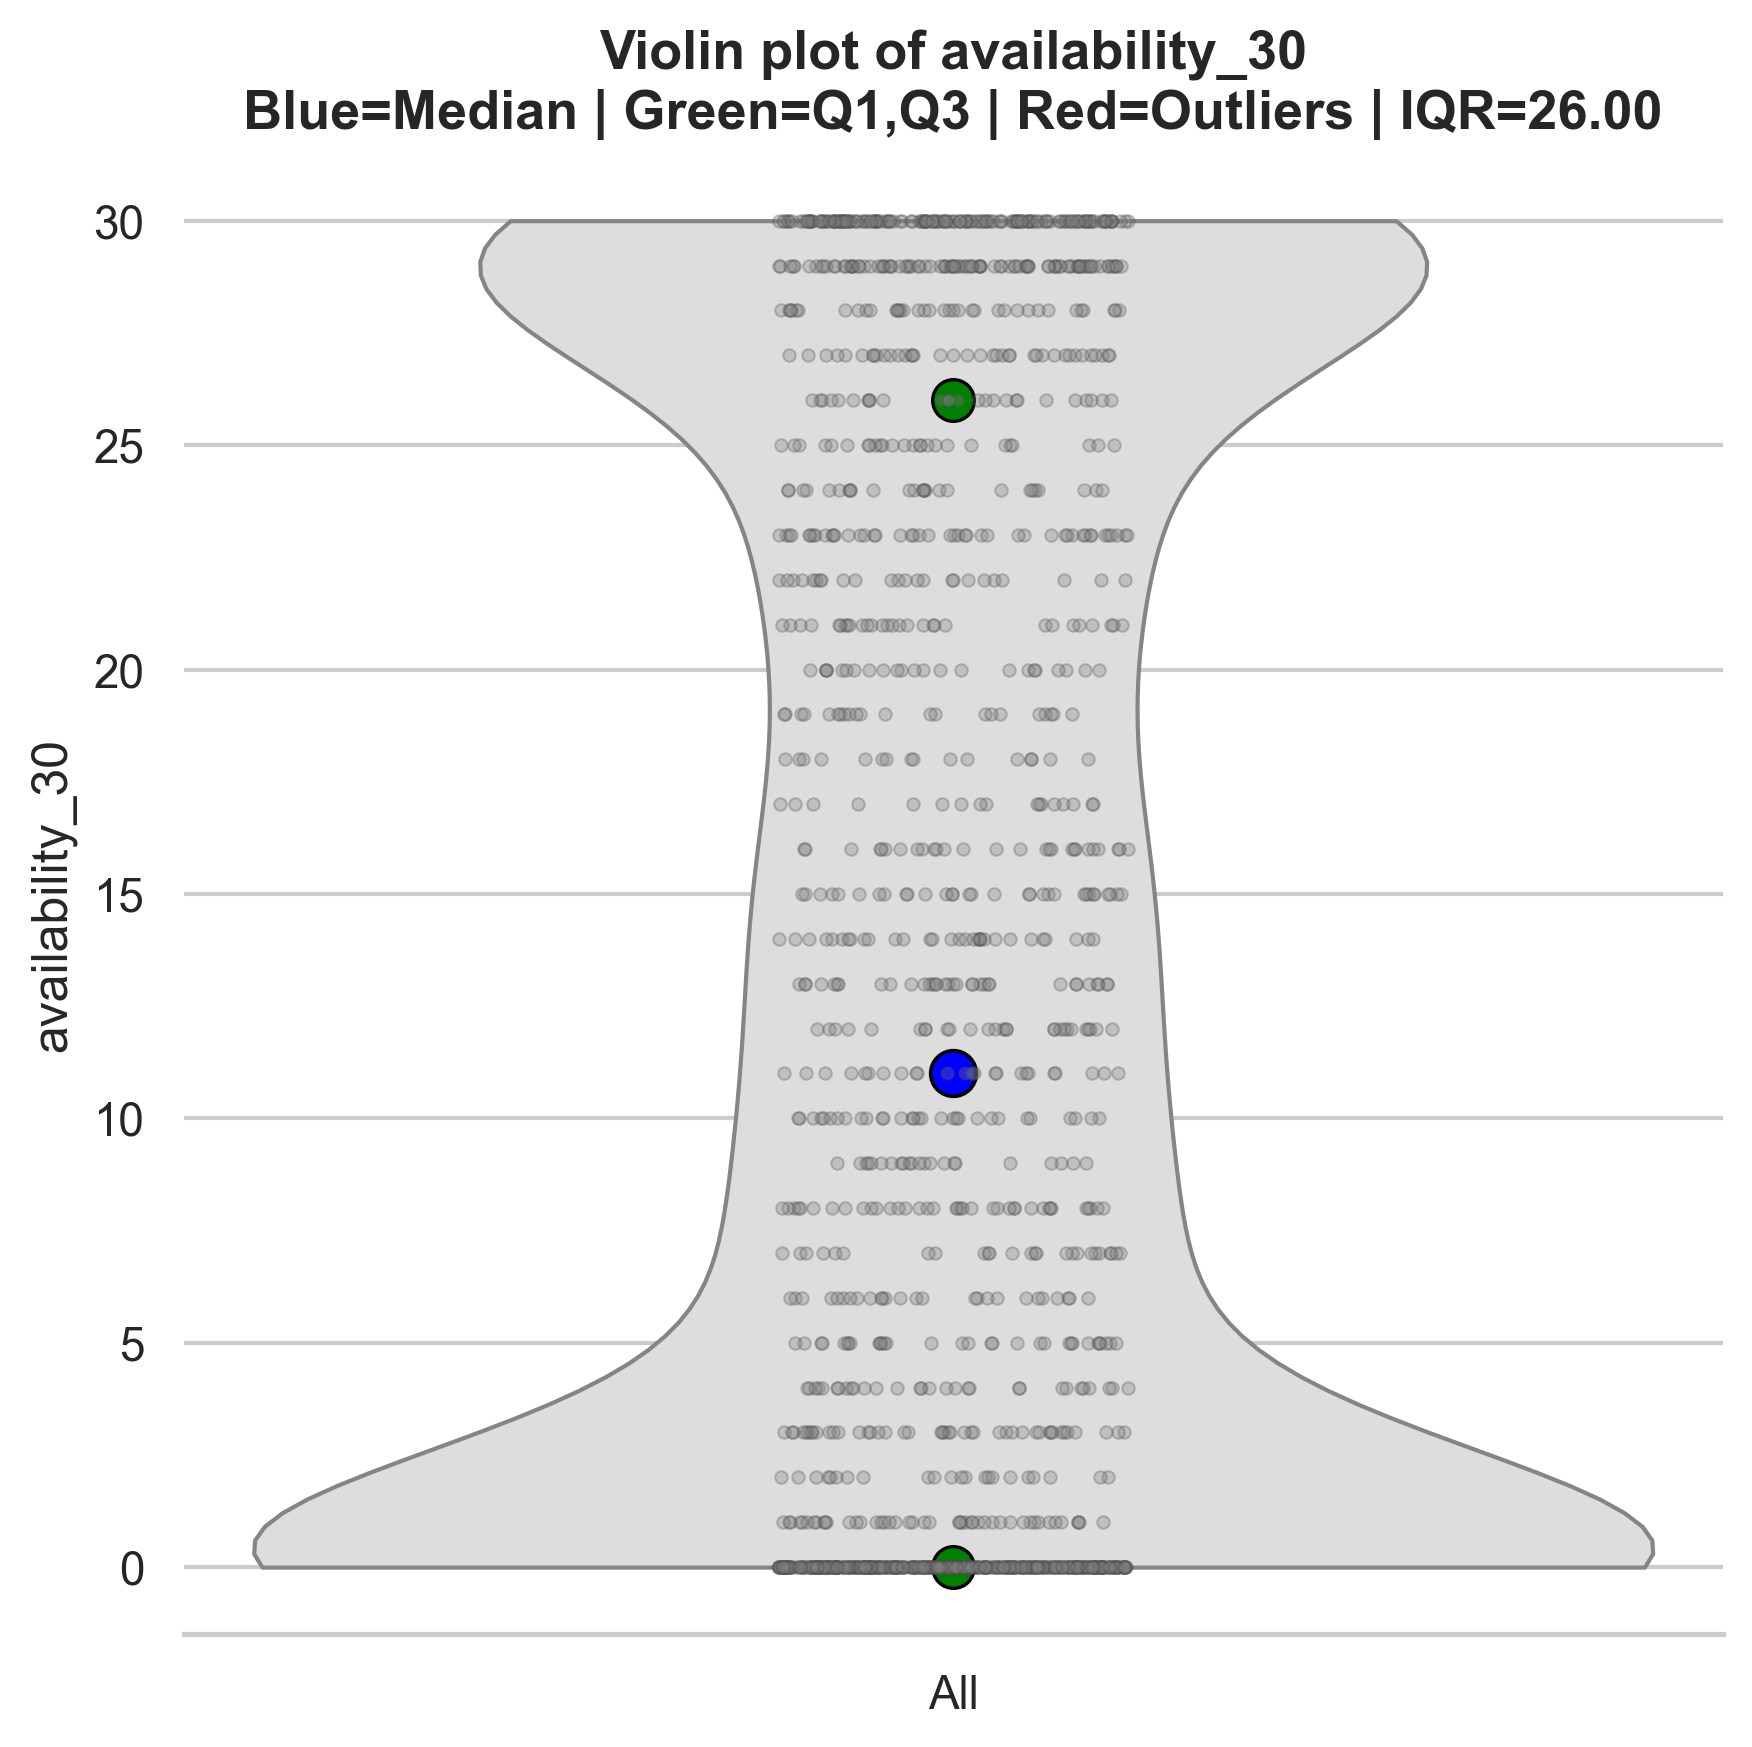

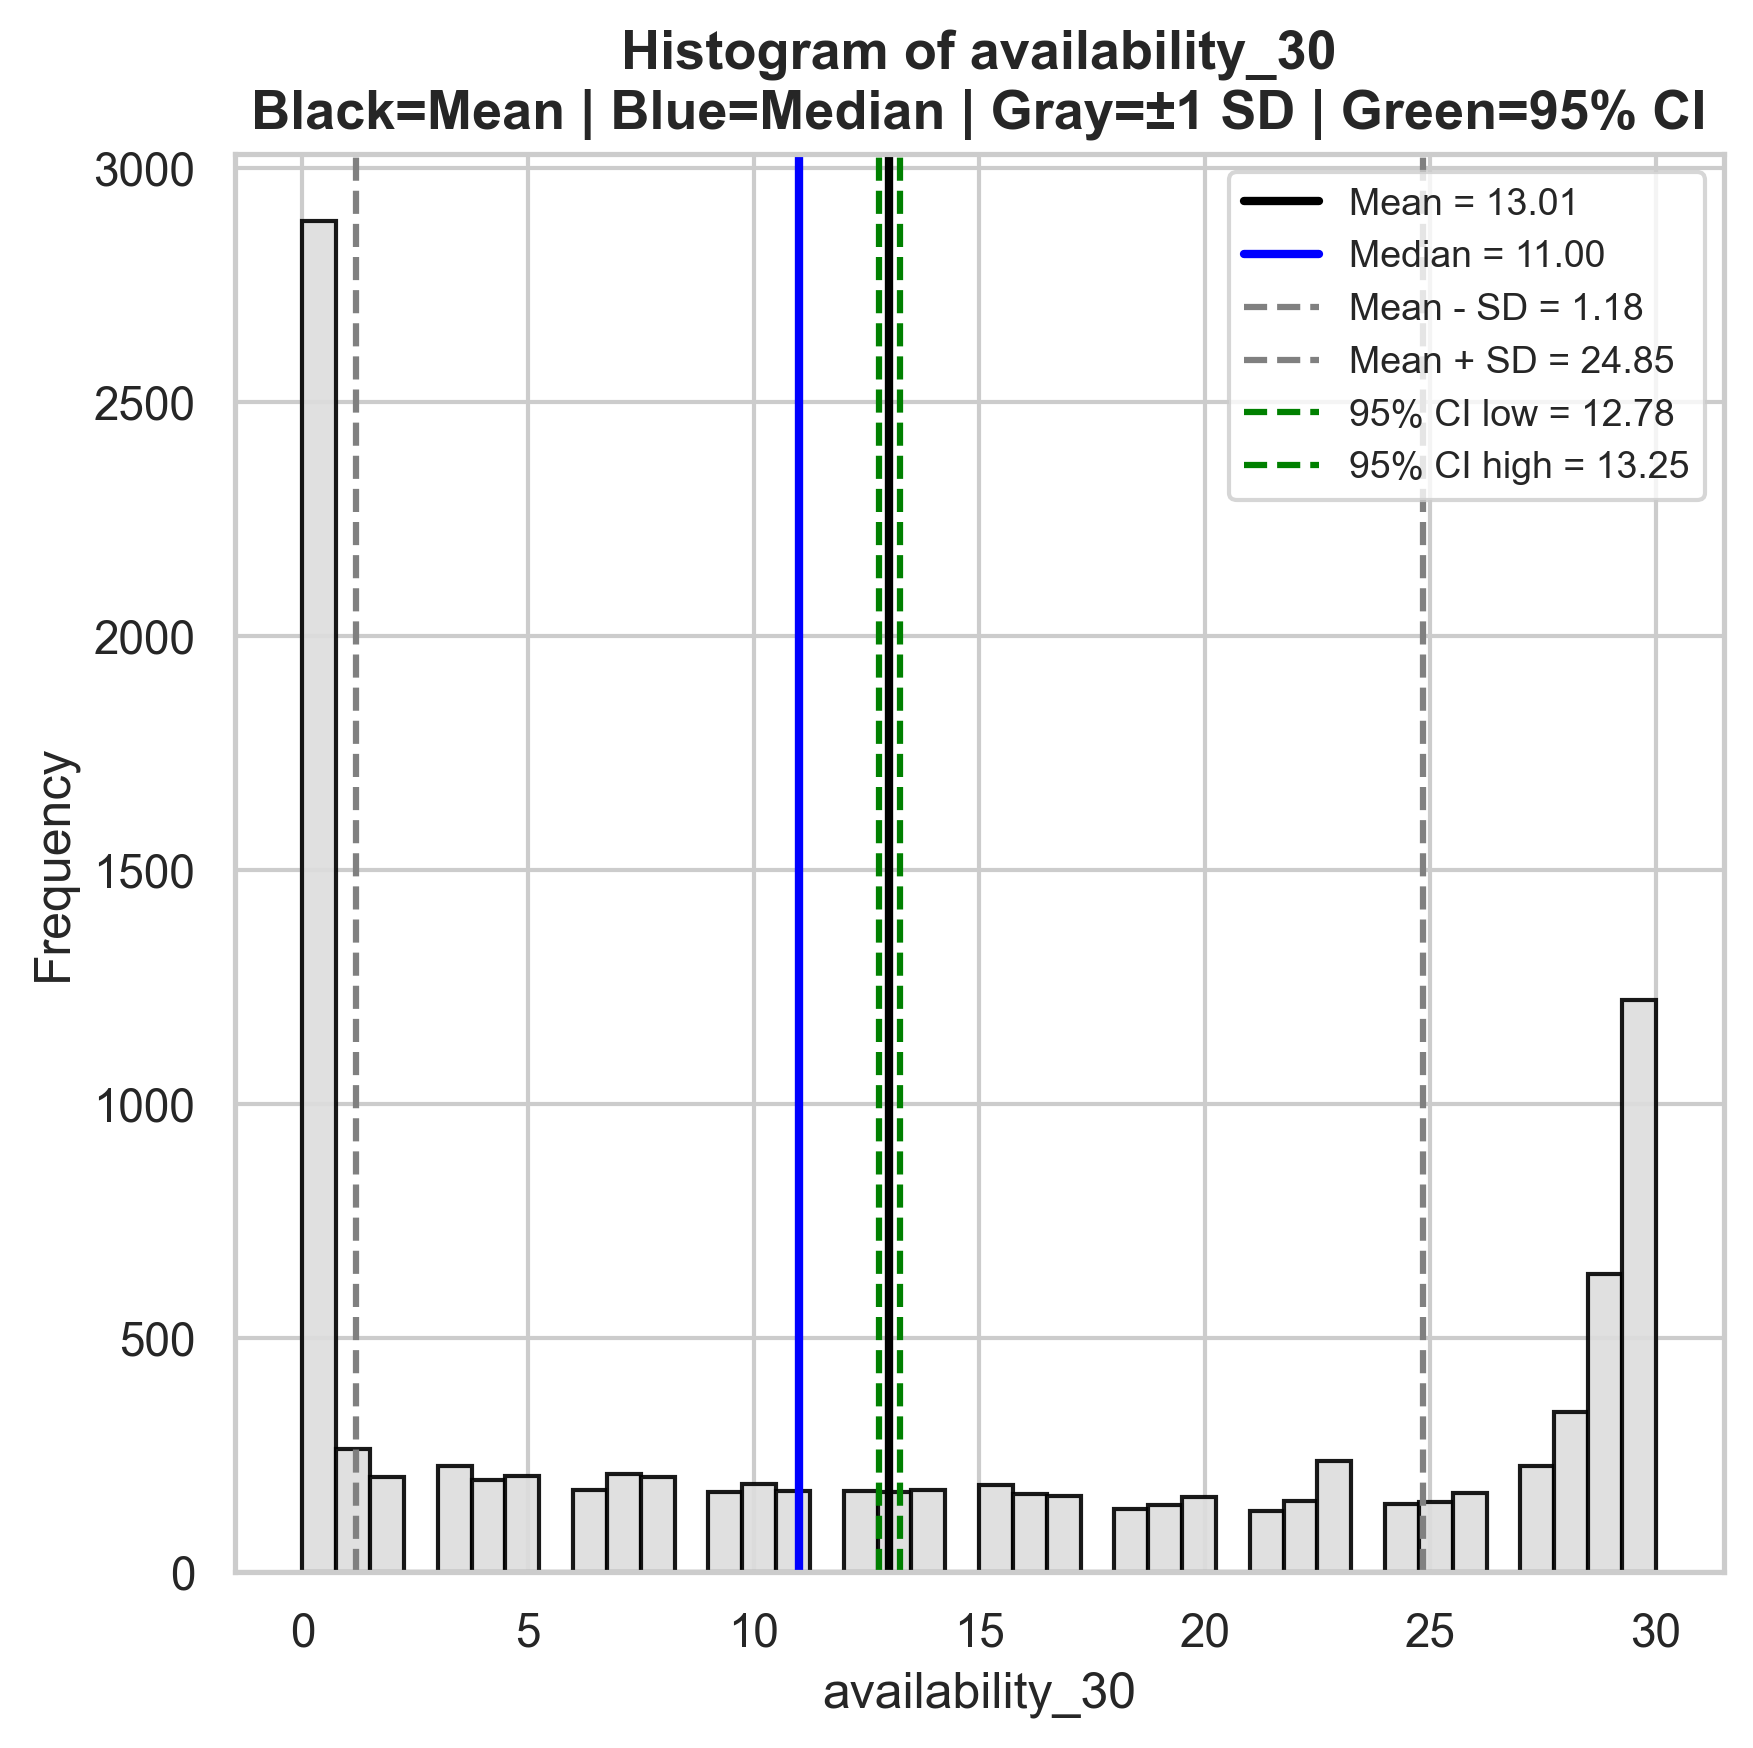

All files saved locally

Summary statistics


,column,n_non_null_numeric,mean,median,std,ci95_low,ci95_high,q1,q3,iqr,lower_fence,upper_fence,outlier_count,skewness,skewness_interpretation
0,availability_30,10000,13.0133,11.0,11.83514,12.781307,13.245293,0.0,26.0,26.0,-39.0,65.0,0,0.241535,Approximately symmetric.



Unique values table
Number of non-nulls: 10000
Number of unique values: 31


,column,value,count,frequency_non_null
0,availability_30,0,2887,0.2887
1,availability_30,1,263,0.0263
2,availability_30,2,204,0.0204
3,availability_30,3,227,0.0227
4,availability_30,4,198,0.0198
5,availability_30,5,205,0.0205
6,availability_30,6,176,0.0176
7,availability_30,7,211,0.0211
8,availability_30,8,204,0.0204
9,availability_30,9,172,0.0172



Correlation table


,target_column,target_type,other_column,other_type,test,statistic,p_value,significance,significance_interpretation,note
0,availability_30,numeric,neighbourhood_name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
1,availability_30,numeric,neighbourhood_district,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
2,availability_30,numeric,city,categorical,Chi-square,272.279456,1.333365e-45,Significant,Statistically significant at p < 0.05.,
3,availability_30,numeric,room_type,categorical,Chi-square,77.290262,5.570460e-13,Significant,Statistically significant at p < 0.05.,
4,availability_30,numeric,accommodates,numeric,Pearson,0.071241,9.875625e-13,Significant,Statistically significant at p < 0.05.,
5,availability_30,numeric,bathrooms,numeric,Pearson,0.053060,1.227257e-07,Significant,Statistically significant at p < 0.05.,
6,availability_30,numeric,bedrooms,numeric,Pearson,0.054719,4.866524e-08,Significant,Statistically significant at p < 0.05.,
7,availability_30,numeric,beds,numeric,Pearson,0.073071,2.889647e-13,Significant,Statistically significant at p < 0.05.,
8,availability_30,numeric,price,numeric,Pearson,0.074978,1.249537e-13,Significant,Statistically significant at p < 0.05.,
9,availability_30,numeric,minimum_nights,numeric,Pearson,-0.003330,7.391879e-01,Not significant,Not statistically significant at p < 0.05.,



Transformation skewness table


,method,skewness,interpretation,normality_improvement
0,Original,0.241535,Approximately symmetric.,Baseline.
1,Log Transformation,-0.420394,Approximately symmetric.,Did not improve normality; skewness increased.
2,Square Root Transformation,-0.223095,Approximately symmetric.,Little change in skewness.
3,Box-Cox Transformation,-0.224924,Approximately symmetric.,Little change in skewness. Improved using lamb...


In [129]:
analysis = analyze_single_field(
    df, target_col="availability_30", results_dir=RESULTS_DIR, show_in_notebook=True
)

*Recommendations for Availability 30*:
- mediana: 11.0
- IQR=26.0 [0.0; 26.0]
- no outliers determined
- Even though Skewness demonstrates symmetric distribution with two modas (0 and 30), Kurtuosis must be checked due to Min and Max values accumulation:
    * Min=0 - 28,9% of values; 
    * Max=[27; 30] - 18,6% of values
- Must be interpreted as categorical parameter
- consider:
    * strongly and significantly associated with: city, room_type, is_instant_bookable
    * strongly and significantly correlated with: availability_60 (r=0.93) and availability_90 (r=0.86)
    * medium and significantly correlated with: availability_365 (r=0.52)
    * absence of correlation with: all other parameters
- Non-parametric tests for association should be applied

<Axes: xlabel='room_type', ylabel='city'>

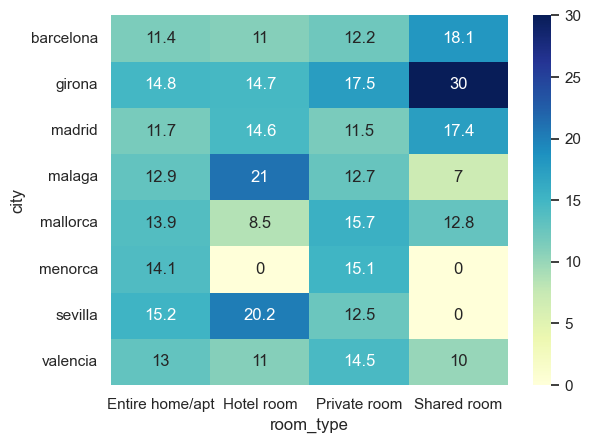

In [130]:
sns.heatmap(
    df.groupby(["city", "room_type"])["availability_30"]
    .mean()
    .round(1)
    .unstack(fill_value=0),
    annot=True,
    cmap="YlGnBu",
    fmt="g",
)

##### Availability 60 days

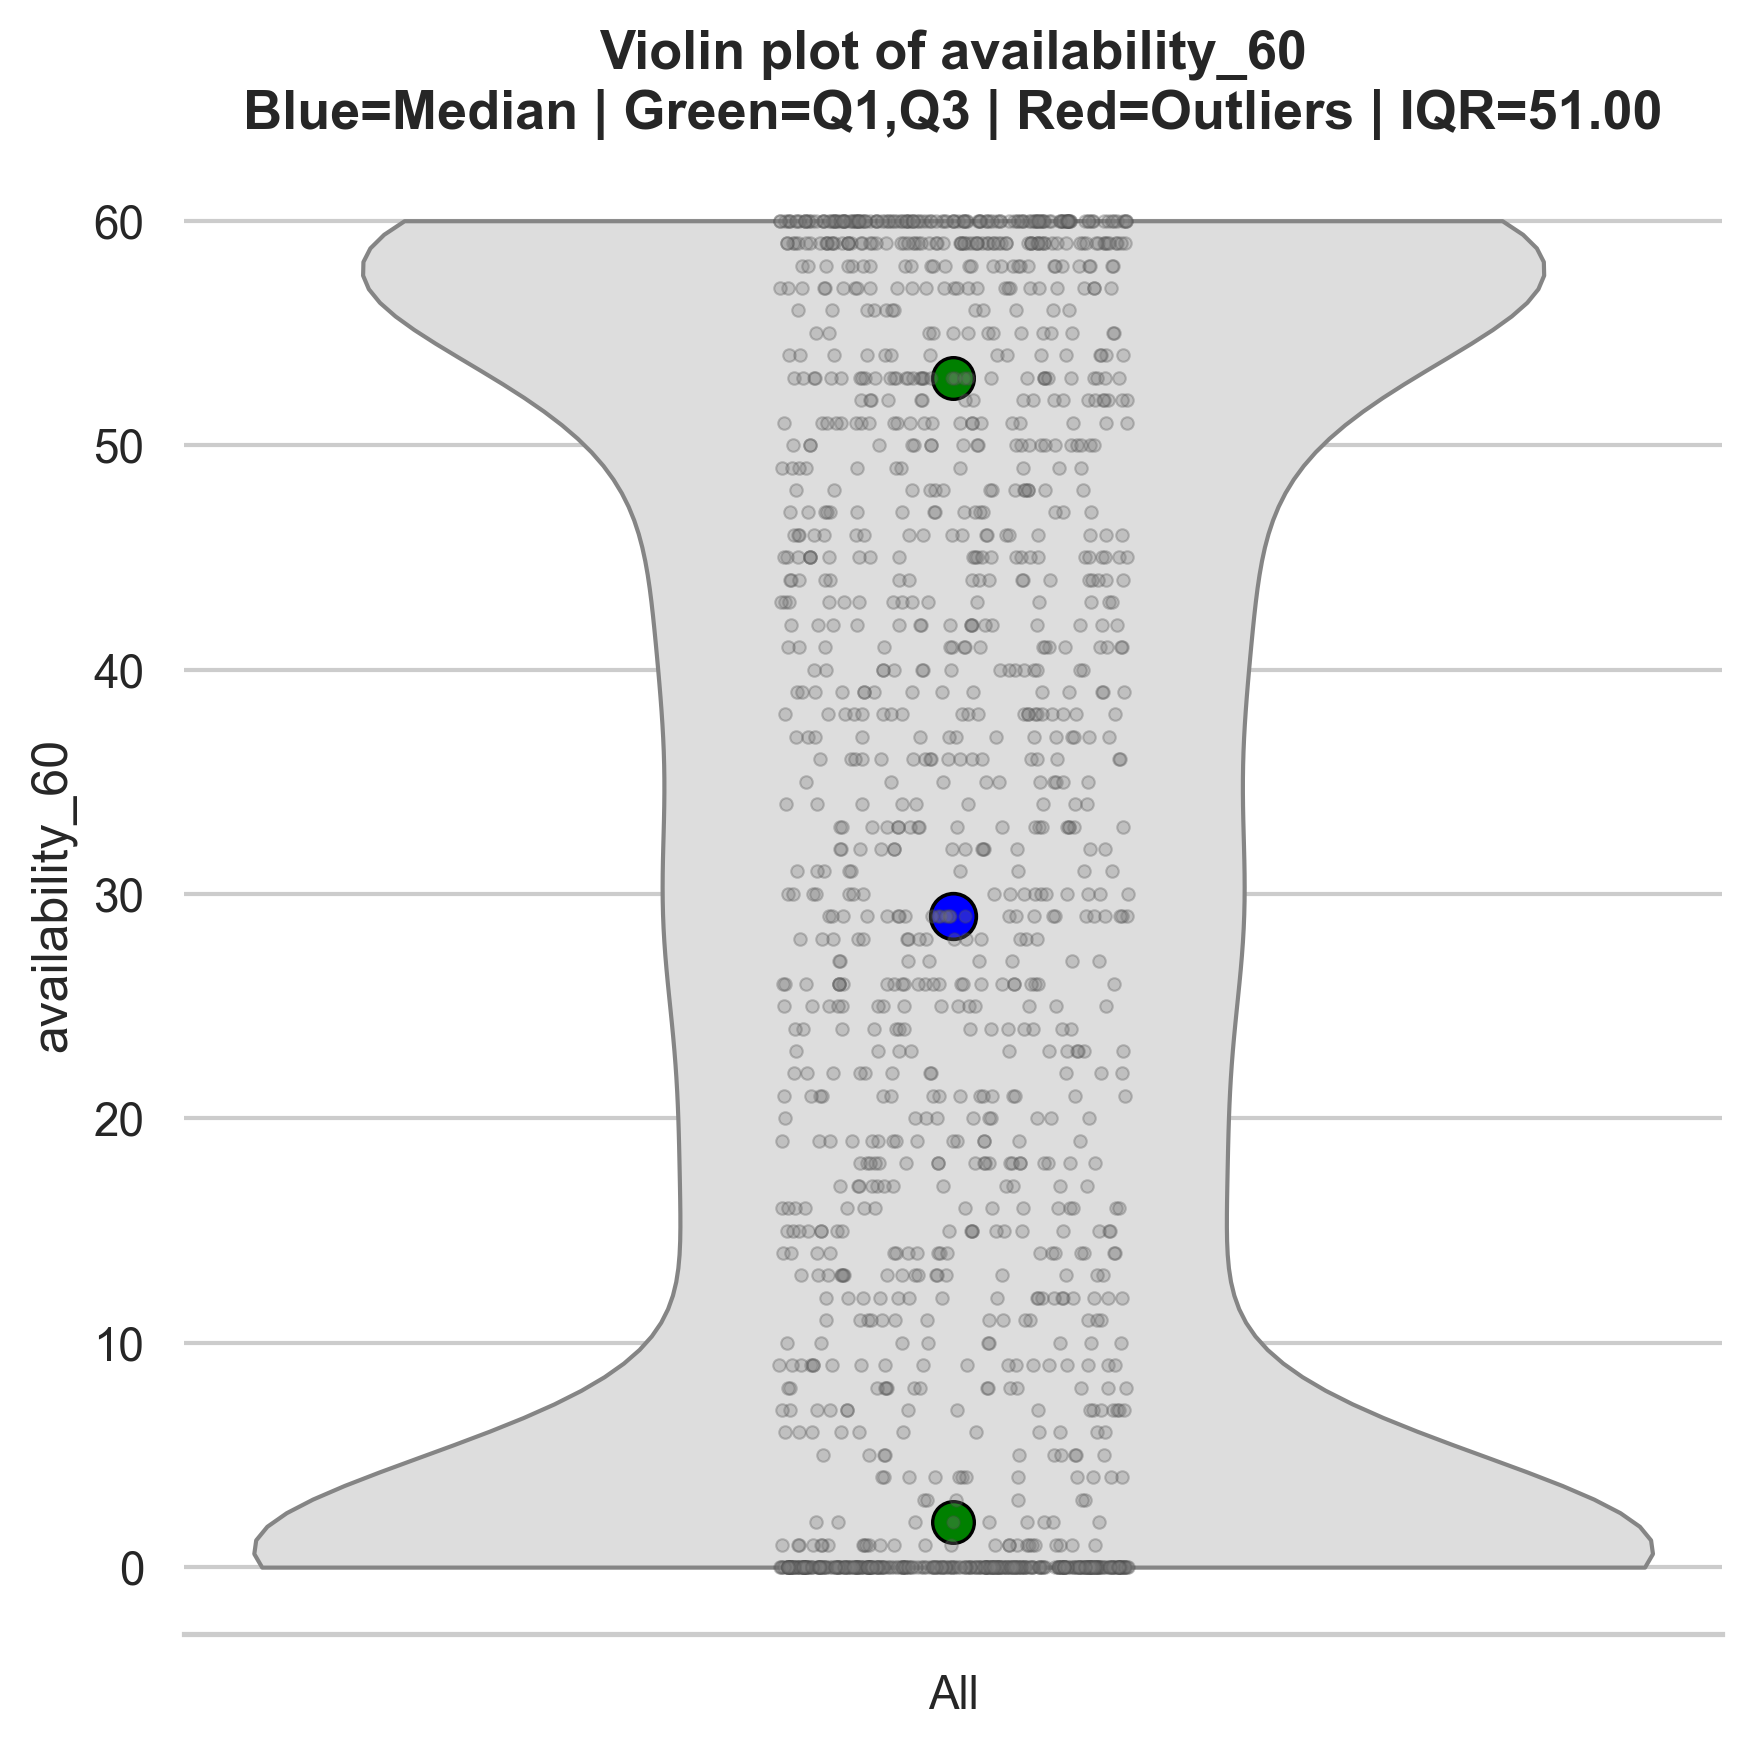

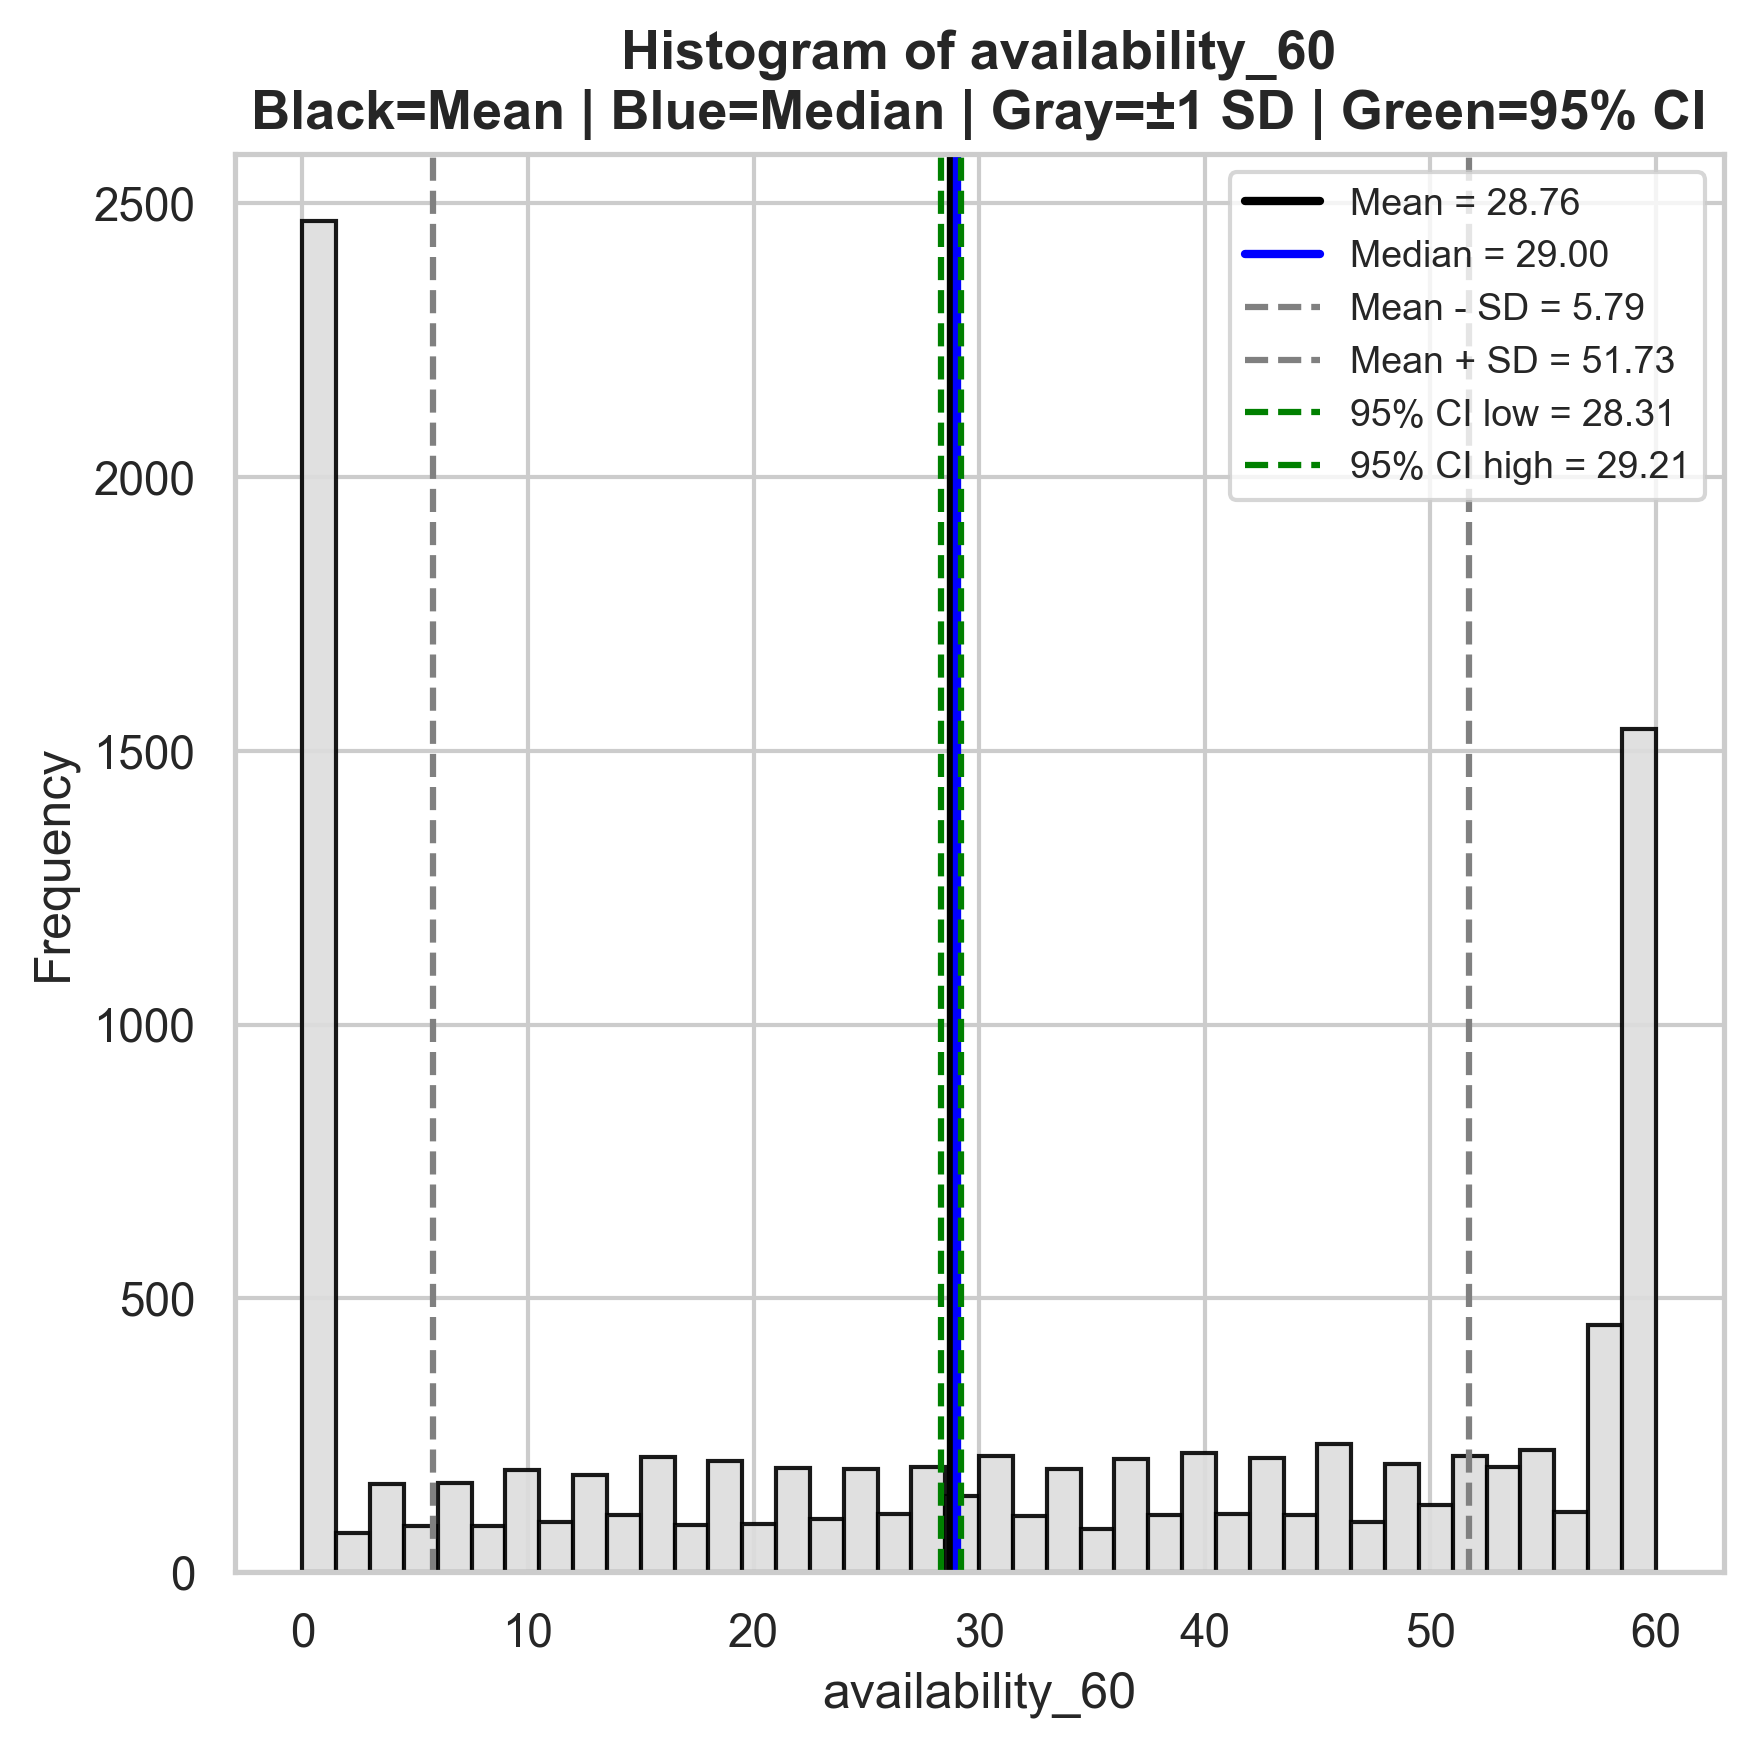

All files saved locally

Summary statistics


,column,n_non_null_numeric,mean,median,std,ci95_low,ci95_high,q1,q3,iqr,lower_fence,upper_fence,outlier_count,skewness,skewness_interpretation
0,availability_60,10000,28.7593,29.0,22.972034,28.309002,29.209598,2.0,53.0,51.0,-74.5,129.5,0,0.030203,Approximately symmetric.



Unique values table
Number of non-nulls: 10000
Number of unique values: 61


,column,value,count,frequency_non_null
0,availability_60,0,2306,0.2306
1,availability_60,1,161,0.0161
2,availability_60,2,72,0.0072
3,availability_60,3,79,0.0079
4,availability_60,4,83,0.0083
...,...,...,...,...
56,availability_60,56,110,0.0110
57,availability_60,57,178,0.0178
58,availability_60,58,274,0.0274
59,availability_60,59,518,0.0518



Correlation table


,target_column,target_type,other_column,other_type,test,statistic,p_value,significance,significance_interpretation,note
0,availability_60,numeric,neighbourhood_name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
1,availability_60,numeric,neighbourhood_district,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
2,availability_60,numeric,city,categorical,Chi-square,190.413770,2.756090e-29,Significant,Statistically significant at p < 0.05.,
3,availability_60,numeric,room_type,categorical,Chi-square,135.462003,8.904260e-25,Significant,Statistically significant at p < 0.05.,
4,availability_60,numeric,accommodates,numeric,Pearson,0.060035,1.876137e-09,Significant,Statistically significant at p < 0.05.,
5,availability_60,numeric,bathrooms,numeric,Pearson,0.035743,3.683688e-04,Significant,Statistically significant at p < 0.05.,
6,availability_60,numeric,bedrooms,numeric,Pearson,0.035555,3.946116e-04,Significant,Statistically significant at p < 0.05.,
7,availability_60,numeric,beds,numeric,Pearson,0.055999,2.258251e-08,Significant,Statistically significant at p < 0.05.,
8,availability_60,numeric,price,numeric,Pearson,0.067144,3.239868e-11,Significant,Statistically significant at p < 0.05.,
9,availability_60,numeric,minimum_nights,numeric,Pearson,-0.004940,6.213786e-01,Not significant,Not statistically significant at p < 0.05.,



Transformation skewness table


,method,skewness,interpretation,normality_improvement
0,Original,0.030203,Approximately symmetric.,Baseline.
1,Log Transformation,-0.798722,Moderately skewed.,Did not improve normality; skewness increased.
2,Square Root Transformation,-0.482473,Approximately symmetric.,Did not improve normality; skewness increased.
3,Box-Cox Transformation,-0.408408,Approximately symmetric.,Did not improve normality; skewness increased....


In [131]:
analysis = analyze_single_field(
    df, target_col="availability_60", results_dir=RESULTS_DIR, show_in_notebook=True
)

*Recommendations for Availability 60*:
- mediana: 29.0
- IQR=51.0 [2.0; 53.0]
- no outliers determined
- Even though Skewness demonstrates symmetric distribution with two modas (0 and 60), Kurtuosis must be checked due to Min and Max values accumulation:
    * Min=0 - 23,0 % of values; 
    * Max=[59; 60] - 15,4 % of values
- consider:
    * strongly and significantly associated with: city, room_type, is_instant_bookable
    * strongly and significantly correlated with: availability_30 (r=0.93) and availability_90 (r=0.97)
    * medium and significantly correlated with: availability_365 (r=0.59)
    * absence of correlation with: all other parameters
- Non-parametric tests for association should be applied

<Axes: xlabel='room_type', ylabel='city'>

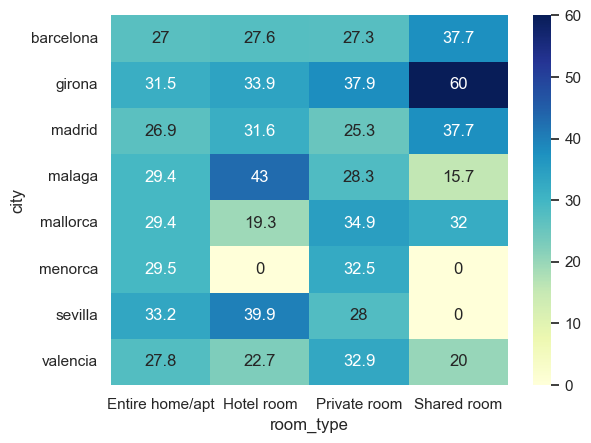

In [132]:
sns.heatmap(
    df.groupby(["city", "room_type"])["availability_60"]
    .mean()
    .round(1)
    .unstack(fill_value=0),
    annot=True,
    cmap="YlGnBu",
    fmt="g",
)

##### Availability 90 days

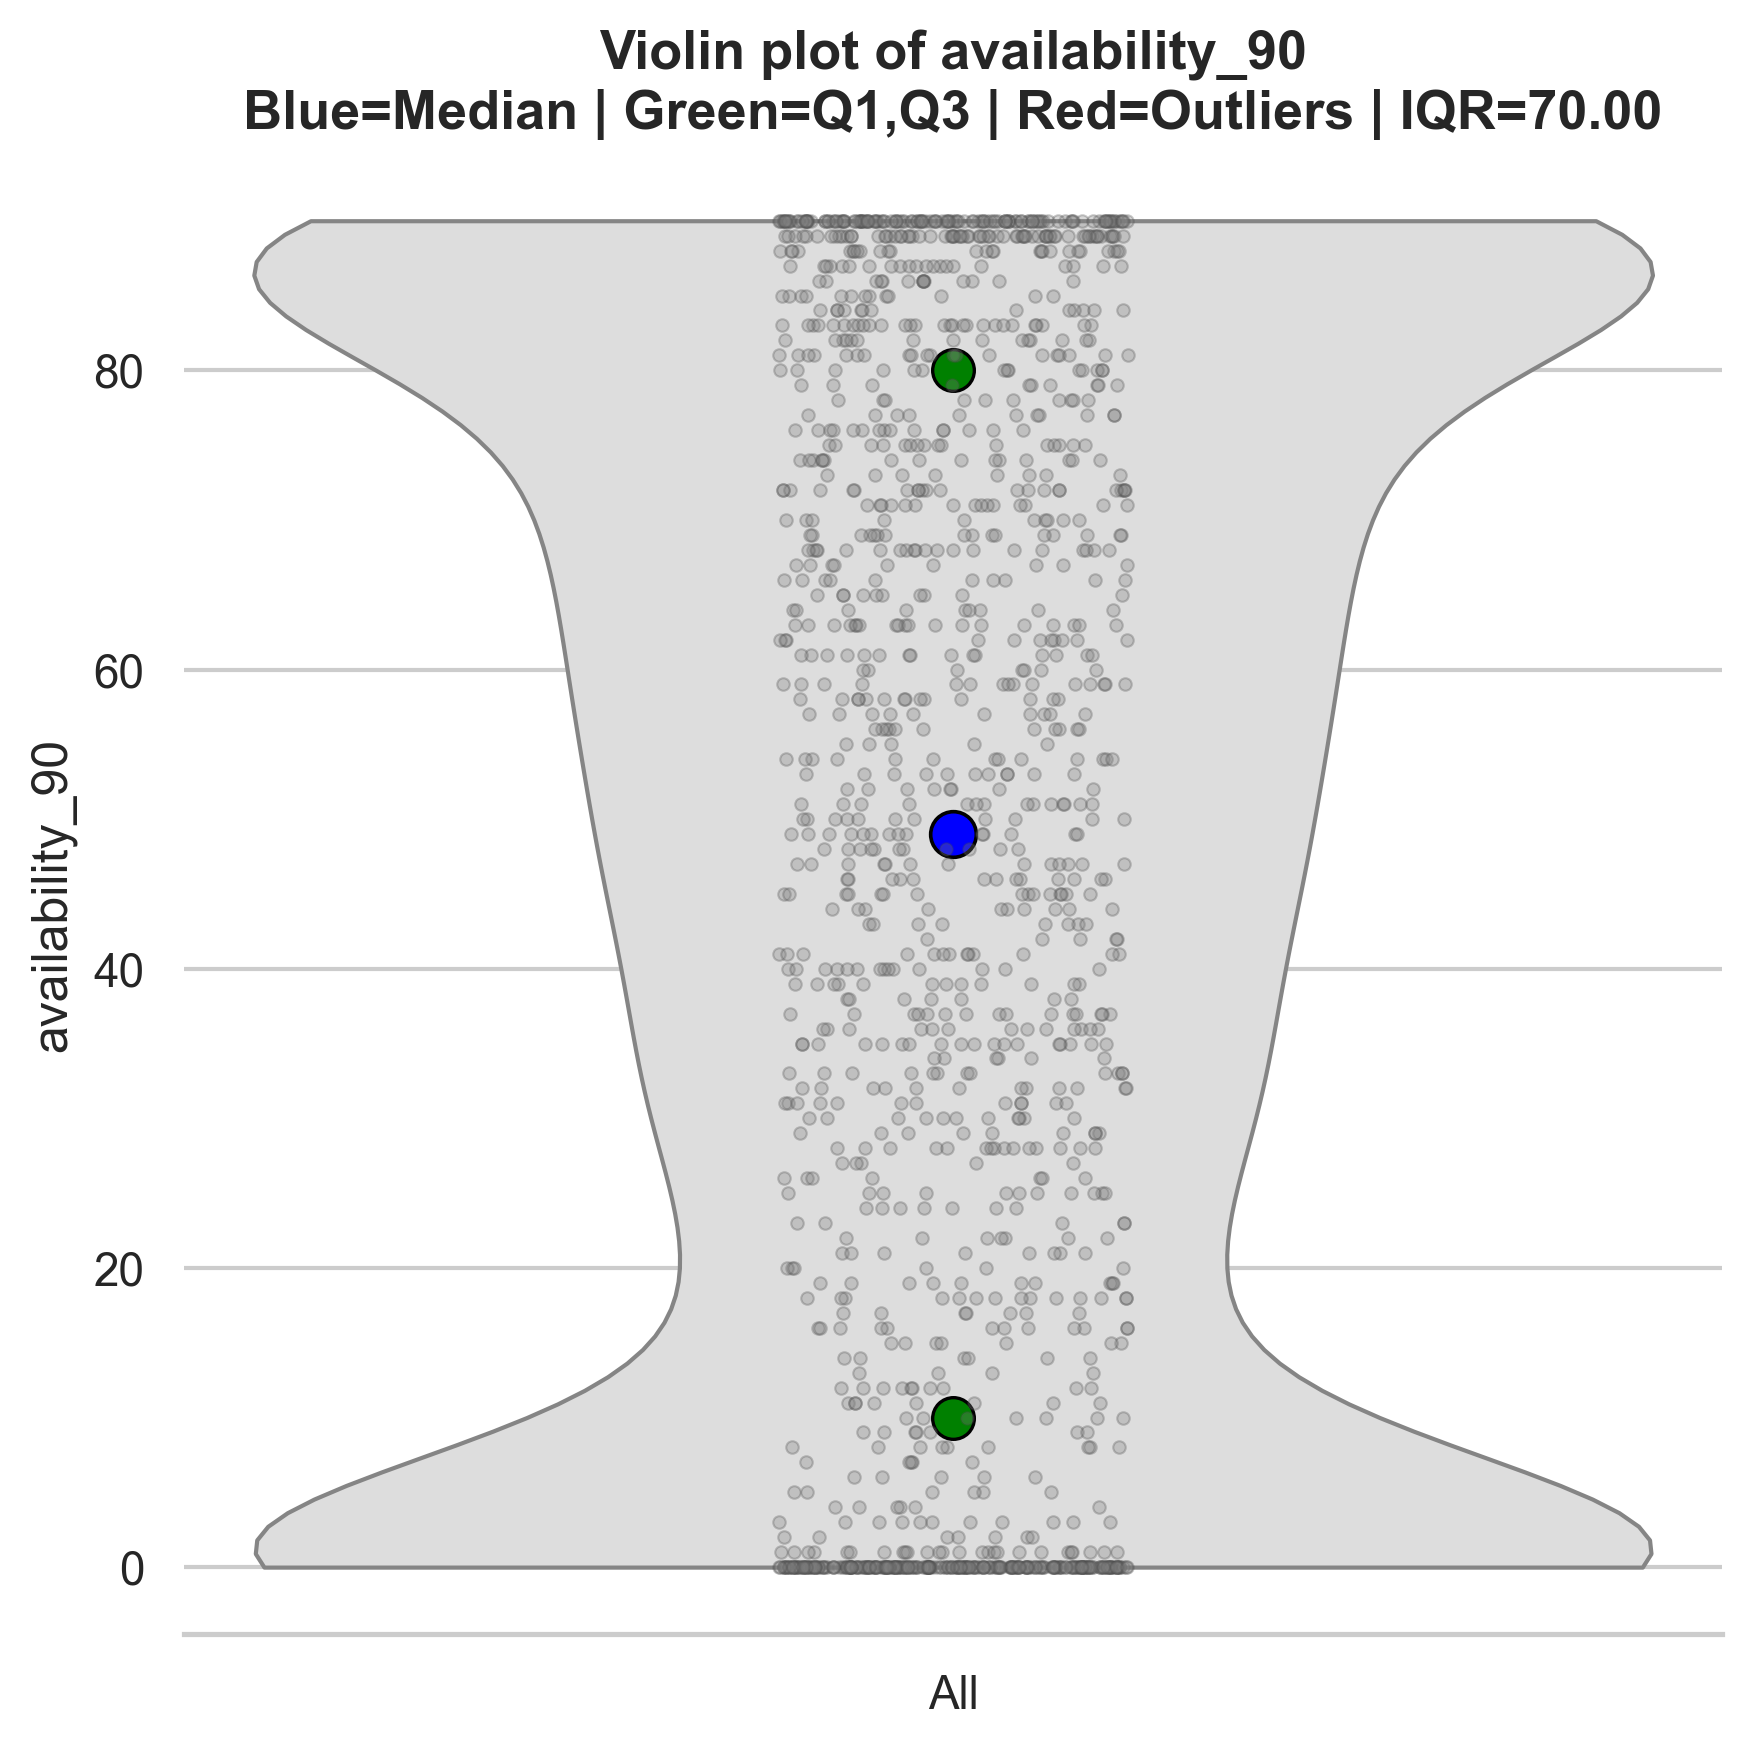

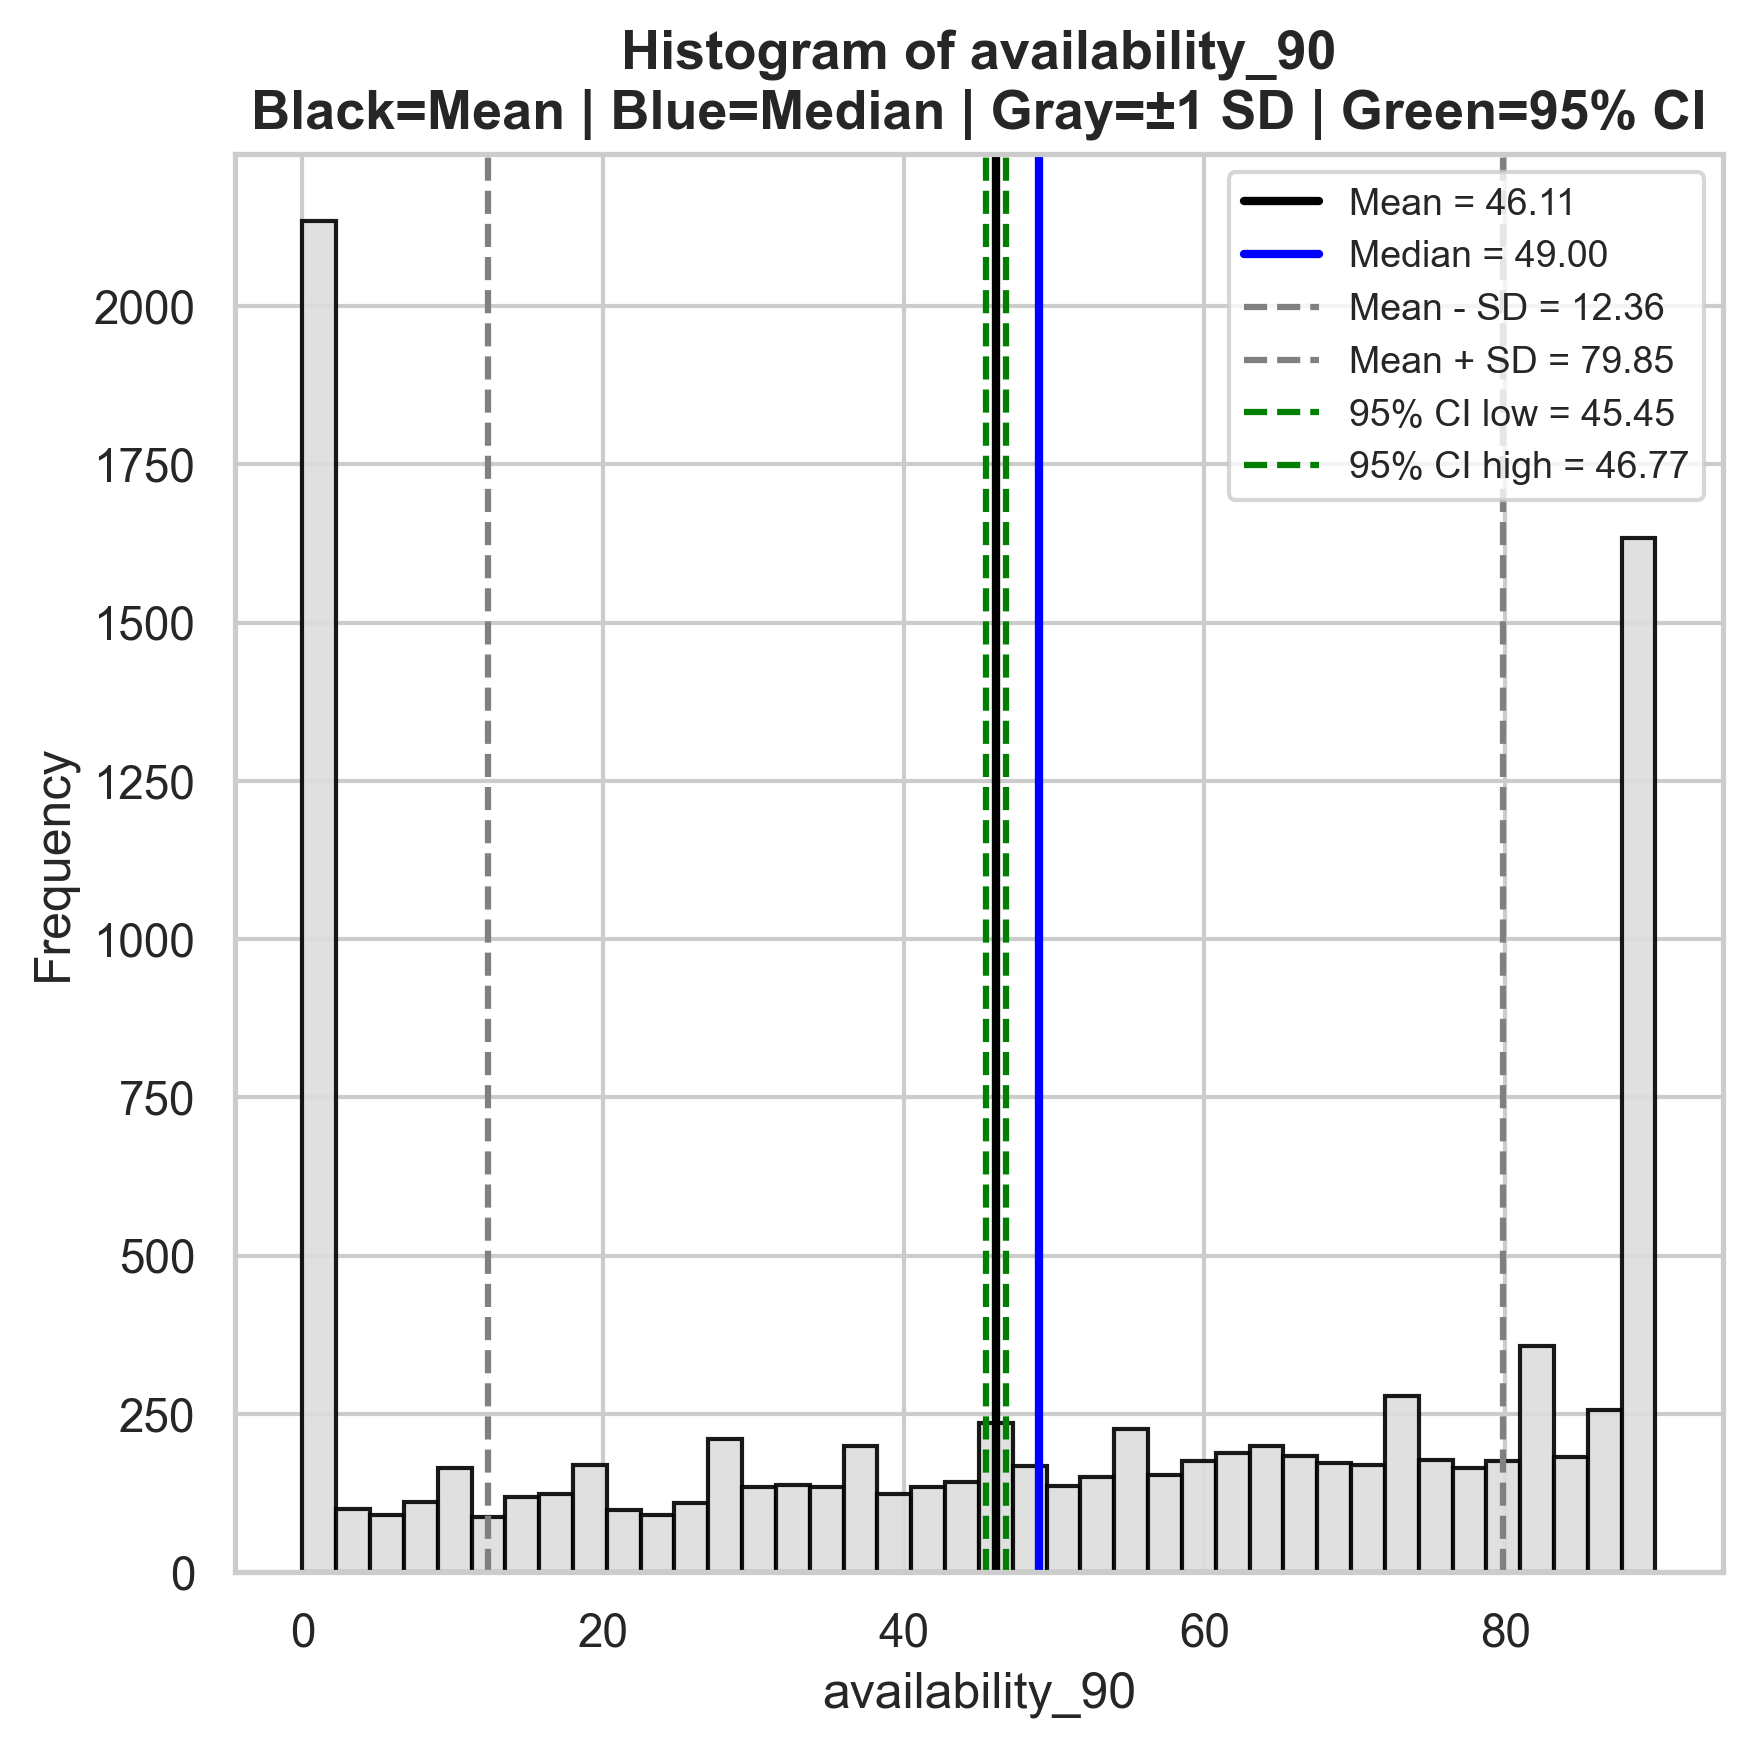

All files saved locally

Summary statistics


,column,n_non_null_numeric,mean,median,std,ci95_low,ci95_high,q1,q3,iqr,lower_fence,upper_fence,outlier_count,skewness,skewness_interpretation
0,availability_90,10000,46.1068,49.0,33.745279,45.445325,46.768275,10.0,80.0,70.0,-95.0,185.0,0,-0.12573,Approximately symmetric.



Unique values table
Number of non-nulls: 10000
Number of unique values: 91


,column,value,count,frequency_non_null
0,availability_90,0,1953,0.1953
1,availability_90,1,124,0.0124
2,availability_90,2,57,0.0057
3,availability_90,3,56,0.0056
4,availability_90,4,44,0.0044
...,...,...,...,...
86,availability_90,86,109,0.0109
87,availability_90,87,147,0.0147
88,availability_90,88,246,0.0246
89,availability_90,89,462,0.0462



Correlation table


,target_column,target_type,other_column,other_type,test,statistic,p_value,significance,significance_interpretation,note
0,availability_90,numeric,neighbourhood_name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
1,availability_90,numeric,neighbourhood_district,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
2,availability_90,numeric,city,categorical,Chi-square,196.827142,2.727336e-27,Significant,Statistically significant at p < 0.05.,
3,availability_90,numeric,room_type,categorical,Chi-square,255.733484,8.708996e-48,Significant,Statistically significant at p < 0.05.,
4,availability_90,numeric,accommodates,numeric,Pearson,0.049035,9.301462e-07,Significant,Statistically significant at p < 0.05.,
5,availability_90,numeric,bathrooms,numeric,Pearson,0.021028,3.617364e-02,Significant,Statistically significant at p < 0.05.,
6,availability_90,numeric,bedrooms,numeric,Pearson,0.020176,4.437721e-02,Significant,Statistically significant at p < 0.05.,
7,availability_90,numeric,beds,numeric,Pearson,0.041143,4.020624e-05,Significant,Statistically significant at p < 0.05.,
8,availability_90,numeric,price,numeric,Pearson,0.059569,3.975946e-09,Significant,Statistically significant at p < 0.05.,
9,availability_90,numeric,minimum_nights,numeric,Pearson,-0.002326,8.160603e-01,Not significant,Not statistically significant at p < 0.05.,



Transformation skewness table


,method,skewness,interpretation,normality_improvement
0,Original,-0.125730,Approximately symmetric.,Baseline.
1,Log Transformation,-1.045461,Highly skewed.,Did not improve normality; skewness increased.
2,Square Root Transformation,-0.659452,Moderately skewed.,Did not improve normality; skewness increased.
3,Box-Cox Transformation,-0.521353,Moderately skewed.,Did not improve normality; skewness increased....


In [133]:
analysis = analyze_single_field(
    df, target_col="availability_90", results_dir=RESULTS_DIR, show_in_notebook=True
)

*Recommendations for Availability 90*:
- mediana: 49.0
- IQR=70.0 [10.0; 80.0]
- no outliers determined
- Even though Skewness demonstrates symmetric distribution with two modas (0 and 90), Kurtuosis must be checked due to Min and Max values accumulation:
    * Min=0 - 19,5 % of values; 
    * Max=[89; 90] - 13,9% of values
- consider:
    * strongly and significantly associated with: city, room_type, is_instant_bookable
    * strongly and significantly correlated with: availability_30 (r=0.85) and availability_60 (r=0.96)
    * medium and significantly correlated with: availability_365 (r=0.64)
    * absence of correlation with: all other parameters
- Non-parametric tests for association should be applied

<Axes: xlabel='room_type', ylabel='city'>

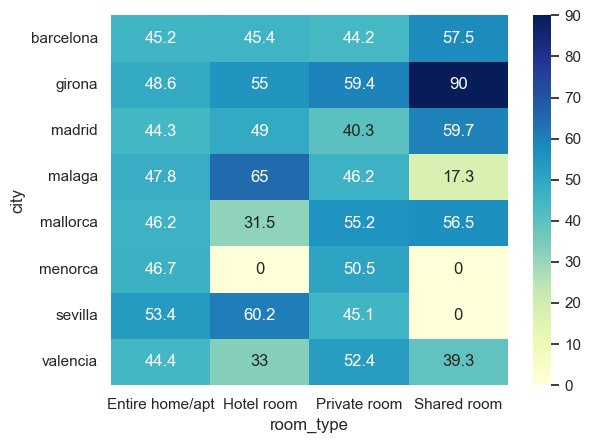

In [134]:
sns.heatmap(
    df.groupby(["city", "room_type"])["availability_90"]
    .mean()
    .round(1)
    .unstack(fill_value=0),
    annot=True,
    cmap="YlGnBu",
    fmt="g",
)

##### Availability 365 days

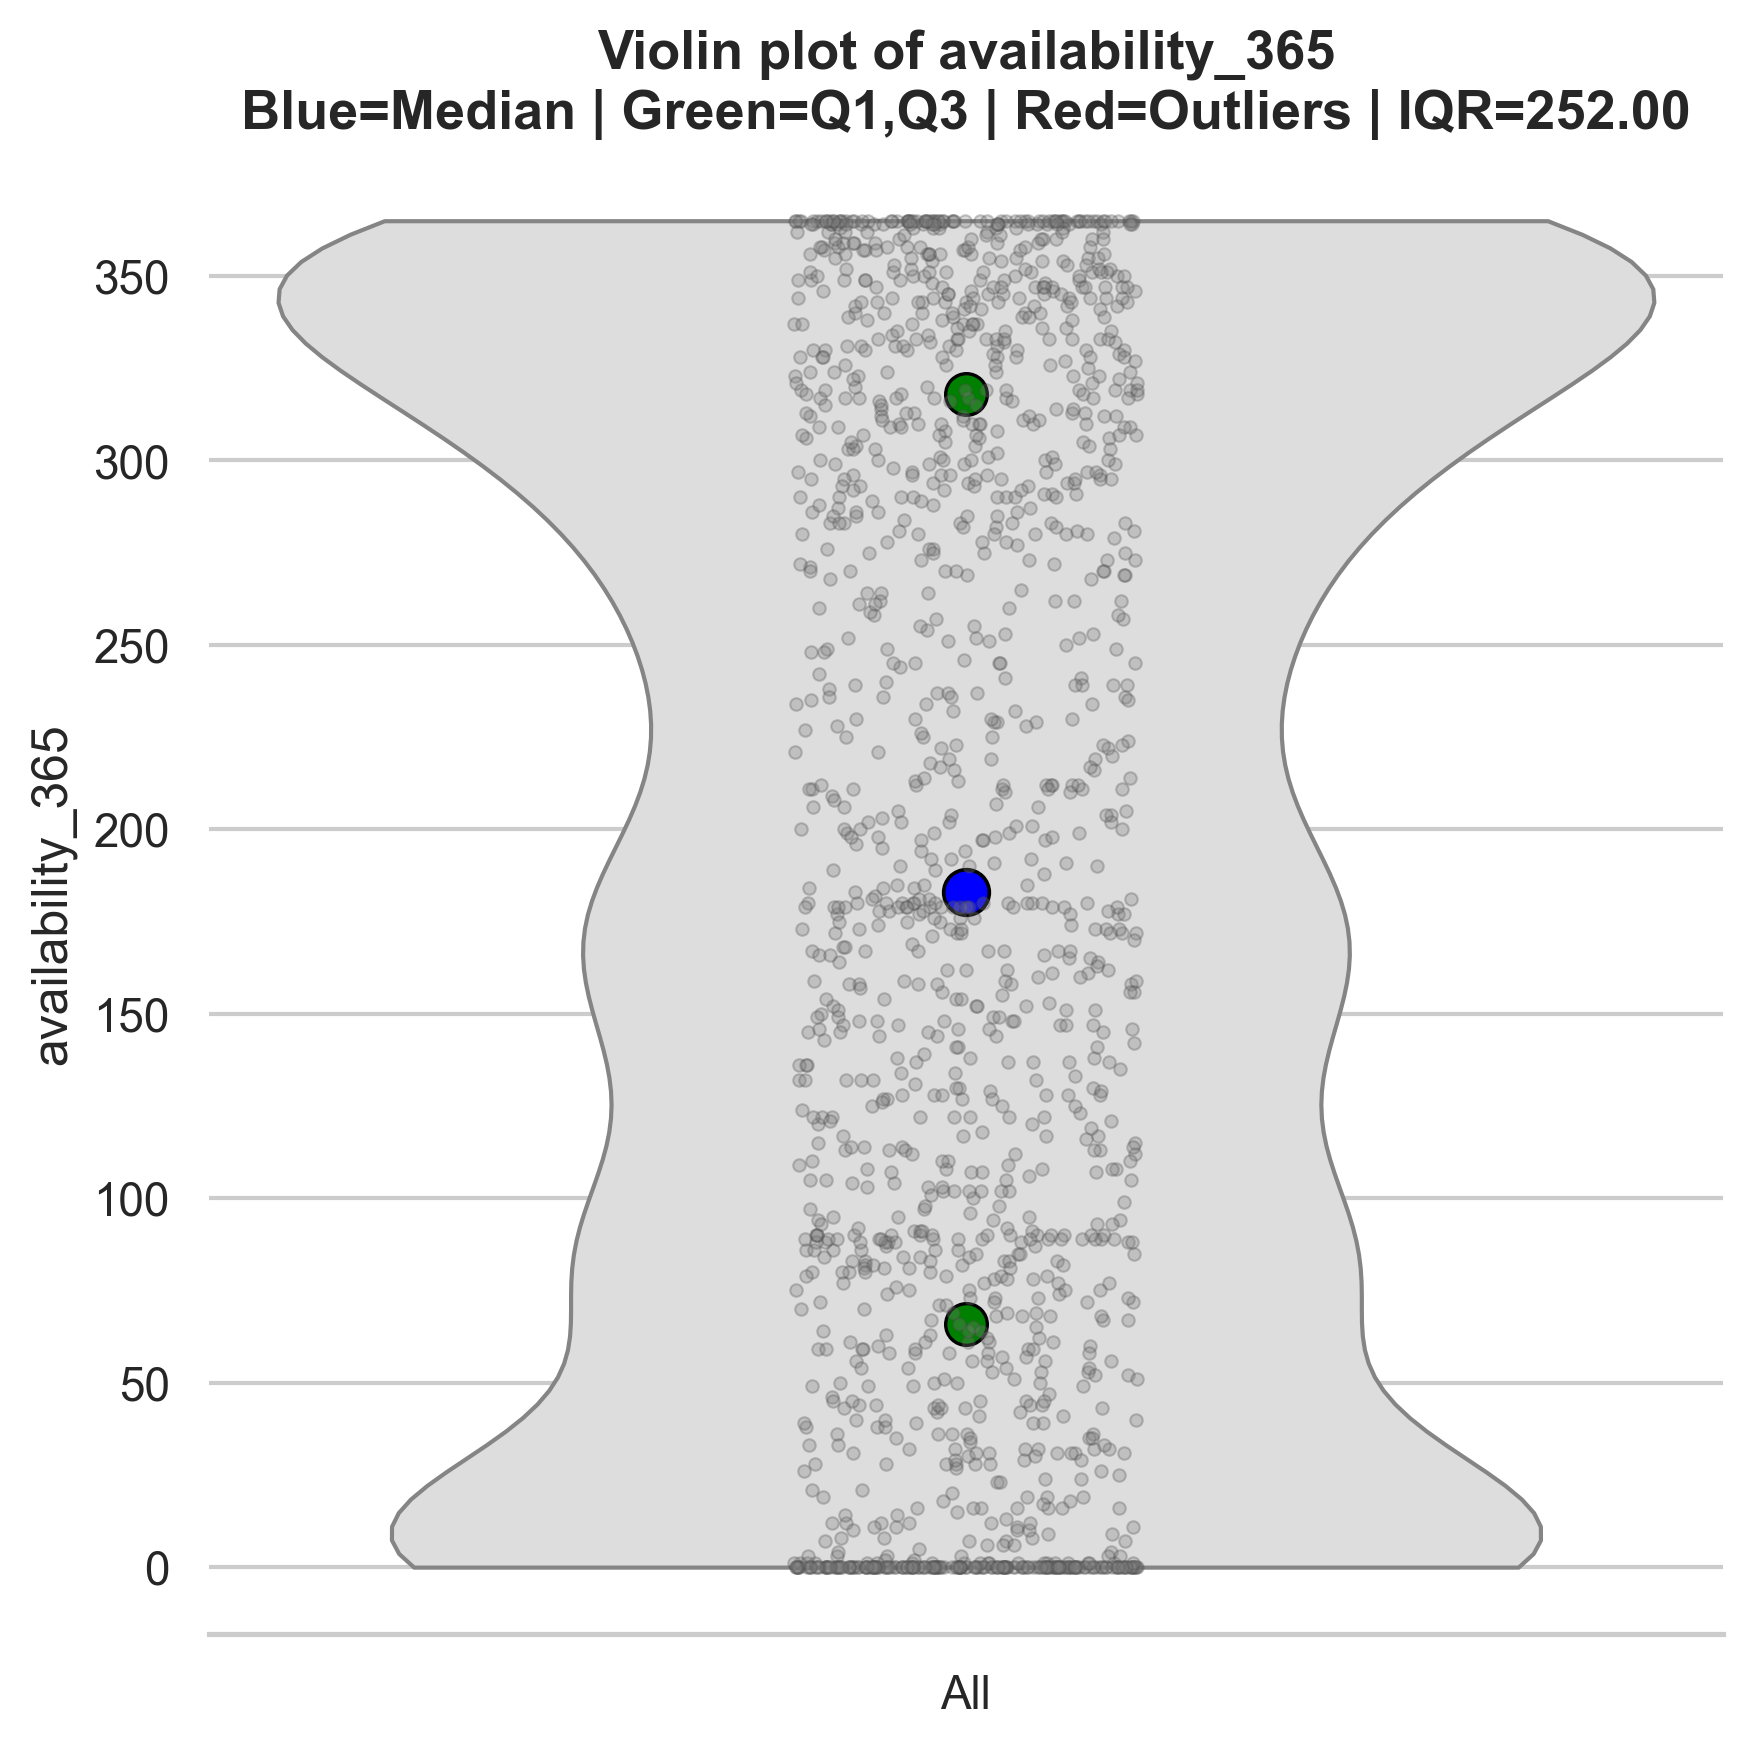

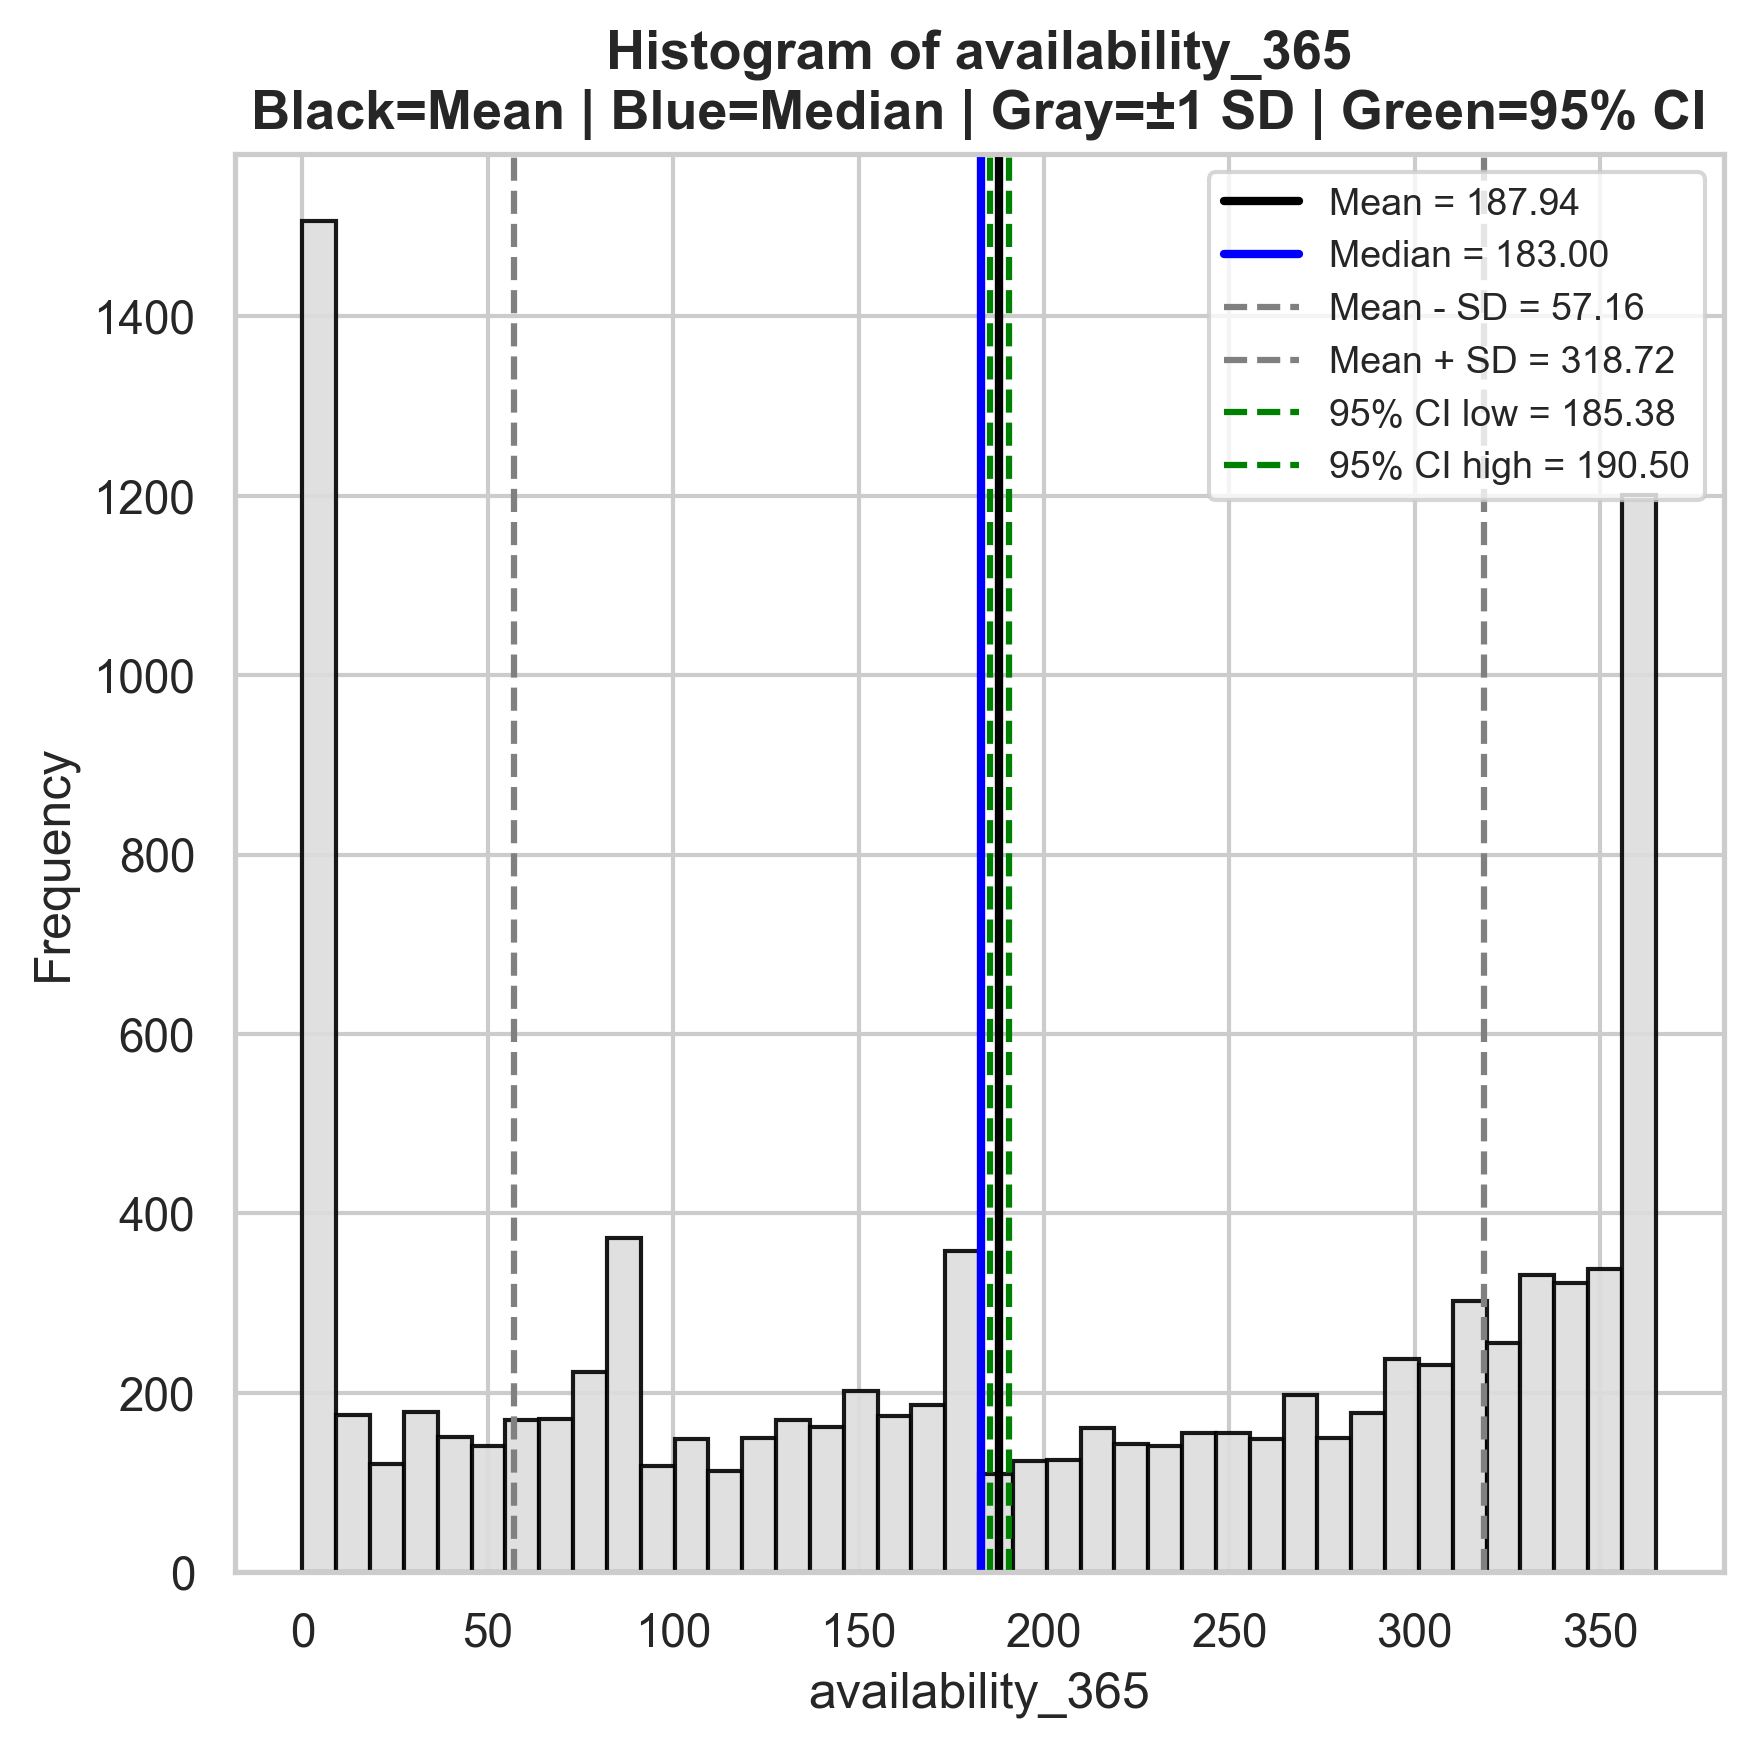

All files saved locally

Summary statistics


,column,n_non_null_numeric,mean,median,std,ci95_low,ci95_high,q1,q3,iqr,lower_fence,upper_fence,outlier_count,skewness,skewness_interpretation
0,availability_365,10000,187.9388,183.0,130.777964,185.375289,190.502311,66.0,318.0,252.0,-312.0,696.0,0,-0.08817,Approximately symmetric.



Unique values table
Number of non-nulls: 10000
Number of unique values: 366


,column,value,count,frequency_non_null
0,availability_365,0,1247,0.1247
1,availability_365,1,86,0.0086
2,availability_365,2,24,0.0024
3,availability_365,3,27,0.0027
4,availability_365,4,13,0.0013
...,...,...,...,...
361,availability_365,361,46,0.0046
362,availability_365,362,72,0.0072
363,availability_365,363,88,0.0088
364,availability_365,364,189,0.0189



Correlation table


,target_column,target_type,other_column,other_type,test,statistic,p_value,significance,significance_interpretation,note
0,availability_365,numeric,neighbourhood_name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
1,availability_365,numeric,neighbourhood_district,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
2,availability_365,numeric,city,categorical,Chi-square,339.606110,3.053837e-55,Significant,Statistically significant at p < 0.05.,
3,availability_365,numeric,room_type,categorical,Chi-square,503.898709,3.279749e-100,Significant,Statistically significant at p < 0.05.,
4,availability_365,numeric,accommodates,numeric,Pearson,0.131045,1.497094e-39,Significant,Statistically significant at p < 0.05.,
5,availability_365,numeric,bathrooms,numeric,Pearson,0.070535,1.989296e-12,Significant,Statistically significant at p < 0.05.,
6,availability_365,numeric,bedrooms,numeric,Pearson,0.098111,1.135909e-22,Significant,Statistically significant at p < 0.05.,
7,availability_365,numeric,beds,numeric,Pearson,0.124925,6.434680e-36,Significant,Statistically significant at p < 0.05.,
8,availability_365,numeric,price,numeric,Pearson,0.120446,8.005806e-33,Significant,Statistically significant at p < 0.05.,
9,availability_365,numeric,minimum_nights,numeric,Pearson,0.024909,1.273838e-02,Significant,Statistically significant at p < 0.05.,



Transformation skewness table


,method,skewness,interpretation,normality_improvement
0,Original,-0.088170,Approximately symmetric.,Baseline.
1,Log Transformation,-1.525943,Highly skewed.,Did not improve normality; skewness increased.
2,Square Root Transformation,-0.713236,Moderately skewed.,Did not improve normality; skewness increased.
3,Box-Cox Transformation,-0.574309,Moderately skewed.,Did not improve normality; skewness increased....


In [135]:
analysis = analyze_single_field(
    df, target_col="availability_365", results_dir=RESULTS_DIR, show_in_notebook=True
)

*Recommendations for Availability 365*:
- mediana: 183.0
- IQR=252.0 [66.0; 318.0]
- no outliers determined
- Even though Skewness demonstrates symmetric distribution with two modas (0 and 365), Kurtuosis must be checked due to Min and Max values accumulation:
    * Min=0 - 12,5 % of values; 
    * Max=[364; 365] - 7,3% of values
- consider:
    * strongly and significantly associated with: city, room_type, is_instant_bookable
    * strongly and significantly correlated with: none
    * medium and significantly correlated with: availability_30	(r=0.52), availability_60 (r=0.59), availability_90 (r=0.64)
    * weakly and significantly correlated with: accommodates (r=0.13), beds (r=0.12), price (r=0.12)
    * absence of correlation with: all other parameters
- Non-parametric tests for association should be applied

<Axes: xlabel='room_type', ylabel='city'>

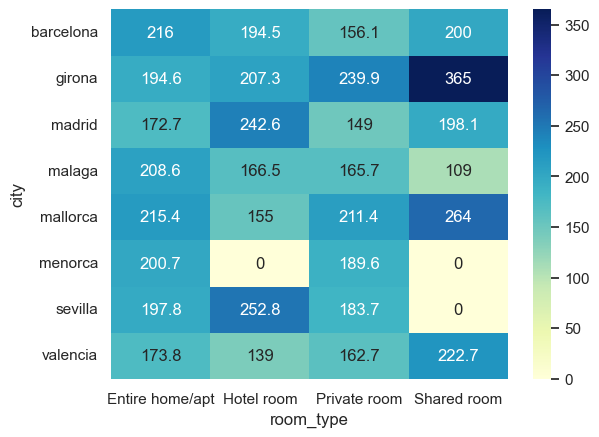

In [136]:
sns.heatmap(
    df.groupby(["city", "room_type"])["availability_365"]
    .mean()
    .round(1)
    .unstack(fill_value=0),
    annot=True,
    cmap="YlGnBu",
    fmt="g",
)

##### Number of reviews

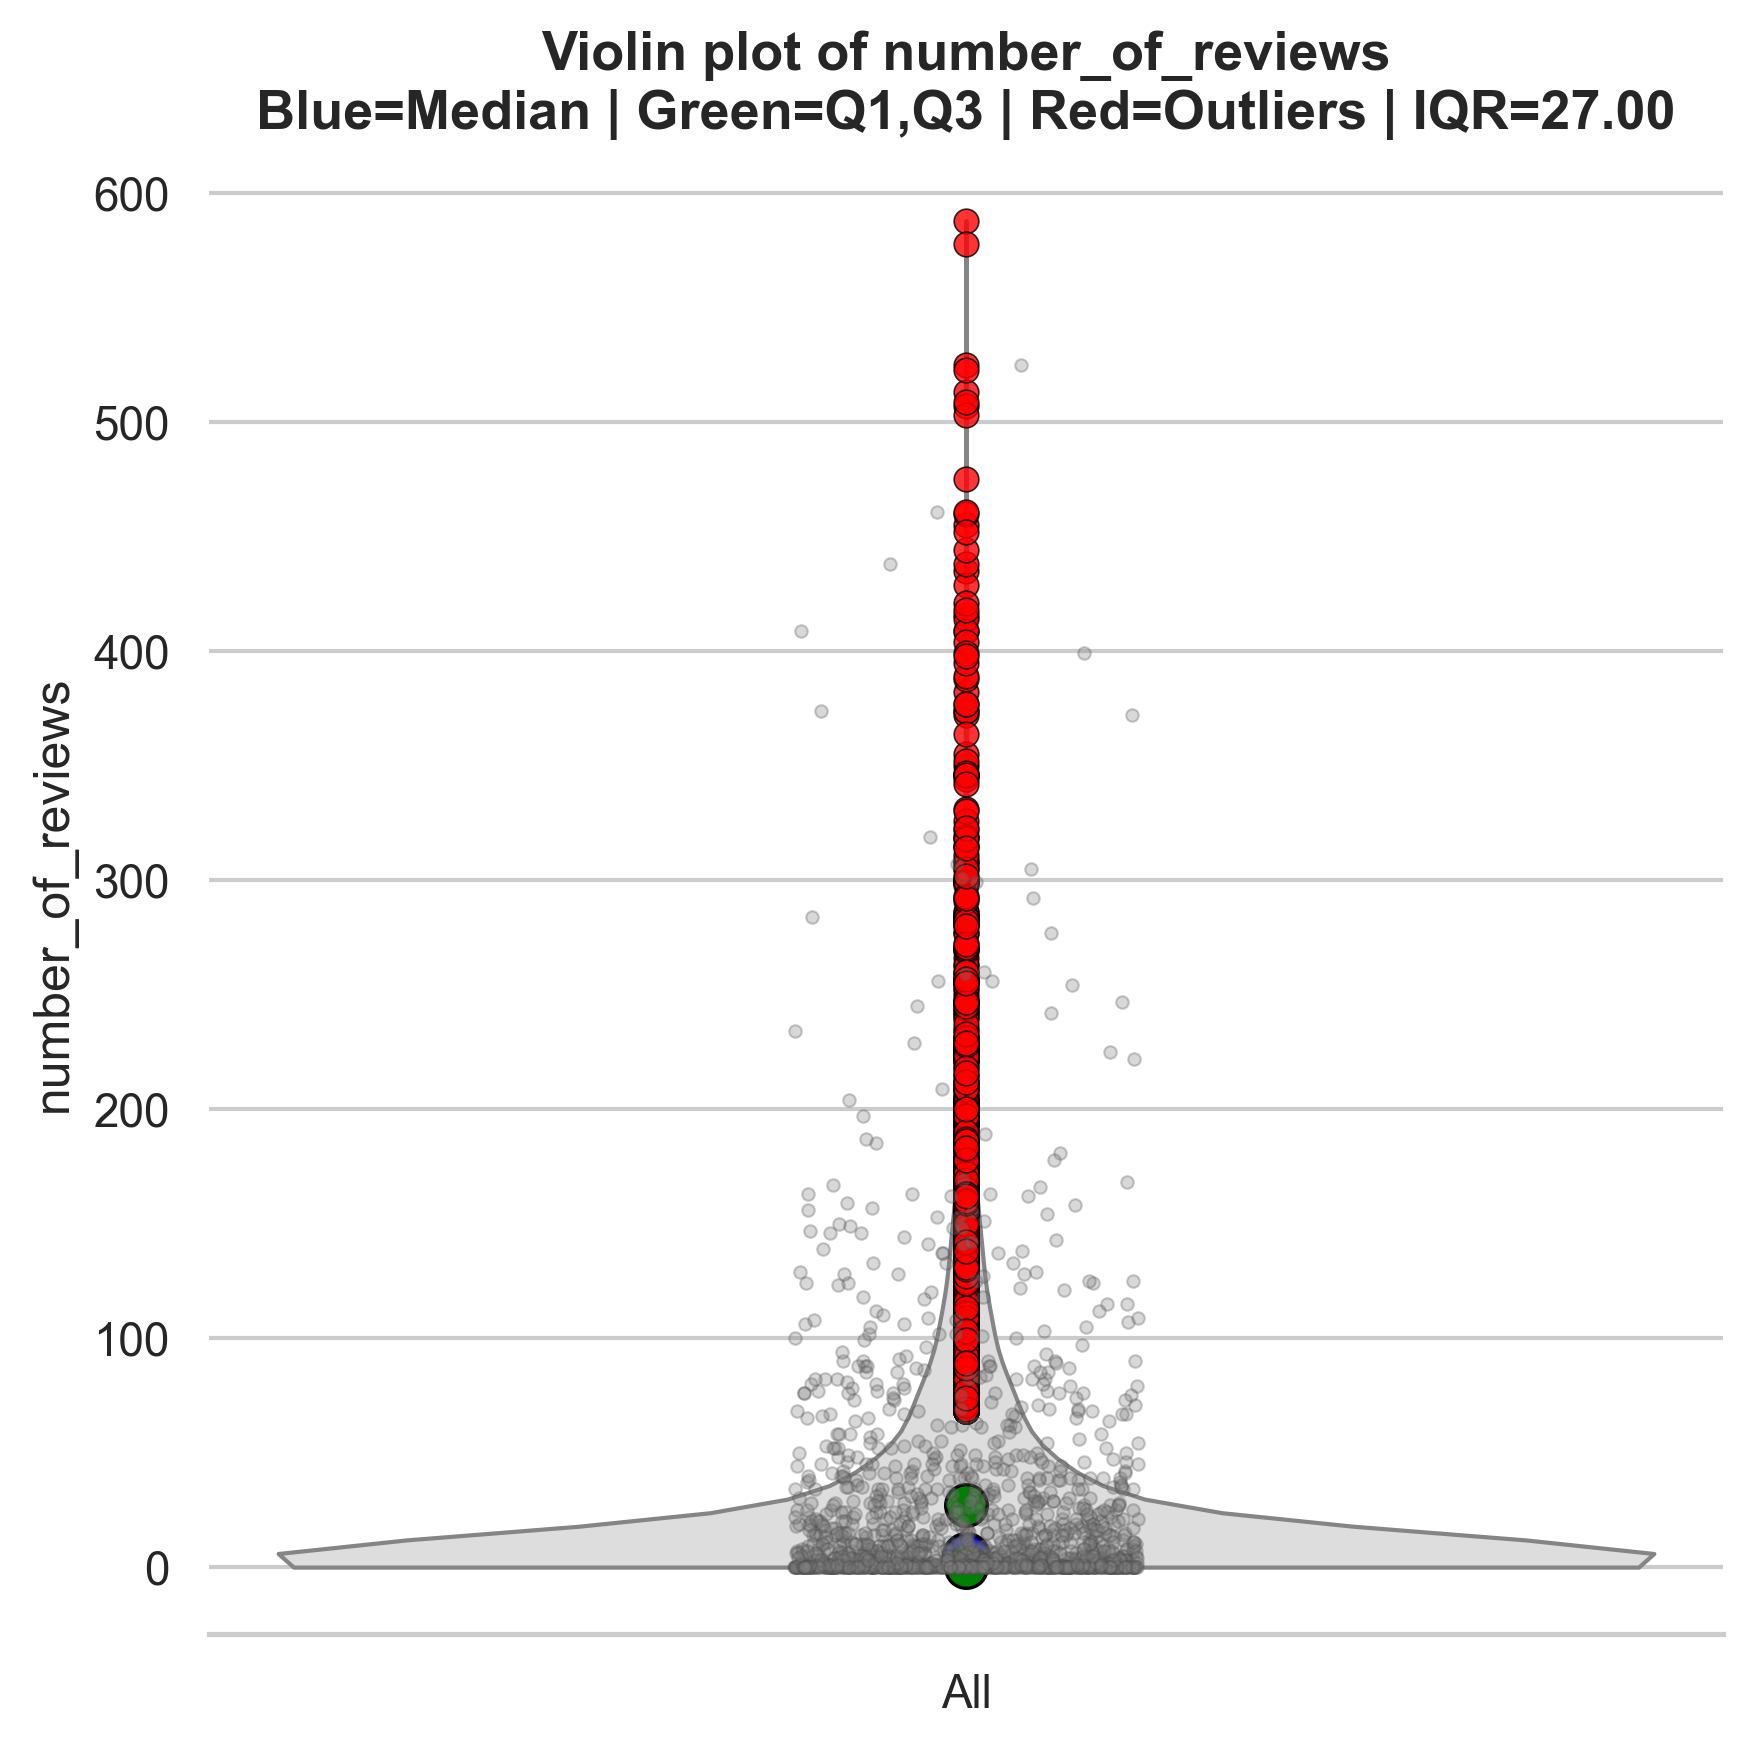

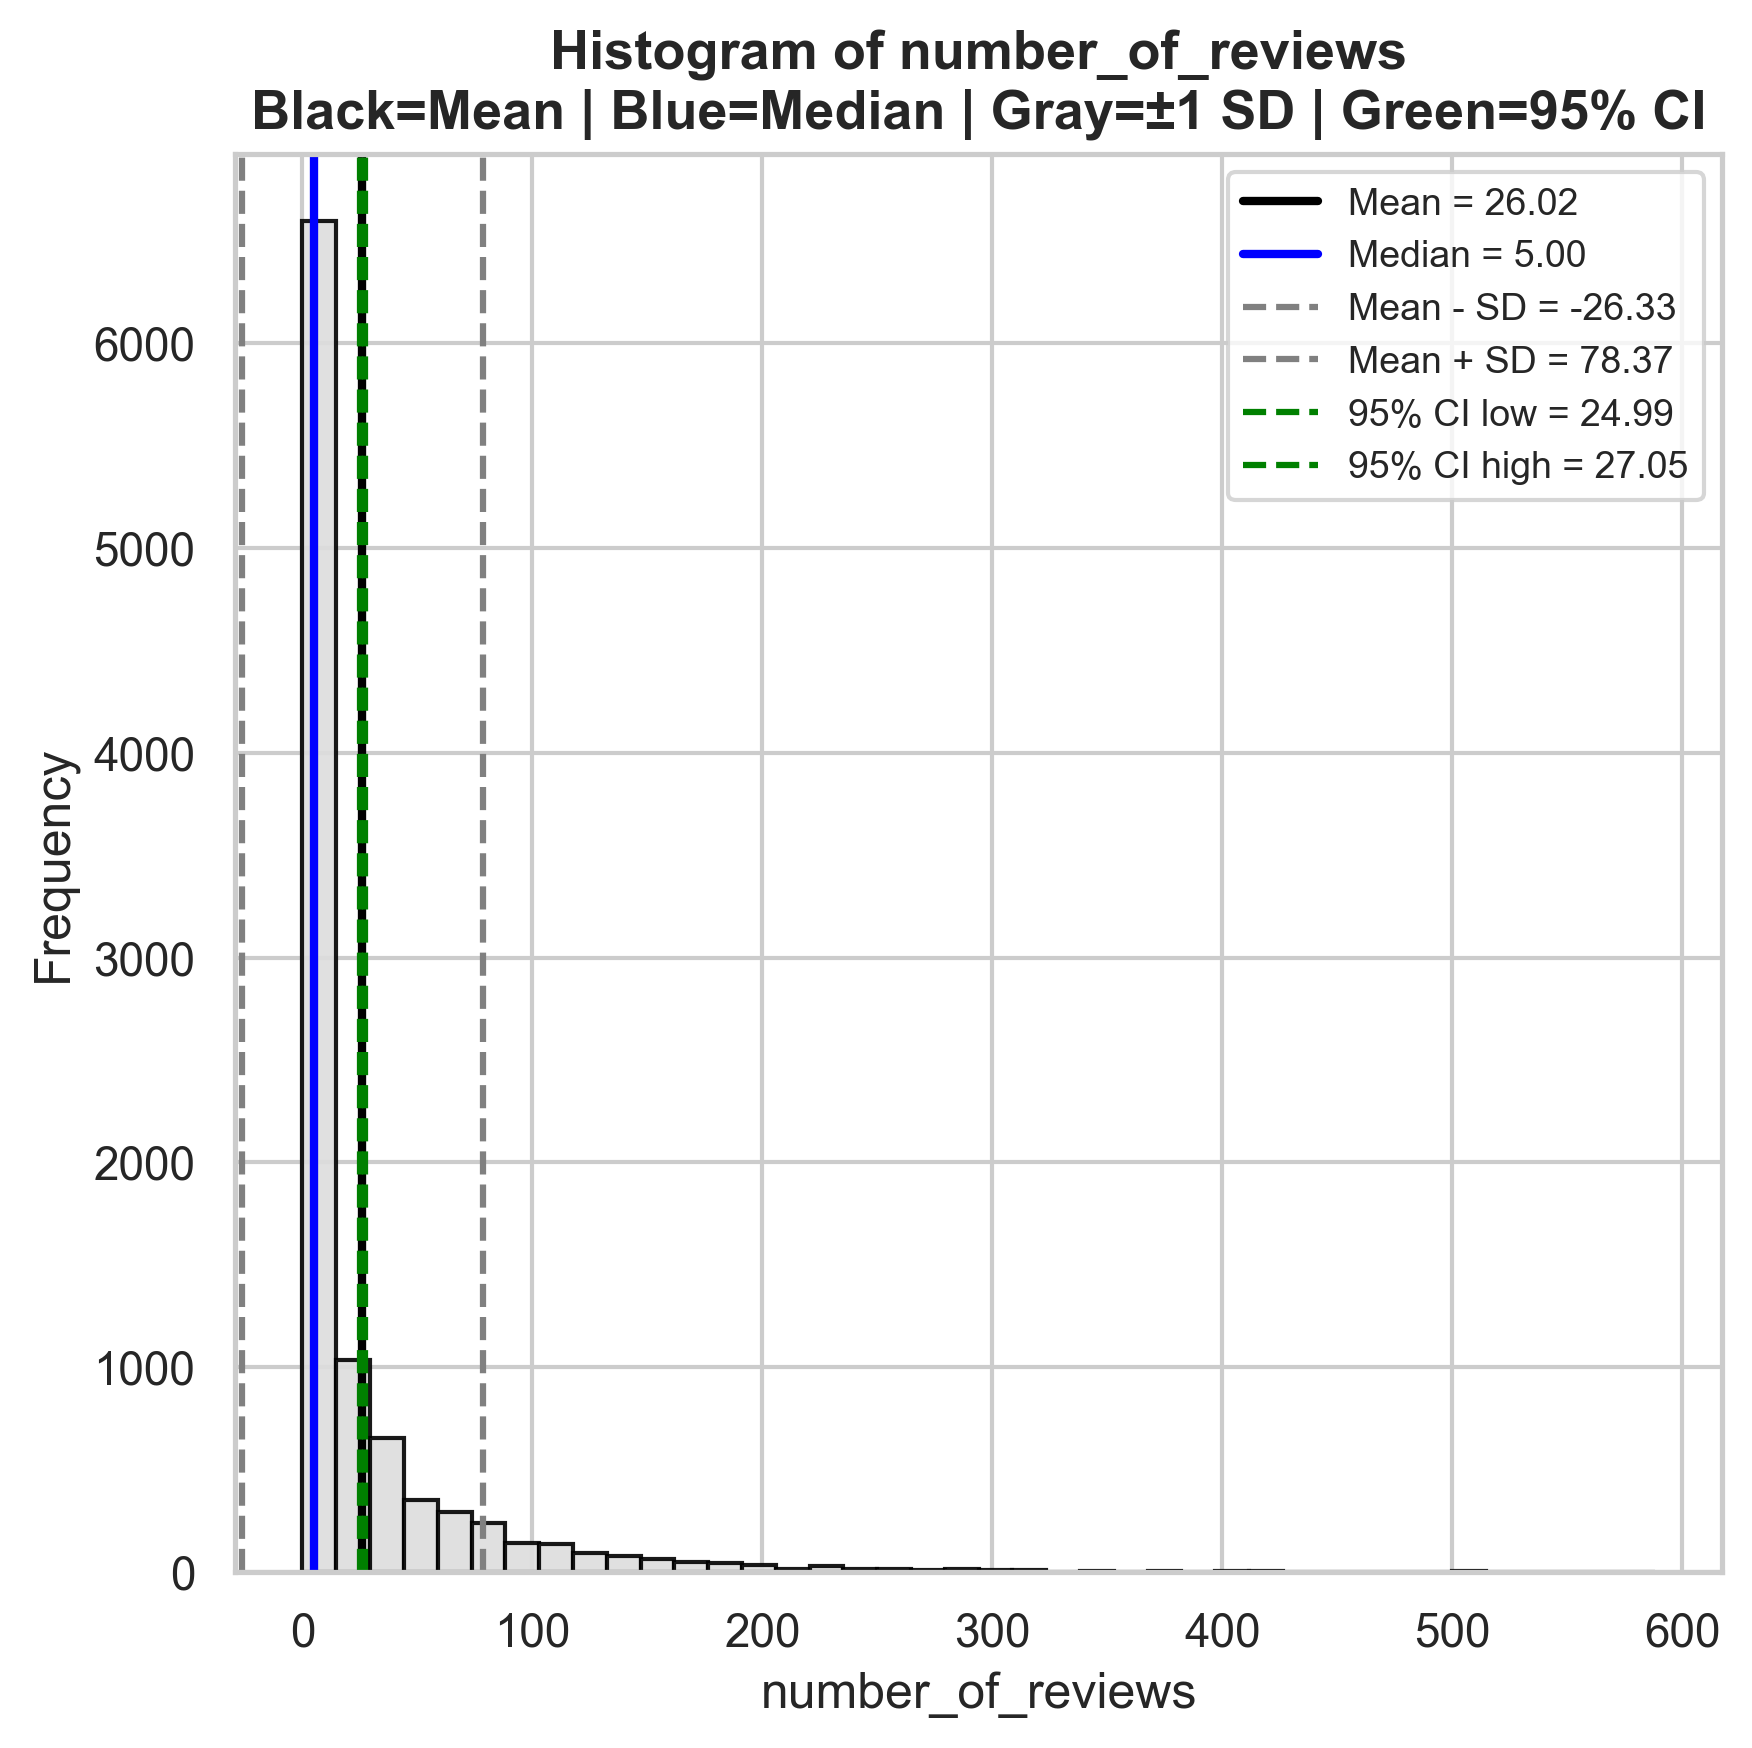

All files saved locally

Summary statistics


,column,n_non_null_numeric,mean,median,std,ci95_low,ci95_high,q1,q3,iqr,lower_fence,upper_fence,outlier_count,skewness,skewness_interpretation
0,number_of_reviews,10000,26.0206,5.0,52.347588,24.994482,27.046718,0.0,27.0,27.0,-40.5,67.5,1167,3.963856,Highly skewed.



Unique values table
Number of non-nulls: 10000
Number of unique values: 319


,column,value,count,frequency_non_null
0,number_of_reviews,0,2601,0.2601
1,number_of_reviews,1,933,0.0933
2,number_of_reviews,2,582,0.0582
3,number_of_reviews,3,444,0.0444
4,number_of_reviews,4,343,0.0343
...,...,...,...,...
314,number_of_reviews,513,1,0.0001
315,number_of_reviews,523,1,0.0001
316,number_of_reviews,525,1,0.0001
317,number_of_reviews,578,1,0.0001



Correlation table


,target_column,target_type,other_column,other_type,test,statistic,p_value,significance,significance_interpretation,note
0,number_of_reviews,numeric,neighbourhood_name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
1,number_of_reviews,numeric,neighbourhood_district,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
2,number_of_reviews,numeric,city,categorical,Chi-square,857.759620,5.039894e-168,Significant,Statistically significant at p < 0.05.,
3,number_of_reviews,numeric,room_type,categorical,Chi-square,36.370765,3.406795e-05,Significant,Statistically significant at p < 0.05.,
4,number_of_reviews,numeric,accommodates,numeric,Pearson,-0.098756,4.224651e-23,Significant,Statistically significant at p < 0.05.,
5,number_of_reviews,numeric,bathrooms,numeric,Pearson,-0.116628,2.091943e-31,Significant,Statistically significant at p < 0.05.,
6,number_of_reviews,numeric,bedrooms,numeric,Pearson,-0.123339,5.777875e-35,Significant,Statistically significant at p < 0.05.,
7,number_of_reviews,numeric,beds,numeric,Pearson,-0.117172,8.975404e-32,Significant,Statistically significant at p < 0.05.,
8,number_of_reviews,numeric,price,numeric,Pearson,-0.129607,8.867326e-38,Significant,Statistically significant at p < 0.05.,
9,number_of_reviews,numeric,minimum_nights,numeric,Pearson,-0.055593,2.652736e-08,Significant,Statistically significant at p < 0.05.,



Transformation skewness table


,method,skewness,interpretation,normality_improvement
0,Original,3.963856,Highly skewed.,Baseline.
1,Log Transformation,0.376864,Approximately symmetric.,Improved strongly; distribution is closer to s...
2,Square Root Transformation,1.538572,Highly skewed.,Improved; skewness decreased.
3,Box-Cox Transformation,0.104920,Approximately symmetric.,Improved strongly; distribution is closer to s...


In [137]:
analysis = analyze_single_field(
    df, target_col="number_of_reviews", results_dir=RESULTS_DIR, show_in_notebook=True
)

*Recommendations for Numer of reviews*:
- mediana: 5.0
- IQR=27.0 [0.0; 27.0]
- 1167 outliers determined
- apply Box-Cox Transformation to obtain normal distribution of the data
- consider:
    * strongly and significantly associated with: city, room_type, is_instant_bookable
    * strongly and significantly correlated with: none found
    * medium and significantly correlated with: reviews_per_month (r=0.66)
    * weakly and significantly correlated with: bathrooms (r= -0.12), bedrooms (r= -0.12), beds (r= -0.12), price (r= -0.13), review_scores_accuracy (r=0.11), review_scores_checkin (r=0.11), review_scores_communication (r=0.11), review_scores_location (r=0.11)

##### Reviews score rating

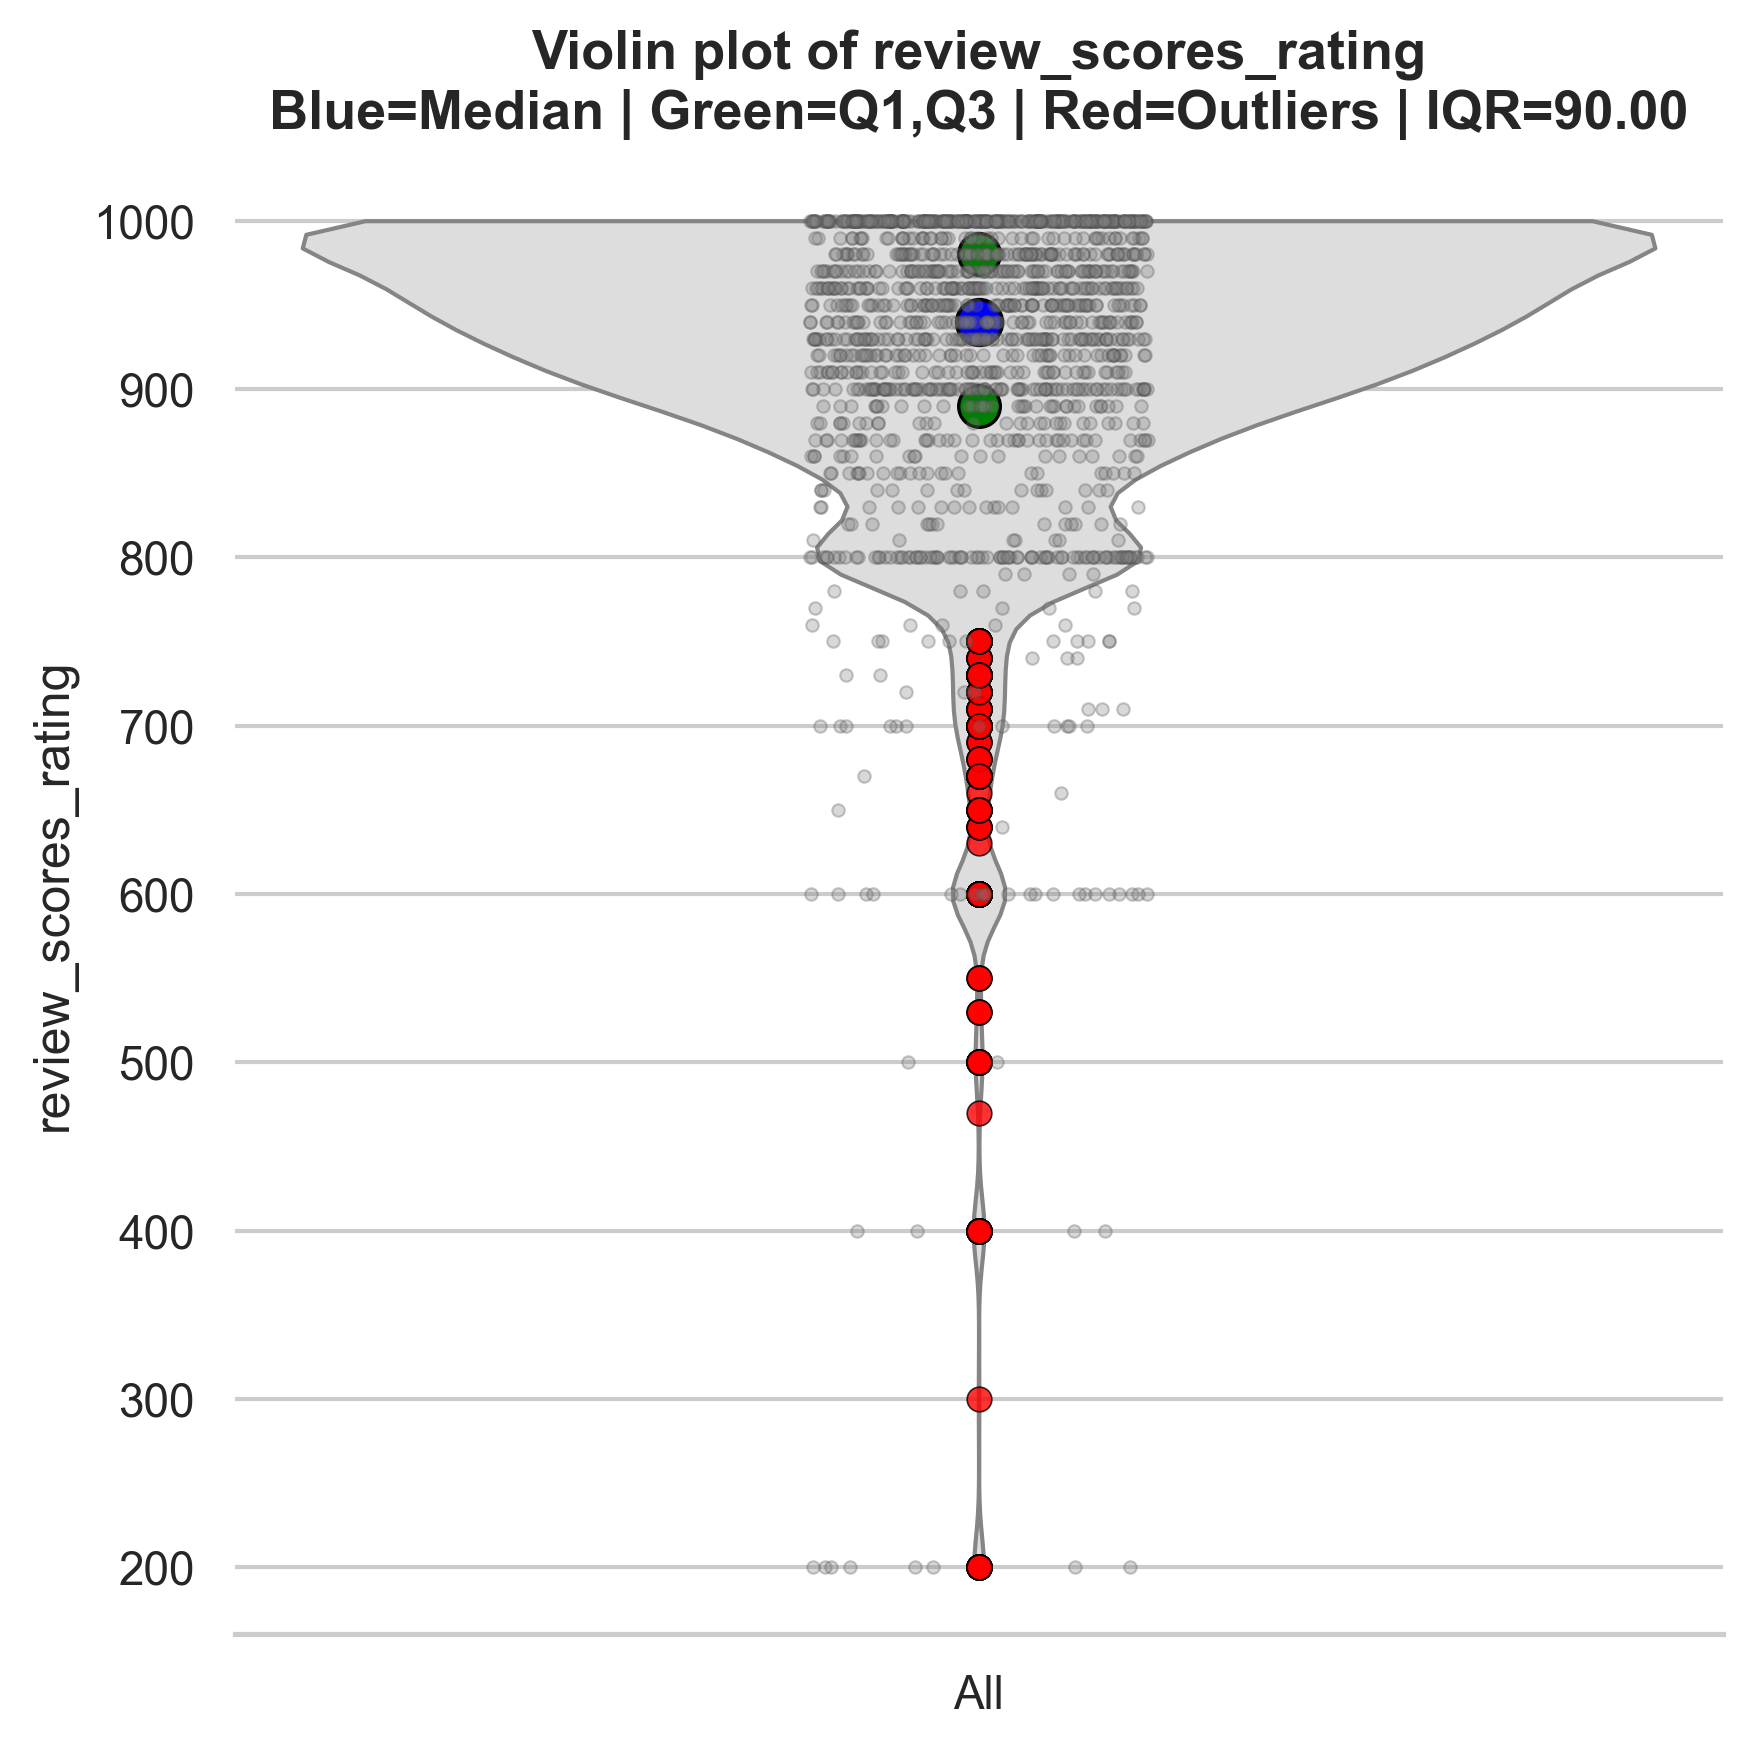

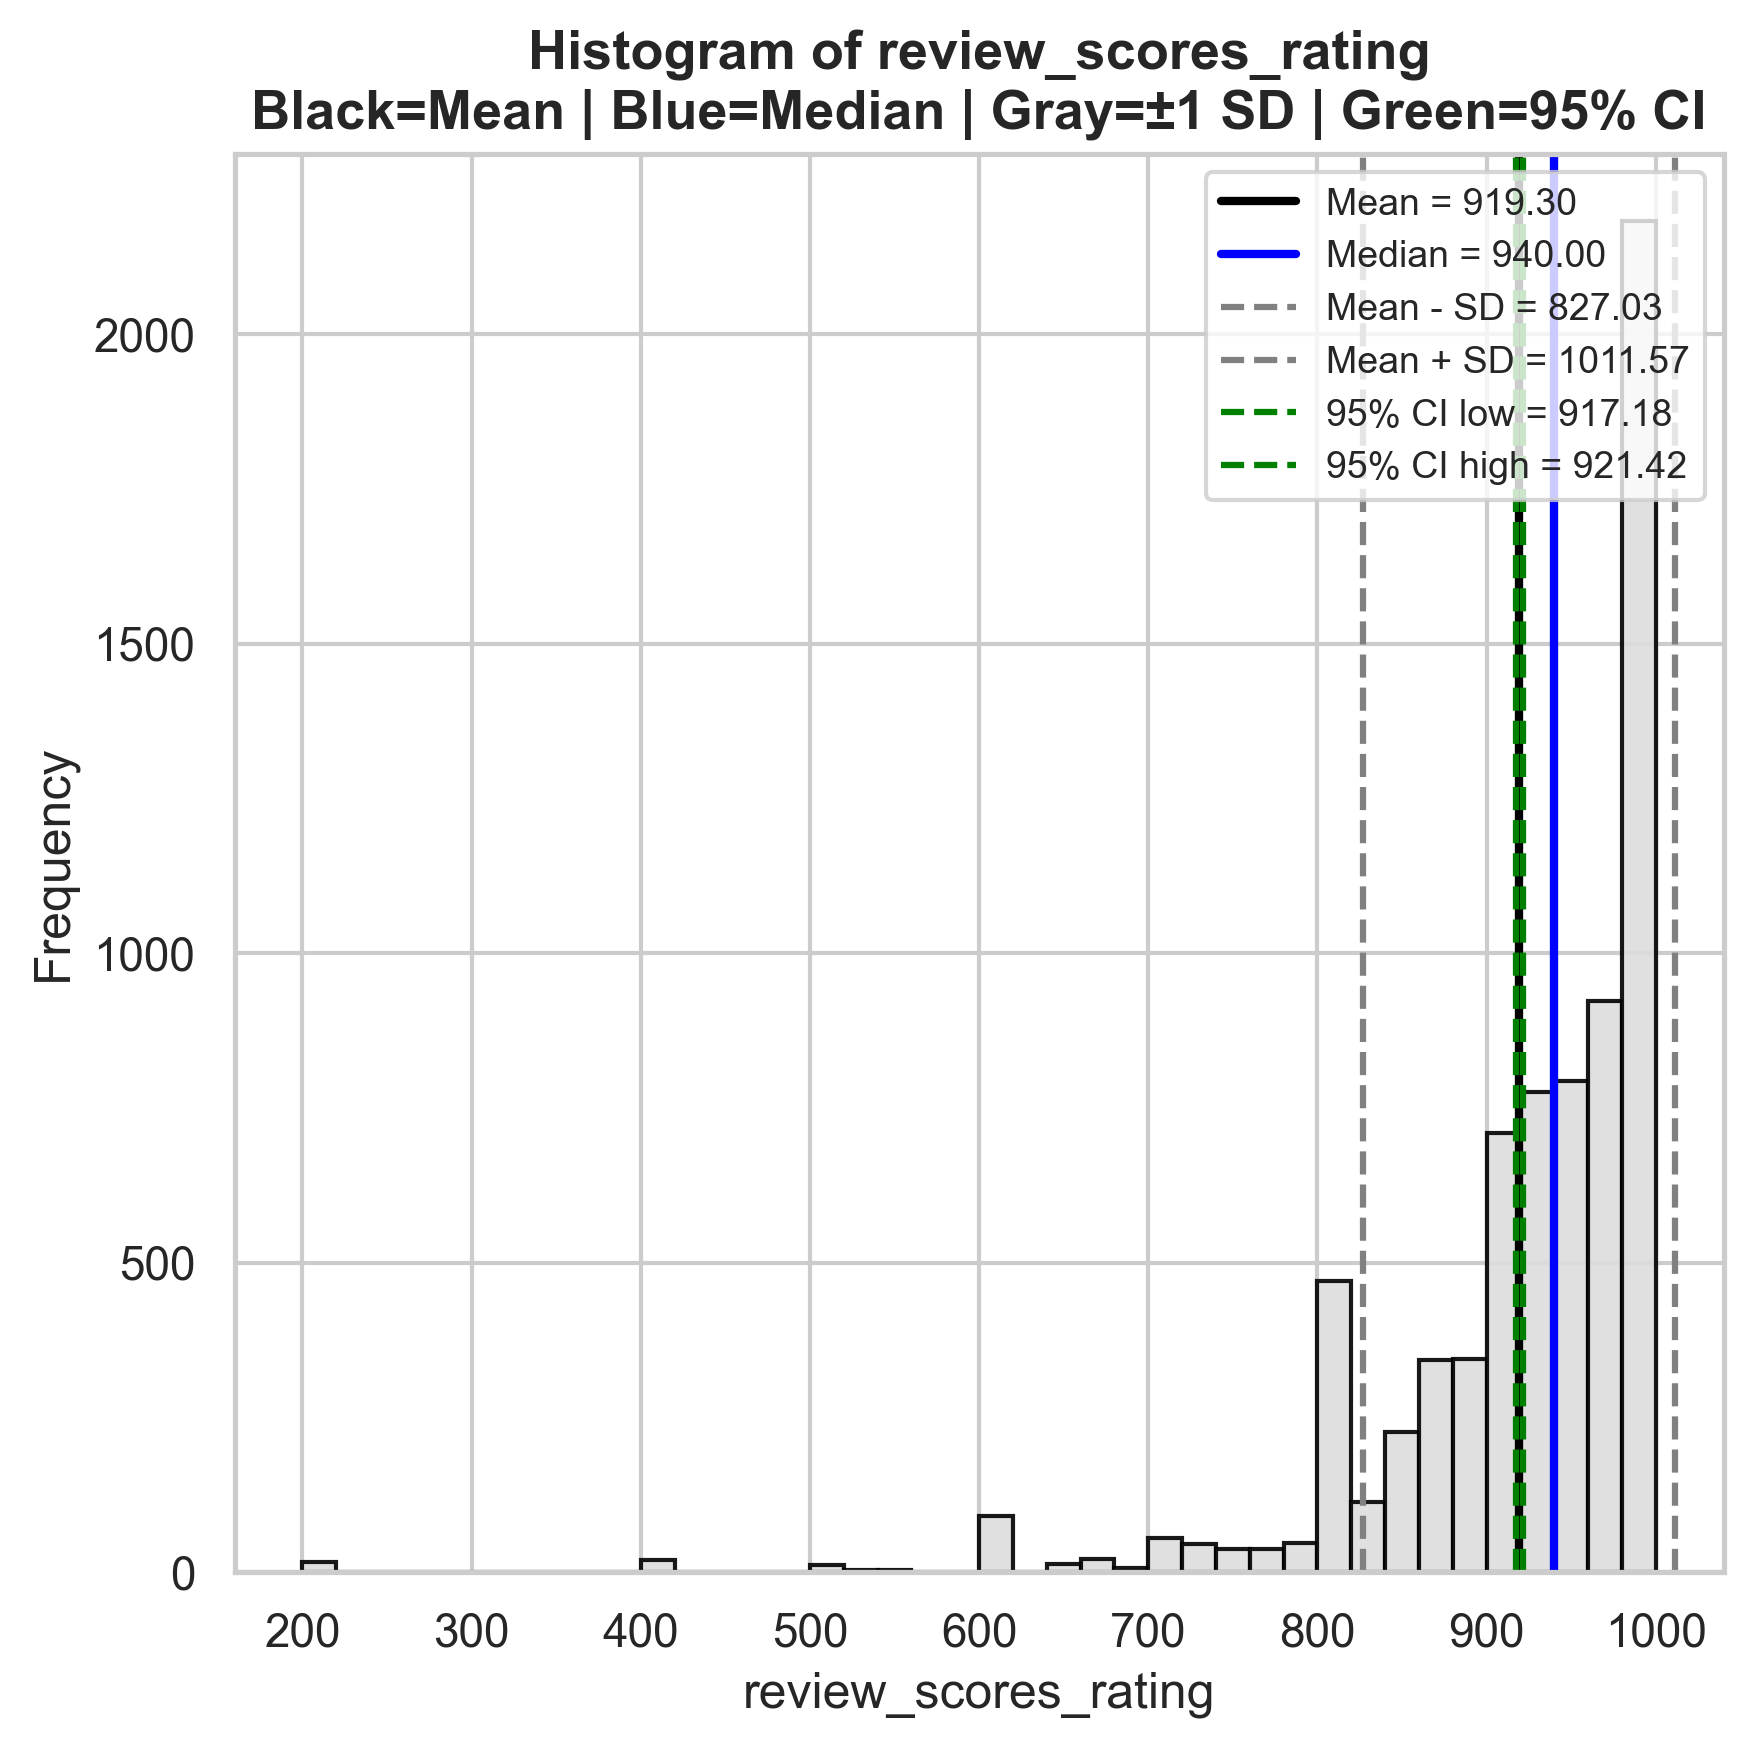

All files saved locally

Summary statistics


,column,n_non_null_numeric,mean,median,std,ci95_low,ci95_high,q1,q3,iqr,lower_fence,upper_fence,outlier_count,skewness,skewness_interpretation
0,review_scores_rating,7291,919.297764,940.0,92.269811,917.17947,921.416059,890.0,980.0,90.0,755.0,1115.0,327,-2.696606,Highly skewed.



Unique values table
Number of non-nulls: 7291
Number of unique values: 46


,column,value,count,frequency_non_null
0,review_scores_rating,200.0,17,0.002332
1,review_scores_rating,300.0,1,0.000137
2,review_scores_rating,400.0,19,0.002606
3,review_scores_rating,470.0,1,0.000137
4,review_scores_rating,500.0,11,0.001509
5,review_scores_rating,530.0,3,0.000411
6,review_scores_rating,550.0,3,0.000411
7,review_scores_rating,600.0,91,0.012481
8,review_scores_rating,630.0,1,0.000137
9,review_scores_rating,640.0,5,0.000686



Correlation table


,target_column,target_type,other_column,other_type,test,statistic,p_value,significance,significance_interpretation,note
0,review_scores_rating,numeric,neighbourhood_name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
1,review_scores_rating,numeric,neighbourhood_district,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
2,review_scores_rating,numeric,city,categorical,Chi-square,224.628102,4.846343e-36,Significant,Statistically significant at p < 0.05.,
3,review_scores_rating,numeric,room_type,categorical,Chi-square,10.327293,3.246445e-01,Not significant,Not statistically significant at p < 0.05.,
4,review_scores_rating,numeric,accommodates,numeric,Pearson,0.000555,9.622300e-01,Not significant,Not statistically significant at p < 0.05.,
5,review_scores_rating,numeric,bathrooms,numeric,Pearson,0.058964,5.075266e-07,Significant,Statistically significant at p < 0.05.,
6,review_scores_rating,numeric,bedrooms,numeric,Pearson,0.034996,2.901625e-03,Significant,Statistically significant at p < 0.05.,
7,review_scores_rating,numeric,beds,numeric,Pearson,0.004839,6.796389e-01,Not significant,Not statistically significant at p < 0.05.,
8,review_scores_rating,numeric,price,numeric,Pearson,0.039956,7.080404e-04,Significant,Statistically significant at p < 0.05.,
9,review_scores_rating,numeric,minimum_nights,numeric,Pearson,-0.007095,5.446733e-01,Not significant,Not statistically significant at p < 0.05.,



Transformation skewness table


,method,skewness,interpretation,normality_improvement
0,Original,-2.696606,Highly skewed.,Baseline.
1,Log Transformation,-5.402962,Highly skewed.,Did not improve normality; skewness increased.
2,Square Root Transformation,-3.704783,Highly skewed.,Did not improve normality; skewness increased.
3,Box-Cox Transformation,-0.355649,Approximately symmetric.,Improved strongly; distribution is closer to s...


In [138]:
analysis = analyze_single_field(
    df,
    target_col="review_scores_rating",
    results_dir=RESULTS_DIR,
    show_in_notebook=True,
)

*Recommendations for Review Score Ratings*:
- mediana: 940.0
- IQR=90.0 [890.0; 980.0]
- 327 outliers determined
- apply Box-Cox Transformation to improve normal distribution shape of the data
- consider:
    * strongly and significantly associated with: city, is_instant_bookable
    * strongly and significantly correlated with: review_scores_accuracy (r=0.73), review_scores_value (r=0.77)
    * medium and significantly correlated with: review_scores_cleanliness (r=0.68), review_scores_checkin (r=0.57), review_scores_communication (r=0.62), review_scores_location (r=0.41)
    * weakly and significantly correlated with: accommodates none found

##### ACCURACY

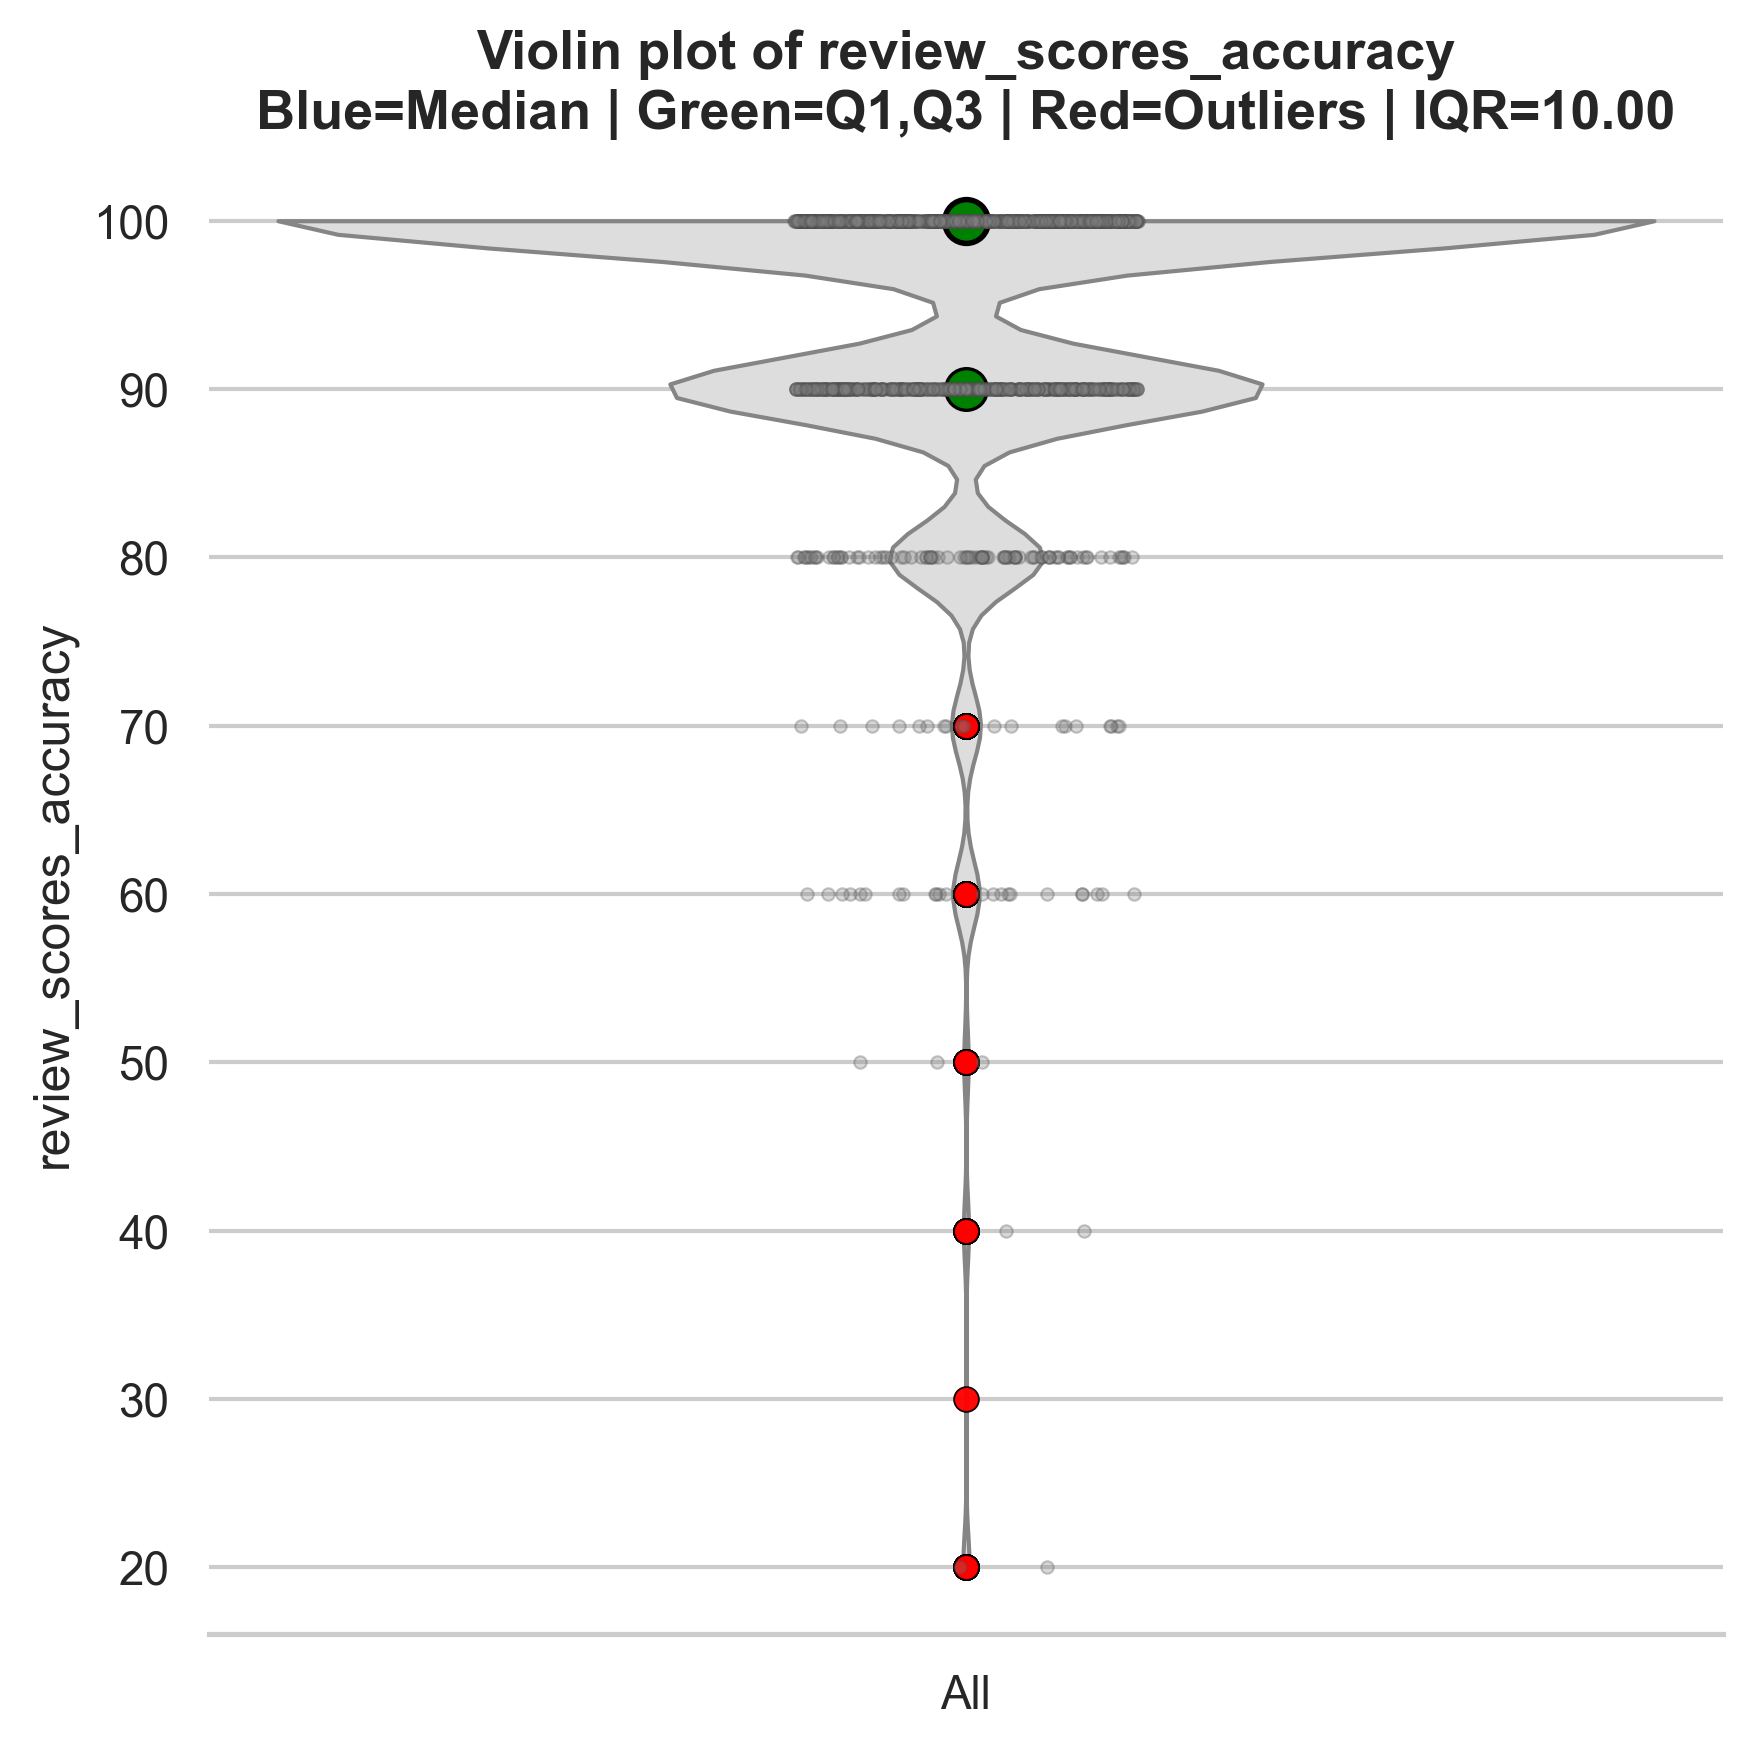

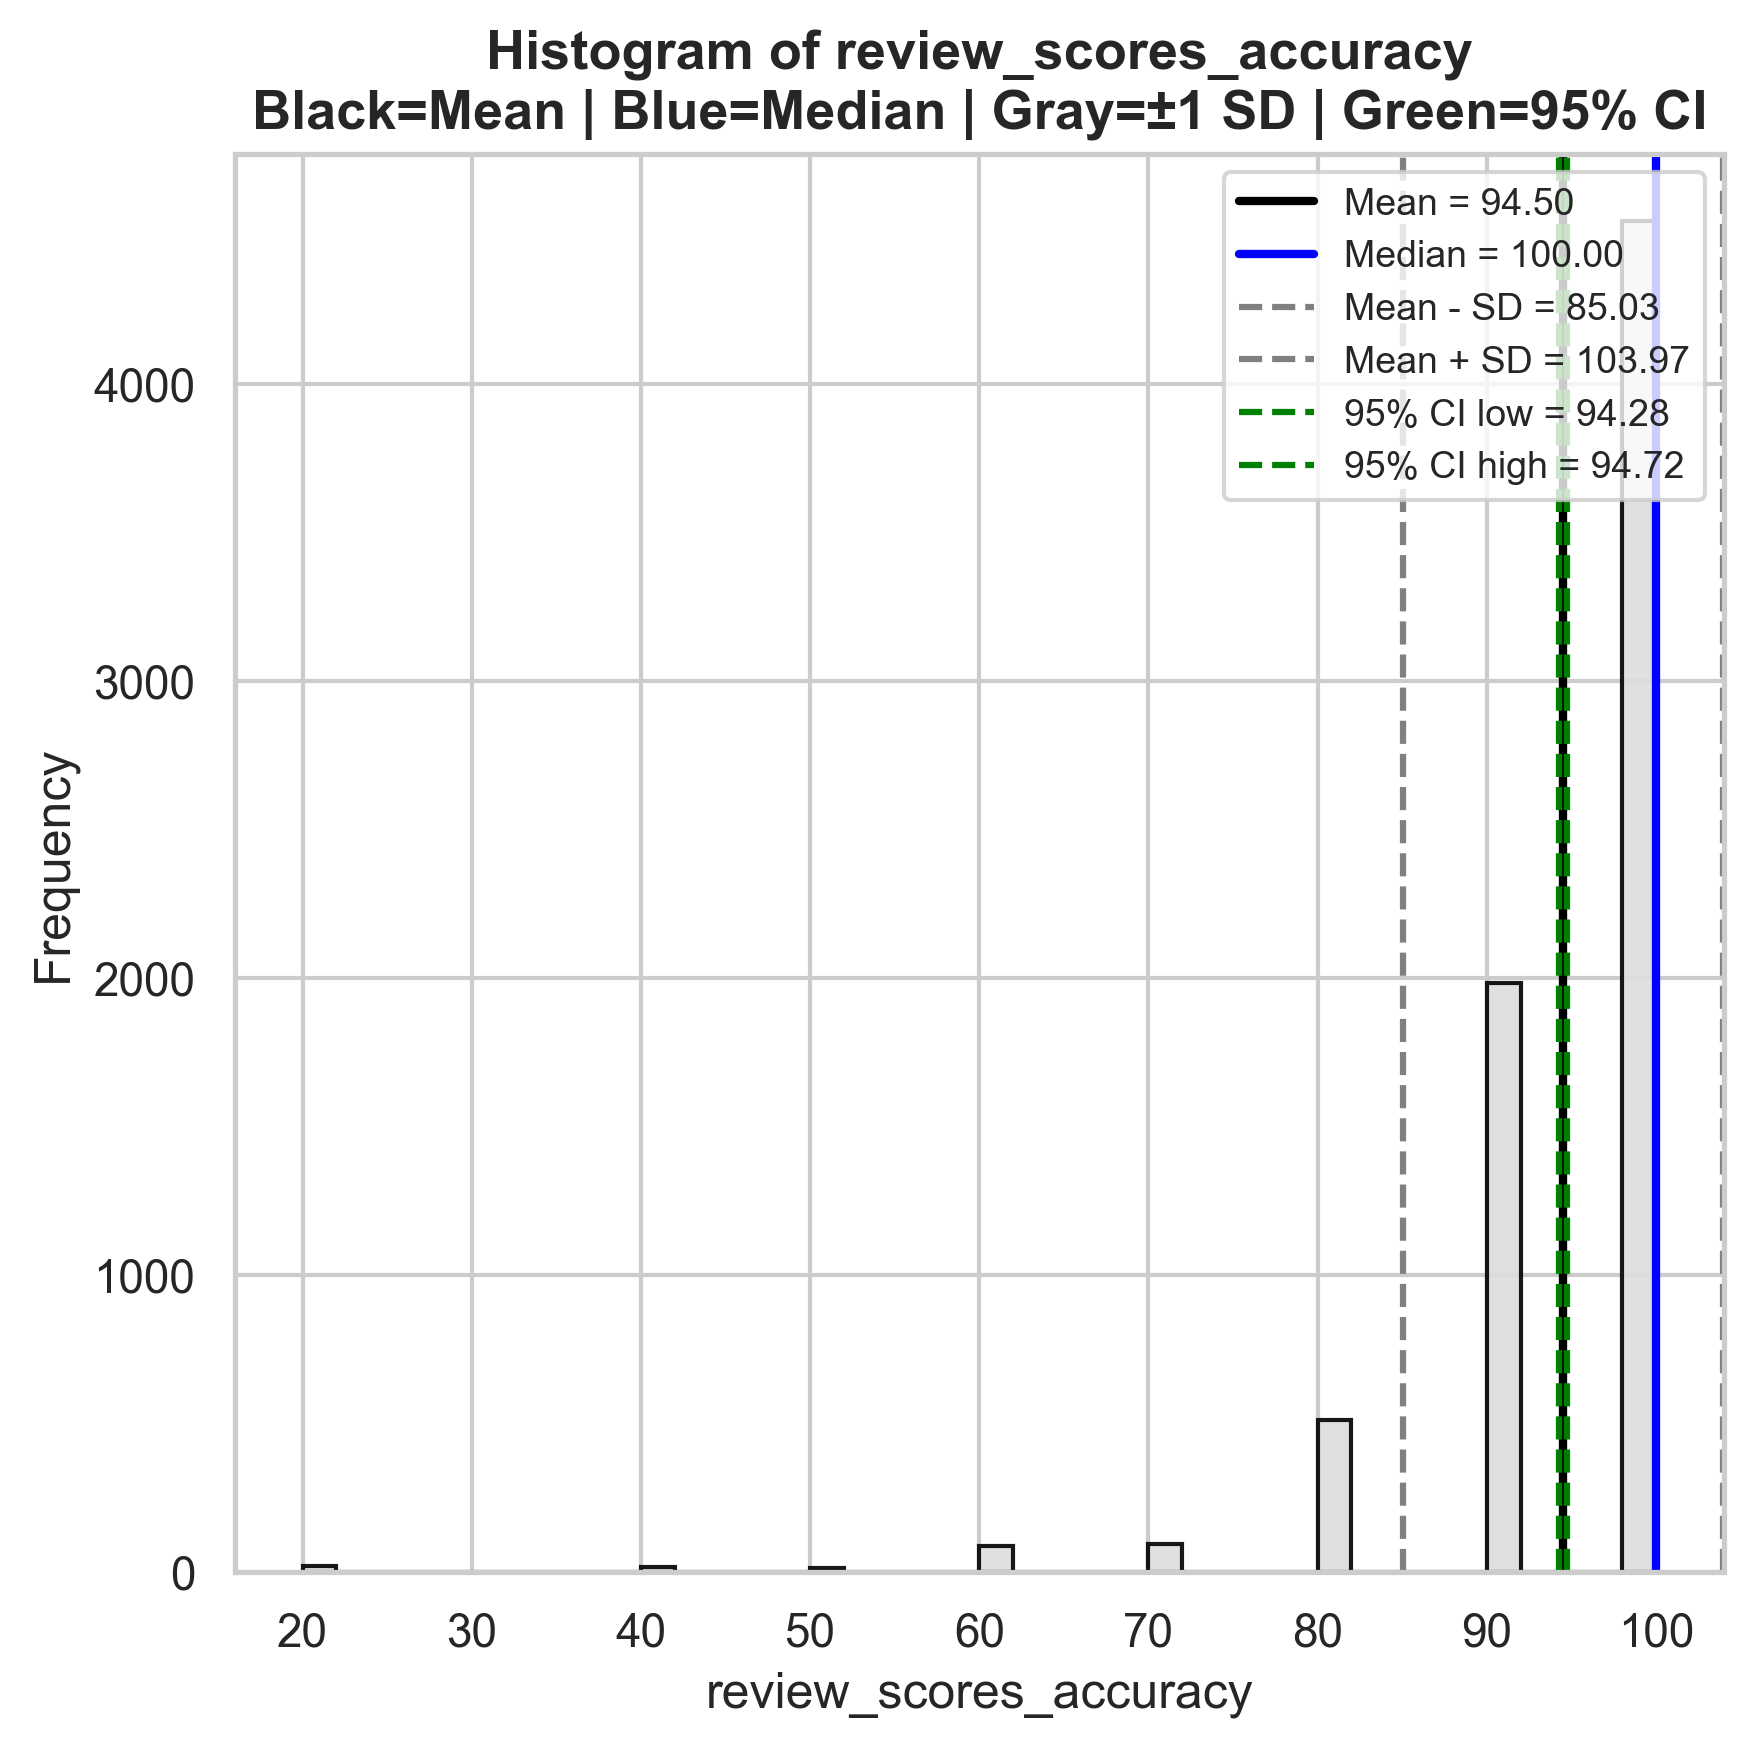

All files saved locally

Summary statistics


,column,n_non_null_numeric,mean,median,std,ci95_low,ci95_high,q1,q3,iqr,lower_fence,upper_fence,outlier_count,skewness,skewness_interpretation
0,review_scores_accuracy,7282,94.501511,100.0,9.467635,94.284022,94.718999,90.0,100.0,10.0,75.0,115.0,239,-3.124983,Highly skewed.



Unique values table
Number of non-nulls: 7282
Number of unique values: 9


,column,value,count,frequency_non_null
0,review_scores_accuracy,20.0,21,0.002884
1,review_scores_accuracy,30.0,2,0.000275
2,review_scores_accuracy,40.0,17,0.002335
3,review_scores_accuracy,50.0,15,0.002060
4,review_scores_accuracy,60.0,88,0.012085
5,review_scores_accuracy,70.0,96,0.013183
6,review_scores_accuracy,80.0,511,0.070173
7,review_scores_accuracy,90.0,1983,0.272315
8,review_scores_accuracy,100.0,4549,0.624691



Correlation table


,target_column,target_type,other_column,other_type,test,statistic,p_value,significance,significance_interpretation,note
0,review_scores_accuracy,numeric,neighbourhood_name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
1,review_scores_accuracy,numeric,neighbourhood_district,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
2,review_scores_accuracy,numeric,city,categorical,Chi-square,109.998047,9.191018e-21,Significant,Statistically significant at p < 0.05.,
3,review_scores_accuracy,numeric,room_type,categorical,Chi-square,8.153342,4.294665e-02,Significant,Statistically significant at p < 0.05.,
4,review_scores_accuracy,numeric,accommodates,numeric,Pearson,-0.040905,4.804046e-04,Significant,Statistically significant at p < 0.05.,
5,review_scores_accuracy,numeric,bathrooms,numeric,Pearson,0.007623,5.166902e-01,Not significant,Not statistically significant at p < 0.05.,
6,review_scores_accuracy,numeric,bedrooms,numeric,Pearson,-0.017390,1.392712e-01,Not significant,Not statistically significant at p < 0.05.,
7,review_scores_accuracy,numeric,beds,numeric,Pearson,-0.037872,1.232439e-03,Significant,Statistically significant at p < 0.05.,
8,review_scores_accuracy,numeric,price,numeric,Pearson,-0.005847,6.205406e-01,Not significant,Not statistically significant at p < 0.05.,
9,review_scores_accuracy,numeric,minimum_nights,numeric,Pearson,-0.002288,8.452552e-01,Not significant,Not statistically significant at p < 0.05.,



Transformation skewness table


,method,skewness,interpretation,normality_improvement
0,Original,-3.124983,Highly skewed.,Baseline.
1,Log Transformation,-5.984533,Highly skewed.,Did not improve normality; skewness increased.
2,Square Root Transformation,-4.217541,Highly skewed.,Did not improve normality; skewness increased.
3,Box-Cox Transformation,-0.685376,Moderately skewed.,Improved; skewness decreased. Improved using l...


In [139]:
analysis = analyze_single_field(
    df,
    target_col="review_scores_accuracy",
    results_dir=RESULTS_DIR,
    show_in_notebook=True,
)

*Recommendations for Review Scores - Accuracy*:
- mediana: 100.0
- IQR=10.0 [90.0; 100.0]
- 239 outliers determined
- The dataset is very Skewed due to Max values accumulation:
    * Max=100 - 62,5% of values
- no Transformation of the data should be applied, must be treated like categorical variable
- consider:
    * strongly and significantly associated with: city, room_type, is_instant_bookable
    * strongly and significantly correlated with: review_scores_rating (r=0.73)
    * medium and significantly correlated with: review_scores_cleanliness (r=0.59), review_scores_checkin (r=0.57), review_scores_communication (r=0.59),review_scores_location (r=0.40), review_scores_value (r=0.66)
    * weakly and significantly correlated with: number_of_reviews (r=0.11), reviews_per_month (r=0.11)
- Non parametric tests must be applied

##### CLEANLINESS

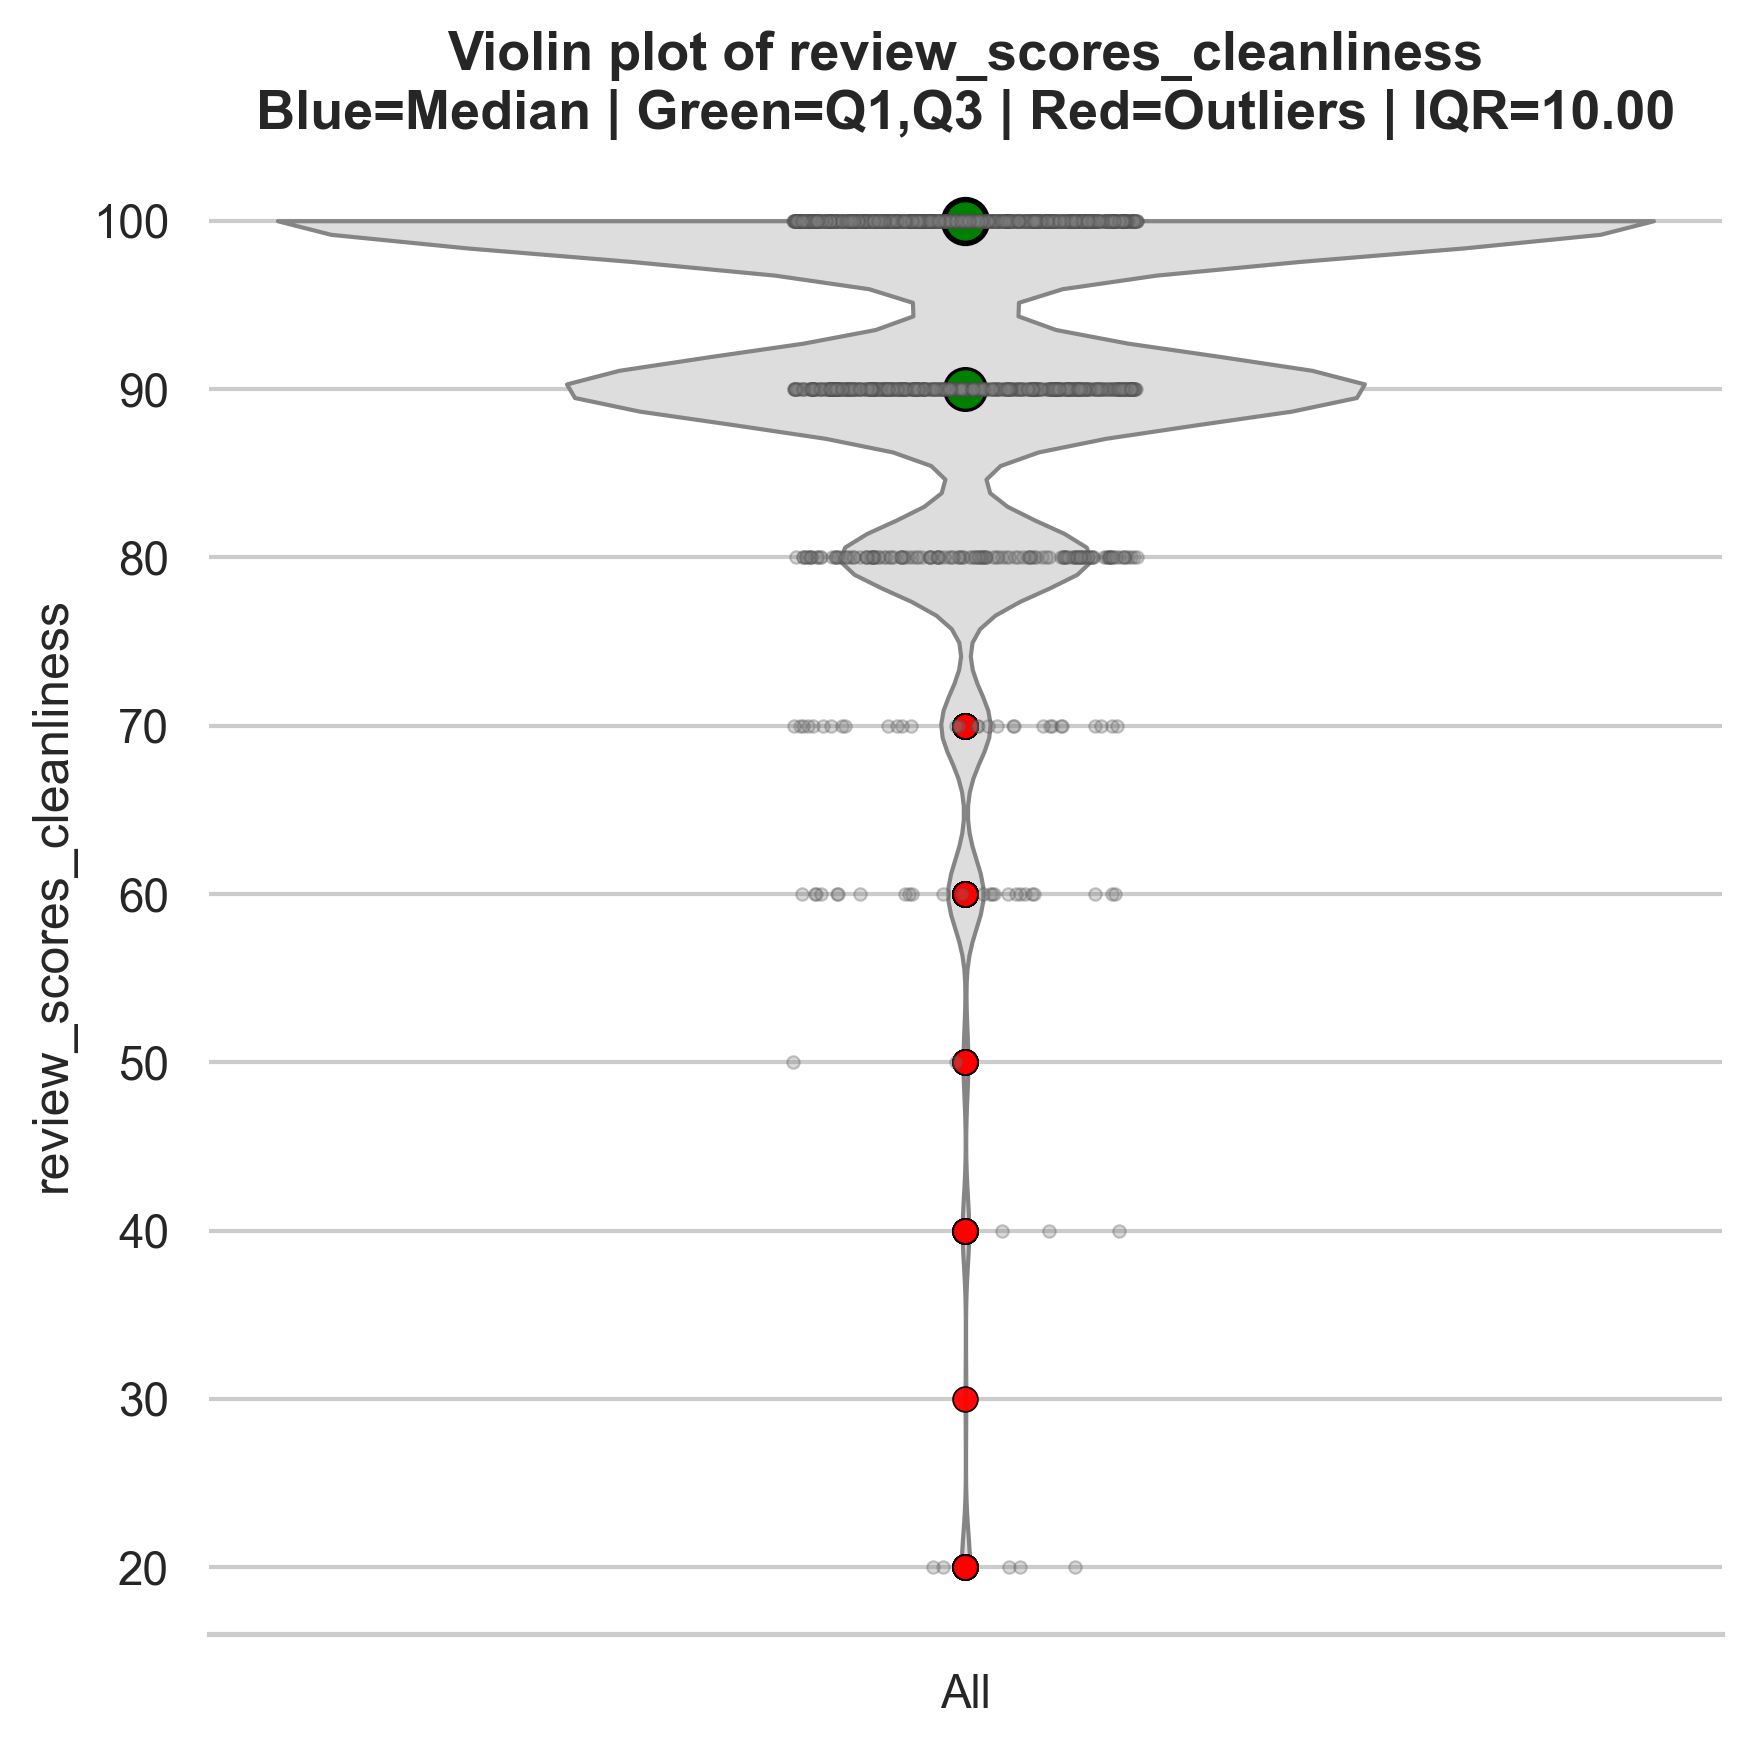

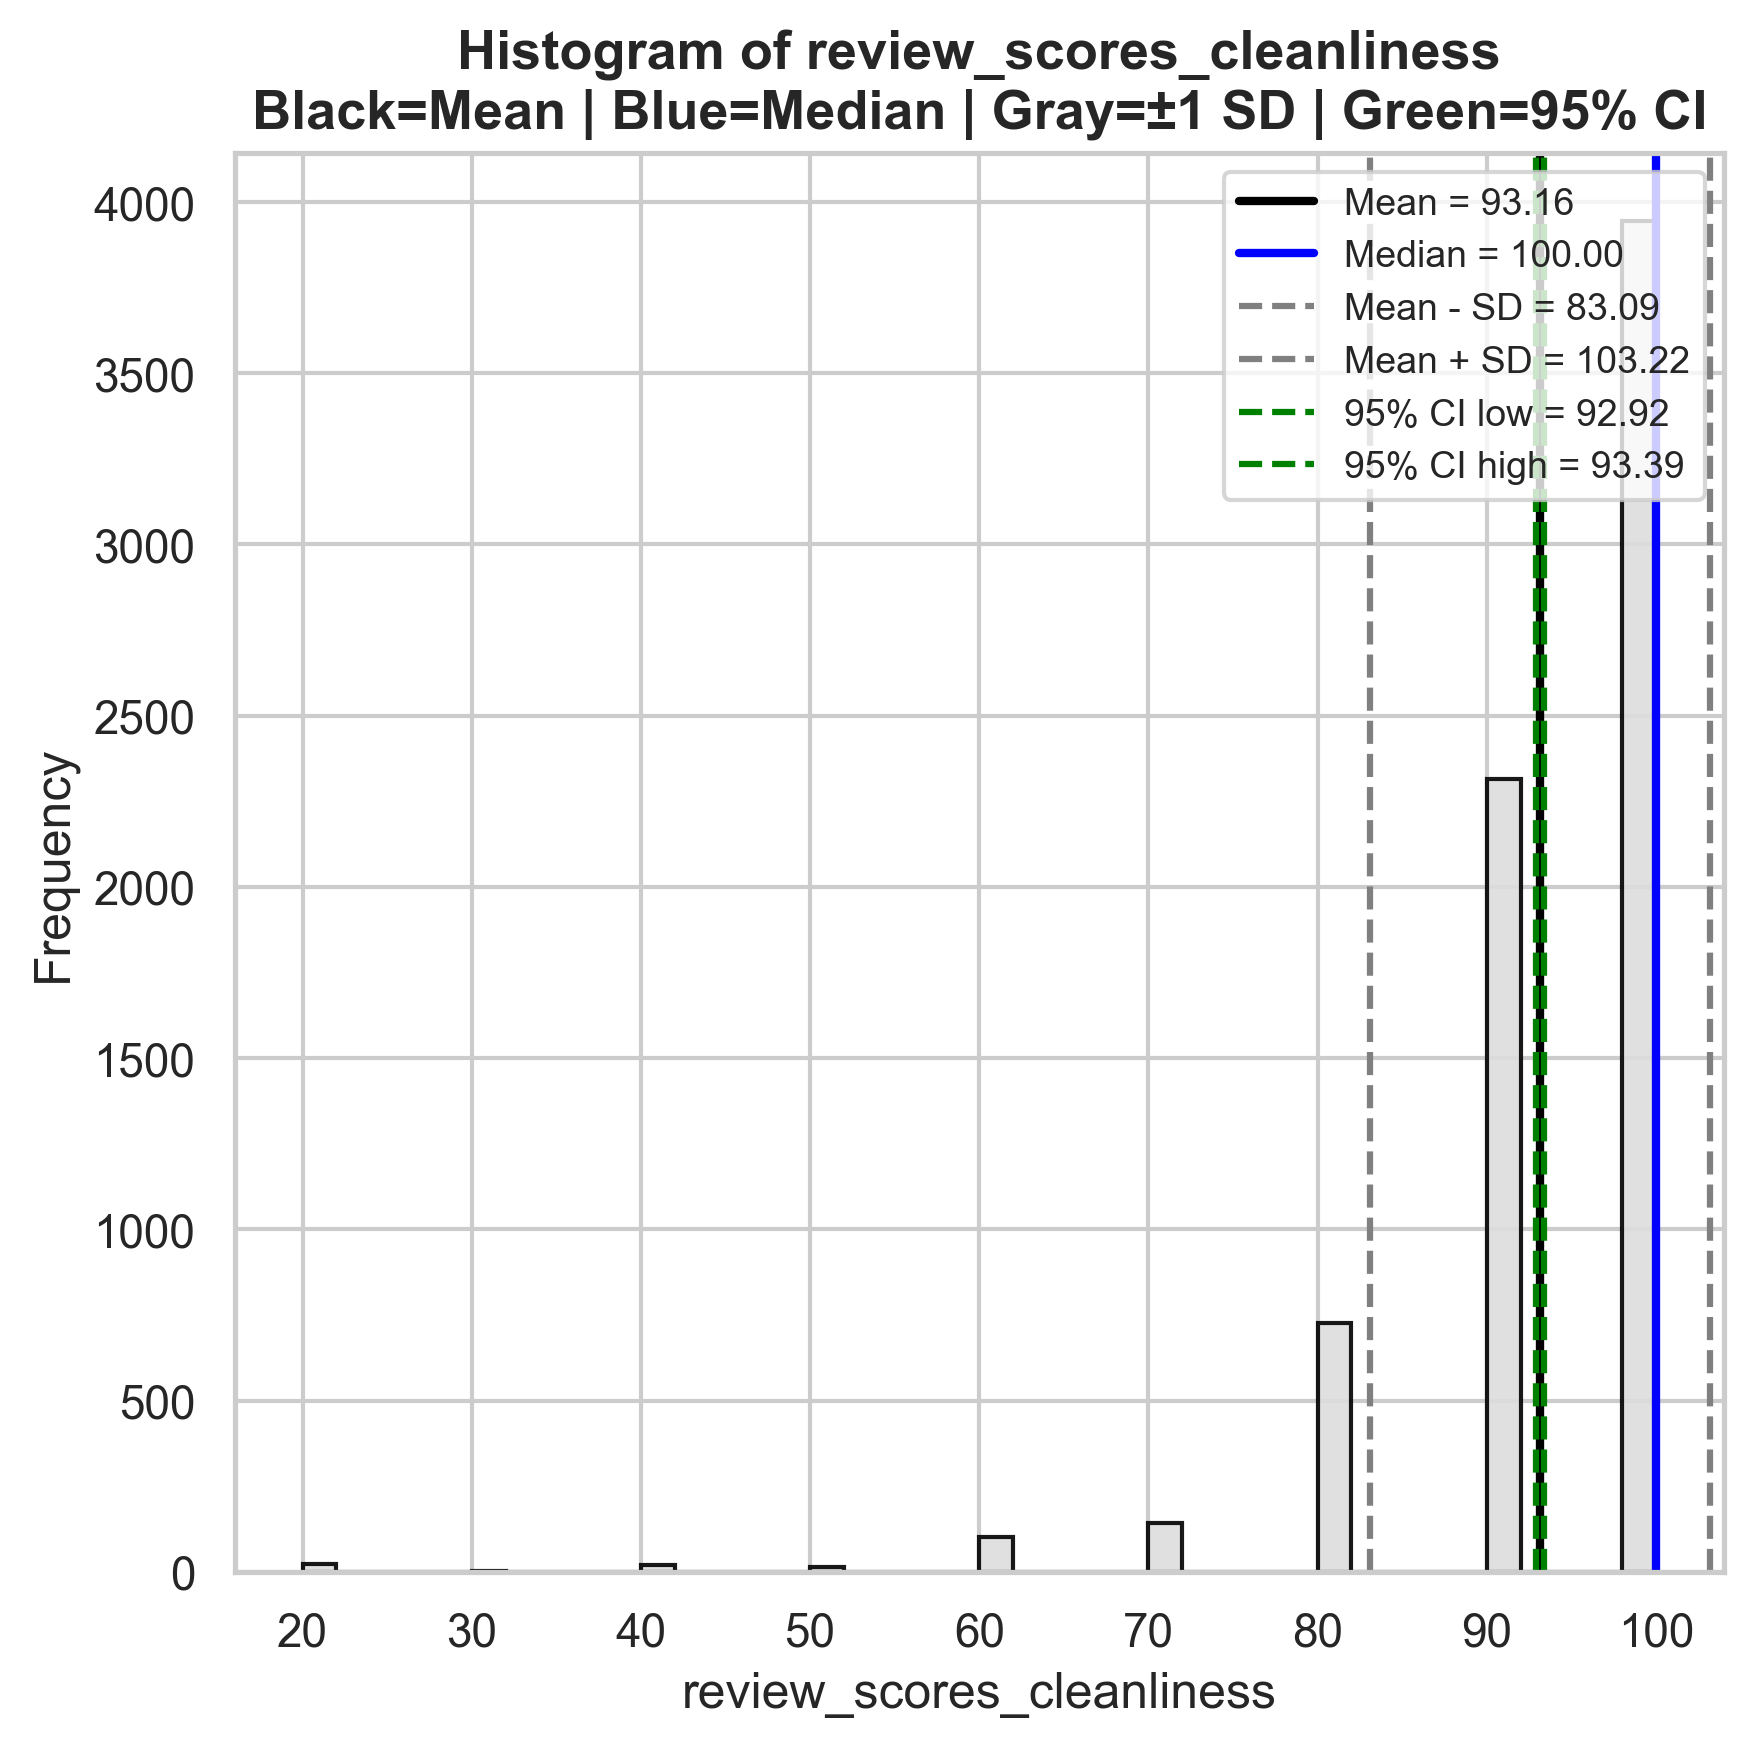

All files saved locally

Summary statistics


,column,n_non_null_numeric,mean,median,std,ci95_low,ci95_high,q1,q3,iqr,lower_fence,upper_fence,outlier_count,skewness,skewness_interpretation
0,review_scores_cleanliness,7288,93.155873,100.0,10.062348,92.924818,93.386928,90.0,100.0,10.0,75.0,115.0,303,-2.670186,Highly skewed.



Unique values table
Number of non-nulls: 7288
Number of unique values: 9


,column,value,count,frequency_non_null
0,review_scores_cleanliness,20.0,24,0.003293
1,review_scores_cleanliness,30.0,2,0.000274
2,review_scores_cleanliness,40.0,19,0.002607
3,review_scores_cleanliness,50.0,14,0.001921
4,review_scores_cleanliness,60.0,102,0.013996
5,review_scores_cleanliness,70.0,142,0.019484
6,review_scores_cleanliness,80.0,725,0.099479
7,review_scores_cleanliness,90.0,2314,0.317508
8,review_scores_cleanliness,100.0,3946,0.541438



Correlation table


,target_column,target_type,other_column,other_type,test,statistic,p_value,significance,significance_interpretation,note
0,review_scores_cleanliness,numeric,neighbourhood_name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
1,review_scores_cleanliness,numeric,neighbourhood_district,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
2,review_scores_cleanliness,numeric,city,categorical,Chi-square,108.169556,2.200656e-20,Significant,Statistically significant at p < 0.05.,
3,review_scores_cleanliness,numeric,room_type,categorical,Chi-square,6.965627,7.300145e-02,Not significant,Not statistically significant at p < 0.05.,
4,review_scores_cleanliness,numeric,accommodates,numeric,Pearson,-0.007637,5.144755e-01,Not significant,Not statistically significant at p < 0.05.,
5,review_scores_cleanliness,numeric,bathrooms,numeric,Pearson,0.029832,1.110659e-02,Significant,Statistically significant at p < 0.05.,
6,review_scores_cleanliness,numeric,bedrooms,numeric,Pearson,0.015068,1.999811e-01,Not significant,Not statistically significant at p < 0.05.,
7,review_scores_cleanliness,numeric,beds,numeric,Pearson,-0.009402,4.224274e-01,Not significant,Not statistically significant at p < 0.05.,
8,review_scores_cleanliness,numeric,price,numeric,Pearson,0.043150,2.555377e-04,Significant,Statistically significant at p < 0.05.,
9,review_scores_cleanliness,numeric,minimum_nights,numeric,Pearson,-0.015141,1.962126e-01,Not significant,Not statistically significant at p < 0.05.,



Transformation skewness table


,method,skewness,interpretation,normality_improvement
0,Original,-2.670186,Highly skewed.,Baseline.
1,Log Transformation,-5.408404,Highly skewed.,Did not improve normality; skewness increased.
2,Square Root Transformation,-3.709875,Highly skewed.,Did not improve normality; skewness increased.
3,Box-Cox Transformation,-0.496572,Approximately symmetric.,Improved strongly; distribution is closer to s...


In [140]:
analysis = analyze_single_field(
    df,
    target_col="review_scores_cleanliness",
    results_dir=RESULTS_DIR,
    show_in_notebook=True,
)

*Recommendations for Review Scores - Cleanliness*:
- mediana: 100.0
- IQR=10.0 [90.0; 100.0]
- 303 outliers determined
- The dataset is very Skewed due to Max values accumulation:
    * Max=100 - 54,1% of values
- no Transformation of the data should be applied, must be treated like categorical variable
- consider:
    * strongly and significantly associated with: city, is_instant_bookable
    * strongly and significantly correlated with: none found
    * medium and significantly correlated with: review_scores_rating (r=0.68), review_scores_accuracy (r=0.59), review_scores_checkin (r=0.45), review_scores_communication (r=0.48), review_scores_value (r=0.60)
    * weakly and significantly correlated with: review_scores_location (r=0.30)
- Non parametric tests must be used

##### CHECKIN

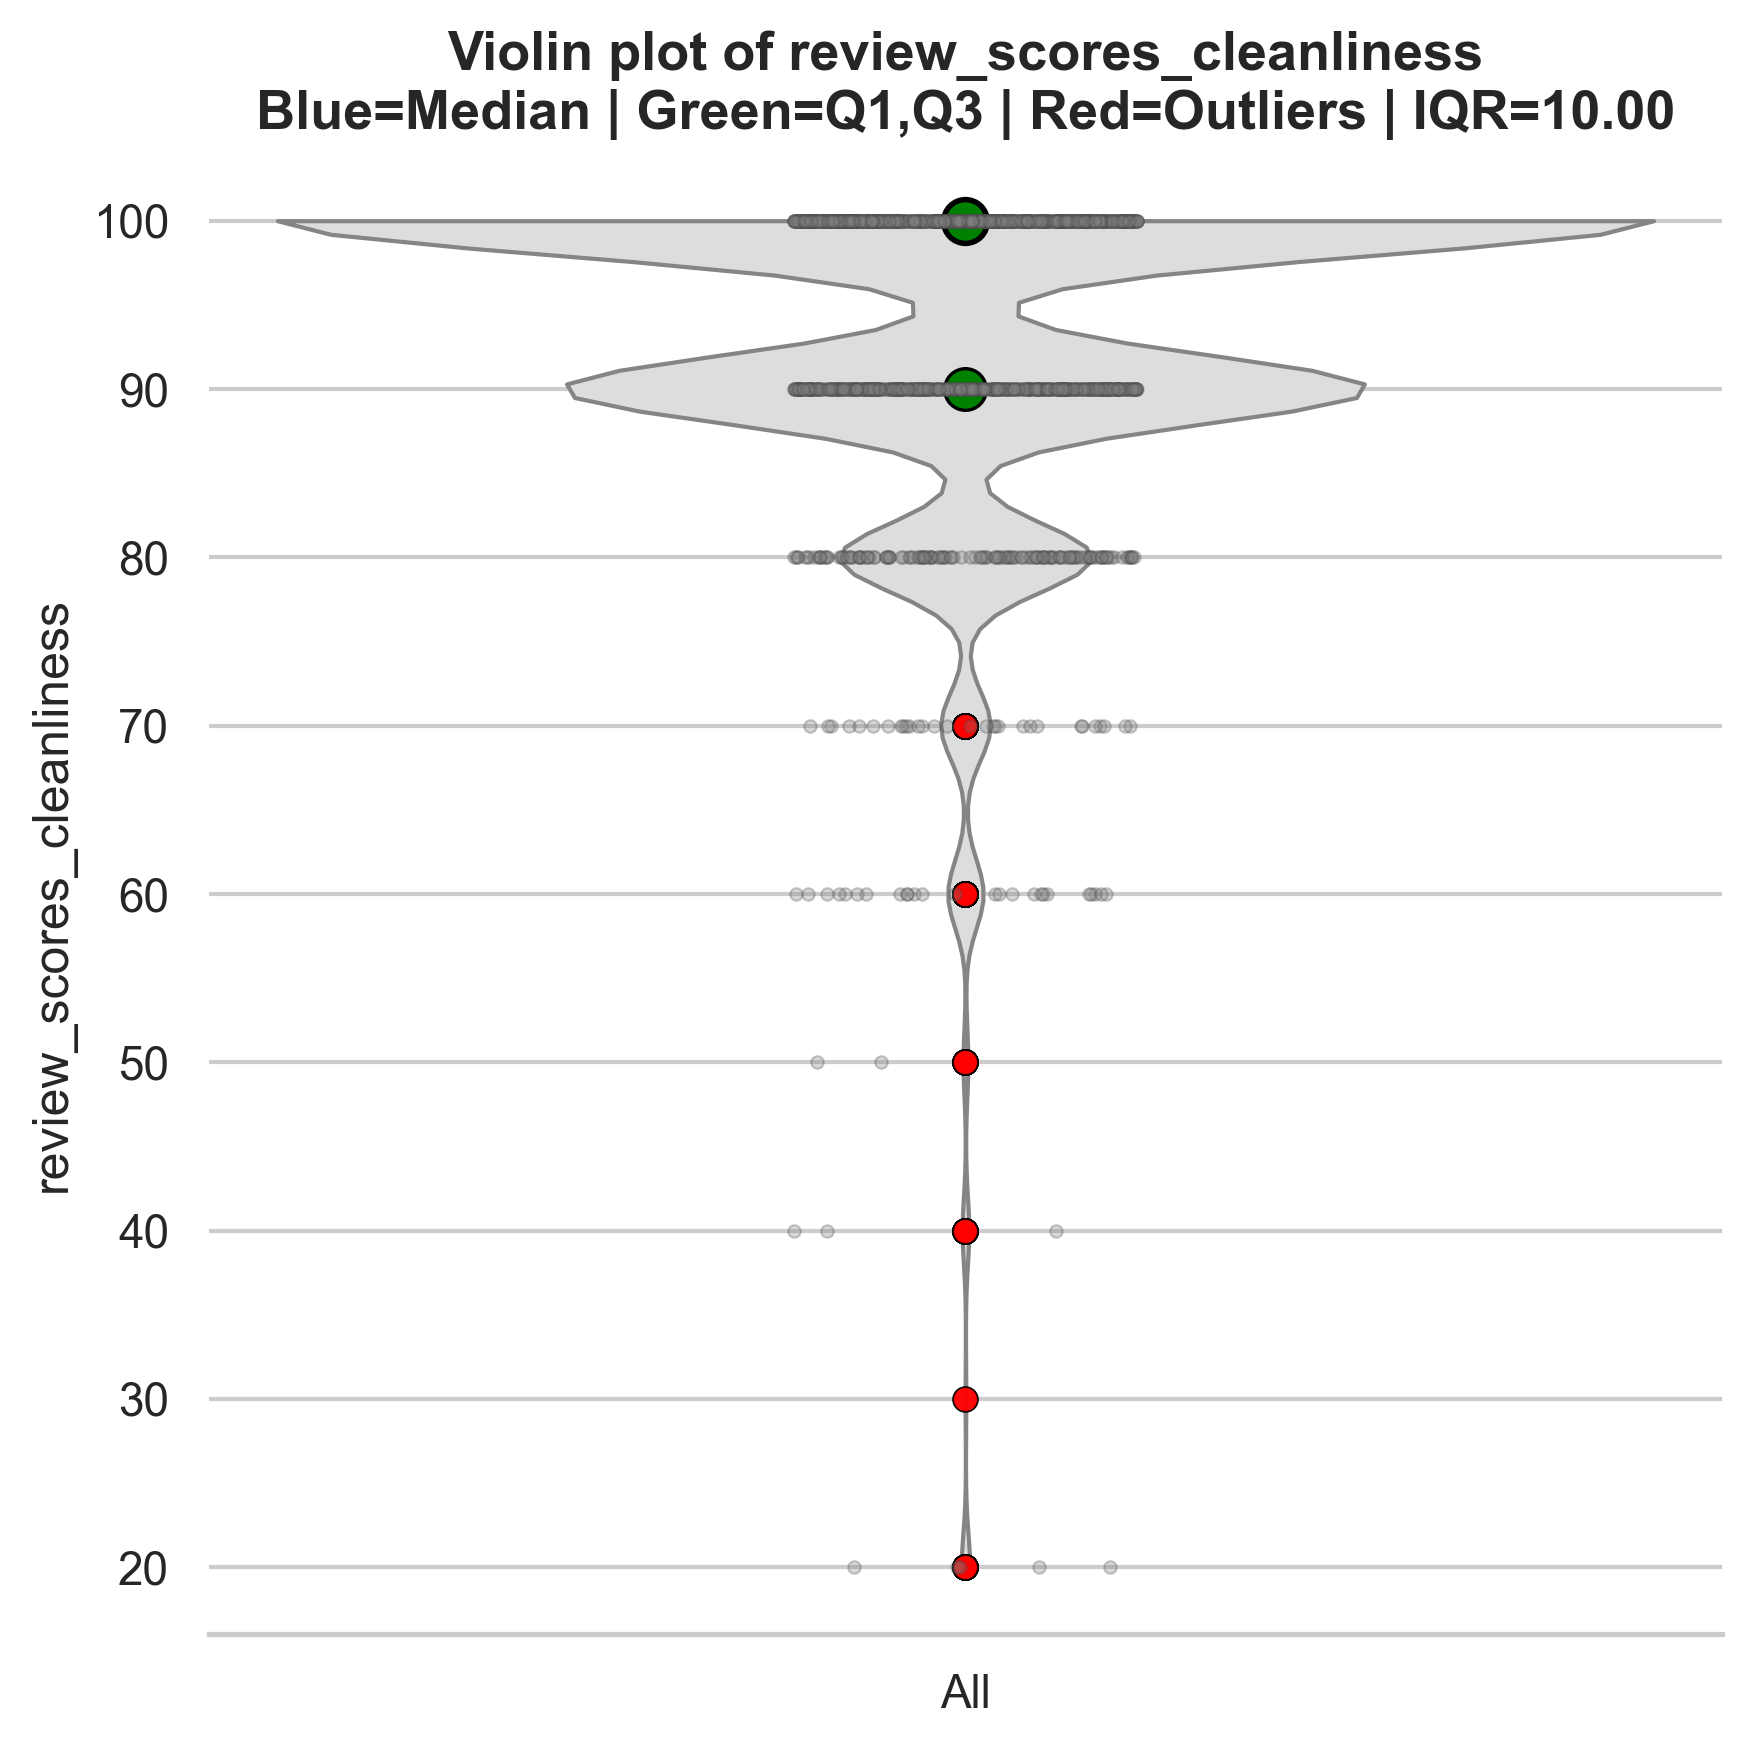

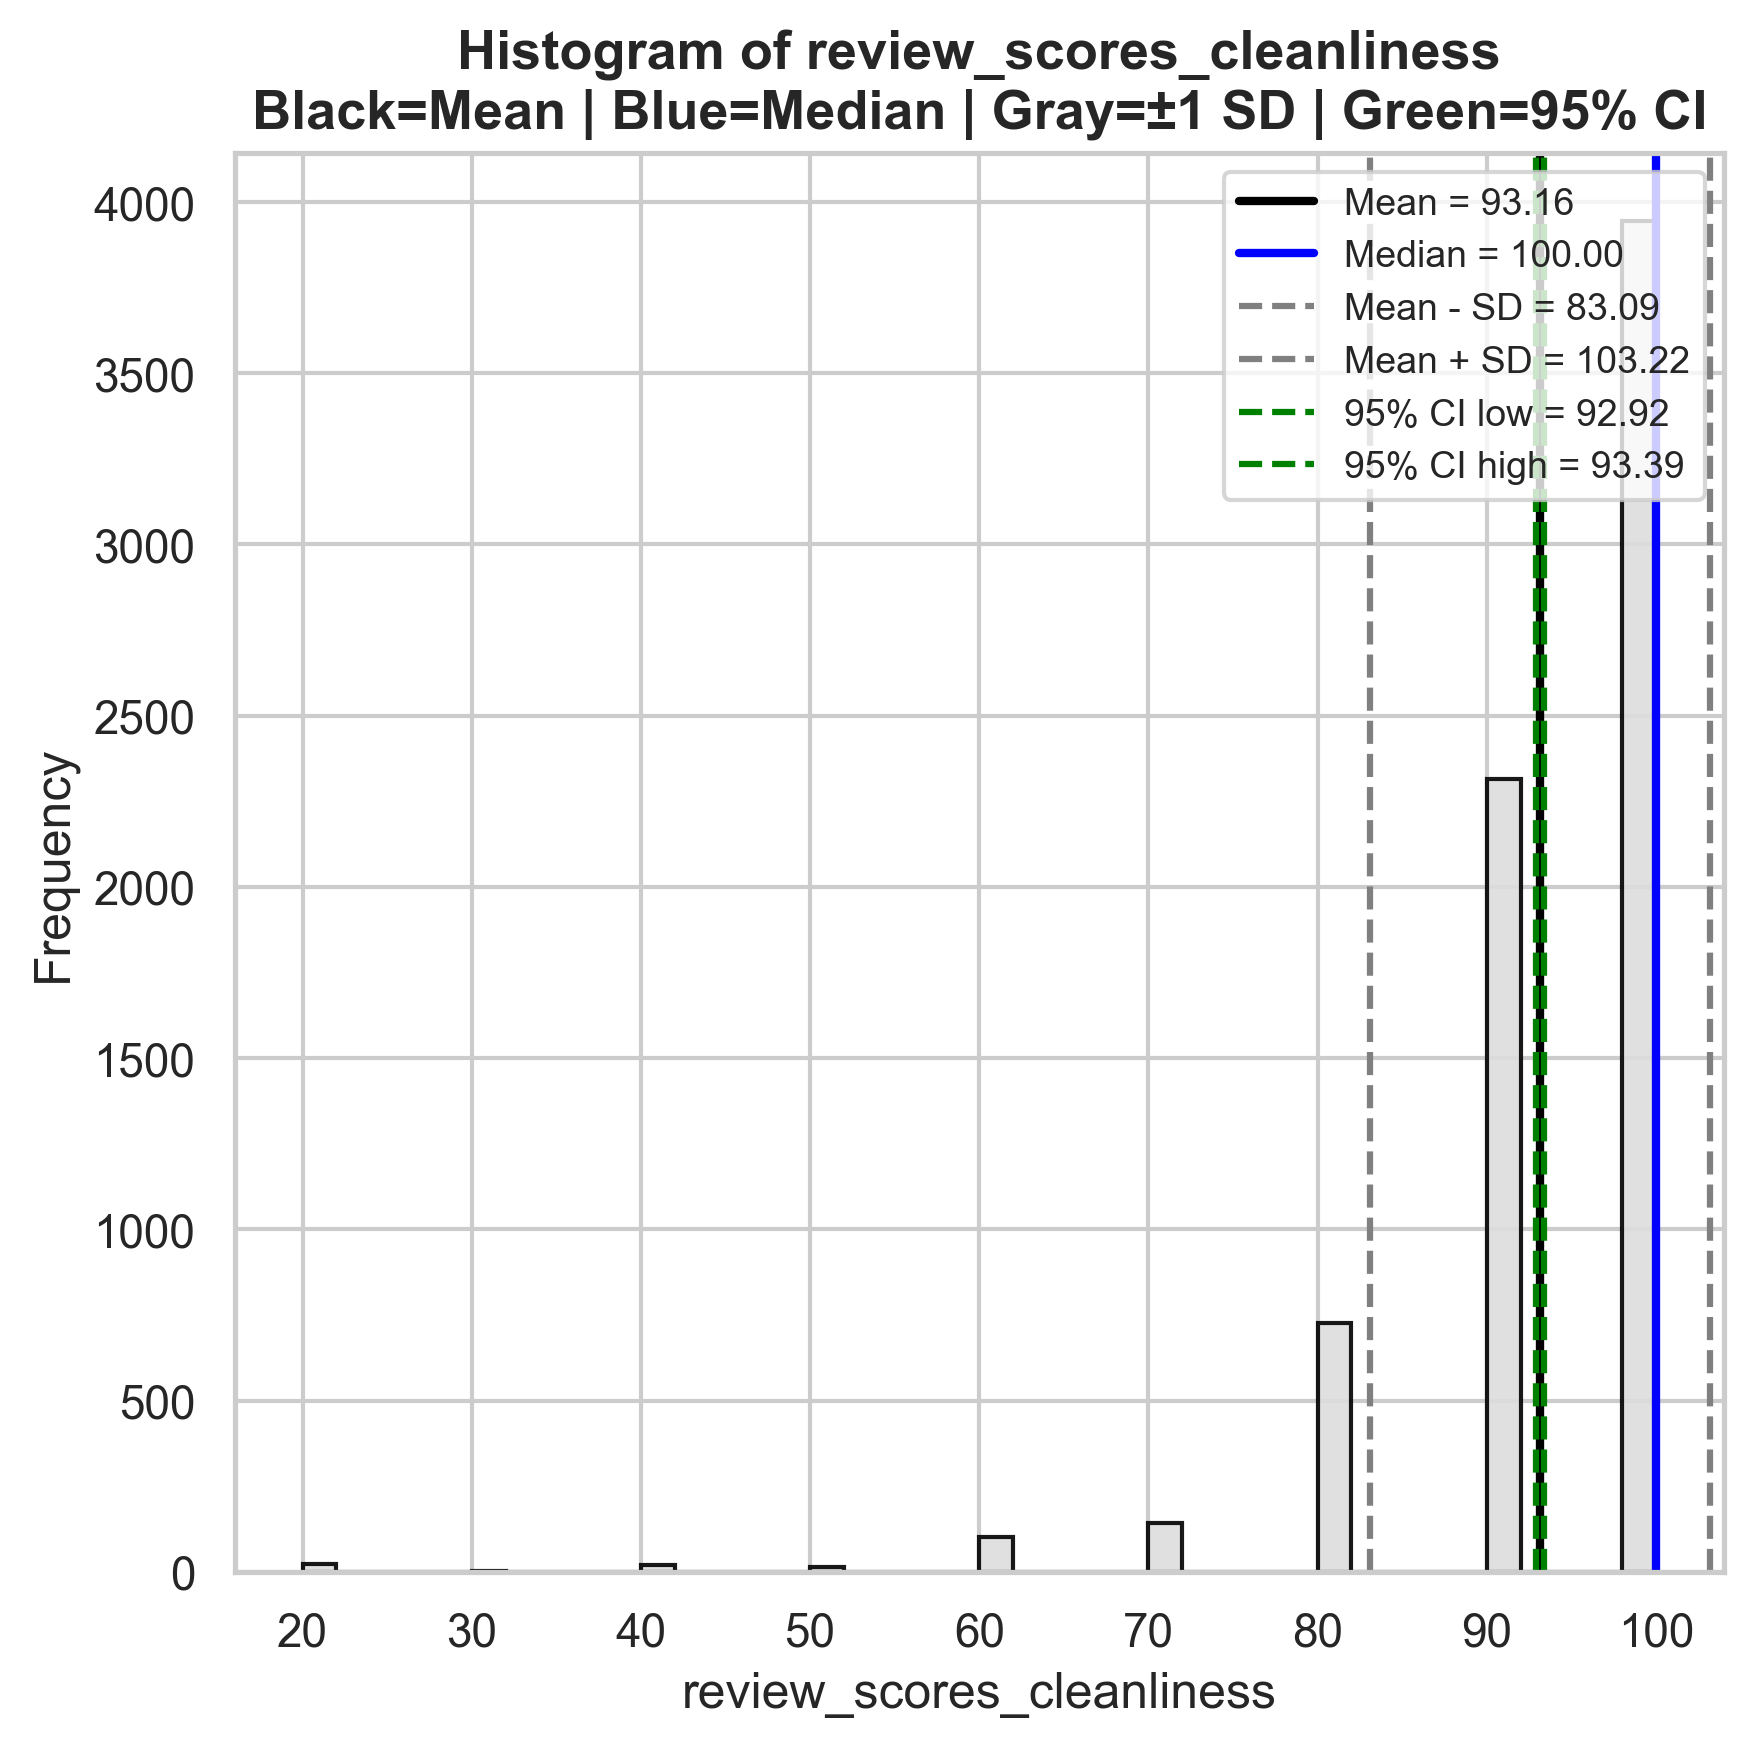

All files saved locally

Summary statistics


,column,n_non_null_numeric,mean,median,std,ci95_low,ci95_high,q1,q3,iqr,lower_fence,upper_fence,outlier_count,skewness,skewness_interpretation
0,review_scores_cleanliness,7288,93.155873,100.0,10.062348,92.924818,93.386928,90.0,100.0,10.0,75.0,115.0,303,-2.670186,Highly skewed.



Unique values table
Number of non-nulls: 7288
Number of unique values: 9


,column,value,count,frequency_non_null
0,review_scores_cleanliness,20.0,24,0.003293
1,review_scores_cleanliness,30.0,2,0.000274
2,review_scores_cleanliness,40.0,19,0.002607
3,review_scores_cleanliness,50.0,14,0.001921
4,review_scores_cleanliness,60.0,102,0.013996
5,review_scores_cleanliness,70.0,142,0.019484
6,review_scores_cleanliness,80.0,725,0.099479
7,review_scores_cleanliness,90.0,2314,0.317508
8,review_scores_cleanliness,100.0,3946,0.541438



Correlation table


,target_column,target_type,other_column,other_type,test,statistic,p_value,significance,significance_interpretation,note
0,review_scores_cleanliness,numeric,neighbourhood_name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
1,review_scores_cleanliness,numeric,neighbourhood_district,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
2,review_scores_cleanliness,numeric,city,categorical,Chi-square,108.169556,2.200656e-20,Significant,Statistically significant at p < 0.05.,
3,review_scores_cleanliness,numeric,room_type,categorical,Chi-square,6.965627,7.300145e-02,Not significant,Not statistically significant at p < 0.05.,
4,review_scores_cleanliness,numeric,accommodates,numeric,Pearson,-0.007637,5.144755e-01,Not significant,Not statistically significant at p < 0.05.,
5,review_scores_cleanliness,numeric,bathrooms,numeric,Pearson,0.029832,1.110659e-02,Significant,Statistically significant at p < 0.05.,
6,review_scores_cleanliness,numeric,bedrooms,numeric,Pearson,0.015068,1.999811e-01,Not significant,Not statistically significant at p < 0.05.,
7,review_scores_cleanliness,numeric,beds,numeric,Pearson,-0.009402,4.224274e-01,Not significant,Not statistically significant at p < 0.05.,
8,review_scores_cleanliness,numeric,price,numeric,Pearson,0.043150,2.555377e-04,Significant,Statistically significant at p < 0.05.,
9,review_scores_cleanliness,numeric,minimum_nights,numeric,Pearson,-0.015141,1.962126e-01,Not significant,Not statistically significant at p < 0.05.,



Transformation skewness table


,method,skewness,interpretation,normality_improvement
0,Original,-2.670186,Highly skewed.,Baseline.
1,Log Transformation,-5.408404,Highly skewed.,Did not improve normality; skewness increased.
2,Square Root Transformation,-3.709875,Highly skewed.,Did not improve normality; skewness increased.
3,Box-Cox Transformation,-0.496572,Approximately symmetric.,Improved strongly; distribution is closer to s...


In [141]:
analysis = analyze_single_field(
    df,
    target_col="review_scores_cleanliness",
    results_dir=RESULTS_DIR,
    show_in_notebook=True,
)

*Recommendations for Review Scores - Checkin*:
- mediana: 100.0
- IQR=10.0 [90.0; 100.0]
- 303 outliers determined
- The dataset is very Skewed due to Max values accumulation:
    * Max=100 - 54,1% of values
- no Transformation of the data should be applied, must be treated like categorical variable
- consider:
    * strongly and significantly associated with: city, is_instant_bookable
    * strongly and significantly correlated with: none found
    * medium and significantly correlated with: review_scores_rating (r=0.68), review_scores_accuracy (r=0.59), review_scores_checkin (r=0.45), review_scores_communication (r=0.48), review_scores_value (r=0.6)
    * weakly and significantly correlated with: review_scores_location (r=0.30)
- Non parametric tests must be used

##### COMMUNICATION

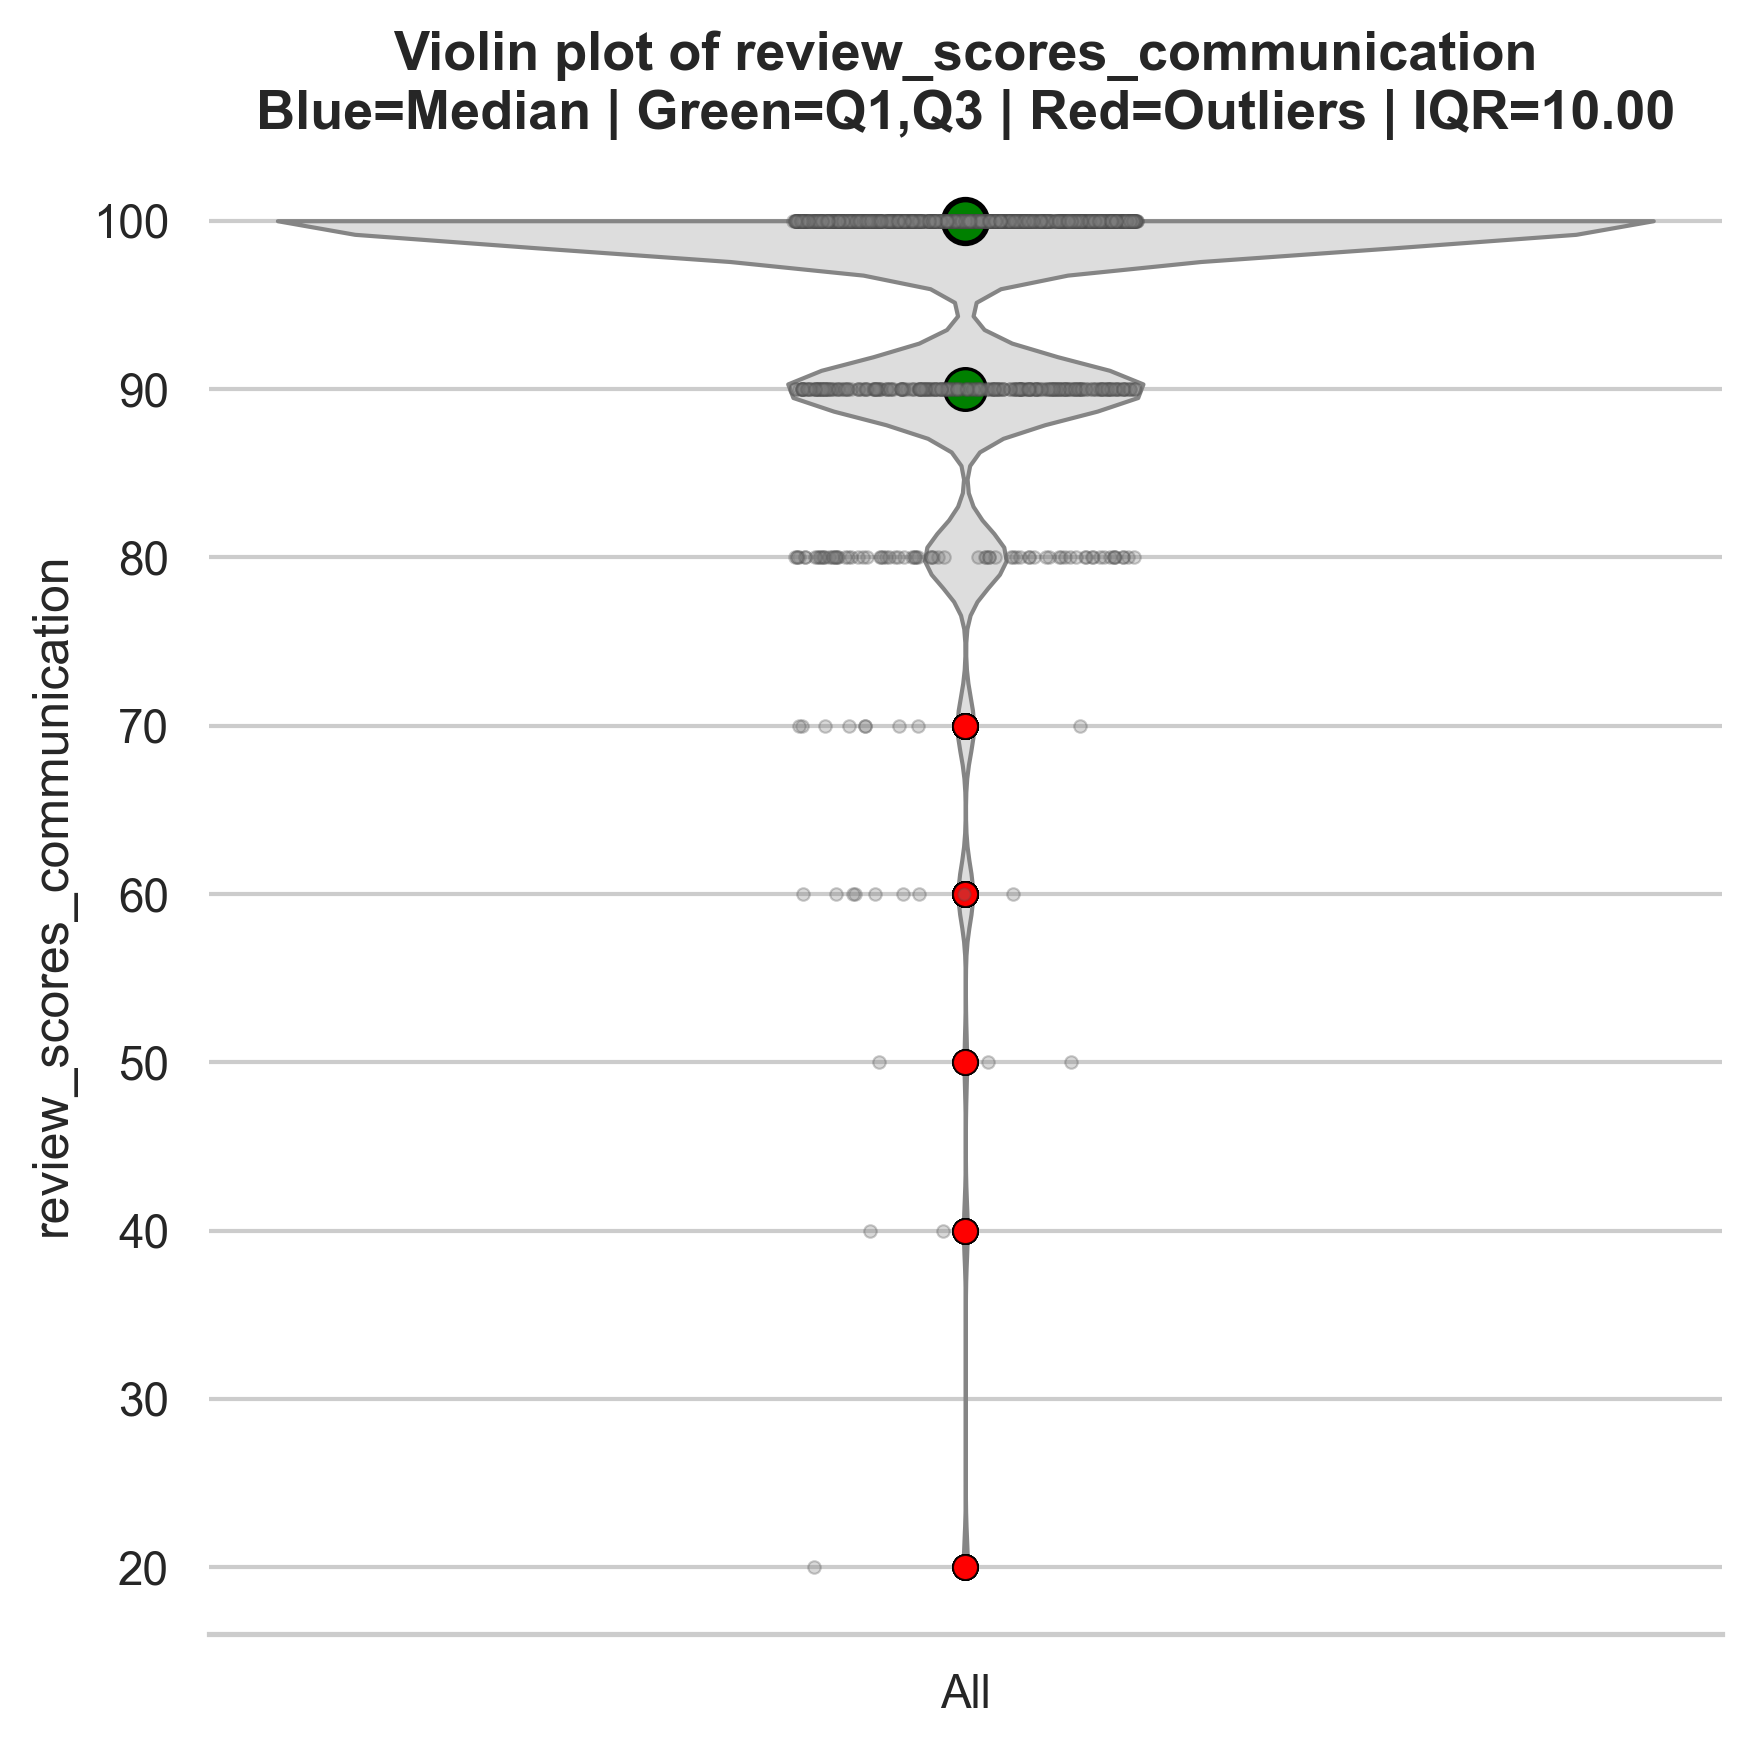

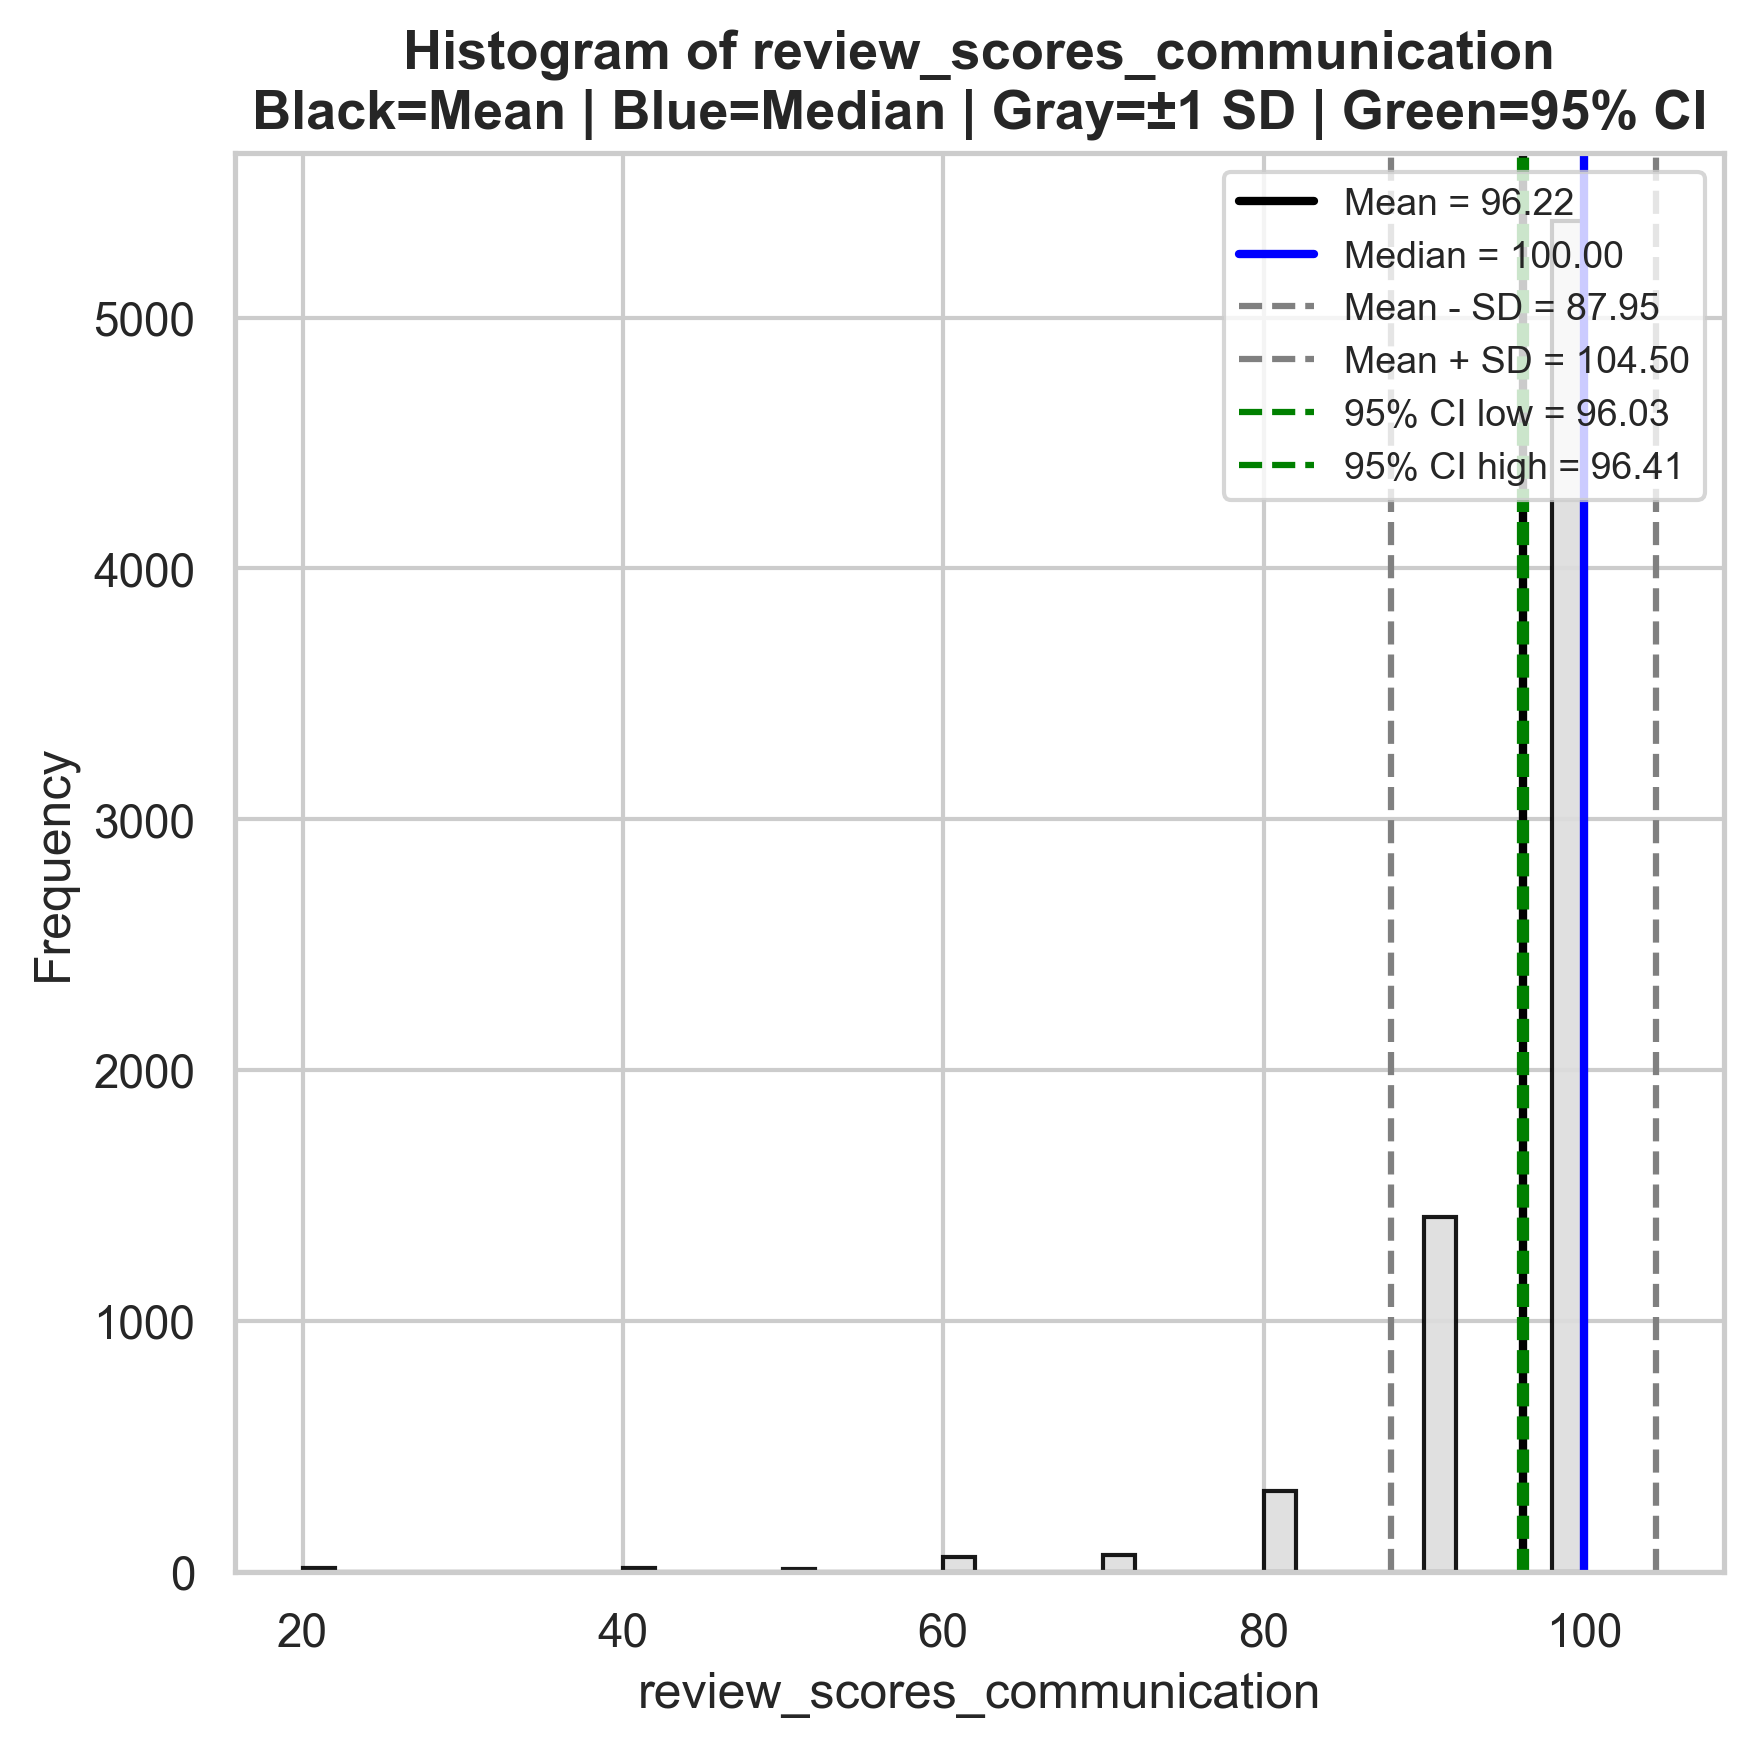

All files saved locally

Summary statistics


,column,n_non_null_numeric,mean,median,std,ci95_low,ci95_high,q1,q3,iqr,lower_fence,upper_fence,outlier_count,skewness,skewness_interpretation
0,review_scores_communication,7286,96.221521,100.0,8.275278,96.031475,96.411567,90.0,100.0,10.0,75.0,115.0,164,-3.898734,Highly skewed.



Unique values table
Number of non-nulls: 7286
Number of unique values: 8


,column,value,count,frequency_non_null
0,review_scores_communication,20.0,16,0.002196
1,review_scores_communication,40.0,15,0.002059
2,review_scores_communication,50.0,10,0.001372
3,review_scores_communication,60.0,58,0.007960
4,review_scores_communication,70.0,65,0.008921
5,review_scores_communication,80.0,322,0.044194
6,review_scores_communication,90.0,1414,0.194071
7,review_scores_communication,100.0,5386,0.739226



Correlation table


,target_column,target_type,other_column,other_type,test,statistic,p_value,significance,significance_interpretation,note
0,review_scores_communication,numeric,neighbourhood_name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
1,review_scores_communication,numeric,neighbourhood_district,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
2,review_scores_communication,numeric,city,categorical,Chi-square,78.714170,2.518618e-14,Significant,Statistically significant at p < 0.05.,
3,review_scores_communication,numeric,room_type,categorical,Chi-square,1.983552,5.758276e-01,Not significant,Not statistically significant at p < 0.05.,
4,review_scores_communication,numeric,accommodates,numeric,Pearson,-0.020217,8.442178e-02,Not significant,Not statistically significant at p < 0.05.,
5,review_scores_communication,numeric,bathrooms,numeric,Pearson,0.007234,5.381696e-01,Not significant,Not statistically significant at p < 0.05.,
6,review_scores_communication,numeric,bedrooms,numeric,Pearson,-0.002531,8.295759e-01,Not significant,Not statistically significant at p < 0.05.,
7,review_scores_communication,numeric,beds,numeric,Pearson,-0.009263,4.293670e-01,Not significant,Not statistically significant at p < 0.05.,
8,review_scores_communication,numeric,price,numeric,Pearson,-0.004753,6.872736e-01,Not significant,Not statistically significant at p < 0.05.,
9,review_scores_communication,numeric,minimum_nights,numeric,Pearson,-0.013407,2.525310e-01,Not significant,Not statistically significant at p < 0.05.,



Transformation skewness table


,method,skewness,interpretation,normality_improvement
0,Original,-3.898734,Highly skewed.,Baseline.
1,Log Transformation,-7.154854,Highly skewed.,Did not improve normality; skewness increased.
2,Square Root Transformation,-5.137885,Highly skewed.,Did not improve normality; skewness increased.
3,Box-Cox Transformation,-1.118916,Highly skewed.,Improved; skewness decreased. Improved using l...


In [142]:
analysis = analyze_single_field(
    df,
    target_col="review_scores_communication",
    results_dir=RESULTS_DIR,
    show_in_notebook=True,
)

*Recommendations for Review Scores - Communication*:
- mediana: 100.0
- IQR=10.0 [90.0; 100.0]
- 164 outliers determined
- The dataset is very Skewed due to Max values accumulation:
    * Max=100 - 73,9% of values
- no Transformation of the data should be applied, must be treated like categorical variable
- consider:
    * strongly and significantly associated with: city, is_instant_bookable
    * strongly and significantly correlated with: none found
    * medium and significantly correlated with: review_scores_rating (r=0.62), review_scores_accuracy (r=0.59), review_scores_cleanliness (r=0.48), review_scores_checkin (r=0.66), review_scores_location (r=0.35), review_scores_value (r=0.52)
    * weakly and significantly correlated with: number_of_reviews (r=0.11)
- Non parametric tests must be used

##### LOCATION

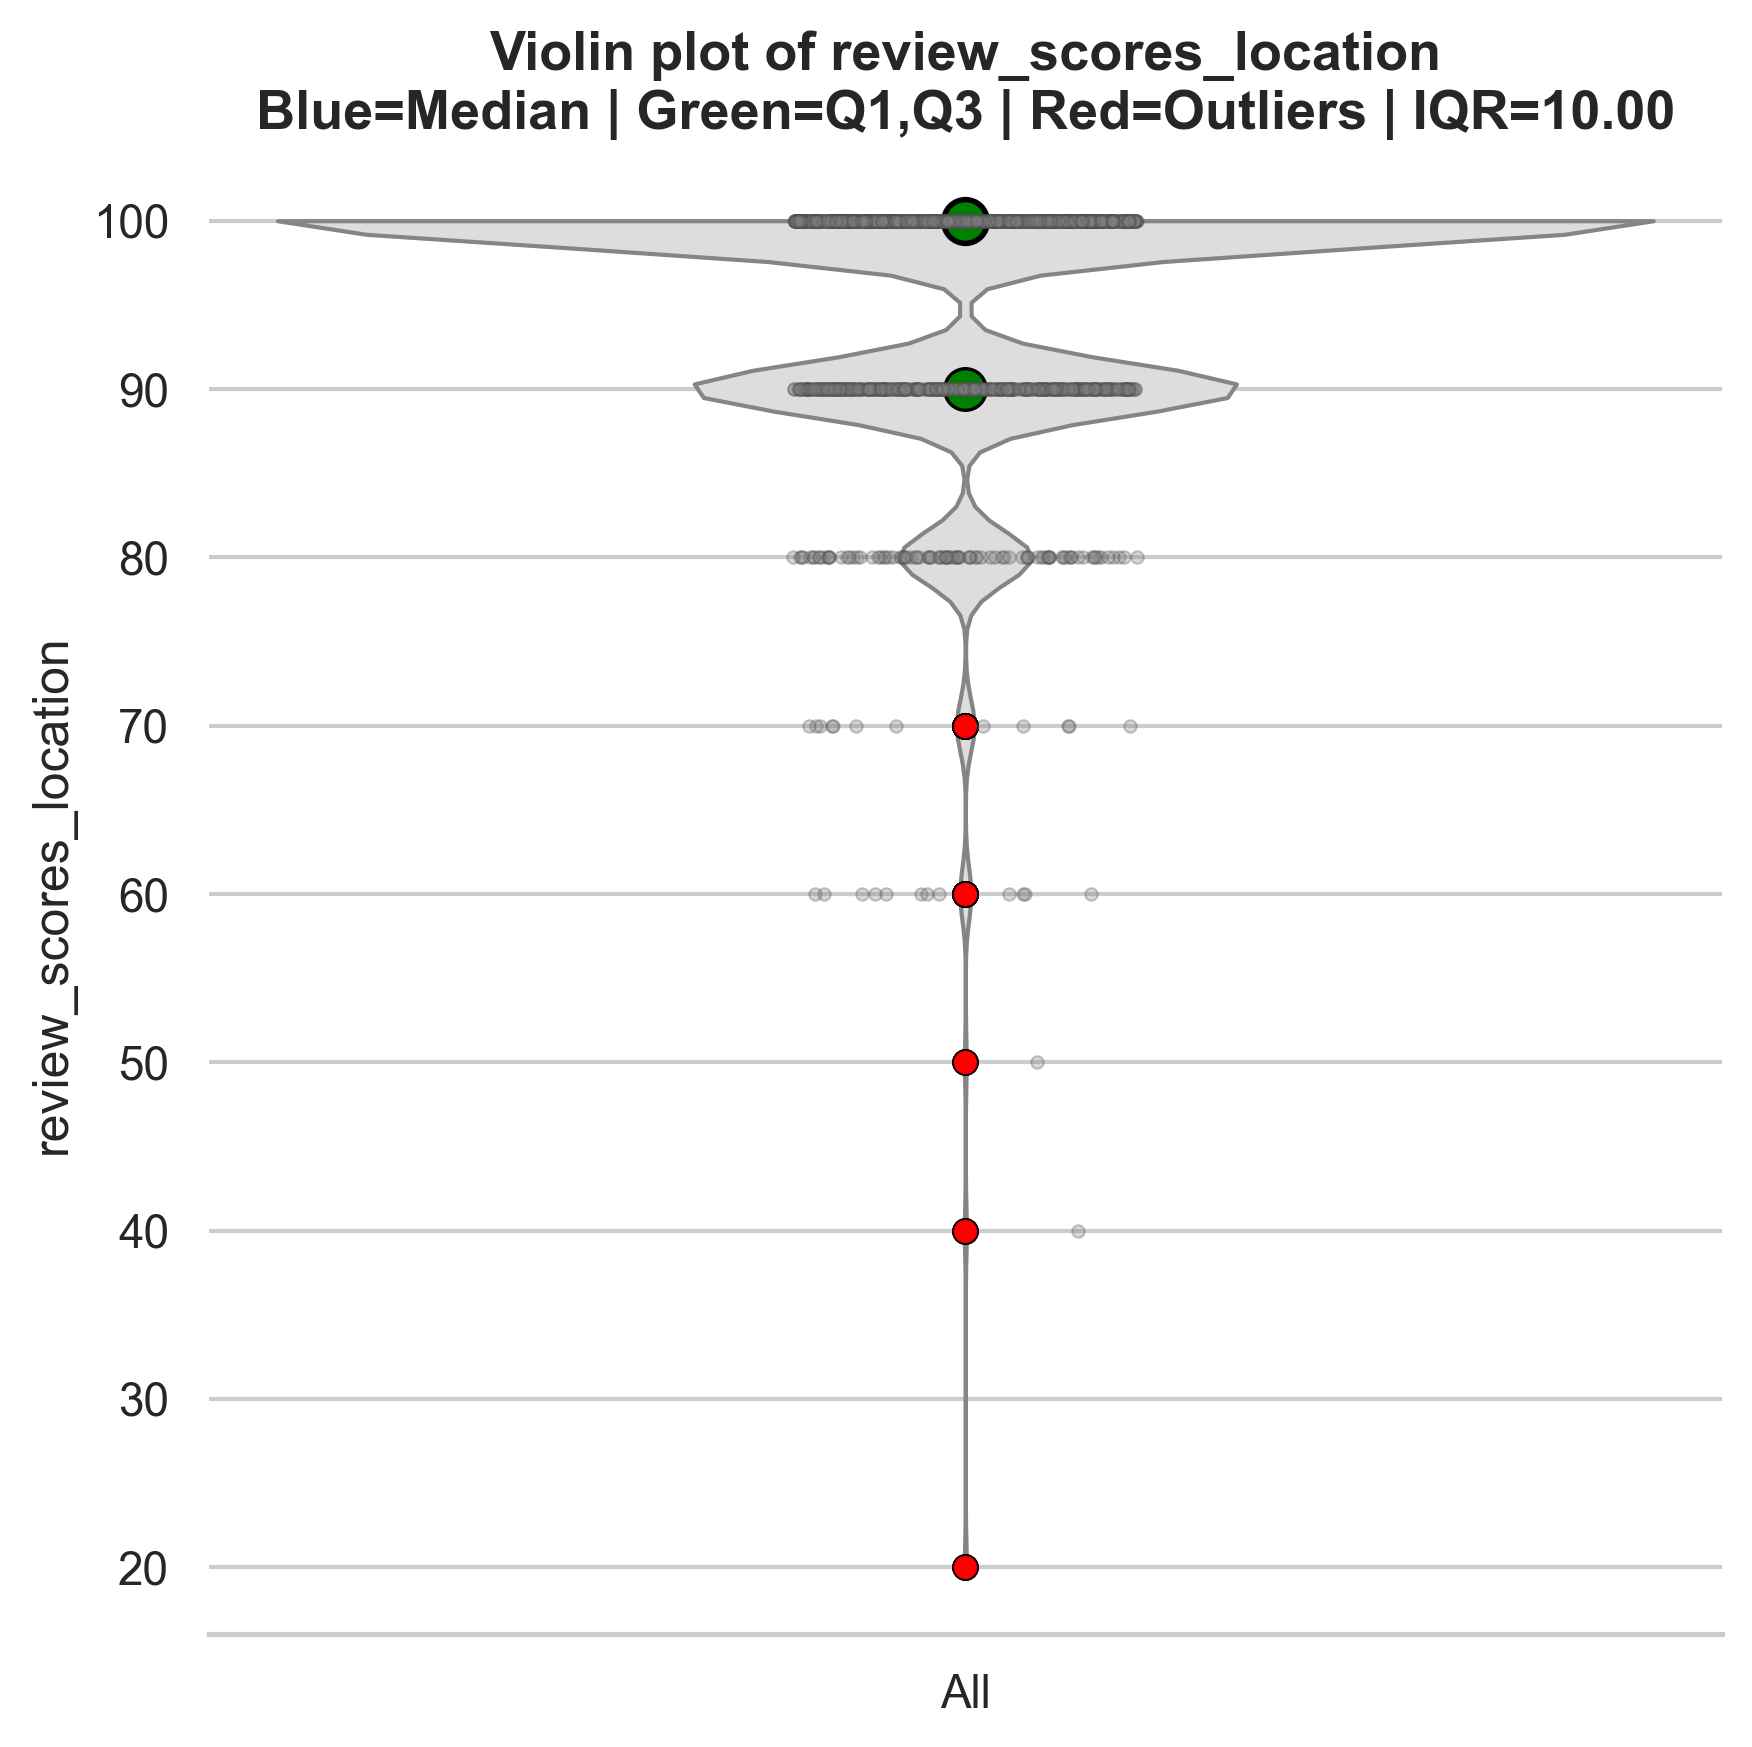

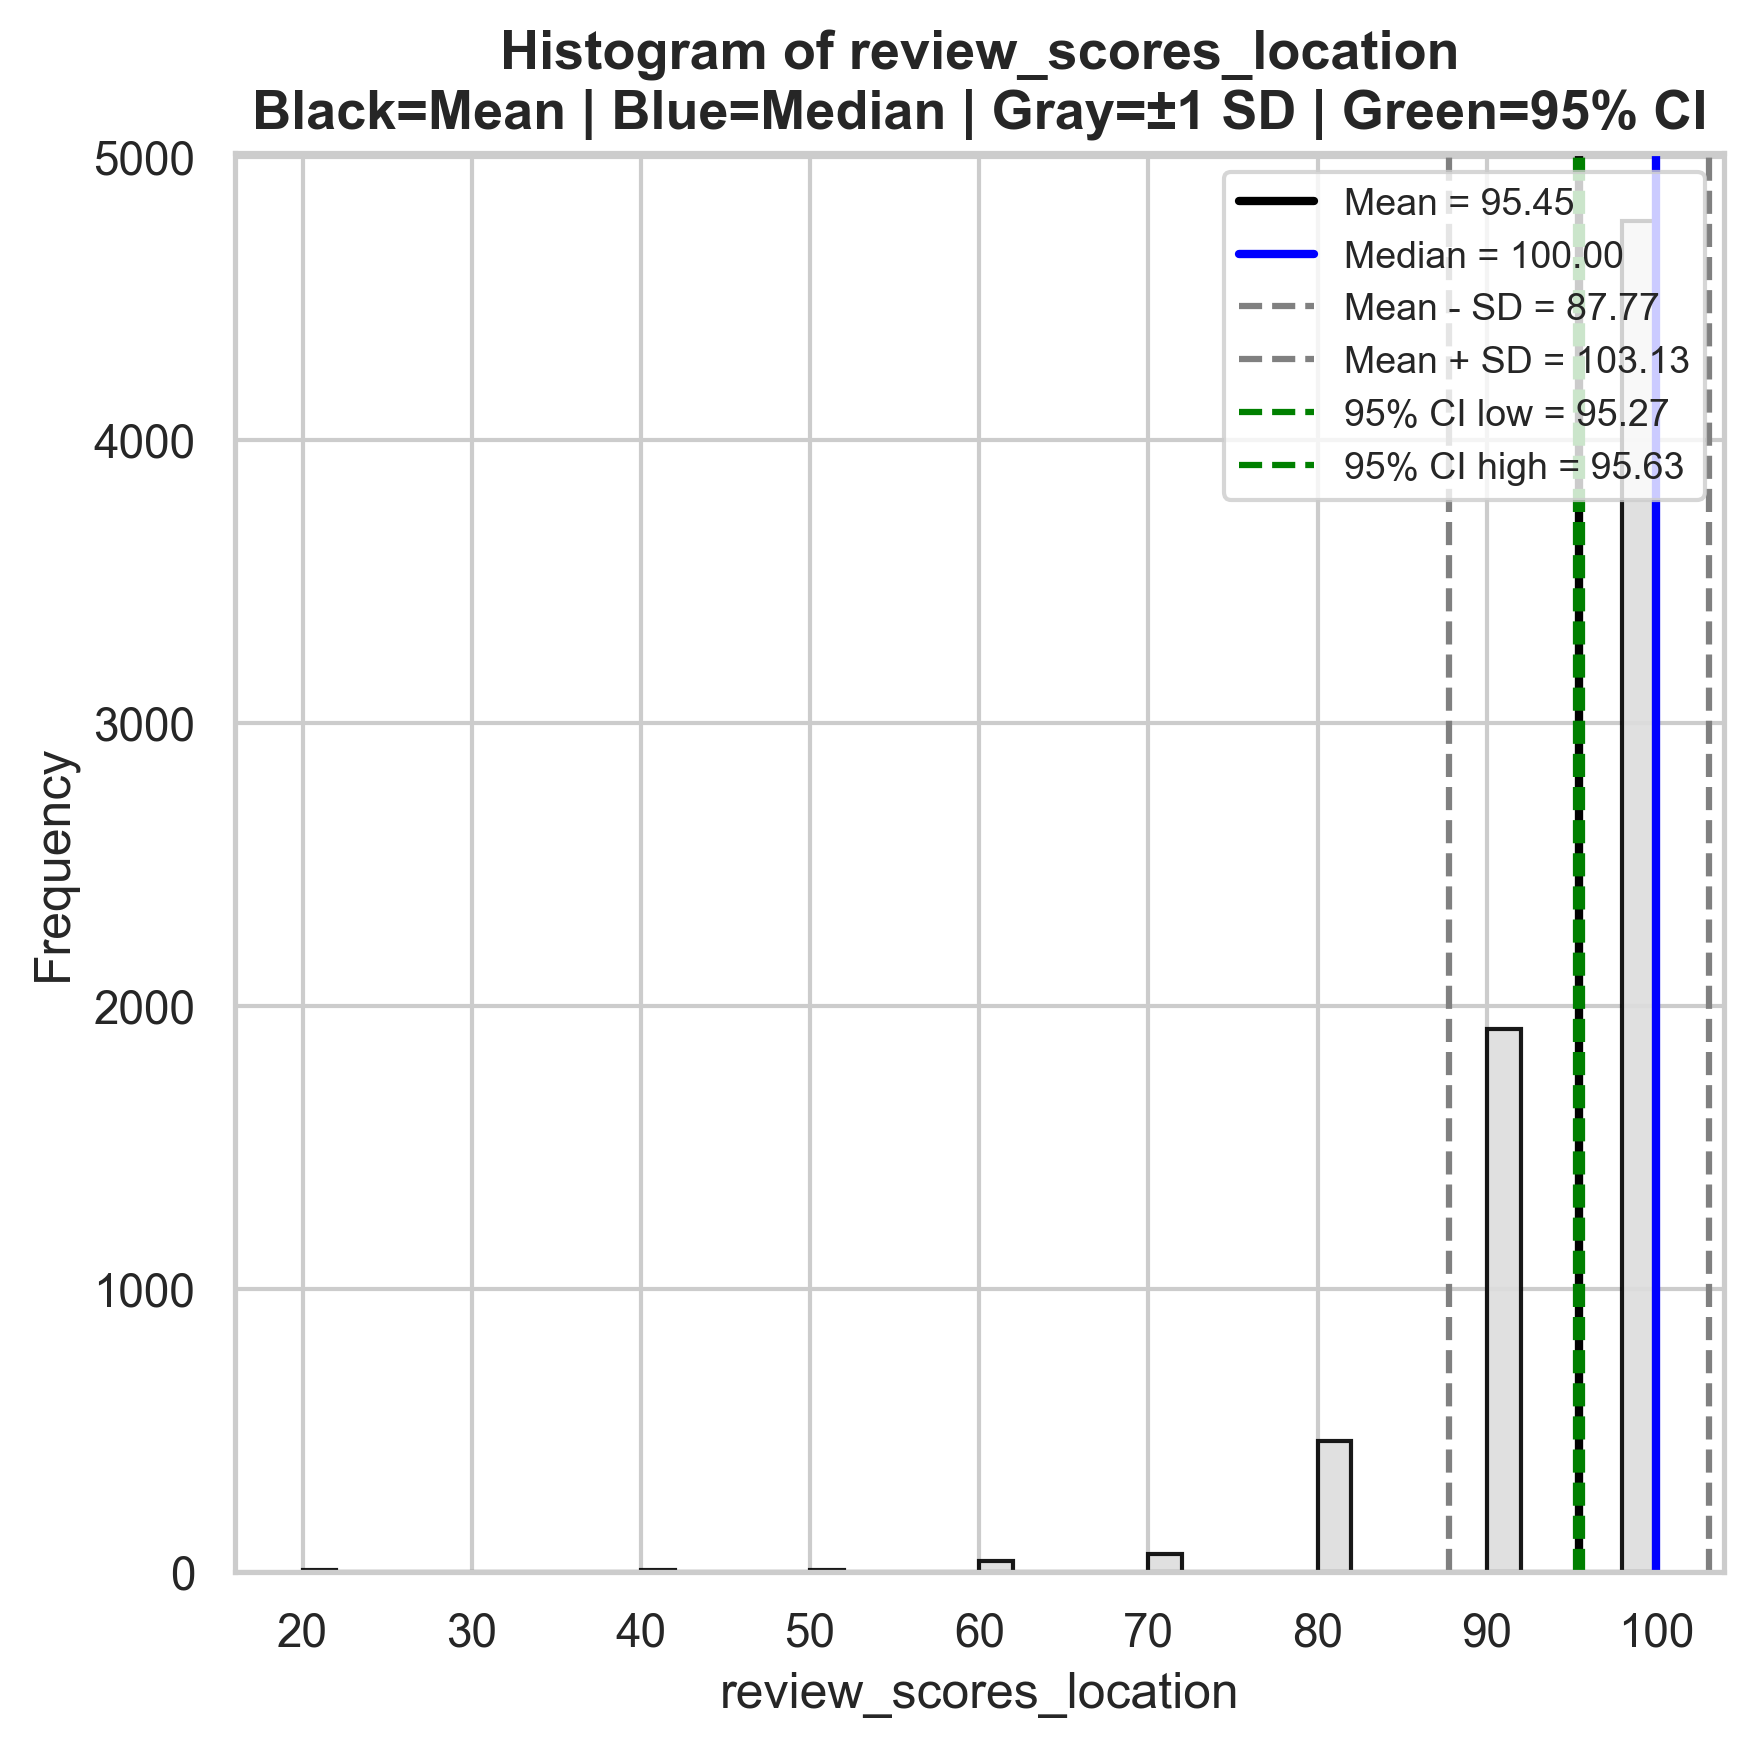

All files saved locally

Summary statistics


,column,n_non_null_numeric,mean,median,std,ci95_low,ci95_high,q1,q3,iqr,lower_fence,upper_fence,outlier_count,skewness,skewness_interpretation
0,review_scores_location,7276,95.449423,100.0,7.677614,95.272981,95.625864,90.0,100.0,10.0,75.0,115.0,121,-2.759568,Highly skewed.



Unique values table
Number of non-nulls: 7276
Number of unique values: 8


,column,value,count,frequency_non_null
0,review_scores_location,20.0,7,0.000962
1,review_scores_location,40.0,7,0.000962
2,review_scores_location,50.0,6,0.000825
3,review_scores_location,60.0,39,0.005360
4,review_scores_location,70.0,62,0.008521
5,review_scores_location,80.0,461,0.063359
6,review_scores_location,90.0,1919,0.263744
7,review_scores_location,100.0,4775,0.656267



Correlation table


,target_column,target_type,other_column,other_type,test,statistic,p_value,significance,significance_interpretation,note
0,review_scores_location,numeric,neighbourhood_name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
1,review_scores_location,numeric,neighbourhood_district,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
2,review_scores_location,numeric,city,categorical,Chi-square,85.648392,9.656586e-16,Significant,Statistically significant at p < 0.05.,
3,review_scores_location,numeric,room_type,categorical,Chi-square,9.603108,2.225938e-02,Significant,Statistically significant at p < 0.05.,
4,review_scores_location,numeric,accommodates,numeric,Pearson,-0.055846,1.874080e-06,Significant,Statistically significant at p < 0.05.,
5,review_scores_location,numeric,bathrooms,numeric,Pearson,-0.013392,2.548021e-01,Not significant,Not statistically significant at p < 0.05.,
6,review_scores_location,numeric,bedrooms,numeric,Pearson,-0.061517,1.671371e-07,Significant,Statistically significant at p < 0.05.,
7,review_scores_location,numeric,beds,numeric,Pearson,-0.067060,1.042622e-08,Significant,Statistically significant at p < 0.05.,
8,review_scores_location,numeric,price,numeric,Pearson,0.000989,9.332679e-01,Not significant,Not statistically significant at p < 0.05.,
9,review_scores_location,numeric,minimum_nights,numeric,Pearson,-0.018001,1.246966e-01,Not significant,Not statistically significant at p < 0.05.,



Transformation skewness table


,method,skewness,interpretation,normality_improvement
0,Original,-2.759568,Highly skewed.,Baseline.
1,Log Transformation,-5.803350,Highly skewed.,Did not improve normality; skewness increased.
2,Square Root Transformation,-3.796870,Highly skewed.,Did not improve normality; skewness increased.
3,Box-Cox Transformation,-0.726379,Moderately skewed.,Improved; skewness decreased. Improved using l...


In [143]:
analysis = analyze_single_field(
    df,
    target_col="review_scores_location",
    results_dir=RESULTS_DIR,
    show_in_notebook=True,
)

*Recommendations for Review Scores - Location*:
- mediana: 100.0
- IQR=10.0 [90.0; 100.0]
- 121 outliers determined
- The dataset is very Skewed due to Max values accumulation:
    * Max=100 - 65,6% of values
- no Transformation of the data should be applied, must be treated like categorical variable
- consider:
    * strongly and significantly associated with: city, room_type
    * strongly and significantly correlated with: none found
    * medium and significantly correlated with: review_scores_rating (r=0.41), review_scores_accuracy (r=0.40), review_scores_communication (r=0.35), review_scores_cleanliness (r=0.3), review_scores_value (r=0.43), review_scores_checkin (r=0.31)
    * weakly and significantly correlated with: number_of_reviews (r=0.11), reviews_per_month (r=0.11)
- Non parametric tests must be used

##### VALUE

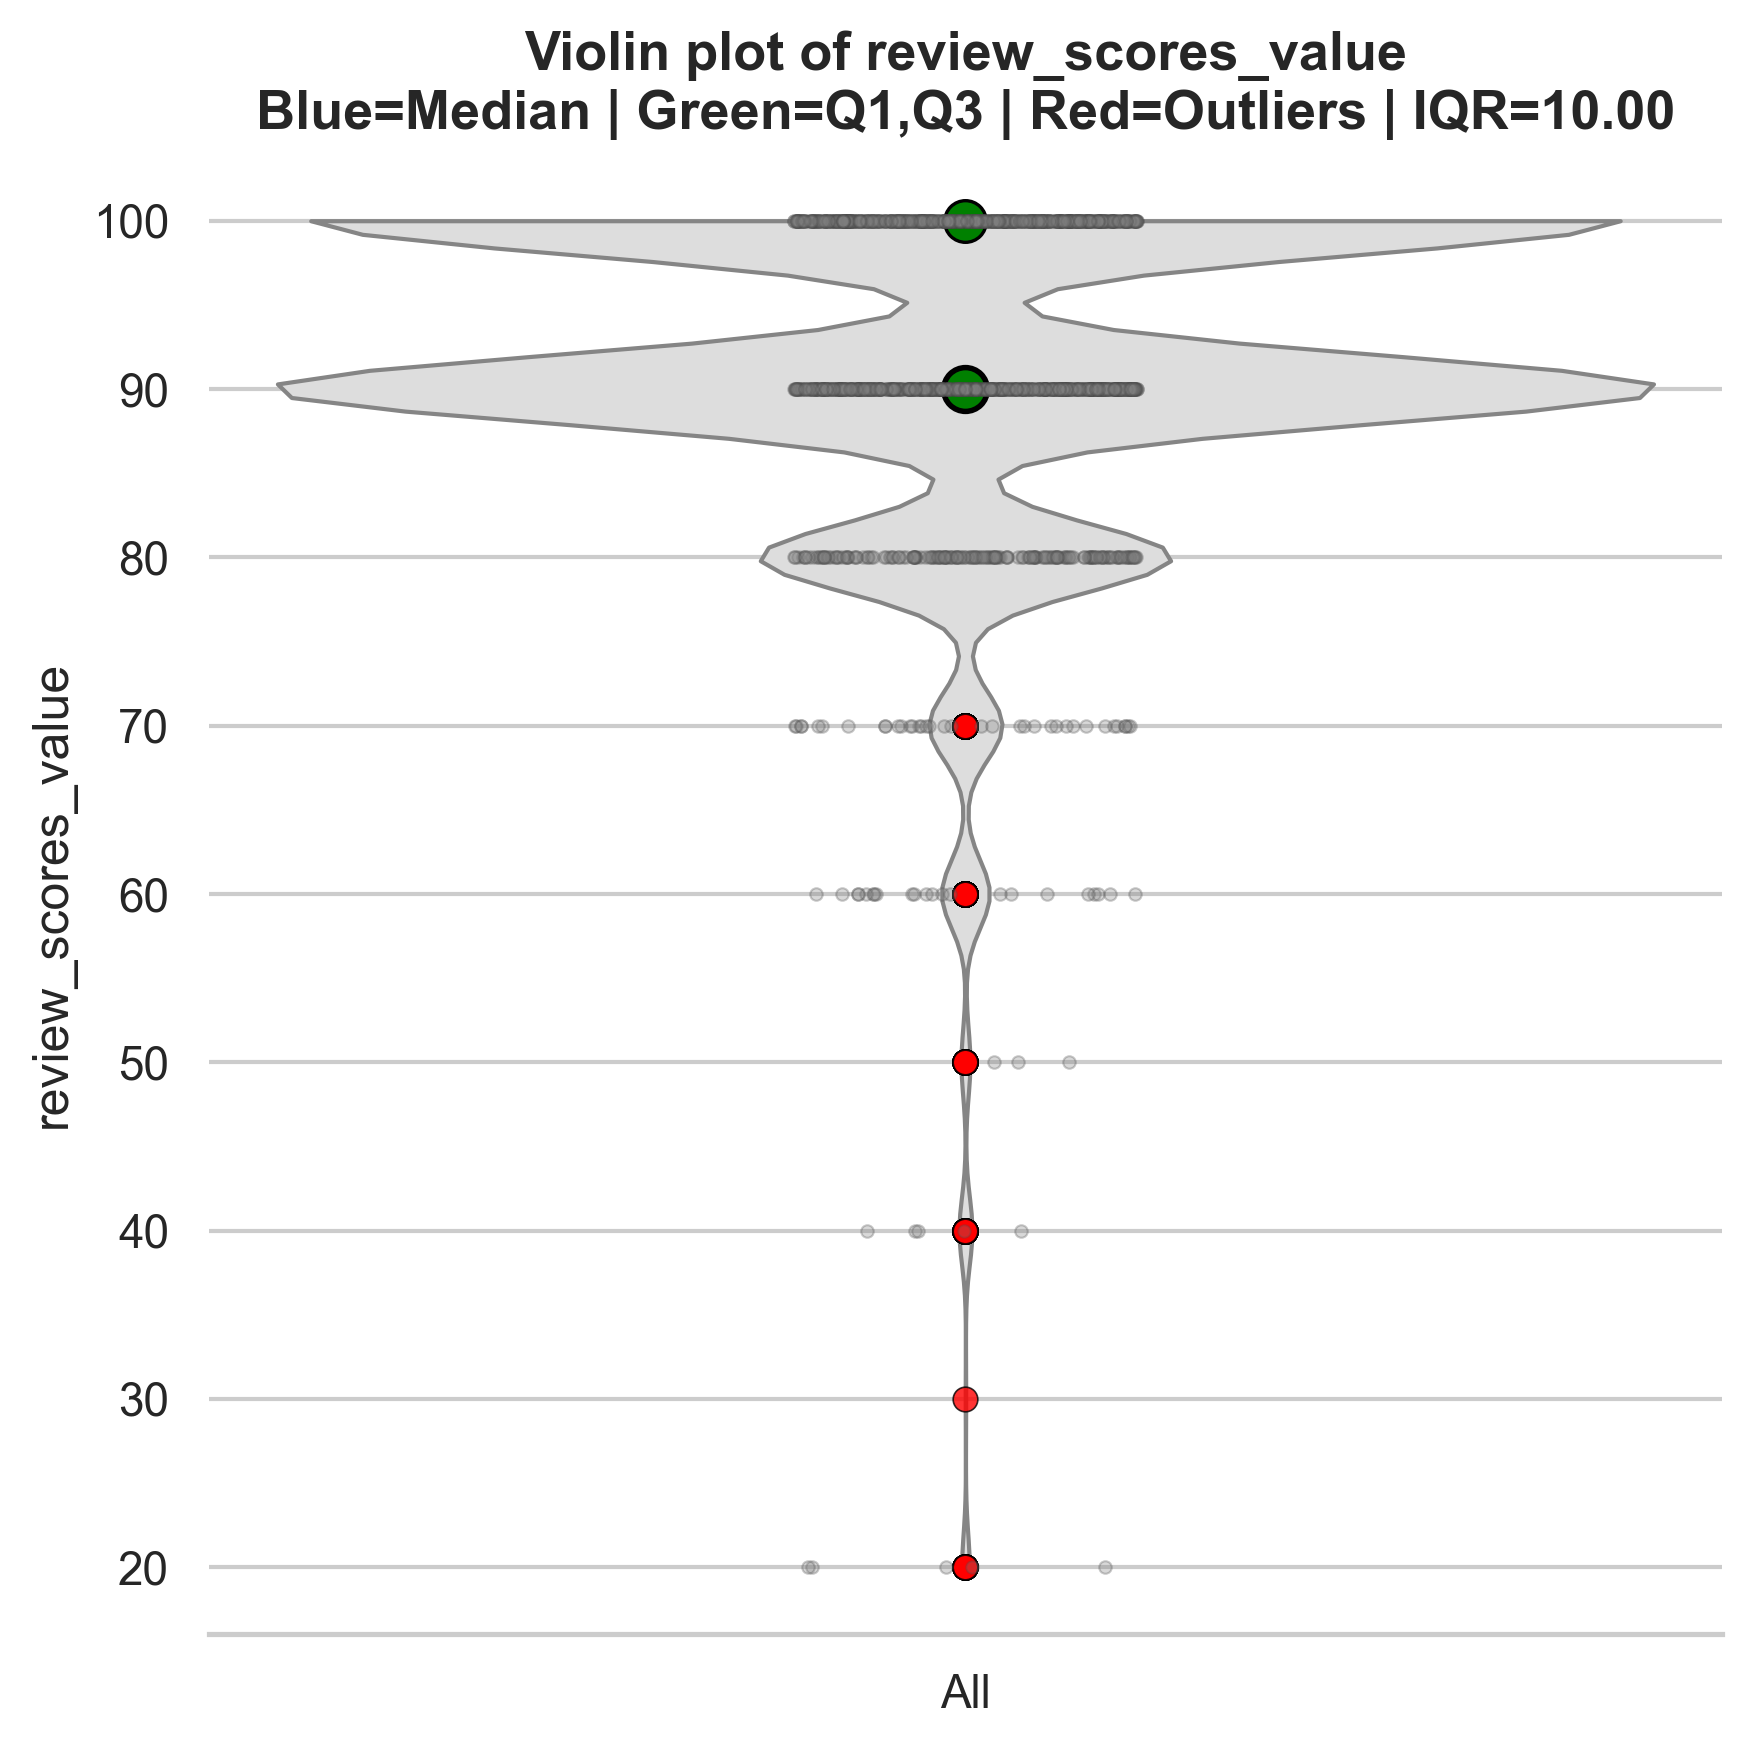

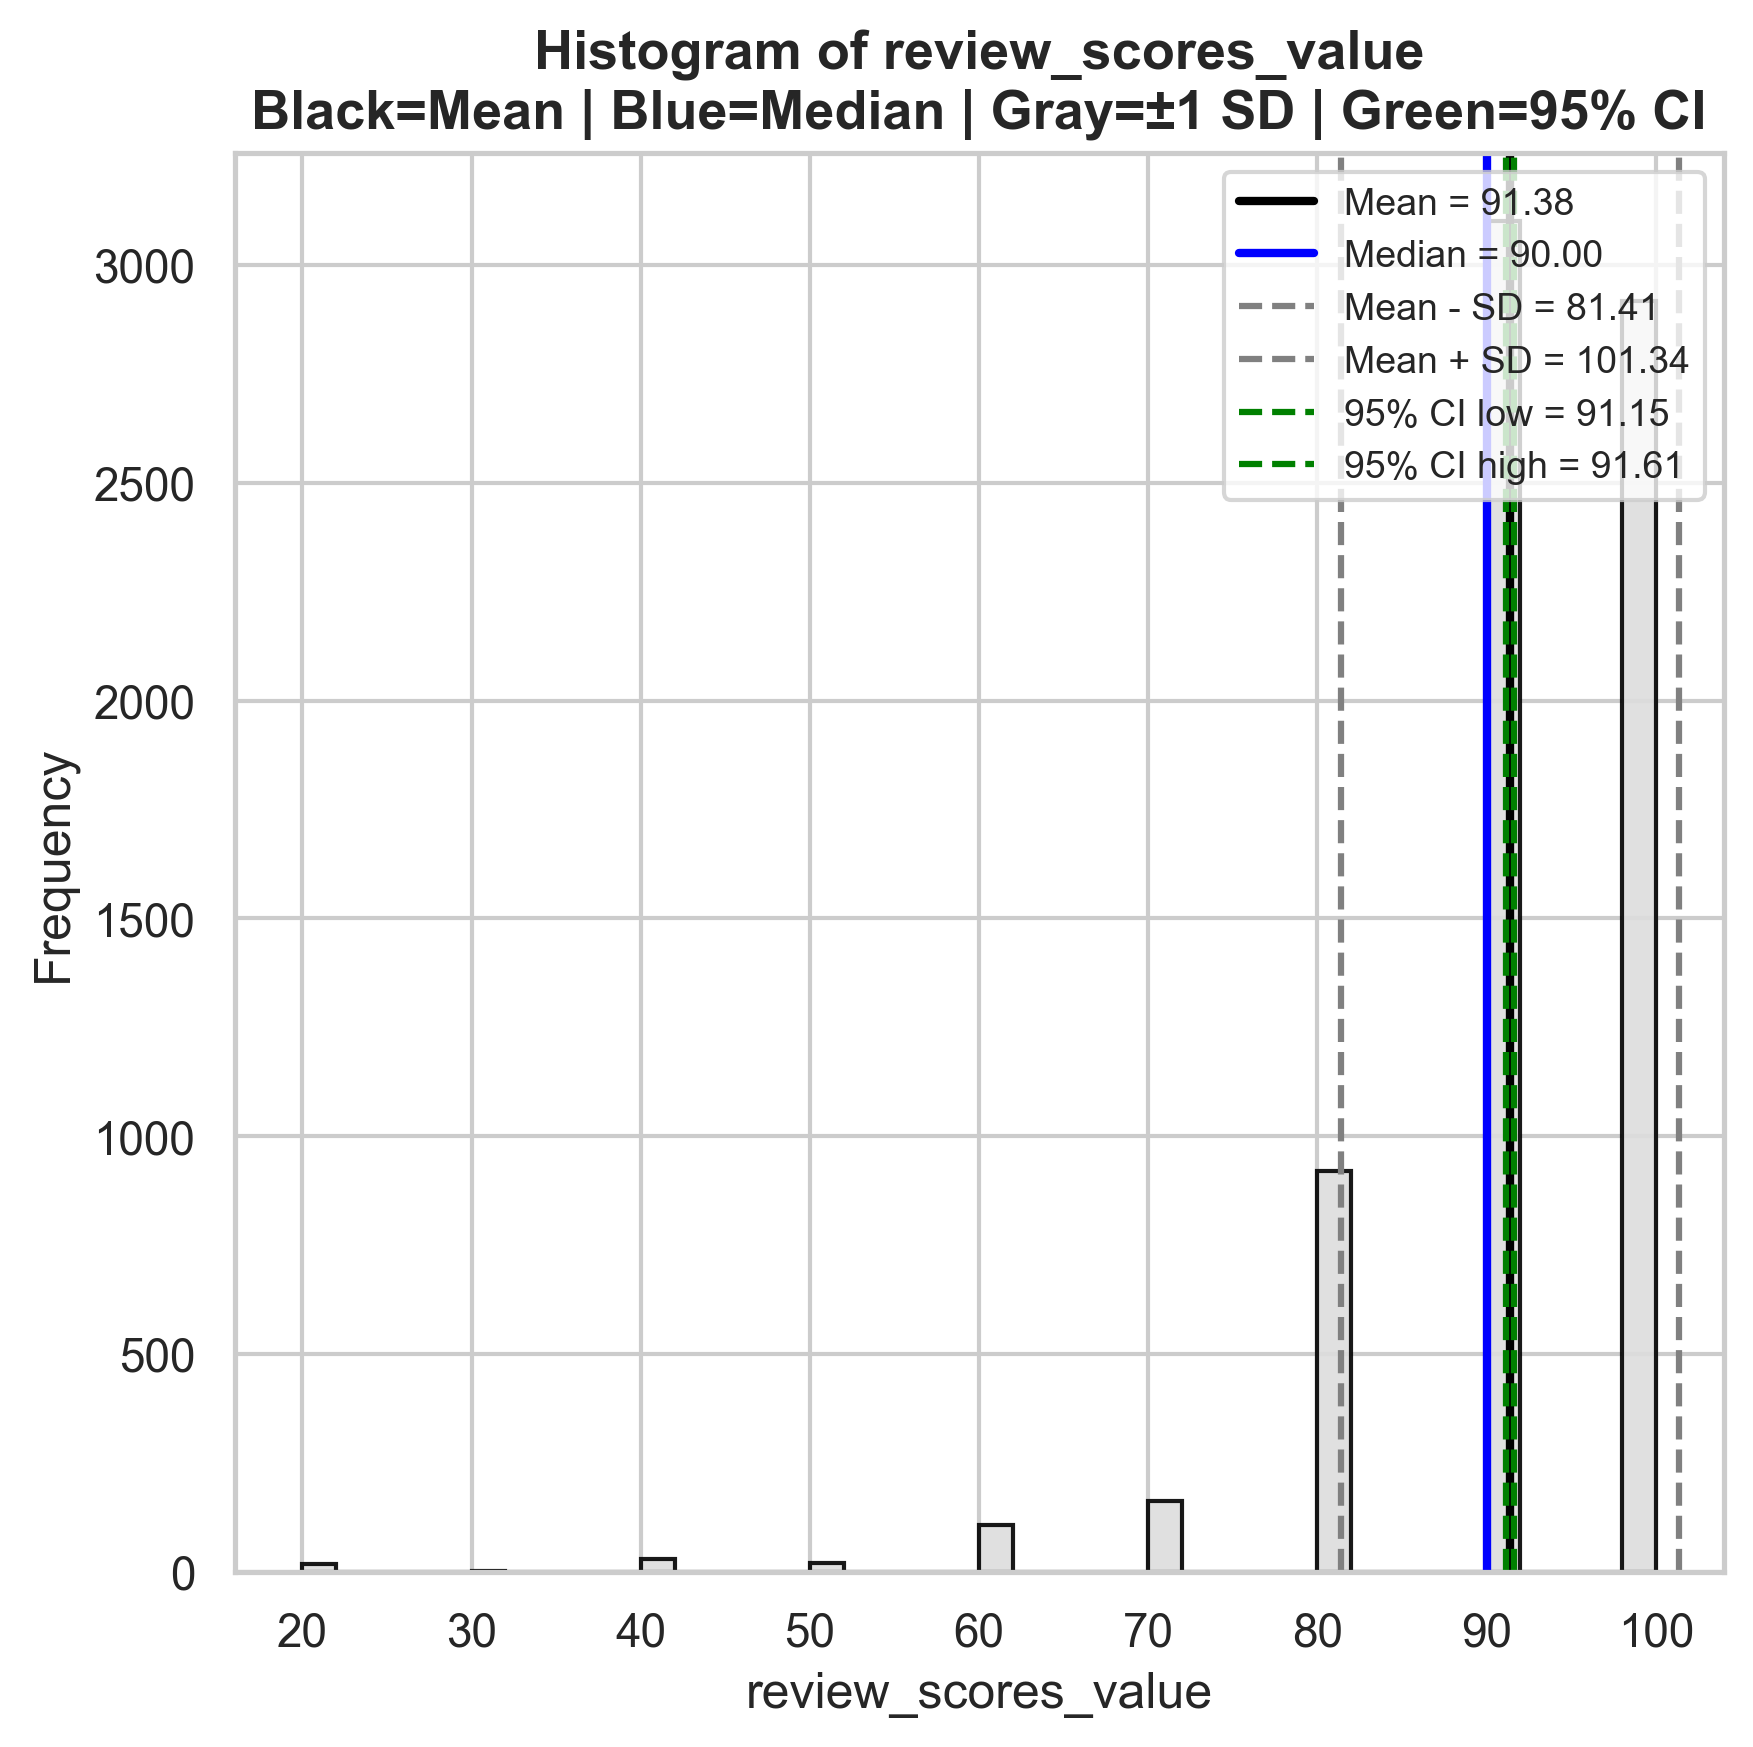

All files saved locally

Summary statistics


,column,n_non_null_numeric,mean,median,std,ci95_low,ci95_high,q1,q3,iqr,lower_fence,upper_fence,outlier_count,skewness,skewness_interpretation
0,review_scores_value,7276,91.37713,90.0,9.967653,91.148061,91.6062,90.0,100.0,10.0,75.0,115.0,337,-2.242393,Highly skewed.



Unique values table
Number of non-nulls: 7276
Number of unique values: 9


,column,value,count,frequency_non_null
0,review_scores_value,20.0,17,0.002336
1,review_scores_value,30.0,1,0.000137
2,review_scores_value,40.0,29,0.003986
3,review_scores_value,50.0,20,0.002749
4,review_scores_value,60.0,107,0.014706
5,review_scores_value,70.0,163,0.022402
6,review_scores_value,80.0,919,0.126306
7,review_scores_value,90.0,3102,0.426333
8,review_scores_value,100.0,2918,0.401045



Correlation table


,target_column,target_type,other_column,other_type,test,statistic,p_value,significance,significance_interpretation,note
0,review_scores_value,numeric,neighbourhood_name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
1,review_scores_value,numeric,neighbourhood_district,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
2,review_scores_value,numeric,city,categorical,Chi-square,79.538975,1.710356e-14,Significant,Statistically significant at p < 0.05.,
3,review_scores_value,numeric,room_type,categorical,Chi-square,28.267736,3.191136e-06,Significant,Statistically significant at p < 0.05.,
4,review_scores_value,numeric,accommodates,numeric,Pearson,-0.045478,1.042056e-04,Significant,Statistically significant at p < 0.05.,
5,review_scores_value,numeric,bathrooms,numeric,Pearson,0.036216,2.066216e-03,Significant,Statistically significant at p < 0.05.,
6,review_scores_value,numeric,bedrooms,numeric,Pearson,-0.006475,5.821563e-01,Not significant,Not statistically significant at p < 0.05.,
7,review_scores_value,numeric,beds,numeric,Pearson,-0.038463,1.036653e-03,Significant,Statistically significant at p < 0.05.,
8,review_scores_value,numeric,price,numeric,Pearson,-0.030210,1.055001e-02,Significant,Statistically significant at p < 0.05.,
9,review_scores_value,numeric,minimum_nights,numeric,Pearson,-0.014552,2.145643e-01,Not significant,Not statistically significant at p < 0.05.,



Transformation skewness table


,method,skewness,interpretation,normality_improvement
0,Original,-2.242393,Highly skewed.,Baseline.
1,Log Transformation,-4.696792,Highly skewed.,Did not improve normality; skewness increased.
2,Square Root Transformation,-3.164696,Highly skewed.,Did not improve normality; skewness increased.
3,Box-Cox Transformation,-0.255014,Approximately symmetric.,Improved strongly; distribution is closer to s...


In [144]:
analysis = analyze_single_field(
    df, target_col="review_scores_value", results_dir=RESULTS_DIR, show_in_notebook=True
)

*Recommendations for Review Scores - Value*:
- mediana: 90.0
- IQR=10.0 [90.0; 100.0]
- 337 outliers determined
- The dataset is very Skewed due to Max values accumulation:
    * Max=100 - 40,1 % of values
- no Transformation of the data should be applied, must be treated like categorical variable
- consider:
    * strongly and significantly associated with: city, room_type, is_instant_bookable
    * strongly and significantly correlated with: review_scores_rating (r=0.77)
    * medium and significantly correlated with: review_scores_accuracy (r=0.66), review_scores_cleanliness (r=0.60), review_scores_checkin (r=0.49), review_scores_communication (r=0.52), review_scores_location (r=0.43)
    * weakly and significantly correlated with: reviews_per_month (r=0.10)
- Non parametric tests must be used

##### Number of reviews per month

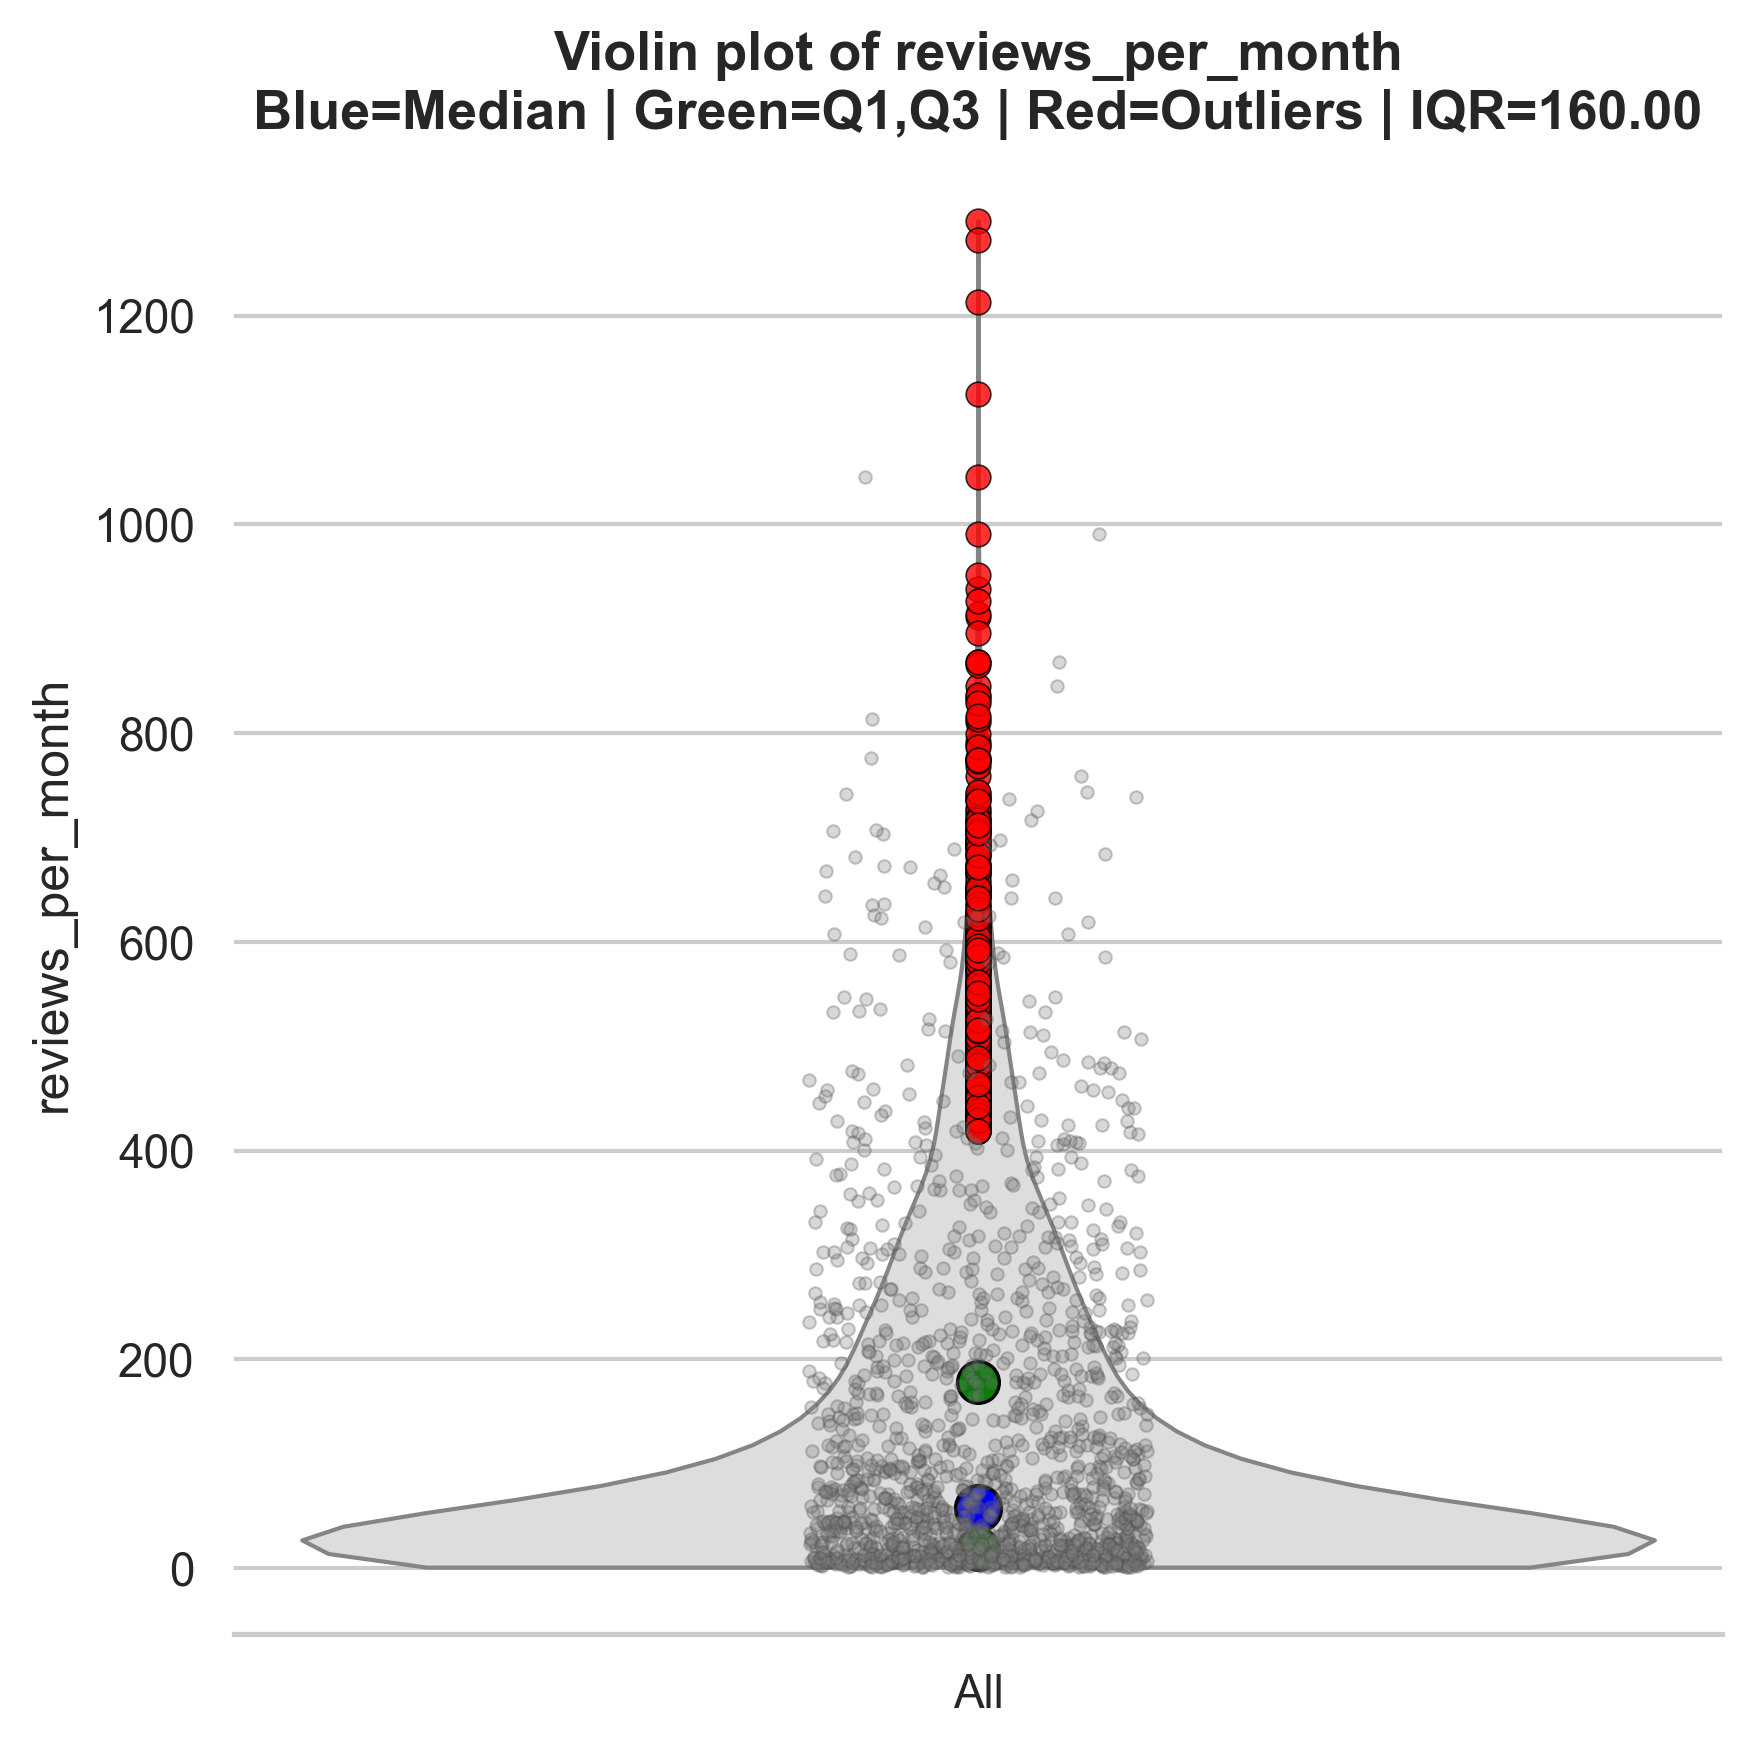

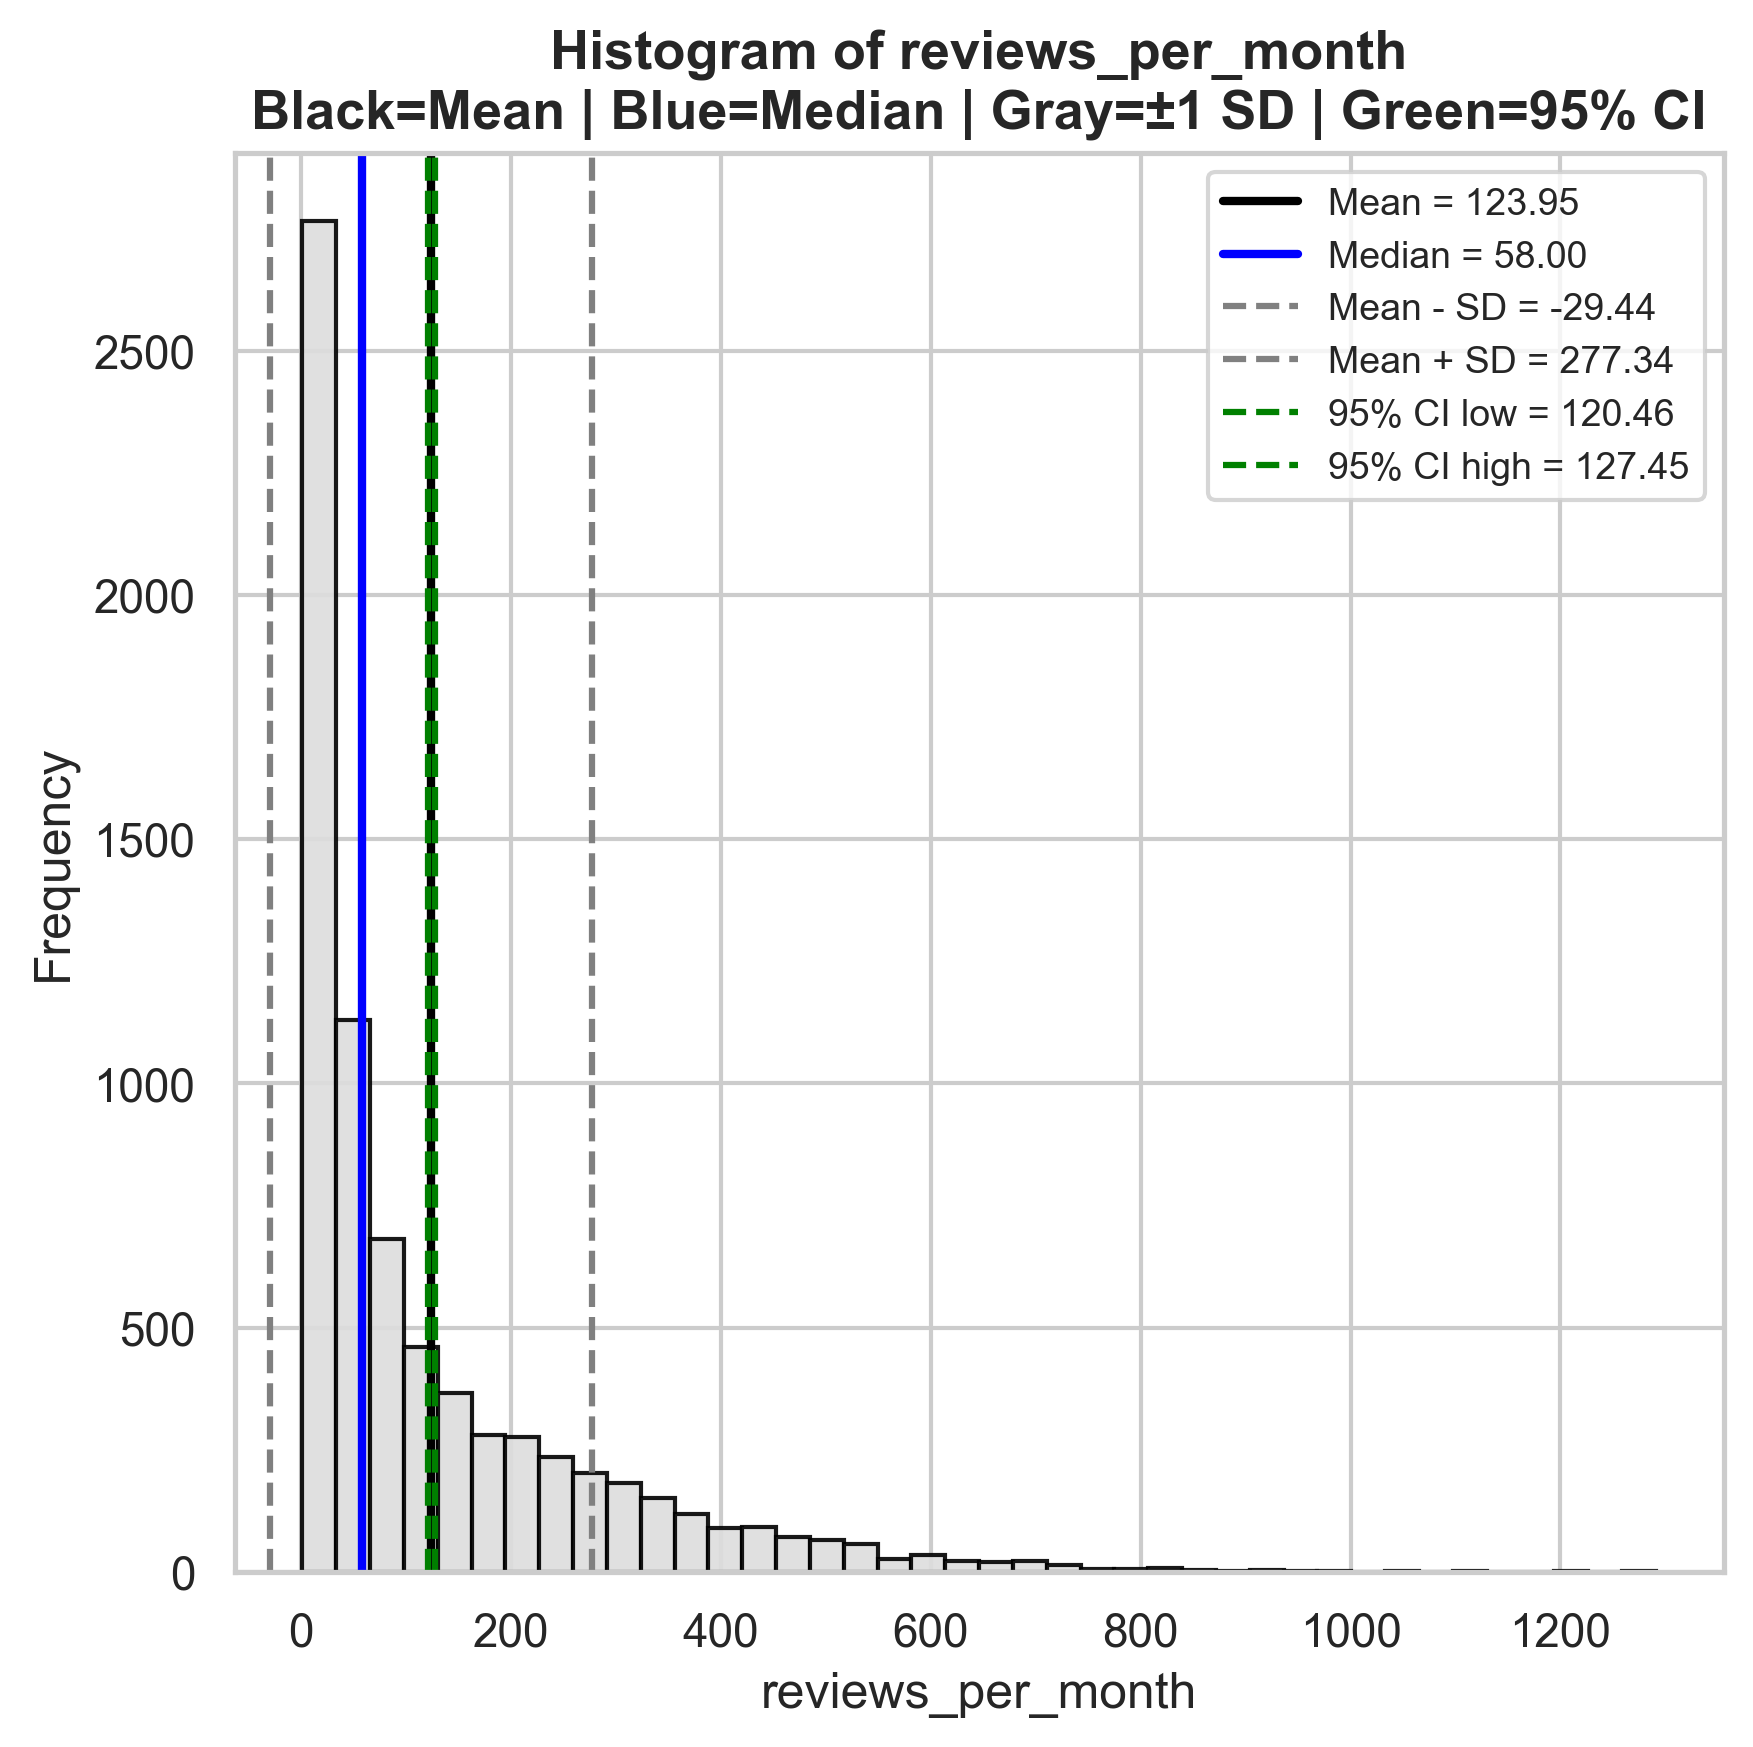

All files saved locally

Summary statistics


,column,n_non_null_numeric,mean,median,std,ci95_low,ci95_high,q1,q3,iqr,lower_fence,upper_fence,outlier_count,skewness,skewness_interpretation
0,reviews_per_month,7396,123.952001,58.0,153.39034,120.45562,127.448382,18.0,178.0,160.0,-222.0,418.0,466,1.983956,Highly skewed.



Unique values table
Number of non-nulls: 7396
Number of unique values: 614


,column,value,count,frequency_non_null
0,reviews_per_month,1.0,87,0.011763
1,reviews_per_month,2.0,93,0.012574
2,reviews_per_month,3.0,125,0.016901
3,reviews_per_month,4.0,114,0.015414
4,reviews_per_month,5.0,126,0.017036
...,...,...,...,...
609,reviews_per_month,1045.0,1,0.000135
610,reviews_per_month,1125.0,1,0.000135
611,reviews_per_month,1213.0,1,0.000135
612,reviews_per_month,1273.0,1,0.000135



Correlation table


,target_column,target_type,other_column,other_type,test,statistic,p_value,significance,significance_interpretation,note
0,reviews_per_month,numeric,neighbourhood_name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
1,reviews_per_month,numeric,neighbourhood_district,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
2,reviews_per_month,numeric,city,categorical,Chi-square,751.979349,2.558614e-140,Significant,Statistically significant at p < 0.05.,
3,reviews_per_month,numeric,room_type,categorical,Chi-square,88.700565,8.807236e-14,Significant,Statistically significant at p < 0.05.,
4,reviews_per_month,numeric,accommodates,numeric,Pearson,-0.144429,9.093681e-36,Significant,Statistically significant at p < 0.05.,
5,reviews_per_month,numeric,bathrooms,numeric,Pearson,-0.162510,1.079043e-44,Significant,Statistically significant at p < 0.05.,
6,reviews_per_month,numeric,bedrooms,numeric,Pearson,-0.185746,5.361923e-58,Significant,Statistically significant at p < 0.05.,
7,reviews_per_month,numeric,beds,numeric,Pearson,-0.176000,1.711250e-52,Significant,Statistically significant at p < 0.05.,
8,reviews_per_month,numeric,price,numeric,Pearson,-0.164819,1.591486e-45,Significant,Statistically significant at p < 0.05.,
9,reviews_per_month,numeric,minimum_nights,numeric,Pearson,-0.067449,6.390215e-09,Significant,Statistically significant at p < 0.05.,



Transformation skewness table


,method,skewness,interpretation,normality_improvement
0,Original,1.983956,Highly skewed.,Baseline.
1,Log Transformation,-0.351553,Approximately symmetric.,Improved strongly; distribution is closer to s...
2,Square Root Transformation,0.862184,Moderately skewed.,Improved; skewness decreased.
3,Box-Cox Transformation,-0.044580,Approximately symmetric.,Improved strongly; distribution is closer to s...


In [145]:
analysis = analyze_single_field(
    df, target_col="reviews_per_month", results_dir=RESULTS_DIR, show_in_notebook=True
)

*Recommendations for Reviews per Month*:
- mediana: 58.0
- IQR=160.0 [18.0; 178.0]
- 466 outliers determined
- The dataset is very Skewed due to Min values accumulation
- Box-Cox Transformation of the data should be applied
- consider:
    * strongly and significantly associated with: city, room_type, is_instant_bookable
    * strongly and significantly correlated with: none found
    * medium and significantly correlated with: number_of_reviews (r=0.63)
    * weakly and significantly correlated with: accommodates (r= -0.14), bathrooms (r= -0.16), bedrooms (r= -0.19), beds (r= -0.18), price (r= -0.16), review_scores_accuracy (r=0.11)m review_scores_checkin (r=0.11), review_scores_location (r=0.11), review_scores_value (r=0.1)
- Spearman correlation should be used

#### **Categorical fields**

There is a hyerarchy determining Location of the accommodation:
- 'city' -> 'neighbourhood_district' -> 'neighbourhood_name'

##### Neighbourhood name

In [146]:
# Number of objects and their quota for each neighbourhood

counts = alojamentos_df["neighbourhood_name"].value_counts()
freqs = alojamentos_df["neighbourhood_name"].value_counts(normalize=True)
neighbourhood_table = pd.DataFrame({"count": counts, "frequency": freqs})
neighbourhood_table["percentage"] = (freqs * 100).round(2)
neighbourhood_table = neighbourhood_table.reset_index()
neighbourhood_table = neighbourhood_table.rename(
    columns={"index": "neighbourhood_name"}
)

print(neighbourhood_table.head())
print(neighbourhood_table.tail())

       neighbourhood_name  count  frequency  percentage
0                  Centro    336     0.0336        3.36
1  la Dreta de l'Eixample    312     0.0312        3.12
2             Embajadores    286     0.0286        2.86
3                el Raval    212     0.0212        2.12
4       Palma de Mallorca    212     0.0212        2.12
    neighbourhood_name  count  frequency  percentage
516  Palol de Revardit      1     0.0001        0.01
517            Tablada      1     0.0001        0.01
518         Heli�polis      1     0.0001        0.01
519               Salt      1     0.0001        0.01
520            Darnius      1     0.0001        0.01


In [147]:
# Top 10 Neighbourhoods
neighbourhood_table.nlargest(10, 'count')

,neighbourhood_name,count,frequency,percentage
0,Centro,336,0.0336,3.36
1,la Dreta de l'Eixample,312,0.0312,3.12
2,Embajadores,286,0.0286,2.86
3,el Raval,212,0.0212,2.12
4,Palma de Mallorca,212,0.0212,2.12
5,Universidad,207,0.0207,2.07
6,Pollen�a,198,0.0198,1.98
7,"Sant Pere, Santa Caterina i la Ribera",188,0.0188,1.88
8,Alc�dia,178,0.0178,1.78
9,Palacio,175,0.0175,1.75


In [148]:
# Numer of Neigbourhoods with only 1 accomodation announcement
neighbourhood_table[neighbourhood_table["count"] == 1].count(axis=0)

neighbourhood_name    101
count                 101
frequency             101
percentage            101
dtype: int64

In [149]:
# Evaluation of associations with another parameters
chtest_neighb_name = chi_square_with_target(alojamentos_df, "neighbourhood_name")

In [150]:
print(chtest_neighb_name)

         target_column         compared_column  chi2_statistic        p_value  \
0   neighbourhood_name            apartment_id      5190754.72   0.000000e+00   
1   neighbourhood_name                    name      5178744.81   0.000000e+00   
2   neighbourhood_name             description      5099546.87   0.000000e+00   
3   neighbourhood_name                 host_id      4571747.16   0.000000e+00   
4   neighbourhood_name  neighbourhood_district       361845.57   0.000000e+00   
5   neighbourhood_name               room_type         3738.56  1.030167e-179   
6   neighbourhood_name            accommodates        23587.87   0.000000e+00   
7   neighbourhood_name          amenities_list      5160161.14  4.342073e-281   
8   neighbourhood_name          minimum_nights        35600.90   0.000000e+00   
9   neighbourhood_name          maximum_nights        77065.34   1.714877e-03   
10  neighbourhood_name        has_availability            0.00   1.000000e+00   
11  neighbourhood_name      

*Recommendations for Neighbourhood name*:
- Most frequent: la Centro (3,36 %)
- Top 10 represent 23,0 % of announcements
- There are 101 Neighbourhood names with 1 announcement (1,0 % of announcements)
- consider:
    * strongly and significantly associated with: neighbourhood_district, room_type, accommodates, amenities_list, minimum_nights, maximum_nights, is_instant_bookable, city
- Non parametric statistics should be used

##### Neighbourhood district

In [151]:
# Number of objects and their quota for each neighbourhood

counts = alojamentos_df["neighbourhood_district"].value_counts()
freqs = alojamentos_df["neighbourhood_district"].value_counts(normalize=True)
neighbourhood_distr_table = pd.DataFrame({"count": counts, "frequency": freqs})
neighbourhood_distr_table["percentage"] = (freqs * 100).round(2)
neighbourhood_distr_table = neighbourhood_distr_table.reset_index()
neighbourhood_distr_table = neighbourhood_distr_table.rename(
    columns={"index": "neighbourhood_district"}
)

print(neighbourhood_distr_table.head())
print(neighbourhood_distr_table.tail())

  neighbourhood_district  count  frequency  percentage
0                 Centro   1077   0.177167       17.72
1               Eixample    987   0.162362       16.24
2           Ciutat Vella    632   0.103964       10.40
3          Casco Antiguo    359   0.059056        5.91
4             Sant Mart�    306   0.050337        5.03
   neighbourhood_district  count  frequency  percentage
56       Macarena - Norte      5   0.000823        0.08
57          Cerro - Amate      3   0.000494        0.05
58      POBLATS DE L'OEST      3   0.000494        0.05
59              Vic�lvaro      3   0.000494        0.05
60       POBLATS DEL NORD      1   0.000165        0.02


In [152]:
neighbourhood_distr_table.nlargest(10, 'count')

,neighbourhood_district,count,frequency,percentage
0,Centro,1077,0.177167,17.72
1,Eixample,987,0.162362,16.24
2,Ciutat Vella,632,0.103964,10.40
3,Casco Antiguo,359,0.059056,5.91
4,Sant Mart�,306,0.050337,5.03
5,Sants-Montju�c,305,0.050173,5.02
6,Gr�cia,246,0.040467,4.05
7,Salamanca,147,0.024182,2.42
8,Chamber�,128,0.021056,2.11
9,Arganzuela,122,0.020069,2.01


In [153]:
neighbourhood_distr_table[neighbourhood_distr_table["count"] < 10].count()

neighbourhood_district    10
count                     10
frequency                 10
percentage                10
dtype: int64

In [154]:
# Evaluation of associations with another parameters
chtest_neighb_distr = chi_square_with_target(alojamentos_df, "neighbourhood_district")

print(chtest_neighb_distr)

             target_column      compared_column  chi2_statistic  \
0   neighbourhood_district         apartment_id       364322.67   
1   neighbourhood_district                 name       363207.99   
2   neighbourhood_district          description       357487.05   
3   neighbourhood_district              host_id       342407.96   
4   neighbourhood_district   neighbourhood_name       361845.57   
5   neighbourhood_district            room_type          773.90   
6   neighbourhood_district         accommodates         1210.99   
7   neighbourhood_district       amenities_list       361914.62   
8   neighbourhood_district       minimum_nights         4888.04   
9   neighbourhood_district       maximum_nights         9755.48   
10  neighbourhood_district     has_availability            0.00   
11  neighbourhood_district      availability_30         1904.96   
12  neighbourhood_district      availability_60         3543.37   
13  neighbourhood_district      availability_90         5188.5

*Recommendations for Neighbourhood district*:
- Most frequent: Centro
- Top 10 represent 70,9 % of announcements
- There are 10 Neighbourhood districts with less than 10 announcements
- consider:
    * strongly and significantly associated with: neighbourhood_name, room_type, accommodates, minimum_nights, maximum_nights, availability_30, is_instant_bookable, city
- Non parametric statistics should be used

##### City

In [155]:
# Number of objects and their quota for each city

counts = alojamentos_df["city"].value_counts()
freqs = alojamentos_df["city"].value_counts(normalize=True)
city_table = pd.DataFrame({"count": counts, "frequency": freqs})
city_table["percentage"] = (freqs * 100).round(2)
city_table = city_table.reset_index()
city_table = city_table.rename(columns={"index": "neighbourhood_name"})

print(city_table)

        city  count  frequency  percentage
0  barcelona   2825     0.2825       28.25
1     madrid   2202     0.2202       22.02
2   mallorca   1644     0.1644       16.44
3     girona   1533     0.1533       15.33
4   valencia    528     0.0528        5.28
5    sevilla    524     0.0524        5.24
6     malaga    520     0.0520        5.20
7    menorca    224     0.0224        2.24


In [156]:
# Evaluation of associations with another parameters
chtest_city = chi_square_with_target(alojamentos_df, "city")

print(chtest_city)

   target_column         compared_column  chi2_statistic        p_value  \
0           city            apartment_id        70000.00   1.955578e-11   
1           city                    name        69868.96   1.449901e-09   
2           city             description        69013.42   8.319528e-07   
3           city                 host_id        67969.19   0.000000e+00   
4           city      neighbourhood_name        69917.46   0.000000e+00   
5           city  neighbourhood_district        18237.00   0.000000e+00   
6           city               room_type         1709.71   0.000000e+00   
7           city            accommodates         2838.02   0.000000e+00   
8           city          amenities_list        69487.08   1.228721e-05   
9           city          minimum_nights         3557.19   0.000000e+00   
10          city          maximum_nights         2319.31  2.011917e-102   
11          city        has_availability            0.00   1.000000e+00   
12          city         

*Recommendations for City*:
- Most frequent: Barcelona - 28,2 % of announcements
- Least frequent: Menorca - 2,2 % of announcements
- consider:
    * strongly and significantly associated with: neighbourhood_name, neighbourhood_district, room_type, accommodates, minimum_nights, maximum_nights, availability_30, availability_60, availability_90, availability_365, number_of_reviews, is_instant_bookable
- Non parametric statistics should be used

##### Type of the accommodation

In [157]:
# Number of objects and their quota for each type of the rooms

counts = alojamentos_df["room_type"].value_counts()
freqs = alojamentos_df["room_type"].value_counts(normalize=True)
room_type_table = pd.DataFrame({"count": counts, "frequency": freqs})
room_type_table["percentage"] = (freqs * 100).round(2)
room_type_table = room_type_table.reset_index()
room_type_table = room_type_table.rename(columns={"index": "room_type"})

print(room_type_table)

         room_type  count  frequency  percentage
0  Entire home/apt   6930     0.6930       69.30
1     Private room   2913     0.2913       29.13
2       Hotel room     83     0.0083        0.83
3      Shared room     74     0.0074        0.74


In [158]:
# Evaluation of associations with another parameters
room_type_name = chi_square_with_target(alojamentos_df, "room_type")

print(room_type_name)

   target_column         compared_column  chi2_statistic        p_value  \
0      room_type            apartment_id        29812.24   1.829471e-04   
1      room_type                    name        29859.36   1.965570e-04   
2      room_type             description        29398.69   8.075275e-03   
3      room_type                 host_id        27723.78  8.702602e-151   
4      room_type      neighbourhood_name         3738.56  1.030167e-179   
5      room_type  neighbourhood_district          773.90   1.399859e-74   
6      room_type            accommodates         5873.06   0.000000e+00   
7      room_type          amenities_list        29875.13   8.148381e-04   
8      room_type          minimum_nights          871.66  1.818066e-104   
9      room_type          maximum_nights         1252.87   1.482081e-79   
10     room_type        has_availability            0.00   1.000000e+00   
11     room_type         availability_30          206.28   4.070390e-11   
12     room_type         

*Recommendations for Room type*:
- Most frequent: Entire home/apt - 69,3 % of announcements
- Least frequent: Shared room - 0,74 % of announcements
- consider:
    * strongly and significantly associated with: neighbourhood_name, neighbourhood_district, accommodates, amenities_list, minimum_nights, maximum_nights, availability_30, availability_60, availability_90, availability_365, is_instant_bookable, city
- Non parametric statistics should be used

##### Availability condition

In [159]:
# Number of objects and their quota for each neighbourhood

counts = alojamentos_df["has_availability"].value_counts()
freqs = alojamentos_df["has_availability"].value_counts(normalize=True)
availab_cond_table = pd.DataFrame({"count": counts, "frequency": freqs})
availab_cond_table["percentage"] = (freqs * 100).round(2)
availab_cond_table = availab_cond_table.reset_index()
availab_cond_table = availab_cond_table.rename(columns={"index": "has_availability"})

print(availab_cond_table.head())

  has_availability  count  frequency  percentage
0        VERDADERO   9450        1.0       100.0


*Recommendations for Availability condition*:
- 94,5 % of announcements were available

##### Instant booking condition

In [160]:
# Number of objects and their quota for each neighbourhood

counts = alojamentos_df["is_instant_bookable"].value_counts()
freqs = alojamentos_df["is_instant_bookable"].value_counts(normalize=True)
instant_book_table = pd.DataFrame({"count": counts, "frequency": freqs})
instant_book_table["percentage"] = (freqs * 100).round(2)
instant_book_table = instant_book_table.reset_index()
instant_book_table = instant_book_table.rename(columns={"index": "is_instant_bookable"})

print(instant_book_table)

  is_instant_bookable  count  frequency  percentage
0           VERDADERO   5806     0.5806       58.06
1               FALSO   4194     0.4194       41.94


In [161]:
# Evaluation of associations with another parameters
chtest_instant_book = chi_square_with_target(alojamentos_df, "is_instant_bookable")

print(chtest_instant_book)

          target_column         compared_column  chi2_statistic       p_value  \
0   is_instant_bookable            apartment_id         9945.24  1.717813e-02   
1   is_instant_bookable                    name         9937.45  2.624496e-02   
2   is_instant_bookable             description         9820.15  6.196173e-02   
3   is_instant_bookable                 host_id         9367.15  9.409167e-58   
4   is_instant_bookable      neighbourhood_name          860.14  3.450751e-19   
5   is_instant_bookable  neighbourhood_district          204.77  1.066184e-17   
6   is_instant_bookable               room_type          224.44  2.199187e-48   
7   is_instant_bookable            accommodates          200.68  8.269893e-32   
8   is_instant_bookable          amenities_list         9930.61  5.196653e-02   
9   is_instant_bookable          minimum_nights          562.61  6.109995e-89   
10  is_instant_bookable          maximum_nights          300.53  9.248504e-13   
11  is_instant_bookable     

*Recommendations for Instant booking condition*:
- 58,1 % of announcements were instantly bookable
- consider:
    * strongly and significantly associated with: neighbourhood_name, neighbourhood_district, room_type, accommodates, amenities_list, minimum_nights, maximum_nights, availability_30, availability_60, availability_90, availability_365, city
- Non parametric statistics should be used

#### Date fields

##### First review date

In [162]:
frd_df = alojamentos_df[["apartment_id", "host_id", "first_review_date"]].copy()
frd_df["first_review_date"] = pd.to_datetime(frd_df["first_review_date"], dayfirst=True)
frd_df["year"] = frd_df["first_review_date"].dt.year.astype("Int64")
frd_df["month"] = frd_df["first_review_date"].dt.month.astype("Int64")
frd_df.head(3)

,apartment_id,host_id,first_review_date,year,month
0,11964,45553,2010-02-01,2010,2
1,21853,83531,2014-10-10,2014,10
2,32347,139939,2011-05-01,2011,5


In [163]:
### BY DATE
# Number of objects and their quota for each neighbourhood

counts = frd_df["first_review_date"].value_counts()
freqs = frd_df["first_review_date"].value_counts(normalize=True)
frd_table = pd.DataFrame({"count": counts, "frequency": freqs})
frd_table["percentage"] = (freqs * 100).round(2)
frd_table = frd_table.reset_index()
frd_table = frd_table.rename(columns={"index": "first_review_date"})

print(frd_table.head())
print(frd_table.tail())

  first_review_date  count  frequency  percentage
0        2018-01-04     27   0.008701        0.87
1        2018-05-08     18   0.005801        0.58
2        2018-08-07     18   0.005801        0.58
3        2017-01-01     18   0.005801        0.58
4        2017-12-08     18   0.005801        0.58
    first_review_date  count  frequency  percentage
870        2011-01-07      1   0.000322        0.03
871        2011-10-11      1   0.000322        0.03
872        2012-02-11      1   0.000322        0.03
873        2012-01-08      1   0.000322        0.03
874        2011-08-04      1   0.000322        0.03


In [164]:
### BY MONTH
# Number of objects and their quota for each neighbourhood

counts = frd_df["month"].value_counts()
freqs = frd_df["month"].value_counts(normalize=True)
frd_table = pd.DataFrame({"count": counts, "frequency": freqs})
frd_table["percentage"] = (freqs * 100).round(2)
frd_table = frd_table.reset_index()
frd_table = frd_table.rename(columns={"index": "month"})

print(frd_table.sort_values("month"))

    month  count  frequency  percentage
0       1    321   0.103448       10.34
2       2    286   0.092169        9.22
1       3    302   0.097325        9.73
5       4    251   0.080889        8.09
4       5    260    0.08379        8.38
7       6    244   0.078634        7.86
11      7    224   0.072188        7.22
9       8    234   0.075411        7.54
6       9    244   0.078634        7.86
3      10    263   0.084757        8.48
10     11    233   0.075089        7.51
8      12    241   0.077667        7.77


In [165]:
### BY Year
# Number of objects and their quota for each neighbourhood

counts = frd_df["year"].value_counts()
freqs = frd_df["year"].value_counts(normalize=True)
frd_table = pd.DataFrame({"count": counts, "frequency": freqs})
frd_table["percentage"] = (freqs * 100).round(2)
frd_table = frd_table.reset_index()
frd_table = frd_table.rename(columns={"index": "year"})

print(frd_table.sort_values("year"))

    year  count  frequency  percentage
11  2010      1   0.000322        0.03
9   2011     14   0.004512        0.45
8   2012     28   0.009024         0.9
7   2013    102   0.032871        3.29
5   2014    162   0.052208        5.22
4   2015    278   0.089591        8.96
3   2016    480   0.154689       15.47
1   2017    623   0.200773       20.08
0   2018    743   0.239446       23.94
2   2019    558   0.179826       17.98
6   2020    112   0.036094        3.61
10  2021      2   0.000645        0.06


##### Last review date

In [166]:
lrd_df = alojamentos_df[["apartment_id", "host_id", "last_review_date"]].copy()
lrd_df["last_review_date"] = pd.to_datetime(lrd_df["last_review_date"], dayfirst=True)
lrd_df["year"] = lrd_df["last_review_date"].dt.year.astype("Int64")
lrd_df["month"] = lrd_df["last_review_date"].dt.month.astype("Int64")
lrd_df.head(3)

,apartment_id,host_id,last_review_date,year,month
0,11964,45553,2017-05-09,2017,5
1,21853,83531,NaT,<NA>,<NA>
2,32347,139939,NaT,<NA>,<NA>


In [167]:
### BY DATE
# Number of objects and their quota for each neighbourhood

counts = lrd_df["last_review_date"].value_counts()
freqs = lrd_df["last_review_date"].value_counts(normalize=True)
lrd_table = pd.DataFrame({"count": counts, "frequency": freqs})
lrd_table["percentage"] = (freqs * 100).round(2)
lrd_table = lrd_table.reset_index()
lrd_table = lrd_table.rename(columns={"index": "last_review_date"})

print(lrd_table.head())
print(lrd_table.tail())

  last_review_date  count  frequency  percentage
0       2020-08-03     52   0.017016        1.70
1       2020-01-03     42   0.013743        1.37
2       2020-02-03     29   0.009490        0.95
3       2020-02-01     28   0.009162        0.92
4       2019-03-11     28   0.009162        0.92
    last_review_date  count  frequency  percentage
595       2020-07-12      1   0.000327        0.03
596       2020-11-11      1   0.000327        0.03
597       2020-01-12      1   0.000327        0.03
598       2020-11-12      1   0.000327        0.03
599       2021-12-02      1   0.000327        0.03


In [168]:
### BY MONTH
# Number of objects and their quota for each neighbourhood

counts = lrd_df["month"].value_counts()
freqs = lrd_df["month"].value_counts(normalize=True)
lrd_table = pd.DataFrame({"count": counts, "frequency": freqs})
lrd_table["percentage"] = (freqs * 100).round(2)
lrd_table = lrd_table.reset_index()
lrd_table = lrd_table.rename(columns={"index": "month"})

print(lrd_table.sort_values("month"))

    month  count  frequency  percentage
0       1    389   0.127291       12.73
1       2    329   0.107657       10.77
2       3    306   0.100131       10.01
5       4    242   0.079188        7.92
7       5    219   0.071662        7.17
9       6    216   0.070681        7.07
10      7    202   0.066099        6.61
4       8    263    0.08606        8.61
3       9    268   0.087696        8.77
6      10    220    0.07199         7.2
8      11    218   0.071335        7.13
11     12    184   0.060209        6.02


In [169]:
### BY Year
# Number of objects and their quota for each neighbourhood

counts = lrd_df["year"].value_counts()
freqs = lrd_df["year"].value_counts(normalize=True)
lrd_table = pd.DataFrame({"count": counts, "frequency": freqs})
lrd_table["percentage"] = (freqs * 100).round(2)
lrd_table = lrd_table.reset_index()
lrd_table = lrd_table.rename(columns={"index": "year"})

print(lrd_table.sort_values("year"))

   year  count  frequency  percentage
7  2014      6   0.001963         0.2
5  2015     27   0.008835        0.88
4  2016    102   0.033377        3.34
3  2017    375   0.122709       12.27
1  2018    788   0.257853       25.79
0  2019   1068   0.349476       34.95
2  2020    672   0.219895       21.99
6  2021     18    0.00589        0.59


##### Date of data exporting

In [170]:
insdate_df = alojamentos_df[["apartment_id", "host_id", "insert_date"]].copy()
insdate_df["insert_date"] = pd.to_datetime(insdate_df["insert_date"], dayfirst=True)
insdate_df["year"] = insdate_df["insert_date"].dt.year.astype("Int64")
insdate_df["month"] = insdate_df["insert_date"].dt.month.astype("Int64")
insdate_df.head(3)

,apartment_id,host_id,insert_date,year,month
0,11964,45553,2018-07-31,2018,7
1,21853,83531,2020-01-10,2020,1
2,32347,139939,2019-07-29,2019,7


In [171]:
### BY DATE
# Number of objects and their quota for each neighbourhood

counts = insdate_df["insert_date"].value_counts()
freqs = insdate_df["insert_date"].value_counts(normalize=True)
insdate_table = pd.DataFrame({"count": counts, "frequency": freqs})
insdate_table["percentage"] = (freqs * 100).round(2)
insdate_table = insdate_table.reset_index()
insdate_table = insdate_table.rename(columns={"index": "insert_date"})

print(insdate_table.head())
print(insdate_table.tail())

  insert_date  count  frequency  percentage
0  2019-12-31    186     0.0186        1.86
1  2020-02-29    166     0.0166        1.66
2  2019-03-08    142     0.0142        1.42
3  2018-05-14    136     0.0136        1.36
4  2019-12-10    134     0.0134        1.34
    insert_date  count  frequency  percentage
159  2019-03-28     14     0.0014        0.14
160  2020-01-30     13     0.0013        0.13
161  2020-10-29     13     0.0013        0.13
162  2018-05-27     12     0.0012        0.12
163  2018-12-21     10     0.0010        0.10


In [172]:
### BY MONTH
# Number of objects and their quota for each neighbourhood

counts = insdate_df["month"].value_counts()
freqs = insdate_df["month"].value_counts(normalize=True)
insdate_table = pd.DataFrame({"count": counts, "frequency": freqs})
insdate_table["percentage"] = (freqs * 100).round(2)
insdate_table = insdate_table.reset_index()
insdate_table = insdate_table.rename(columns={"index": "month"})

print(insdate_table.sort_values("month"))

    month  count  frequency  percentage
1       1    939     0.0939        9.39
0       2    944     0.0944        9.44
10      3    728     0.0728        7.28
4       4    870      0.087         8.7
6       5    850      0.085         8.5
11      6    672     0.0672        6.72
8       7    793     0.0793        7.93
9       8    750      0.075         7.5
5       9    860      0.086         8.6
7      10    824     0.0824        8.24
2      11    900       0.09         9.0
3      12    870      0.087         8.7


In [173]:
### BY Year
# Number of objects and their quota for each neighbourhood

counts = insdate_df["year"].value_counts()
freqs = insdate_df["year"].value_counts(normalize=True)
insdate_table = pd.DataFrame({"count": counts, "frequency": freqs})
insdate_table["percentage"] = (freqs * 100).round(2)
insdate_table = insdate_table.reset_index()
insdate_table = insdate_table.rename(columns={"index": "year"})

print(insdate_table.sort_values("year"))

   year  count  frequency  percentage
3  2017    806     0.0806        8.06
2  2018   2109     0.2109       21.09
0  2019   3424     0.3424       34.24
1  2020   3086     0.3086       30.86
4  2021    575     0.0575        5.75
